In [1]:
pip install pettingzoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 13.2 MB/s eta 0:00:00


In [ ]:
# Change at the top of the file, after all imports
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Loaded precipitation data from 4083151.csv from 2020-01-01 to 2024-12-31
Total 1827 daily precipitation records.
Training progress will be logged to training_progress.log
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

--- Starting MAPPO Training for Multi-Agent Env ---
Episode 0/100000, Avg Total Reward (last 100): -151.53, Avg Length (last 100): 100.0
Episode 100/100000, Avg Total Reward (last 100): 402.08, Avg Length (last 100): 100.0
Episode 200/100000, Avg Total Reward (last 100): 403.39, Avg Length (last 100): 100.0
Episode 300/100000, Avg Total Reward (last 100): 468.84, Avg Length (last 100): 100.0
Episode 400

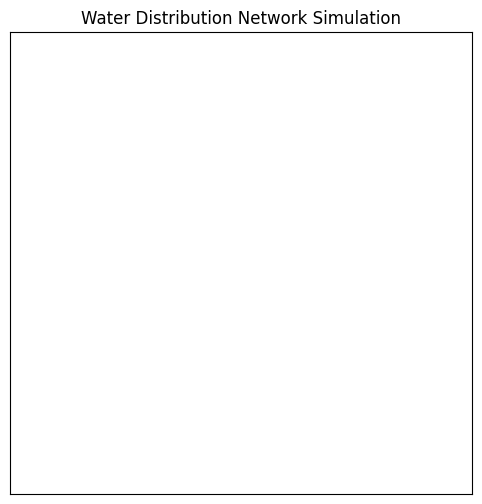

Test Episode Total Reward: 414.55
Saving animation to water_sim_episode_00500.gif...
Animation saved.


In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys # ADDED: For file logging
import os  # ADDED: For file logging

# PettingZoo imports
from pettingzoo import AECEnv
from pettingzoo.utils import wrappers
from pettingzoo.utils.conversions import aec_to_parallel
from pettingzoo.utils.agent_selector import agent_selector # Explicit import for the class

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd # For data preprocessing
import matplotlib.animation as animation # ADDED: For GIF animation
import imageio.v2 as imageio # ADDED: For GIF saving (using v2 to avoid deprecation warnings)

# --- 1. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level # Stored for reset
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate # CONFIRMED: Stored for later use in _get_current_inflow_from_data
        self.inflow_rate = inflow_rate # Represents natural inflow (e.g., rain, river)

        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 2. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand, demand_std_dev=0.1):
        self.base_demand = base_demand
        self.current_demand = base_demand # Initial demand
        self.demand_std_dev = demand_std_dev # Standard deviation for fluctuation
        self.water_received = 0.0
        self.demand_met = False

    def generate_demand(self):
        fluctuation = np.random.normal(0, self.demand_std_dev)
        self.current_demand = max(0.0, self.base_demand * (1 + fluctuation))
        self.water_received = 0.0 # Reset received water for the new time step
        self.demand_met = False
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        if self.water_received >= self.current_demand:
            self.demand_met = True
        else:
            self.demand_met = False

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 3. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 4. Pipe Class (No changes) ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- NEW FUNCTION: Load and Preprocess Precipitation Data ---
def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath)
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    precipitation_mm = precipitation_mm.fillna(0)
    precipitation_mm = precipitation_mm.clip(lower=0)

    print(f"Loaded precipitation data from {filepath} from {precipitation_mm.index.min().date()} to {precipitation_mm.index.max().date()}")
    print(f"Total {len(precipitation_mm)} daily precipitation records.")

    return precipitation_mm

# --- 5. WaterDistributionEnv (PettingZoo AEC Environment) ---
class RawWaterDistributionEnv(AECEnv):
    metadata = {"render_modes": ["human"], "name": "water_distribution_v0", "is_parallelizable": True}

    # New code (to fix the error)
    def __init__(self, reservoir_capacity, initial_reservoir_level,
                 precipitation_data, initial_base_inflow_rate,
                 demand_zone_base_demands, valve_max_flow_rates,
                 pipe_capacities, num_actions_per_agent=3, render_mode=None,
                 max_timesteps=100, communication_vector_size=4):
        super().__init__()

        self.reservoir = Reservoir(reservoir_capacity, initial_reservoir_level, initial_base_inflow_rate)

        self.demand_zones = [UrbanDemandZone(bd) for bd in demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in pipe_capacities]

        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal for this setup.")

        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]

        self.time_step_counter = 0
        self.max_timesteps = max_timesteps

        self.precipitation_data = precipitation_data
        self.current_sim_day_idx = 0
        # CONFIRMED: Adjusted precipitation scale for more noticeable effect
        self.precipitation_to_inflow_scale = 50.0 # Increased significantly for noticeable effect (was 5.0)

        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
                high=np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32),
                shape=(4,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }
        self.global_observation_space = spaces.Box(
            low=np.array([0.0] + [0.0] * len(self.possible_agents), dtype=np.float32),
            high=np.array([self.reservoir.capacity] + [dz.base_demand * 2.0 for dz in self.demand_zones], dtype=np.float32),
            shape=(1 + len(self.possible_agents),),
            dtype=np.float32
        )

        self.num_actions_per_agent = num_actions_per_agent
        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }

        self.render_mode = render_mode
        self.fig = None
        self.ax = None
        self.viewer = None
        self.frames = [] # CONFIRMED: List to store frames for animation

        self.rewards = {agent: 0 for agent in self.possible_agents}
        self.terminations = {agent: False for agent in self.possible_agents}
        self.truncations = {agent: False for agent in self.possible_agents}
        self.infos = {agent: {} for agent in self.possible_agents}
        self.state = {}
        self.observations = {agent: None for agent in self.possible_agents}

        self._agent_selector = agent_selector(self.possible_agents)
        self._current_aec_agent = self._agent_selector.next() if self.possible_agents else None


    @property # Required by PettingZoo
    def agent_selection(self):
        return self._current_aec_agent


    @property # Required by PettingZoo
    def _cumulative_rewards(self):
        return self.rewards

    def observation_space(self, agent: str):
        return self.observation_spaces[agent]

    def action_space(self, agent: str):
        return self.action_spaces[agent]

    def _get_obs_dict(self):
        observations = {}
        if len(self.demand_zones) > 1:
            total_demand = sum(dz.current_demand for dz in self.demand_zones)
        else:
            total_demand = self.demand_zones[0].current_demand
        for i, agent_id in enumerate(self.possible_agents):
            # Normalizing reservoir level to [0, 1] range
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            # Normalizing demand by a theoretical max (e.g., 2.0 * base_demand)
            normalized_demand = self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0)

            # Calculate relative demand if there's more than one zone
        if len(self.demand_zones) > 1:
            if total_demand > 0:
                relative_demand = self.demand_zones[i].current_demand / total_demand
            else:
                relative_demand = 0.5  # A default value if there's no demand
            obs = np.array([
                normalized_level,
                normalized_demand,
                self.valves[i].get_setting(),
                relative_demand
            ], dtype=np.float32)
        else:
            obs = np.array([
                normalized_level,  # MODIFIED to use normalized level
                normalized_demand, # MODIFIED to use normalized demand
                self.valves[i].get_setting()
            ], dtype=np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        global_obs = [self.reservoir.get_level()]
        for dz in self.demand_zones:
            global_obs.append(dz.current_demand)
        return np.array(global_obs, dtype=np.float32)

    def _get_current_inflow_from_data(self):
        if self.current_sim_day_idx >= len(self.precipitation_data):
            self.current_sim_day_idx = 0
        daily_precipitation_mm = self.precipitation_data.iloc[self.current_sim_day_idx]
        # CONFIRMED: Combined base inflow with scaled precipitation
        inflow_units = self.reservoir.initial_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)
        return inflow_units

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        self.agents = self.possible_agents[:]
        self._agent_selector.reinit(self.agents) # Reinitialize selector for AECEnv behavior
        self._current_aec_agent = self._agent_selector.next() if self.agents else None


        self.reservoir.level = self.reservoir.initial_level
        self.current_sim_day_idx = random.randint(0, len(self.precipitation_data) - 1)
        self.reservoir.inflow_rate = self._get_current_inflow_from_data()

        for dz in self.demand_zones:
            dz.current_demand = dz.base_demand
            dz.water_received = 0.0
            dz.demand_met = False

        for valve in self.valves:
            valve.set_setting(0.0)

        self.time_step_counter = 0

        self.rewards = {agent: 0 for agent in self.agents}
        self.terminations = {agent: False for agent in self.agents}
        self.truncations = {agent: False for agent in self.agents}
        self.infos = {agent: {} for agent in self.agents}

        self.observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        self.infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        self.current_individual_valve_flows = [0.0] * len(self.possible_agents)

        self.frames = [] # CONFIRMED: Clear frames for a new episode
        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()

        return self.observations, self.infos

    def step(self, action): # 'action' is for self.agent_selection
        # Initialize flags at the beginning of the step method to avoid UnboundLocalError
        global_terminated_flag = False
        global_truncated_flag = False

        # INCREMENT TIME STEP AT THE BEGINNING (MAJOR CHANGE)
        #self.time_step_counter += 1 # ADD THIS LINE HERE

        # --- Handle non-integer actions during cleanup/finalization ---
        if not isinstance(action, (int, np.integer)):
            if not self.agents: # If no active agents, episode is globally done.
                dummy_obs = {agent_id: np.zeros(self.observation_spaces[agent_id].shape, dtype=np.float32) for agent_id in self.possible_agents}
                dummy_rewards = {agent_id: 0.0 for agent_id in self.possible_agents}
                dummy_terminations = {agent_id: True for agent_id in self.possible_agents}
                dummy_truncations = {agent_id: True for agent_id in self.possible_agents}
                dummy_infos = {agent_id: {} for agent_id in self.possible_agents}
                dummy_global_obs = np.zeros(self.global_observation_space.shape, dtype=np.float32)
                for agent_id in self.possible_agents:
                    dummy_infos[agent_id]['global_observation'] = dummy_global_obs
                return dummy_obs, dummy_rewards, dummy_terminations, dummy_truncations, dummy_infos
            else:
                raise TypeError(f"Expected action to be int, but got type {type(action)}: {action}. Active agents: {self.agents}")


        current_agent_id = self.agent_selection # Get the agent whose turn it is (using our tracked variable)

        # If the current agent is already terminated or truncated, we skip processing its action
        # but still need to advance our manual tracker for the wrapper.
        if self.terminations[current_agent_id] or self.truncations[current_agent_id]:
            if self.agents: # Check if the underlying list of active agents is not empty
                try:
                    self._current_aec_agent = self._agent_selector.next()
                except StopIteration:
                    self._current_aec_agent = None # All agents done in this cycle
            else:
                self._current_aec_agent = None # No active agents left at all

            self.observations = self._get_obs_dict()
            global_obs = self._get_global_obs()
            self.infos[current_agent_id]['global_observation'] = global_obs
            return (
                self.observations[current_agent_id],
                0.0,
                True,
                True,
                self.infos[current_agent_id]
            )


        agent_index = self.possible_agents.index(current_agent_id)

        # 1. Apply the current agent's action
        self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action))

        # 2. Store the current agent's potential flow.
        self.current_individual_valve_flows[agent_index] = min(
            self.valves[agent_index].get_flow(),
            self.pipes[agent_index].get_capacity()
        )

        # 3. Global dynamics (reservoir update, total demand calculation, global rewards)
        if self._agent_selector.is_last():
            self.time_step_counter += 1
            self.current_sim_day_idx += 1
            self.reservoir.inflow_rate = self._get_current_inflow_from_data()

            sum_of_all_potential_flows = sum(self.current_individual_valve_flows)

            actual_flow_scale = 1.0
            if sum_of_all_potential_flows > 0:
                # CONFIRMED: Corrected logic for actual_flow_scale
                actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
            else:
                actual_flow_scale = 0.0 # No flow if no potential demand

            actual_flows_this_timestep = [flow * actual_flow_scale for flow in self.current_individual_valve_flows]
            total_outflow_from_reservoir = sum(actual_flows_this_timestep)

            self.reservoir.update_level(total_outflow_from_reservoir)

            for dz in self.demand_zones:
                dz.generate_demand()

            # CONFIRMED: global_terminated_flag and global_truncated_flag need to be set
            # based on current conditions when is_last() is true.
            global_truncated_flag = self.time_step_counter >= self.max_timesteps # Explicitly calculate here
            # global_terminated_flag is set within the loop below for conditions like very low reservoir

            # Before the loop, calculate the global penalty/reward
            global_penalty_value = 0.0
            fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
            if fill_percentage > 0.95:
                global_penalty_value -= 0.1
            elif fill_percentage < 0.15:
                penalty_scale = (0.15 - fill_percentage) / 0.15
                global_penalty_value -= penalty_scale * 1.0 #0.5 to 0.1
                if fill_percentage < 0.01:
                    global_terminated_flag = True
                    global_penalty_value -= 5.0
            # Penalty for wasting water (spillover)
            if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
                wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
                global_penalty_value -= wasted_water * 0.01 # Increase this penalty slightly

            # Now, update rewards for each agent using this logic
            for i, agent_id_loop in enumerate(self.possible_agents):
                dz = self.demand_zones[i]
                dz.receive_water(actual_flows_this_timestep[i])

                reward_for_agent_loop = 0.0

                # Proportional reward for demand met
                demand_norm = max(dz.current_demand, 1e-6)
                reward_for_agent_loop += (min(dz.water_received, dz.current_demand) / demand_norm) * 2

                # NEW: Define the `shortage` variable before it is used.
                shortage = dz.get_demand_shortage()

                # Penalty for unmet demand when reservoir is high
                if fill_percentage > 0.5 and shortage > 0:
                    reward_for_agent_loop -= shortage * 0.05

                # Penalty for unmet demand (normalized)
                reward_for_agent_loop -= (shortage / demand_norm) * 0.5

                # Penalty for oversupply
                oversupply = max(0, dz.water_received - dz.current_demand)
                reward_for_agent_loop -= oversupply * 0.05

                # Small survival reward
                survival_reward = 0.2
                reward_for_agent_loop += survival_reward

                # Apply global penalty/reward
                reward_for_agent_loop += global_penalty_value

                # Apply the final reward
                self.rewards[agent_id_loop] = reward_for_agent_loop

                # Apply termination/truncation flags
                if global_terminated_flag:
                    self.terminations[agent_id_loop] = True
                if global_truncated_flag:
                    self.truncations[agent_id_loop] = True

            self.agents = [
                agent for agent in self.possible_agents
                if not (self.terminations[agent] or self.truncations[agent])
            ]
            self._agent_selector.reinit(self.agents) # Reinitialize selector for the new list of active agents

            self.current_individual_valve_flows = [0.0] * len(self.possible_agents)

        # IMPORTANT: Advance our manual tracker to the next agent in the AEC cycle.
        if self.agents:
            try:
                self._current_aec_agent = self._agent_selector.next()
            except StopIteration:
                self._current_aec_agent = None
        else:
            self._current_aec_agent = None

        self.observations = self._get_obs_dict()

        global_obs = self._get_global_obs()
        for agent_id_loop in self.possible_agents:
            self.infos[agent_id_loop]['global_observation'] = global_obs

        if self.render_mode == "human":
            self.render_live()

        return (
            self.observations.get(current_agent_id, np.zeros(self.observation_spaces[current_agent_id].shape, dtype=np.float32)),
            self.rewards.get(current_agent_id, 0.0),
            self.terminations.get(current_agent_id, True),
            self.truncations.get(current_agent_id, True),
            self.infos.get(current_agent_id, {'global_observation': np.zeros(self.global_observation_space.shape, dtype=np.float32)}),
        )

    def observe(self, agent: str):
        if agent not in self.observations or self.terminations[agent] or self.truncations[agent]:
            return np.zeros(self.observation_spaces[agent].shape, dtype=np.float32)
        return self.observations[agent]

    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)


    def render(self):
        if self.render_mode == "human":
            if self.fig is None:
                self._init_render_plot()
            self.render_live()
        else:
            pass

    def render_live(self):
        if self.ax is None:
            return

        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")

        # No debug prints here, as agreed.

        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)

        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)

        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                     f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                     ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                     f"Inflow: {self.reservoir.inflow_rate:.1f}",
                     ha='center', va='top', fontsize=8, color='green')


        # --- Draw Valves, Pipes, and Demand Zones ---
        valve_y_start = 3.5
        demand_x_start = 6

        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3

            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')

            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                           linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)

            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')

            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                            linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            self.ax.text(demand_x_start + 1, valve_y + 0.25, f"Zone {i+1}", ha='center', va='center', fontsize=9)

            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)

        plt.draw()
        # CONFIRMED: Capture frame for animation
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3] # Take only the RGB channels
        self.frames.append(image)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()


# --- 6. Actor and Critic Networks for MAPPO ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128) # CONFIRMED: Add Layer Normalization
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128) # CONFIRMED: Add Layer Normalization
        self.fc_policy = nn.Linear(128, action_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x) # Apply LayerNorm
        x = F.relu(x)

        x = self.fc2(x)
        x = self.ln2(x) # Apply LayerNorm
        x = F.relu(x)

        logits = self.fc_policy(x)
        logits = torch.clamp(logits, min=-5.0, max=5.0) # CONFIRMED: Clamp logits
        return logits

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128) # CONFIRMED: Add Layer Normalization
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128) # CONFIRMED: Add Layer Normalization
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x) # Apply LayerNorm
        x = F.relu(x)

        x = self.fc2(x)
        x = self.ln2(x) # Apply LayerNorm
        x = F.relu(x)

        return self.fc_value(x)

# --- 7. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.values = [] # Global value estimates from critic
        self.rewards = [] # Global reward sum
        self.dones = [] # Global done flag
        self.batch_size = batch_size

    def store_transition(self, global_state, individual_states_dict, actions_dict,
                         log_probs_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum) # CONFIRMED: Corrected to global_reward_sum
        self.dones.append(global_done)

        for agent_id in individual_states_dict:
            self.individual_states[agent_id].append(individual_states_dict[agent_id])
            self.actions[agent_id].append(actions_dict.get(agent_id, 0))
            self.log_probs[agent_id].append(log_probs_dict.get(agent_id, 0.0))


    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []

    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 8. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space,
                     lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95,
                     clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64):

        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size

        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}

        self.critic_net = CriticNetwork(global_observation_space.shape[0]).to(device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n

            actor_net = ActorNetwork(obs_dim, action_dim).to(device) # ADD .to(device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)

        self.memory = PPOMemory(ppo_batch_size)

        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")

    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}

        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(device)
        global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(device)

            logits = self.actor_nets[agent_id](state_tensor)
            dist = Categorical(logits=logits)

            action = dist.sample()
            log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()

        return actions, log_probs, global_value

    def learn(self):
        if not self.memory.global_states:
            print("Memory is empty, skipping learn step.")
            return

        try:
            global_states_tensor = torch.tensor(np.array(self.memory.global_states)).float().to(device) # ADD .to(device)
            global_values_tensor = torch.tensor(np.array(self.memory.values)).float().to(device) # ADD .to(device)
            global_rewards_tensor = torch.tensor(np.array(self.memory.rewards)).float().to(device) # ADD .to(device)
            global_dones_tensor = torch.tensor(np.array(self.memory.dones)).float().to(device) # ADD .to(device)

            individual_states_tensors = {aid: torch.tensor(np.array(self.memory.individual_states[aid])).float() for aid in self.possible_agents}
            individual_actions_tensors = {aid: torch.tensor(np.array(self.memory.actions[aid])).long() for aid in self.possible_agents}
            individual_old_log_probs_tensors = {aid: torch.tensor(np.array(self.memory.log_probs[aid])).float() for aid in self.possible_agents}
        except ValueError as e:
            print(f"Error converting memory to tensors: {e}")
            print("This often happens if the number of steps stored for each agent is not consistent.")
            print(f"Lengths: Global: {len(self.memory.global_states)}")
            for aid in self.possible_agents:
                print(f"  Agent {aid} states: {len(self.memory.individual_states[aid])}")
                print(f"  Agent {aid} actions: {len(self.memory.actions[aid])}")
                print(f"  Agent {aid} log_probs: {len(self.memory.log_probs[aid])}")
            self.memory.clear_memory()
            return

        returns = []
        advantage_values = []
        last_gae_lam = 0

        for t in reversed(range(len(global_rewards_tensor))):
            if t == len(global_rewards_tensor) - 1:
                next_non_terminal = 1.0 - global_dones_tensor[t]
                next_value = 0.0
            else:
                next_non_terminal = 1.0 - global_dones_tensor[t+1]
                next_value = global_values_tensor[t+1]

            delta = global_rewards_tensor[t] + self.gamma * next_value * next_non_terminal - global_values_tensor[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantage_values.insert(0, last_gae_lam)
            returns.insert(0, last_gae_lam + global_values_tensor[t])

        advantages = torch.tensor(advantage_values).float()
        returns = torch.tensor(returns).float()

        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8) # Standard normalization

        # CONFIRMED: Check for NaN after normalization
        if torch.isnan(advantages).any():
            print("Warning: NaN found in advantages during normalization. Setting to zero.")
            advantages = torch.zeros_like(advantages)

        for epoch in range(self.n_epochs):
            batches = self.memory.generate_batches()
            for batch_indices in batches:
                self.critic_optimizer.zero_grad()
                critic_predicted_values = self.critic_net(global_states_tensor[batch_indices]).squeeze(-1)
                critic_loss = F.mse_loss(critic_predicted_values, returns[batch_indices])
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=1.0) # CONFIRMED: Global norm clipping
                self.critic_optimizer.step()

                for agent_id in self.possible_agents:
                    self.actor_optimizers[agent_id].zero_grad()

                    current_logits = self.actor_nets[agent_id](individual_states_tensors[agent_id][batch_indices])
                    current_dist = Categorical(logits=current_logits)
                    current_log_probs = current_dist.log_prob(individual_actions_tensors[agent_id][batch_indices])

                    ratio = torch.exp(current_log_probs - individual_old_log_probs_tensors[agent_id][batch_indices])

                    surr1 = ratio * advantages[batch_indices]
                    surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages[batch_indices]
                    actor_loss = -torch.min(surr1, surr2).mean()

                    entropy_loss = current_dist.entropy().mean()
                    actor_loss -= 0.05 * entropy_loss #0.01 to 0.05

                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_nets[agent_id].parameters(), max_norm=1.0) # CONFIRMED: Global norm clipping
                    self.actor_optimizers[agent_id].step()

        self.memory.clear_memory()

# --- Training Loop (Updated for MAPPO) ---
def make_env(args):
    def _env_fn():
        env = RawWaterDistributionEnv(
            reservoir_capacity=args['reservoir_capacity'],
            initial_reservoir_level=args['initial_reservoir_level'],
            precipitation_data=args['precipitation_data'],
            initial_base_inflow_rate=args['initial_base_inflow_rate'],
            demand_zone_base_demands=args['demand_zone_base_demands'],
            valve_max_flow_rates=args['valve_max_flow_rates'],
            pipe_capacities=args['pipe_capacities'],
            num_actions_per_agent=args['num_actions_per_agent'],
            max_timesteps=args['max_timesteps'],
            render_mode=args['render_mode']
        )
        env = wrappers.AssertOutOfBoundsWrapper(env)
        env = wrappers.OrderEnforcingWrapper(env)
        env = aec_to_parallel(env)
        return env
    return _env_fn

if __name__ == "__main__":
    precipitation_filepath = '4083151.csv'
    preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_filepath)

    # CONFIRMED: Added log file configuration block
    log_file_path = "training_progress.log" # Name for your log file
    log_file = open(log_file_path, "a") # "a" for append mode
    print(f"Training progress will be logged to {log_file_path}")
    print(f"Training progress will be logged to {log_file_path}", file=log_file)

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0, # CONFIRMED: Increased initial level
        'precipitation_data': preprocessed_precipitation,
        'initial_base_inflow_rate': 80.0, # CONFIRMED: Increased constant background inflow
        'demand_zone_base_demands': [50.0, 50.0], # CONFIRMED: Reduced total demand
        'valve_max_flow_rates': [80.0, 80.0], # CONFIRMED: Adjusted max flow
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': 100,
        'render_mode': None # CONFIRMED: Should be None for main training. "human" is only for test env_args.
    }

    raw_env_instance = RawWaterDistributionEnv(
        reservoir_capacity=env_args['reservoir_capacity'],
        initial_reservoir_level=env_args['initial_reservoir_level'],
        precipitation_data=env_args['precipitation_data'],
        initial_base_inflow_rate=env_args['initial_base_inflow_rate'],
        demand_zone_base_demands=env_args['demand_zone_base_demands'],
        valve_max_flow_rates=env_args['valve_max_flow_rates'],
        pipe_capacities=env_args['pipe_capacities'],
        num_actions_per_agent=env_args['num_actions_per_agent'],
        max_timesteps=env_args['max_timesteps'],
        render_mode=None # CONFIRMED: Should be None here.
    )

    env = make_env(env_args)()

    agent = MAPPOAgent(
        possible_agents=raw_env_instance.possible_agents,
        observation_spaces=raw_env_instance.observation_spaces,
        action_spaces=raw_env_instance.action_spaces,
        global_observation_space=raw_env_instance.global_observation_space,
        lr_actor=5e-5, # CONFIRMED: Reduced LR
        lr_critic=1e-4, # CONFIRMED: Reduced LR
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128
    )
    raw_env_instance.close()

    num_episodes = 100000
    total_rewards_sum_per_episode = []
    episode_lengths = []

    print("\n--- Starting MAPPO Training for Multi-Agent Env ---")
    print("\n--- Starting MAPPO Training for Multi-Agent Env ---", file=log_file) # CONFIRMED: Logged to file

    for episode in range(num_episodes):
        # CONFIRMED: Added debug print for loop entry
        print(f"DEBUG: Entering episode {episode}", file=log_file)

        # CONFIRMED: Added debug print for env.reset call and return
        print(f"DEBUG: Calling env.reset for episode {episode}", file=log_file)
        observations, infos = env.reset(seed=random.randint(0, 100000))
        print(f"DEBUG: env.reset returned for episode {episode}", file=log_file)

        global_observation = infos[env.possible_agents[0]]['global_observation']
        print(f"DEBUG: Global observation obtained for episode {episode}", file=log_file) # CONFIRMED: Added debug print

        episode_reward_sum = 0
        current_episode_length = 0

        while True:
            # CONFIRMED: Added debug print inside while loop
            print(f"DEBUG: Episode {episode}, Time step {env.aec_env.time_step_counter} - Checking env.agents...", file=log_file)

            if not env.agents: # This check should break the loop if all agents are done
                print(f"DEBUG: Episode {episode} finished (no active agents). Breaking while loop.", file=log_file) # CONFIRMED: Added debug print
                break

            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, global_value_for_step = agent.choose_action(active_observations, global_observation)

            actions_for_env_step = {}
            for agent_id in env.possible_agents:
                if agent_id in env.agents:
                    actions_for_env_step[agent_id] = all_agents_actions[agent_id]
                else:
                    actions_for_env_step[agent_id] = 0

            # CONFIRMED: Added debug print for env.step call and return
            print(f"DEBUG: Calling env.step for episode {episode}, current_time_step={env.aec_env.time_step_counter}", file=log_file)
            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_for_env_step)
            print(f"DEBUG: env.step returned for episode {episode}, current_time_step={env.aec_env.time_step_counter}", file=log_file)

            agent.memory.store_transition(
                global_observation,
                observations,
                all_agents_actions,
                all_agents_log_probs,
                global_value_for_step,
                sum(rewards.values()),
                any(terminations.values()) or any(truncations.values())
            )

            observations = next_observations
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

            episode_reward_sum += sum(rewards.values())
            current_episode_length += 1

        # CONFIRMED: Added debug print before learn
        print(f"DEBUG: Learning for episode {episode}...", file=log_file)
        agent.learn()
        print(f"DEBUG: Learning for episode {episode} completed.", file=log_file) # CONFIRMED: Added debug print after learn

        total_rewards_sum_per_episode.append(episode_reward_sum)
        episode_lengths.append(current_episode_length)

        if episode % 100 == 0:
            avg_reward = np.mean(total_rewards_sum_per_episode[-100:])
            avg_length = np.mean(episode_lengths[-100:])
            status_message = ( # CONFIRMED: Corrected multi-line string with parentheses
                f"Episode {episode}/{num_episodes}, "
                f"Avg Total Reward (last 100): {avg_reward:.2f}, Avg Length (last 100): {avg_length:.1f}"
            )
            print(status_message) # CONFIRMED: Print to console
            print(status_message, file=log_file) # CONFIRMED: Print to log file

        if episode % 5000 == 0 and episode > 0: # Save every 5000 episodes
            print(f"Saving agent model at episode {episode}...")
            log_file.write(f"Saving agent model at episode {episode}...\n")

            agent_state = {
            'actor_nets': agent.actor_nets.state_dict(),
            'critic_net': agent.critic_net.state_dict(),
            }
            checkpoint_filename = f"mappo_checkpoint_ep_{episode:05d}.pth"
            torch.save(agent_state, checkpoint_filename)
            log_file.write(f"Model saved to {checkpoint_filename}\n")
            print("Model saved.")

        if episode % 500 == 0 and episode > 0:
            print("\n--- Running a test episode with current policy ---") # CONFIRMED: Console print
            print("\n--- Running a test episode with current policy ---", file=log_file) # CONFIRMED: Log to file
            test_env_args = env_args.copy()
            test_env_args['render_mode'] = "human" # Render test episodes
            test_env = make_env(test_env_args)()

            test_observations, test_infos = test_env.reset(seed=random.randint(0, 100000))
            test_global_observation = test_infos[test_env.possible_agents[0]]['global_observation']
            test_episode_reward = 0

            while True:
                if not test_env.agents:
                    break

                active_test_observations = {aid: test_observations[aid] for aid in test_env.agents}
                all_agents_test_actions, _, _ = agent.choose_action(active_test_observations, test_global_observation)

                test_actions = {}
                for agent_id in test_env.possible_agents:
                    if agent_id in test_env.agents:
                        test_actions[agent_id] = all_agents_test_actions[agent_id]
                    else:
                        test_actions[agent_id] = 0

                test_next_observations, test_rewards, test_terminations, test_truncations, test_next_infos = test_env.step(test_actions)
                test_episode_reward += sum(test_rewards.values())
                test_env.render() # Calls render_live which captures frames
                test_observations = test_next_observations
                test_global_observation = test_next_infos[test_env.possible_agents[0]]['global_observation']

            test_env.close()
            print(f"Test Episode Total Reward: {test_episode_reward:.2f}") # CONFIRMED: Console print
            print(f"Test Episode Total Reward: {test_episode_reward:.2f}", file=log_file) # CONFIRMED: Log to file

            # CONFIRMED: GIF saving block for periodic test episodes
            if test_env.aec_env.frames: # Only save if frames were collected
                gif_path = f'water_sim_episode_{episode:05d}.gif'
                print(f"Saving animation to {gif_path}...") # CONFIRMED: Console print
                print(f"Saving animation to {gif_path}...", file=log_file) # CONFIRMED: Log to file
                imageio.mimsave(gif_path, test_env.aec_env.frames, fps=10) # CONFIRMED: Correctly uses test_env.aec_env.frames
                print("Animation saved.") # CONFIRMED: Console print
                print("Animation saved.", file=log_file) # CONFIRMED: Log to file
            else:
                print(f"No frames to save for {gif_path} (frames list empty).") # CONFIRMED: Console print
                print(f"No frames to save for {gif_path} (frames list empty).", file=log_file) # CONFIRMED: Log to file


    print("\n--- Training Finished ---") # CONFIRMED: Console print
    print("\n--- Training Finished ---", file=log_file) # CONFIRMED: Log to file

    env.close() # CONFIRMED: Close the environment

    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        plt.plot(total_rewards_sum_per_episode)
        plt.title("Total Reward per Episode during MAPPO Training")
        plt.xlabel("Episode")
        plt.ylabel("Total Reward (Sum of All Agents)")
        plt.grid(True)
        plt.show()

        window_size = 100
        moving_avg = np.convolve(total_rewards_sum_per_episode, np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(12, 6))
        plt.plot(moving_avg)
        plt.title(f"Moving Average Total Reward ({window_size} episodes) during MAPPO Training")
        plt.xlabel("Episode")
        plt.ylabel("Average Total Reward (Sum of All Agents)")
        plt.grid(True)
        plt.show()

    except ImportError:
        print("Matplotlib not installed. Skipping reward plotting.")
        print("To plot rewards, run: pip install matplotlib")

    print("\n--- Testing Final Learned Policy (MAPPO) ---")
    print("\n--- Testing Final Learned Policy (MAPPO) ---", file=log_file) # CONFIRMED: Log to file

    test_num_episodes = 10
    final_test_rewards = []
    for episode in range(test_num_episodes):
        test_env_args = env_args.copy()
        test_env_args['render_mode'] = "human"
        test_env = make_env(test_env_args)()

        test_observations, test_infos = test_env.reset(seed=random.randint(0, 100000))
        test_global_observation = test_infos[test_env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0

        while True:
            if not test_env.agents:
                break

            active_test_observations = {aid: test_observations[aid] for aid in test_env.agents}
            all_agents_test_actions, _, _ = agent.choose_action(active_test_observations, test_global_observation)

            test_actions = {}
            for agent_id in test_env.possible_agents:
                if agent_id in test_env.agents:
                    test_actions[agent_id] = all_agents_test_actions[agent_id]
                else:
                    test_actions[agent_id] = 0

            test_next_observations, test_rewards, test_terminations, test_truncations, test_next_infos = test_env.step(test_actions)
            episode_reward_sum += sum(test_rewards.values())
            test_env.render()
            test_observations = test_next_observations
            test_global_observation = test_next_infos[test_env.possible_agents[0]]['global_observation']

        test_env.close()
        # CONFIRMED: GIF saving block for final test episodes
        if test_env.aec_env.frames: # Only save if frames were collected
            gif_path = f'final_policy_test_episode_{episode+1:02d}.gif' # Unique filename for final tests
            print(f"Saving animation to {gif_path}...") # CONFIRMED: Console print
            print(f"Saving animation to {gif_path}...", file=log_file) # CONFIRMED: Log to file
            imageio.mimsave(gif_path, test_env.aec_env.frames, fps=10) # CONFIRMED: Correctly uses test_env.aec_env.frames
            print("Animation saved.") # CONFIRMED: Console print
            print("Animation saved.", file=log_file) # CONFIRMED: Log to file
        else:
            print(f"No frames to save for {gif_path} (frames list empty).") # CONFIRMED: Console print
            print(f"No frames to save for {gif_path} (frames list empty).", file=log_file) # CONFIRMED: Log to file

        final_test_rewards.append(episode_reward_sum)
        print(f"Test Episode {episode+1}: Total Reward = {episode_reward_sum:.2f}") # CONFIRMED: Console print
        print(f"Test Episode {episode+1}: Total Reward = {episode_reward_sum:.2f}", file=log_file) # CONFIRMED: Log to file

    print(f"Average Total Reward over {test_num_episodes} test episodes: {np.mean(final_test_rewards):.2f}") # CONFIRMED: Console print
    print(f"Average Total Reward over {test_num_episodes} test episodes: {np.mean(final_test_rewards):.2f}", file=log_file) # CONFIRMED: Log to file

    log_file.close() # CONFIRMED: Close the log file at the very end

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create a dictionary to hold the state of all your models
agent_state = {
    'actor_nets': agent.actor_nets.state_dict(),
    'critic_net': agent.critic_net.state_dict(),
}

# Define a filename for your model
model_filename = "mappo_water_distribution_model.pth"

# Save the state dictionary to the file
torch.save(agent_state, model_filename)

print(f"Agent model saved to {model_filename}")

Agent model saved to mappo_water_distribution_model.pth


In [ ]:
# Define a filename and a path to save it in your Google Drive
model_filename = "mappo_water_distribution_model.pth"
drive_path = "/content/drive/MyDrive/RL_Models" # Change 'RL_Models' to your folder name

# Ensure the directory exists
import os
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Save the model to the specified Drive path
torch.save(agent_state, f"{drive_path}/{model_filename}")

print(f"Agent model saved permanently to {drive_path}/{model_filename}")

Agent model saved permanently to /content/drive/MyDrive/RL_Models/mappo_water_distribution_model.pth


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Loaded precipitation data from /content/drive/MyDrive/4083151.csv...
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

Loading model from /content/drive/MyDrive/RL_Models/mappo_water_distribution_model.pth to resume training...
Model loaded successfully. Resuming training.

--- Phase 1: Fine-tuning on standard conditions ---
Phase 1 - Episode 0/10000 complete.
Phase 1 - Episode 100/10000 complete.
Phase 1 - Episode 200/10000 complete.
Phase 1 - Episode 300/10000 complete.
Pha

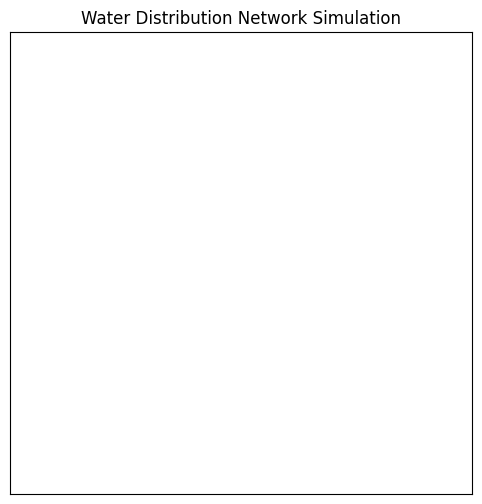

Final Test Episode 1: Total Reward = 298.87


<Figure size 640x480 with 0 Axes>

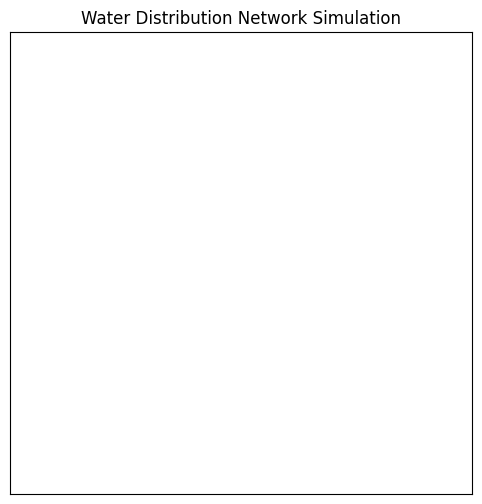

Final Test Episode 2: Total Reward = 259.13


<Figure size 640x480 with 0 Axes>

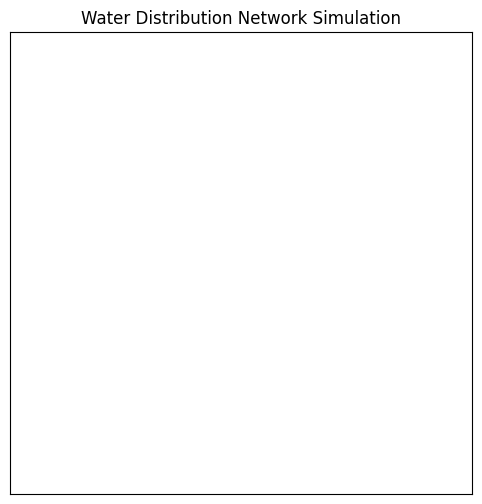

Final Test Episode 3: Total Reward = 330.17


<Figure size 640x480 with 0 Axes>

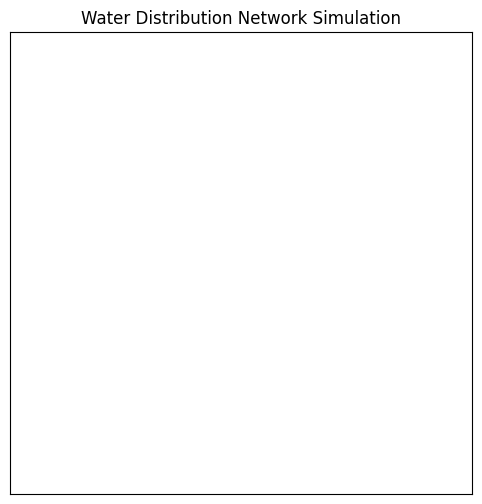

Final Test Episode 4: Total Reward = 346.76


<Figure size 640x480 with 0 Axes>

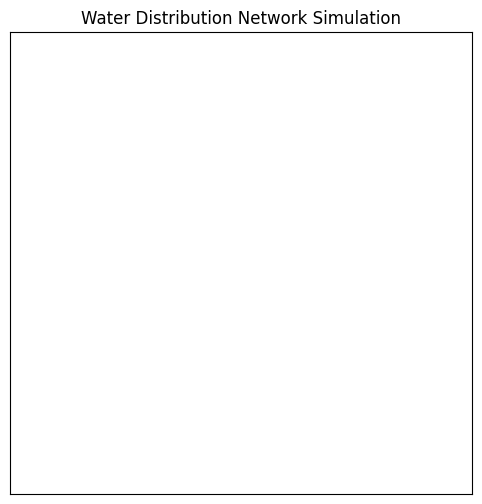

Final Test Episode 5: Total Reward = 205.72

Training and final testing complete.


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys
import os
from pettingzoo import AECEnv
from pettingzoo.utils import wrappers
from pettingzoo.utils.conversions import aec_to_parallel
from pettingzoo.utils.agent_selector import agent_selector
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.animation as animation
import imageio.v2 as imageio
from google.colab import drive

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 3. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand, demand_std_dev=0.1):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.demand_std_dev = demand_std_dev
        self.water_received = 0.0
        self.demand_met = False

    def generate_demand(self):
        fluctuation = np.random.normal(0, self.demand_std_dev)
        self.current_demand = max(0.0, self.base_demand * (1 + fluctuation))
        self.water_received = 0.0
        self.demand_met = False
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        if self.water_received >= self.current_demand:
            self.demand_met = True
        else:
            self.demand_met = False

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 4. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 5. Pipe Class ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- 6. New Function: Load and Preprocess Precipitation Data ---
def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath)
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    precipitation_mm = precipitation_mm.fillna(0)
    precipitation_mm = precipitation_mm.clip(lower=0)
    print(f"Loaded precipitation data from {filepath}...")
    return precipitation_mm

# --- 7. WaterDistributionEnv (PettingZoo AEC Environment) ---
class RawWaterDistributionEnv(AECEnv):
    metadata = {"render_modes": ["human"], "name": "water_distribution_v0", "is_parallelizable": True}

    def __init__(self, reservoir_capacity, initial_reservoir_level,
                     precipitation_data,
                     initial_base_inflow_rate,
                     demand_zone_base_demands,
                     valve_max_flow_rates,
                     pipe_capacities,
                     num_actions_per_agent=3,
                     render_mode=None,
                     max_timesteps=100):
        super().__init__()
        self.reservoir = Reservoir(reservoir_capacity, initial_reservoir_level, initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in pipe_capacities]
        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal for this setup.")
        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.time_step_counter = 0
        self.max_timesteps = max_timesteps
        self.precipitation_data = precipitation_data
        self.current_sim_day_idx = 0
        self.precipitation_to_inflow_scale = 50.0
        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
                high=np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32),
                shape=(4,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }
        self.global_observation_space = spaces.Box(
            low=np.array([0.0] + [0.0] * len(self.possible_agents), dtype=np.float32),
            high=np.array([self.reservoir.capacity] + [dz.base_demand * 2.0 for dz in self.demand_zones], dtype=np.float32),
            shape=(1 + len(self.possible_agents),),
            dtype=np.float32
        )
        self.num_actions_per_agent = num_actions_per_agent
        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }
        self.render_mode = render_mode
        self.fig = None
        self.ax = None
        self.viewer = None
        self.frames = []
        self.rewards = {agent: 0 for agent in self.possible_agents}
        self.terminations = {agent: False for agent in self.possible_agents}
        self.truncations = {agent: False for agent in self.possible_agents}
        self.infos = {agent: {} for agent in self.possible_agents}
        self.state = {}
        self.observations = {agent: None for agent in self.possible_agents}
        self._agent_selector = agent_selector(self.possible_agents)
        self._current_aec_agent = self._agent_selector.next() if self.possible_agents else None

    @property
    def agent_selection(self):
        return self._current_aec_agent

    @property
    def _cumulative_rewards(self):
        return self.rewards

    def observation_space(self, agent: str):
        return self.observation_spaces[agent]

    def action_space(self, agent: str):
        return self.action_spaces[agent]

    def _get_obs_dict(self):
        observations = {}
        if len(self.demand_zones) > 1:
            total_demand = sum(dz.current_demand for dz in self.demand_zones)
        else:
            total_demand = self.demand_zones[0].current_demand
        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            normalized_demand = self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0)
            if len(self.demand_zones) > 1:
                if total_demand > 0:
                    relative_demand = self.demand_zones[i].current_demand / total_demand
                else:
                    relative_demand = 0.5
                obs = np.array([
                    normalized_level, normalized_demand, self.valves[i].get_setting(), relative_demand
                ], dtype=np.float32)
            else:
                obs = np.array([
                    normalized_level, normalized_demand, self.valves[i].get_setting()
                ], dtype=np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        global_obs = [self.reservoir.get_level()]
        for dz in self.demand_zones:
            global_obs.append(dz.current_demand)
        return np.array(global_obs, dtype=np.float32)

    def _get_current_inflow_from_data(self):
        if self.current_sim_day_idx >= len(self.precipitation_data):
            self.current_sim_day_idx = 0
        daily_precipitation_mm = self.precipitation_data.iloc[self.current_sim_day_idx]
        inflow_units = self.reservoir.initial_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)
        return inflow_units

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        self.agents = self.possible_agents[:]
        self._agent_selector.reinit(self.agents)
        self._current_aec_agent = self._agent_selector.next() if self.agents else None
        self.reservoir.level = self.reservoir.initial_level
        self.current_sim_day_idx = random.randint(0, len(self.precipitation_data) - 1)
        self.reservoir.inflow_rate = self._get_current_inflow_from_data()
        for dz in self.demand_zones:
            dz.current_demand = dz.base_demand
            dz.water_received = 0.0
            dz.demand_met = False
        for valve in self.valves:
            valve.set_setting(0.0)
        self.time_step_counter = 0
        self.rewards = {agent: 0 for agent in self.agents}
        self.terminations = {agent: False for agent in self.agents}
        self.truncations = {agent: False for agent in self.agents}
        self.infos = {agent: {} for agent in self.agents}
        self.observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        self.infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}
        self.current_individual_valve_flows = [0.0] * len(self.possible_agents)
        self.frames = []
        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()
        return self.observations, self.infos

    def step(self, action):
        global_terminated_flag = False
        global_truncated_flag = False
        if not isinstance(action, (int, np.integer)):
            if not self.agents:
                dummy_obs = {agent_id: np.zeros(self.observation_spaces[agent_id].shape, dtype=np.float32) for agent_id in self.possible_agents}
                dummy_rewards = {agent_id: 0.0 for agent_id in self.possible_agents}
                dummy_terminations = {agent_id: True for agent_id in self.possible_agents}
                dummy_truncations = {agent_id: True for agent_id in self.possible_agents}
                dummy_infos = {agent_id: {} for agent_id in self.possible_agents}
                dummy_global_obs = np.zeros(self.global_observation_space.shape, dtype=np.float32)
                for agent_id in self.possible_agents:
                    dummy_infos[agent_id]['global_observation'] = dummy_global_obs
                return dummy_obs, dummy_rewards, dummy_terminations, dummy_truncations, dummy_infos
            else:
                raise TypeError(f"Expected action to be int, but got type {type(action)}: {action}. Active agents: {self.agents}")
        current_agent_id = self.agent_selection
        if self.terminations[current_agent_id] or self.truncations[current_agent_id]:
            if self.agents:
                try:
                    self._current_aec_agent = self._agent_selector.next()
                except StopIteration:
                    self._current_aec_agent = None
            else:
                self._current_aec_agent = None
            self.observations = self._get_obs_dict()
            global_obs = self._get_global_obs()
            self.infos[current_agent_id]['global_observation'] = global_obs
            return (
                self.observations[current_agent_id], 0.0, True, True, self.infos[current_agent_id]
            )
        agent_index = self.possible_agents.index(current_agent_id)
        self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action))
        self.current_individual_valve_flows[agent_index] = min(
            self.valves[agent_index].get_flow(),
            self.pipes[agent_index].get_capacity()
        )
        if self._agent_selector.is_last():
            self.time_step_counter += 1
            self.current_sim_day_idx += 1
            self.reservoir.inflow_rate = self._get_current_inflow_from_data()
            sum_of_all_potential_flows = sum(self.current_individual_valve_flows)
            actual_flow_scale = 1.0
            if sum_of_all_potential_flows > 0:
                actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
            else:
                actual_flow_scale = 0.0
            actual_flows_this_timestep = [flow * actual_flow_scale for flow in self.current_individual_valve_flows]
            total_outflow_from_reservoir = sum(actual_flows_this_timestep)
            self.reservoir.update_level(total_outflow_from_reservoir)
            for dz in self.demand_zones:
                dz.generate_demand()
            global_truncated_flag = self.time_step_counter >= self.max_timesteps
            global_penalty_value = 0.0
            fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
            # Increase the penalty for very low reservoir levels and change termination threshold
            if fill_percentage < 0.15:
                global_penalty_value -= 2.0  # Increased from -1.0
                if fill_percentage < 0.05: # Changed from 0.01 to 0.05
                   global_terminated_flag = True
                   global_penalty_value -= 10.0 # Increased from -5.0 for a severe penalty
            if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
                wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
                global_penalty_value -= wasted_water * 0.01
            for i, agent_id_loop in enumerate(self.possible_agents):
                dz = self.demand_zones[i]
                dz.receive_water(actual_flows_this_timestep[i])
                reward_for_agent_loop = 0.0
                demand_norm = max(dz.current_demand, 1e-6)
                reward_for_agent_loop += (min(dz.water_received, dz.current_demand) / demand_norm) * 2
                shortage = dz.get_demand_shortage()
                if fill_percentage > 0.5 and shortage > 0:
                    reward_for_agent_loop -= shortage * 0.05
                reward_for_agent_loop -= (shortage / demand_norm) * 0.5
                oversupply = max(0, dz.water_received - dz.current_demand)
                reward_for_agent_loop -= oversupply * 0.10
                survival_reward = 0.2
                reward_for_agent_loop += survival_reward
                reward_for_agent_loop += global_penalty_value
                self.rewards[agent_id_loop] = reward_for_agent_loop
                if global_terminated_flag:
                    self.terminations[agent_id_loop] = True
                if global_truncated_flag:
                    self.truncations[agent_id_loop] = True
            self.agents = [
                agent for agent in self.possible_agents
                if not (self.terminations[agent] or self.truncations[agent])
            ]
            self._agent_selector.reinit(self.agents)
            self.current_individual_valve_flows = [0.0] * len(self.possible_agents)
        if self.agents:
            try:
                self._current_aec_agent = self._agent_selector.next()
            except StopIteration:
                self._current_aec_agent = None
        else:
            self._current_aec_agent = None
        self.observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        for agent_id_loop in self.possible_agents:
            self.infos[agent_id_loop]['global_observation'] = global_obs
        if self.render_mode == "human":
            self.render_live()
        return (
            self.observations.get(current_agent_id, np.zeros(self.observation_spaces[current_agent_id].shape, dtype=np.float32)),
            self.rewards.get(current_agent_id, 0.0),
            self.terminations.get(current_agent_id, True),
            self.truncations.get(current_agent_id, True),
            self.infos.get(current_agent_id, {'global_observation': np.zeros(self.global_observation_space.shape, dtype=np.float32)}),
        )

    def observe(self, agent: str):
        if agent not in self.observations or self.terminations[agent] or self.truncations[agent]:
            return np.zeros(self.observation_spaces[agent].shape, dtype=np.float32)
        return self.observations[agent]

    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)

    def render(self):
        if self.render_mode == "human":
            if self.fig is None:
                self._init_render_plot()
            self.render_live()
        else:
            pass

    def render_live(self):
        if self.ax is None:
            return
        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")
        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)
        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)
        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                     f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                     ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                     f"Inflow: {self.reservoir.inflow_rate:.1f}",
                     ha='center', va='top', fontsize=8, color='green')
        valve_y_start = 3.5
        demand_x_start = 6
        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3
            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')
            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                           linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)
            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')
            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                            linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            self.ax.text(demand_x_start + 1, valve_y + 0.25, f"Zone {i+1}", ha='center', va='center', fontsize=9)
            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)
        plt.draw()
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3]
        self.frames.append(image)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()

# --- 8. Actor and Critic Networks for MAPPO ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_policy = nn.Linear(128, action_dim)
    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        logits = self.fc_policy(x)
        logits = torch.clamp(logits, min=-5.0, max=5.0)
        return logits

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)
    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        return self.fc_value(x)

# --- 9. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
        self.batch_size = batch_size
    def store_transition(self, global_state, individual_states_dict, actions_dict, log_probs_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum)
        self.dones.append(global_done)
        for agent_id in individual_states_dict:
            self.individual_states[agent_id].append(individual_states_dict[agent_id])
            self.actions[agent_id].append(actions_dict.get(agent_id, 0))
            self.log_probs[agent_id].append(log_probs_dict.get(agent_id, 0.0))
    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 10. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space, lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95, clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64):
        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size
        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}
        self.critic_net = CriticNetwork(global_observation_space.shape[0]).to(device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)
        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n
            actor_net = ActorNetwork(obs_dim, action_dim).to(device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)
        self.memory = PPOMemory(ppo_batch_size)
        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")
    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}
        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(device)
        global_value = self.critic_net(global_obs_tensor).item()
        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(device)
            logits = self.actor_nets[agent_id](state_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()
        return actions, log_probs, global_value
    def learn(self):
        if not self.memory.global_states:
            print("Memory is empty, skipping learn step.")
            return
        try:
            global_states_tensor = torch.tensor(np.array(self.memory.global_states)).float().to(device)
            global_values_tensor = torch.tensor(np.array(self.memory.values)).float().to(device)
            global_rewards_tensor = torch.tensor(np.array(self.memory.rewards)).float().to(device)
            global_dones_tensor = torch.tensor(np.array(self.memory.dones)).float().to(device)
            individual_states_tensors = {aid: torch.tensor(np.array(self.memory.individual_states[aid])).float().to(device) for aid in self.possible_agents}
            individual_actions_tensors = {aid: torch.tensor(np.array(self.memory.actions[aid])).long().to(device) for aid in self.possible_agents}
            individual_old_log_probs_tensors = {aid: torch.tensor(np.array(self.memory.log_probs[aid])).float().to(device) for aid in self.possible_agents}
        except ValueError as e:
            print(f"Error converting memory to tensors: {e}")
            print("This often happens if the number of steps stored for each agent is not consistent.")
            print(f"Lengths: Global: {len(self.memory.global_states)}")
            for aid in self.possible_agents:
                print(f"  Agent {aid} states: {len(self.memory.individual_states[aid])}")
                print(f"  Agent {aid} actions: {len(self.memory.actions[aid])}")
                print(f"  Agent {aid} log_probs: {len(self.memory.log_probs[aid])}")
            self.memory.clear_memory()
            return
        returns = []
        advantage_values = []
        last_gae_lam = 0
        for t in reversed(range(len(global_rewards_tensor))):
            if t == len(global_rewards_tensor) - 1:
                next_non_terminal = 1.0 - global_dones_tensor[t]
                next_value = 0.0
            else:
                next_non_terminal = 1.0 - global_dones_tensor[t+1]
                next_value = global_values_tensor[t+1]
            delta = global_rewards_tensor[t] + self.gamma * next_value * next_non_terminal - global_values_tensor[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantage_values.insert(0, last_gae_lam)
            returns.insert(0, last_gae_lam + global_values_tensor[t])
        advantages = torch.tensor(advantage_values).float().to(device)
        returns = torch.tensor(returns).float().to(device)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        if torch.isnan(advantages).any():
            print("Warning: NaN found in advantages during normalization. Setting to zero.")
            advantages = torch.zeros_like(advantages)
        for epoch in range(self.n_epochs):
            batches = self.memory.generate_batches()
            for batch_indices in batches:
                self.critic_optimizer.zero_grad()
                critic_predicted_values = self.critic_net(global_states_tensor[batch_indices]).squeeze(-1)
                critic_loss = F.mse_loss(critic_predicted_values, returns[batch_indices])
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=1.0)
                self.critic_optimizer.step()
                for agent_id in self.possible_agents:
                    self.actor_optimizers[agent_id].zero_grad()
                    current_logits = self.actor_nets[agent_id](individual_states_tensors[agent_id][batch_indices])
                    current_dist = Categorical(logits=current_logits)
                    current_log_probs = current_dist.log_prob(individual_actions_tensors[agent_id][batch_indices])
                    ratio = torch.exp(current_log_probs - individual_old_log_probs_tensors[agent_id][batch_indices])
                    surr1 = ratio * advantages[batch_indices]
                    surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages[batch_indices]
                    actor_loss = -torch.min(surr1, surr2).mean()
                    entropy_loss = current_dist.entropy().mean()
                    actor_loss -= 0.05 * entropy_loss
                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_nets[agent_id].parameters(), max_norm=1.0)
                    self.actor_optimizers[agent_id].step()
        self.memory.clear_memory()

# --- 11. Make Environment Function ---
def make_env(args):
    def _env_fn():
        env = RawWaterDistributionEnv(
            reservoir_capacity=args['reservoir_capacity'],
            initial_reservoir_level=args['initial_reservoir_level'],
            precipitation_data=args['precipitation_data'],
            initial_base_inflow_rate=args['initial_base_inflow_rate'],
            demand_zone_base_demands=args['demand_zone_base_demands'],
            valve_max_flow_rates=args['valve_max_flow_rates'],
            pipe_capacities=args['pipe_capacities'],
            num_actions_per_agent=args['num_actions_per_agent'],
            max_timesteps=args['max_timesteps'],
            render_mode=args['render_mode']
        )
        env = wrappers.AssertOutOfBoundsWrapper(env)
        env = wrappers.OrderEnforcingWrapper(env)
        env = aec_to_parallel(env)
        return env
    return _env_fn

# --- 12. Main Execution Block for Model Loading and Analysis ---
if __name__ == "__main__":
    # --- Existing Setup Code (copy from your original script) ---
    # This includes loading precipitation data and initializing the agent with the original env_args.
    # Also, ensure you have the correct device setup (e.g., torch.device("cuda" ...))

    # Check for GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load and preprocess precipitation data
    precipitation_filepath = '/content/drive/MyDrive/4083151.csv'
    try:
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_filepath)
    except FileNotFoundError:
        print(f"Error: Precipitation data file not found at {precipitation_filepath}.")
        exit()

    # Define the environment arguments (must match your training setup)
    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'precipitation_data': preprocessed_precipitation,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': 100,
        'render_mode': None
    }

    # Initialize the agent with your training hyperparameters
    raw_env_instance = RawWaterDistributionEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=raw_env_instance.possible_agents,
        observation_spaces=raw_env_instance.observation_spaces,
        action_spaces=raw_env_instance.action_spaces,
        global_observation_space=raw_env_instance.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128
    )
    raw_env_instance.close()

    # --- Load the saved model to resume training ---
    model_path = '/content/drive/MyDrive/RL_Models/mappo_water_distribution_model.pth'
    try:
        print(f"\nLoading model from {model_path} to resume training...")
        agent_state = torch.load(model_path, map_location=device)
        agent.actor_nets.load_state_dict(agent_state['actor_nets'])
        agent.critic_net.load_state_dict(agent_state['critic_net'])
        print("Model loaded successfully. Resuming training.")
    except FileNotFoundError:
        print(f"Model not found at {model_path}. Starting training from scratch.")

    # --- PHASE 1: Fine-tuning on a standard environment ---
    print("\n--- Phase 1: Fine-tuning on standard conditions ---")
    env = make_env(env_args.copy())()
    num_episodes_phase1 = 10000
    for episode in range(num_episodes_phase1):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, global_value_for_step = agent.choose_action(active_observations, global_observation)

            actions_for_env_step = {agent_id: all_agents_actions.get(agent_id, 0) for agent_id in env.possible_agents}
            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_for_env_step)

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, global_value_for_step, sum(rewards.values()),
                any(terminations.values()) or any(truncations.values())
            )
            observations = next_observations
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()
        if episode % 100 == 0:
            print(f"Phase 1 - Episode {episode}/{num_episodes_phase1} complete.")
    env.close()

    # --- PHASE 2: Training on a more challenging drought environment ---
    print("\n--- Phase 2: Training on drought conditions ---")
    drought_env_args = env_args.copy()
    drought_env_args['initial_base_inflow_rate'] = 20.0
    drought_env_args['precipitation_to_inflow_scale'] = 0.5
    drought_env_args['initial_reservoir_level'] = 400.0
    drought_env = make_env(drought_env_args)()

    num_episodes_phase2 = 10000
    for episode in range(num_episodes_phase2):
        observations, infos = drought_env.reset(seed=random.randint(0, 100000))
        global_observation = infos[drought_env.possible_agents[0]]['global_observation']
        while drought_env.agents:
            active_observations = {aid: observations[aid] for aid in drought_env.agents}
            all_agents_actions, all_agents_log_probs, global_value_for_step = agent.choose_action(active_observations, global_observation)

            actions_for_env_step = {agent_id: all_agents_actions.get(agent_id, 0) for agent_id in drought_env.possible_agents}
            next_observations, rewards, terminations, truncations, next_infos = drought_env.step(actions_for_env_step)

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, global_value_for_step, sum(rewards.values()),
                any(terminations.values()) or any(truncations.values())
            )
            observations = next_observations
            global_observation = next_infos[drought_env.possible_agents[0]]['global_observation']

        agent.learn()
        if episode % 100 == 0:
            print(f"Phase 2 - Episode {episode}/{num_episodes_phase2} complete.")
    drought_env.close()

    # --- Final test episodes with the newly trained model ---
    print("\n--- Final Testing with the improved policy ---")
    test_env_args = env_args.copy()
    test_env_args['render_mode'] = "human"
    test_env = make_env(test_env_args)()

    num_final_tests = 5
    for i in range(num_final_tests):
        observations, infos = test_env.reset(seed=random.randint(0, 100000))
        global_observation = infos[test_env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0
        while test_env.agents:
            active_observations = {aid: observations[aid] for aid in test_env.agents}
            all_agents_test_actions, _, _ = agent.choose_action(active_observations, global_observation)
            test_actions = {agent_id: all_agents_test_actions.get(agent_id, 0) for agent_id in test_env.possible_agents}
            next_observations, rewards, terminations, truncations, next_infos = test_env.step(test_actions)
            episode_reward_sum += sum(rewards.values())
            test_env.render()
            observations = next_observations
            global_observation = next_infos[test_env.possible_agents[0]]['global_observation']
        test_env.close()
        gif_path = f'final_improved_policy_test_{i+1:02d}.gif'
        imageio.mimsave(gif_path, test_env.aec_env.frames, fps=10)
        print(f"Final Test Episode {i+1}: Total Reward = {episode_reward_sum:.2f}")

    print("\nTraining and final testing complete.")

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys
import os
from pettingzoo import AECEnv
from pettingzoo.utils import wrappers
from pettingzoo.utils.conversions import aec_to_parallel
from pettingzoo.utils.agent_selector import agent_selector
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.animation as animation
import imageio.v2 as imageio
from google.colab import drive

# Define a communication vector size for the new feature
COMMUNICATION_VECTOR_SIZE = 4

# --- 1. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 2. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand, demand_std_dev=0.1):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.demand_std_dev = demand_std_dev
        self.water_received = 0.0
        self.demand_met = False

    def generate_demand(self):
        fluctuation = np.random.normal(0, self.demand_std_dev)
        self.current_demand = max(0.0, self.base_demand * (1 + fluctuation))
        self.water_received = 0.0
        self.demand_met = False
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        if self.water_received >= self.current_demand:
            self.demand_met = True
        else:
            self.demand_met = False

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 3. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 4. Pipe Class ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- 5. New Function: Load and Preprocess Precipitation Data ---
def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath)
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    precipitation_mm = precipitation_mm.fillna(0)
    precipitation_mm = precipitation_mm.clip(lower=0)
    print(f"Loaded precipitation data from {filepath}...")
    return precipitation_mm

# --- 6. WaterDistributionEnv (PettingZoo AEC Environment) ---
class RawWaterDistributionEnv(AECEnv):
    metadata = {"render_modes": ["human"], "name": "water_distribution_v0", "is_parallelizable": True}

    def __init__(self, reservoir_capacity, initial_reservoir_level,
                 precipitation_data, initial_base_inflow_rate,
                 demand_zone_base_demands, valve_max_flow_rates,
                 pipe_capacities, num_actions_per_agent=3, render_mode=None,
                 max_timesteps=100, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()

        self.reservoir_capacity = reservoir_capacity
        self.initial_reservoir_level = initial_reservoir_level
        self.initial_base_inflow_rate = initial_base_inflow_rate
        self.demand_zone_base_demands = demand_zone_base_demands
        self.valve_max_flow_rates = valve_max_flow_rates
        self.pipe_capacities = pipe_capacities
        self.num_actions_per_agent = num_actions_per_agent
        self.max_timesteps = max_timesteps

        self.reservoir = Reservoir(reservoir_capacity, initial_reservoir_level, initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in pipe_capacities]

        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal for this setup.")

        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.time_step_counter = 0

        self.precipitation_data = precipitation_data
        self.current_sim_day_idx = 0
        self.precipitation_to_inflow_scale = 50.0

        self.communication_vector_size = communication_vector_size
        self.communication_channel = np.zeros(
            (len(self.possible_agents), self.communication_vector_size),
            dtype=np.float32
        )

        base_obs_size = 4
        num_agents = len(self.possible_agents)
        new_obs_size = base_obs_size + (num_agents * self.communication_vector_size)
        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.zeros(new_obs_size, dtype=np.float32),
                high=np.ones(new_obs_size, dtype=np.float32),
                shape=(new_obs_size,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }

        global_obs_dim = 1 + num_agents + (num_agents * self.communication_vector_size)
        self.global_observation_space = spaces.Box(
            low=np.zeros(global_obs_dim, dtype=np.float32),
            high=np.ones(global_obs_dim, dtype=np.float32),
            shape=(global_obs_dim,),
            dtype=np.float32
        )

        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }

        self.render_mode = render_mode
        self.fig = None
        self.ax = None
        self.viewer = None
        self.frames = []
        self.rewards = {agent: 0 for agent in self.possible_agents}
        self.terminations = {agent: False for agent in self.possible_agents}
        self.truncations = {agent: False for agent in self.possible_agents}
        self.infos = {agent: {} for agent in self.possible_agents}
        self.state = {}
        self.observations = {agent: None for agent in self.possible_agents}
        self._agent_selector = agent_selector(self.possible_agents)
        self._current_aec_agent = self._agent_selector.next() if self.possible_agents else None

    @property
    def agent_selection(self):
        return self._current_aec_agent

    @property
    def _cumulative_rewards(self):
        return self.rewards

    def observation_space(self, agent: str):
        return self.observation_spaces[agent]

    def action_space(self, agent: str):
        return self.action_spaces[agent]

    def _get_obs_dict(self):
        observations = {}

        total_demand = sum(dz.current_demand for dz in self.demand_zones)

        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            normalized_demand = self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0)

            if total_demand > 0:
                relative_demand = self.demand_zones[i].current_demand / total_demand
            else:
                relative_demand = 0.5

            base_obs = [normalized_level, normalized_demand, self.valves[i].get_setting(), relative_demand]

            obs = np.concatenate([
                base_obs,
                self.communication_channel.flatten()
            ], dtype=np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        # CORRECTED: Normalizing the global observation for better network performance
        normalized_reservoir_level = self.reservoir.get_level() / self.reservoir.capacity
        normalized_demands = [dz.current_demand / (dz.base_demand * 2.0) for dz in self.demand_zones]

        global_obs = [normalized_reservoir_level]
        global_obs.extend(normalized_demands)
        global_obs.extend(self.communication_channel.flatten())

        return np.array(global_obs, dtype=np.float32)

    def _get_current_inflow_from_data(self):
        if self.current_sim_day_idx >= len(self.precipitation_data):
            self.current_sim_day_idx = 0
        daily_precipitation_mm = self.precipitation_data.iloc[self.current_sim_day_idx]
        inflow_units = self.reservoir.initial_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)
        return inflow_units

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        self.agents = self.possible_agents[:]
        self._agent_selector.reinit(self.agents)
        self._current_aec_agent = self._agent_selector.next() if self.agents else None
        self.reservoir.level = self.reservoir.initial_level
        self.current_sim_day_idx = random.randint(0, len(self.precipitation_data) - 1)
        self.reservoir.inflow_rate = self._get_current_inflow_from_data()
        for dz in self.demand_zones:
            dz.current_demand = dz.base_demand
            dz.water_received = 0.0
            dz.demand_met = False
        for valve in self.valves:
            valve.set_setting(0.0)
        self.time_step_counter = 0
        self.rewards = {agent: 0 for agent in self.agents}
        self.terminations = {agent: False for agent in self.agents}
        self.truncations = {agent: False for agent in self.agents}
        self.infos = {agent: {} for agent in self.agents}
        self.communication_channel.fill(0)
        self.observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        self.infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}
        self.current_individual_valve_flows = [0.0] * len(self.possible_agents)
        self.frames = []
        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()
        return self.observations, self.infos

    def step(self, actions_and_comms):
        global_terminated_flag = False
        global_truncated_flag = False

        current_agent_id = self.agent_selection

        agent_index = self.possible_agents.index(current_agent_id)

        if not isinstance(actions_and_comms, dict) or current_agent_id not in actions_and_comms:
             if self.agents:
                self._current_aec_agent = self._agent_selector.next()
             else:
                self._current_aec_agent = None
             self.observations = self._get_obs_dict()
             global_obs = self._get_global_obs()
             if current_agent_id in self.infos:
                 self.infos[current_agent_id]['global_observation'] = global_obs

             return (
                 self.observations.get(current_agent_id, np.zeros(self.observation_spaces[current_agent_id].shape, dtype=np.float32)),
                 self.rewards.get(current_agent_id, 0.0),
                 self.terminations.get(current_agent_id, True),
                 self.truncations.get(current_agent_id, True),
                 self.infos.get(current_agent_id, {'global_observation': np.zeros(self.global_observation_space.shape, dtype=np.float32)}),
             )

        action_value = actions_and_comms[current_agent_id]['action']
        comm_vector = actions_and_comms[current_agent_id]['comm']

        self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action_value))

        self.communication_channel[agent_index] = comm_vector

        self.current_individual_valve_flows[agent_index] = min(
            self.valves[agent_index].get_flow(),
            self.pipes[agent_index].get_capacity()
        )

        if self._agent_selector.is_last():
            self.time_step_counter += 1
            self.current_sim_day_idx += 1
            self.reservoir.inflow_rate = self._get_current_inflow_from_data()
            sum_of_all_potential_flows = sum(self.current_individual_valve_flows)
            actual_flow_scale = 1.0
            if sum_of_all_potential_flows > 0:
                actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
            else:
                actual_flow_scale = 0.0
            actual_flows_this_timestep = [flow * actual_flow_scale for flow in self.current_individual_valve_flows]
            total_outflow_from_reservoir = sum(actual_flows_this_timestep)
            self.reservoir.update_level(total_outflow_from_reservoir)
            for dz in self.demand_zones:
                dz.generate_demand()
            global_truncated_flag = self.time_step_counter >= self.max_timesteps
            global_penalty_value = 0.0
            fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
            if fill_percentage > 0.95:
                global_penalty_value -= 0.1
            elif fill_percentage < 0.15:
                penalty_scale = (0.15 - fill_percentage) / 0.15
                global_penalty_value -= penalty_scale * 1.0
                if fill_percentage < 0.01:
                    global_terminated_flag = True
                    global_penalty_value -= 5.0
            if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
                wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
                global_penalty_value -= wasted_water * 0.01
            for i, agent_id_loop in enumerate(self.possible_agents):
                dz = self.demand_zones[i]
                dz.receive_water(actual_flows_this_timestep[i])
                reward_for_agent_loop = 0.0
                demand_norm = max(dz.current_demand, 1e-6)
                reward_for_agent_loop += (min(dz.water_received, dz.current_demand) / demand_norm) * 2
                shortage = dz.get_demand_shortage()
                if fill_percentage > 0.5 and shortage > 0:
                    reward_for_agent_loop -= shortage * 0.05
                reward_for_agent_loop -= (shortage / demand_norm) * 0.5
                oversupply = max(0, dz.water_received - dz.current_demand)
                reward_for_agent_loop -= oversupply * 0.05
                survival_reward = 0.2
                reward_for_agent_loop += survival_reward
                reward_for_agent_loop += global_penalty_value
                self.rewards[agent_id_loop] = reward_for_agent_loop
                if global_terminated_flag:
                    self.terminations[agent_id_loop] = True
                if global_truncated_flag:
                    self.truncations[agent_id_loop] = True
            self.agents = [
                agent for agent in self.possible_agents
                if not (self.terminations[agent] or self.truncations[agent])
            ]
            self._agent_selector.reinit(self.agents)
            self.current_individual_valve_flows = [0.0] * len(self.possible_agents)
        if self.agents:
            try:
                self._current_aec_agent = self._agent_selector.next()
            except StopIteration:
                self._current_aec_agent = None
        else:
            self._current_aec_agent = None
        self.observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        for agent_id_loop in self.possible_agents:
            self.infos[agent_id_loop]['global_observation'] = global_obs
        if self.render_mode == "human":
            self.render_live()
        return (
            self.observations.get(current_agent_id, np.zeros(self.observation_spaces[current_agent_id].shape, dtype=np.float32)),
            self.rewards.get(current_agent_id, 0.0),
            self.terminations.get(current_agent_id, True),
            self.truncations.get(current_agent_id, True),
            self.infos.get(current_agent_id, {'global_observation': np.zeros(self.global_observation_space.shape, dtype=np.float32)}),
        )

    def observe(self, agent: str):
        if agent not in self.observations or self.terminations[agent] or self.truncations[agent]:
            return np.zeros(self.observation_spaces[agent].shape, dtype=np.float32)
        return self.observations[agent]

    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)

    def render(self):
        if self.render_mode == "human":
            if self.fig is None:
                self._init_render_plot()
            self.render_live()
        else:
            pass

    def render_live(self):
        if self.ax is None:
            return
        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")
        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)
        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)
        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                     f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                     ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                     f"Inflow: {self.reservoir.inflow_rate:.1f}",
                     ha='center', va='top', fontsize=8, color='green')
        valve_y_start = 3.5
        demand_x_start = 6
        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3
            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')
            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                           linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)
            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')
            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                            linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            self.ax.text(demand_x_start + 1, valve_y + 0.25, f"Zone {i+1}", ha='center', va='center', fontsize=9)
            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)
        plt.draw()
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3]
        self.frames.append(image)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()

# --- 7. Actor and Critic Networks for MAPPO ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)

        self.fc_policy = nn.Linear(128, action_dim)
        self.fc_communication = nn.Linear(128, communication_vector_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)

        logits = self.fc_policy(x)
        communication_vector = torch.tanh(self.fc_communication(x))

        return logits, communication_vector

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        return self.fc_value(x)

# --- 8. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
        self.batch_size = batch_size

    def store_transition(self, global_state, individual_states_dict, actions_dict,
                         log_probs_dict, communication_vectors_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum)
        self.dones.append(global_done)

        for agent_id in individual_states_dict:
            self.individual_states[agent_id].append(individual_states_dict[agent_id])
            self.actions[agent_id].append(actions_dict.get(agent_id, 0))
            self.log_probs[agent_id].append(log_probs_dict.get(agent_id, 0.0))
            self.communication_vectors[agent_id].append(communication_vectors_dict.get(agent_id, np.zeros(COMMUNICATION_VECTOR_SIZE)))

    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []

    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 9. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space,
                 lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95,
                 clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64, communication_vector_size=COMMUNICATION_VECTOR_SIZE):

        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size
        self.communication_vector_size = communication_vector_size

        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}

        global_obs_dim = global_observation_space.shape[0]
        self.critic_net = CriticNetwork(global_obs_dim).to(device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n

            actor_net = ActorNetwork(obs_dim, action_dim, communication_vector_size).to(device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)

        self.memory = PPOMemory(ppo_batch_size)

        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")

    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}
        communication_vectors = {}

        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(device)
        global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(device)

            logits, comm_vector = self.actor_nets[agent_id](state_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()
            communication_vectors[agent_id] = comm_vector.detach().cpu().numpy().flatten()

        return actions, log_probs, communication_vectors, global_value

    def learn(self):
        pass

# --- 10. Make Environment Function ---
def make_env(args):
    def _env_fn():
        env = RawWaterDistributionEnv(
            reservoir_capacity=args['reservoir_capacity'],
            initial_reservoir_level=args['initial_reservoir_level'],
            precipitation_data=args['precipitation_data'],
            initial_base_inflow_rate=args['initial_base_inflow_rate'],
            demand_zone_base_demands=args['demand_zone_base_demands'],
            valve_max_flow_rates=args['valve_max_flow_rates'],
            pipe_capacities=args['pipe_capacities'],
            num_actions_per_agent=args['num_actions_per_agent'],
            max_timesteps=args['max_timesteps'],
            render_mode=args['render_mode'],
            communication_vector_size=args['communication_vector_size']
        )
        env = wrappers.AssertOutOfBoundsWrapper(env)
        env = wrappers.OrderEnforcingWrapper(env)
        env = aec_to_parallel(env)
        return env
    return _env_fn

# --- 11. The Main Training Block (Example) ---
if __name__ == "__main__":
    drive.mount('/content/drive')

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    def load_and_preprocess_precipitation_data_local(filepath):
        df = pd.read_csv(filepath)
        df['DATE'] = pd.to_datetime(df['DATE'])
        df = df.set_index('DATE')
        precipitation_mm = df['PRCP'] / 10.0
        precipitation_mm = precipitation_mm.fillna(0)
        precipitation_mm = precipitation_mm.clip(lower=0)
        return precipitation_mm

    precipitation_filepath = '/content/4083151.csv'
    try:
        preprocessed_precipitation = load_and_preprocess_precipitation_data_local(precipitation_filepath)
    except FileNotFoundError:
        print(f"Error: Precipitation data file not found at {precipitation_filepath}.")
        exit()

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'precipitation_data': preprocessed_precipitation,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': 100,
        'render_mode': None,
        'communication_vector_size': 4
    }

    raw_env_instance = RawWaterDistributionEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=raw_env_instance.possible_agents,
        observation_spaces=raw_env_instance.observation_spaces,
        action_spaces=raw_env_instance.action_spaces,
        global_observation_space=raw_env_instance.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=4
    )
    raw_env_instance.close()

    env = make_env(env_args)()
    num_episodes = 1000

    for episode in range(num_episodes):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        # Define global_observation for the first step
        global_observation = infos[env.possible_agents[0]]['global_observation']
        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}

            # The agent's method now correctly handles a dictionary of active agents

            actions, log_probs, comm_vectors, global_value = agent.choose_action(active_observations, global_observation)

            actions_for_env_step = {
                agent_id: actions[agent_id]
                for agent_id in env.agents
            }

            # The environment step correctly takes a dictionary of actions for active agents
            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_for_env_step)

            agent.memory.store_transition(
                infos[env.possible_agents[0]]['global_observation'],
                observations,
                actions,
                log_probs,
                comm_vectors,
                global_value,
                sum(rewards.values()),
                any(terminations.values()) or any(truncations.values())
            )

            # Update variables for the next iteration
            observations = next_observations
            # --- CORRECTED: Update global_observation for the next iteration ---
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        if episode % 100 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {sum(rewards.values()):.2f}")

    env.close()
    print("\nTraining complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)


KeyboardInterrupt: 

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys
import os
from pettingzoo.utils import ParallelEnv, wrappers
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.animation as animation
import imageio.v2 as imageio
from google.colab import drive

# Define a communication vector size for the new feature
COMMUNICATION_VECTOR_SIZE = 4
MODEL_SAVE_PATH = '/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model.pth'

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 3. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.real_demand_data = None
        self.current_timestep_idx = 0

    def generate_demand(self):
        if self.real_demand_data is not None and self.current_timestep_idx < len(self.real_demand_data):
            self.current_demand = self.real_demand_data.iloc[self.current_timestep_idx]
        else:
            self.current_demand = self.base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.current_timestep_idx += 1
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        self.demand_met = self.water_received >= self.current_demand

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 4. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 5. Pipe Class ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- 6. Load and Preprocess Real Data ---
def load_and_preprocess_seattle_data(filepath, num_agents):
    try:
        # Try reading as Excel first
        if filepath.endswith('.xlsx'):
            df = pd.read_excel(filepath)
        else: # Assume CSV if not Excel
            df = pd.read_csv(filepath, encoding='latin1', engine='python')

        if 'START_DT' not in df.columns or 'WT_CONS_CCF' not in df.columns:
            raise ValueError("Required columns 'START_DT' or 'WT_CONS_CCF' not found in the data.")

        df['START_DT'] = pd.to_datetime(df['START_DT'])
        df['WT_CONS_CCF'] = df['WT_CONS_CCF'].fillna(0).clip(lower=0)
        daily_consumption = df.groupby(df['START_DT'].dt.date)['WT_CONS_CCF'].sum()
        daily_consumption_mg = daily_consumption * 748.052 / 1000000
        per_agent_demand_mg = [daily_consumption_mg / num_agents] * num_agents
        return per_agent_demand_mg
    except FileNotFoundError:
        print(f"Error: Data file not found at {filepath}.")
        return None
    except pd.errors.ParserError as e:
        print(f"Error parsing data file {filepath}: {e}")
        print("Please ensure the file is a valid CSV or Excel file.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred during data loading from {filepath}: {e}")
        return None


def load_and_preprocess_precipitation_data(filepath):
    try:
        df = pd.read_csv(filepath, encoding='latin1', engine='python')
        if 'DATE' not in df.columns or 'PRCP' not in df.columns:
             raise ValueError("Required columns 'DATE' or 'PRCP' not found in the precipitation data.")

        df['DATE'] = pd.to_datetime(df['DATE'])
        df = df.set_index('DATE')
        precipitation_mm = df['PRCP'] / 10.0
        precipitation_mm = precipitation_mm.fillna(0)
        precipitation_mm = precipitation_mm.clip(lower=0)
        return precipitation_mm
    except FileNotFoundError:
        print(f"Error: Precipitation data file not found at {filepath}.")
        return None
    except pd.errors.ParserError as e:
        print(f"Error parsing precipitation data file {filepath}: {e}")
        print("Please ensure the precipitation file is a valid CSV.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred during precipitation data loading from {filepath}: {e}")
        return None


# --- 7. WaterDistributionParallelEnv (New Parallel Environment) ---
class WaterDistributionParallelEnv(ParallelEnv):
    metadata = {"render_modes": ["human"], "name": "water_distribution_v0"}

    def __init__(self, **kwargs):
        self.reservoir_capacity = kwargs.get('reservoir_capacity')
        self.initial_reservoir_level = kwargs.get('initial_reservoir_level')
        self.initial_base_inflow_rate = kwargs.get('initial_base_inflow_rate')
        self.demand_zone_base_demands = kwargs.get('demand_zone_base_demands')
        self.valve_max_flow_rates = kwargs.get('valve_max_flow_rates')
        self.pipe_capacities = kwargs.get('pipe_capacities')
        self.num_actions_per_agent = kwargs.get('num_actions_per_agent', 3)
        self.max_timesteps = kwargs.get('max_timesteps', 100)
        self.real_demand_data = kwargs.get('real_demand_data')
        self.precipitation_data = kwargs.get('precipitation_data')
        self.communication_vector_size = kwargs.get('communication_vector_size', 4)

        self.reservoir = Reservoir(self.reservoir_capacity, self.initial_reservoir_level, self.initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in self.demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in self.valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in self.pipe_capacities]

        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal.")

        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.time_step_counter = 0
        self.precipitation_to_inflow_scale = 50.0

        # Communication channel setup
        self.communication_channel = np.zeros(
            (len(self.possible_agents), self.communication_vector_size),
            dtype=np.float32
        )

        base_obs_size = 3
        num_agents = len(self.possible_agents)
        new_obs_size = base_obs_size + (num_agents * self.communication_vector_size)
        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.zeros(new_obs_size, dtype=np.float32),
                high=np.ones(new_obs_size, dtype=np.float32),
                shape=(new_obs_size,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }

        global_obs_dim = 1 + num_agents + (num_agents * self.communication_vector_size)
        self.global_observation_space = spaces.Box(
            low=np.zeros(global_obs_dim, dtype=np.float32),
            high=np.ones(global_obs_dim, dtype=np.float32),
            shape=(global_obs_dim,),
            dtype=np.float32
        )

        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }

        self.render_mode = kwargs.get('render_mode', None)
        self.fig = None
        self.ax = None
        self.frames = []

    def _get_obs_dict(self):
        observations = {}
        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            normalized_demand = self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0)

            base_obs = [normalized_level, normalized_demand, self.valves[i].get_setting()]

            obs = np.concatenate([
                base_obs,
                self.communication_channel.flatten()
            ], dtype=np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        normalized_reservoir_level = self.reservoir.get_level() / self.reservoir.capacity
        normalized_demands = [dz.current_demand / (dz.base_demand * 2.0) for dz in self.demand_zones]

        global_obs = [normalized_reservoir_level]
        global_obs.extend(normalized_demands)
        global_obs.extend(self.communication_channel.flatten())

        return np.array(global_obs, dtype=np.float32)

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if options is None:
            options = {}

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

        self.agents = self.possible_agents[:]
        self.reservoir.level = self.initial_reservoir_level
        self.time_step_counter = 0

        # Load real demand data into demand zones
        for i, dz in enumerate(self.demand_zones):
            # Check if real_demand_data is available and has enough data for this agent
            if self.real_demand_data is not None and i < len(self.real_demand_data) and self.real_demand_data[i] is not None:
                 dz.real_demand_data = self.real_demand_data[i]
                 dz.current_timestep_idx = 0
            else:
                 # If real data is not available, use base demand for all timesteps
                 dz.real_demand_data = pd.Series([dz.base_demand] * self.max_timesteps)
                 dz.current_timestep_idx = 0


        # Initialize demands for the first step
        for dz in self.demand_zones:
            dz.generate_demand()

        for valve in self.valves:
            valve.set_setting(0.0)

        self.communication_channel.fill(0)
        self.frames = []

        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()

        return observations, infos

    def step(self, actions_and_comms):
        # 1. Update environment state based on all actions
        current_individual_valve_flows = {agent_id: 0.0 for agent_id in self.possible_agents}
        for agent_id, data in actions_and_comms.items():
            if agent_id in self.agents:
                agent_index = self.possible_agents.index(agent_id)
                action_value = data['action']
                comm_vector = data['comm']

                self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action_value))
                self.communication_channel[agent_index] = comm_vector

                current_individual_valve_flows[agent_id] = min(
                    self.valves[agent_index].get_flow(),
                    self.pipes[agent_index].get_capacity()
                )

        self.time_step_counter += 1

        # Update demands for the next step based on the real data
        for dz in self.demand_zones:
            dz.generate_demand()

        # Update reservoir inflow from the precipitation data
        current_sim_day_idx = self.time_step_counter % len(self.precipitation_data)
        daily_precipitation_mm = self.precipitation_data.iloc[current_sim_day_idx]
        self.reservoir.inflow_rate = self.initial_base_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)

        sum_of_all_potential_flows = sum(current_individual_valve_flows.values())
        actual_flow_scale = 1.0
        if sum_of_all_potential_flows > 0:
            actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
        else:
            actual_flow_scale = 0.0

        actual_flows_this_timestep = {
            agent_id: flow * actual_flow_scale
            for agent_id, flow in current_individual_valve_flows.items()
        }
        total_outflow_from_reservoir = sum(actual_flows_this_timestep.values())
        self.reservoir.update_level(total_outflow_from_reservoir)

        # 2. Calculate rewards and check for terminations/truncations
        rewards = {agent: 0 for agent in self.possible_agents}
        terminations = {agent: False for agent in self.possible_agents}
        truncations = {agent: False for agent in self.possible_agents}

        global_penalty_value = 0.0
        fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
        if fill_percentage > 0.95:
            global_penalty_value -= 0.1
        elif fill_percentage < 0.15:
            penalty_scale = (0.15 - fill_percentage) / 0.15
            global_penalty_value -= penalty_scale * 1.0
            if fill_percentage < 0.01:
                terminations = {agent: True for agent in self.possible_agents}
                global_penalty_value -= 5.0

        if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
            wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
            global_penalty_value -= wasted_water * 0.01

        for agent_id in self.possible_agents:
            i = self.possible_agents.index(agent_id)
            dz = self.demand_zones[i]
            dz.receive_water(actual_flows_this_timestep.get(agent_id, 0.0))
            reward_for_agent = 0.0
            demand_norm = max(dz.current_demand, 1e-6)
            reward_for_agent += (min(dz.water_received, dz.current_demand) / demand_norm) * 2

            shortage = dz.get_demand_shortage()
            if fill_percentage > 0.5 and shortage > 0:
                reward_for_agent -= shortage * 0.05
            reward_for_agent -= (shortage / demand_norm) * 0.5

            oversupply = max(0, dz.water_received - dz.current_demand)
            reward_for_agent -= oversupply * 0.05

            survival_reward = 0.2
            reward_for_agent += survival_reward
            reward_for_agent += global_penalty_value
            rewards[agent_id] = reward_for_agent

        if self.time_step_counter >= self.max_timesteps:
            truncations = {agent: True for agent in self.possible_agents}

        self.agents = [
            agent for agent in self.possible_agents
            if not (terminations[agent] or truncations[agent])
        ]

        # 3. Generate next observations and infos
        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self.render_live()

        return observations, rewards, terminations, truncations, infos

    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)

    def render_live(self):
        if self.ax is None:
            return
        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")
        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)
        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)
        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                      f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                      ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                      f"Inflow: {self.reservoir.inflow_rate:.1f}",
                      ha='center', va='top', fontsize=8, color='green')
        valve_y_start = 3.5
        demand_x_start = 6
        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3
            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')
            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                         linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)
            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')
            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                             linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)

        plt.draw()
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3]
        self.frames.append(image)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()

# --- 8. Actor and Critic Networks for MAPPO (with communication) ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)

        self.fc_policy = nn.Linear(128, action_dim)
        self.fc_communication = nn.Linear(128, communication_vector_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)

        logits = self.fc_policy(x)
        communication_vector = torch.tanh(self.fc_communication(x))

        return logits, communication_vector

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        return self.fc_value(x)

# --- 9. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
        self.batch_size = batch_size

    def store_transition(self, global_state, individual_states_dict, actions_dict,
                         log_probs_dict, communication_vectors_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum)
        self.dones.append(global_done)

        for agent_id in individual_states_dict:
            self.individual_states[agent_id].append(individual_states_dict[agent_id])
            self.actions[agent_id].append(actions_dict.get(agent_id, 0))
            self.log_probs[agent_id].append(log_probs_dict.get(agent_id, 0.0))
            self.communication_vectors[agent_id].append(communication_vectors_dict.get(agent_id, np.zeros(COMMUNICATION_VECTOR_SIZE)))

    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []

    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 10. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space,
                 lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95,
                 clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64, communication_vector_size=COMMUNICATION_VECTOR_SIZE):

        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size
        self.communication_vector_size = communication_vector_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}

        global_obs_dim = global_observation_space.shape[0]
        self.critic_net = CriticNetwork(global_obs_dim).to(self.device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n

            actor_net = ActorNetwork(obs_dim, action_dim, communication_vector_size).to(self.device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)

        self.memory = PPOMemory(ppo_batch_size)

        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")

    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}
        communication_vectors = {}

        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(self.device)

            with torch.no_grad():
                logits, comm_vector = self.actor_nets[agent_id](state_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample()
                log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()
            communication_vectors[agent_id] = comm_vector.detach().cpu().numpy().flatten()

        return actions, log_probs, communication_vectors, global_value

    def learn(self):
        if not self.memory.global_states:
            print("Memory is empty, skipping learn step.")
            return

        try:
            global_states_tensor = torch.tensor(np.array(self.memory.global_states), dtype=torch.float32).to(self.device)
            global_values_tensor = torch.tensor(np.array(self.memory.values), dtype=torch.float32).to(self.device)
            global_rewards_tensor = torch.tensor(np.array(self.memory.rewards), dtype=torch.float32).to(self.device)
            global_dones_tensor = torch.tensor(np.array(self.memory.dones), dtype=torch.float32).to(self.device)
            individual_states_tensors = {aid: torch.tensor(np.array(self.memory.individual_states[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
            individual_actions_tensors = {aid: torch.tensor(np.array(self.memory.actions[aid]), dtype=torch.long).to(self.device) for aid in self.possible_agents}
            individual_old_log_probs_tensors = {aid: torch.tensor(np.array(self.memory.log_probs[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
        except ValueError as e:
            print(f"Error converting memory to tensors: {e}")
            print("This often happens if the number of steps stored for each agent is not consistent.")
            self.memory.clear_memory()
            return

        advantages = torch.zeros(len(self.memory.rewards)).to(self.device)
        last_gae_lam = 0
        for t in reversed(range(len(global_rewards_tensor))):
            if t == len(global_rewards_tensor) - 1:
                next_non_terminal = 1.0 - global_dones_tensor[t]
                next_value = 0.0
            else:
                next_non_terminal = 1.0 - global_dones_tensor[t+1]
                next_value = global_values_tensor[t+1]
            delta = global_rewards_tensor[t] + self.gamma * next_value * next_non_terminal - global_values_tensor[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        returns = advantages + global_values_tensor
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for epoch in range(self.n_epochs):
            batches = self.memory.generate_batches()
            for batch_indices in batches:
                # Update Critic Network
                self.critic_optimizer.zero_grad()
                critic_predicted_values = self.critic_net(global_states_tensor[batch_indices]).squeeze(-1)
                critic_loss = F.mse_loss(critic_predicted_values, returns[batch_indices])
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=1.0)
                self.critic_optimizer.step()

                # Update Actor Networks
                for agent_id in self.possible_agents:
                    self.actor_optimizers[agent_id].zero_grad()
                    current_logits, _ = self.actor_nets[agent_id](individual_states_tensors[agent_id][batch_indices])
                    current_dist = Categorical(logits=current_logits)
                    current_log_probs = current_dist.log_prob(individual_actions_tensors[agent_id][batch_indices])
                    ratio = torch.exp(current_log_probs - individual_old_log_probs_tensors[agent_id][batch_indices])
                    surr1 = ratio * advantages[batch_indices]
                    surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages[batch_indices]
                    actor_loss = -torch.min(surr1, surr2).mean()
                    entropy_loss = current_dist.entropy().mean()
                    actor_loss -= 0.05 * entropy_loss
                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_nets[agent_id].parameters(), max_norm=1.0)
                    self.actor_optimizers[agent_id].step()

        self.memory.clear_memory()

# --- 11. Make Environment Function ---
def make_env(args):
    def _env_fn():
        # Removed OrderEnforcingWrapper as it's for AEC environments
        env = WaterDistributionParallelEnv(**args)
        return env
    return _env_fn

# --- 12. Main Execution Block for Model Loading and Training ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Load the Seattle water consumption data ---
    seattle_data_path = '/content/Seattle_Water_Consumption_SAMPLE_Jan_1-15_2020.xlsx'
    precipitation_data_path = '/content/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_path, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except FileNotFoundError:
        print("Error: Data file not found. Please check file paths.")
        exit()
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    # Define the environment arguments with the new real data
    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': None,
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE
    }

    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    model_path = MODEL_SAVE_PATH
    try:
        print(f"\nLoading model from {model_path} to continue training...")
        agent_state = torch.load(model_path, map_location=device)
        agent.actor_nets.load_state_dict(agent_state['actor_nets'])
        agent.critic_net.load_state_dict(agent_state['critic_net'])
        print("Model loaded successfully. Resuming training.")
    except FileNotFoundError:
        print(f"Model not found at {model_path}. Starting training from scratch.")
    except Exception as e:
        print(f"An error occurred while loading the model: {e}. Starting training from scratch.")

    env = make_env(env_args.copy())()
    num_episodes = 20000

    print("\nStarting training...")
    for episode in range(num_episodes):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0
        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(active_observations, global_observation)

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)

            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()),  # Store step reward, GAE will calculate returns
                global_done
            )

            observations = next_observations
            if any(truncations.values()) or any(terminations.values()):
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        if episode > 0 and episode % 1000 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")

    env.close()

    os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
    agent_state = {
        'actor_nets': agent.actor_nets.state_dict(),
        'critic_net': agent.critic_net.state_dict()
    }
    torch.save(agent_state, MODEL_SAVE_PATH)
    print(f"\nTraining complete. Final model saved to: {MODEL_SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
All data loaded and preprocessed.
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

Loading model from /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model.pth to continue training...
Model loaded successfully. Resuming training.

Starting training...
Episode 1000/20000 complete. Last reward: -42.00
Episode 2000/20000 complete. Last reward: -99.49
Episode 3000/20000 complete. Last reward: -91.73
Episode 4000/20000 complete. Last reward: -50.06
Episod

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys
import os
from pettingzoo.utils import ParallelEnv, wrappers
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.animation as animation
import imageio.v2 as imageio
from google.colab import drive

# Define a communication vector size for the new feature
COMMUNICATION_VECTOR_SIZE = 4
MODEL_SAVE_PATH = '/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model.pth'

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 3. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.real_demand_data = None
        self.current_timestep_idx = 0

    def generate_demand(self):
        if self.real_demand_data is not None and self.current_timestep_idx < len(self.real_demand_data):
            self.current_demand = self.real_demand_data.iloc[self.current_timestep_idx]
        else:
            self.current_demand = self.base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.current_timestep_idx += 1
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        self.demand_met = self.water_received >= self.current_demand

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 4. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 5. Pipe Class ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- 6. Load and Preprocess Real Data ---
def load_and_preprocess_seattle_data(filepath, num_agents):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')

    # Ensure correct column names from the provided file
    df['START_DT'] = pd.to_datetime(df['START_DT'])
    df['WT_CONS_CCF'] = df['WT_CONS_CCF'].fillna(0).clip(lower=0)

    # Aggregate to a daily total consumption (as the data is per-account)
    daily_consumption = df.groupby(df['START_DT'].dt.date)['WT_CONS_CCF'].sum()

    # Convert from Hundred Cubic Feet (CCF) to Gallons, and then to a suitable unit for simulation
    # 1 CCF = 748.052 gallons. Let's assume our units are in some "mega-gallon" equivalent for simulation scale.
    daily_consumption_mg = daily_consumption * 748.052 / 1000000

    # Distribute the total consumption evenly among the number of agents
    per_agent_demand_mg = [daily_consumption_mg / num_agents] * num_agents

    return per_agent_demand_mg

def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    precipitation_mm = precipitation_mm.fillna(0)
    precipitation_mm = precipitation_mm.clip(lower=0)
    return precipitation_mm

# --- 7. WaterDistributionParallelEnv (New Parallel Environment) ---
class WaterDistributionParallelEnv(ParallelEnv):
    metadata = {"render_modes": ["human"], "name": "water_distribution_v0"}

    def __init__(self, **kwargs):
        self.reservoir_capacity = kwargs.get('reservoir_capacity')
        self.initial_reservoir_level = kwargs.get('initial_reservoir_level')
        self.initial_base_inflow_rate = kwargs.get('initial_base_inflow_rate')
        self.demand_zone_base_demands = kwargs.get('demand_zone_base_demands')
        self.valve_max_flow_rates = kwargs.get('valve_max_flow_rates')
        self.pipe_capacities = kwargs.get('pipe_capacities')
        self.num_actions_per_agent = kwargs.get('num_actions_per_agent', 3)
        self.max_timesteps = kwargs.get('max_timesteps', 100)
        self.real_demand_data = kwargs.get('real_demand_data')
        self.precipitation_data = kwargs.get('precipitation_data')
        self.communication_vector_size = kwargs.get('communication_vector_size', 4)

        self.reservoir = Reservoir(self.reservoir_capacity, self.initial_reservoir_level, self.initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in self.demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in self.valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in self.pipe_capacities]

        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal.")

        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.time_step_counter = 0
        self.precipitation_to_inflow_scale = 50.0

        # Communication channel setup
        self.communication_channel = np.zeros(
            (len(self.possible_agents), self.communication_vector_size),
            dtype=np.float32
        )

        base_obs_size = 3
        num_agents = len(self.possible_agents)
        new_obs_size = base_obs_size + (num_agents * self.communication_vector_size)
        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.zeros(new_obs_size, dtype=np.float32),
                high=np.ones(new_obs_size, dtype=np.float32),
                shape=(new_obs_size,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }

        global_obs_dim = 1 + num_agents + (num_agents * self.communication_vector_size)
        self.global_observation_space = spaces.Box(
            low=np.zeros(global_obs_dim, dtype=np.float32),
            high=np.ones(global_obs_dim, dtype=np.float32),
            shape=(global_obs_dim,),
            dtype=np.float32
        )

        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }

        self.render_mode = kwargs.get('render_mode', None)
        self.fig = None
        self.ax = None
        self.frames = []

    def _get_obs_dict(self):
        observations = {}
        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            normalized_demand = self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0)

            base_obs = [normalized_level, normalized_demand, self.valves[i].get_setting()]

            obs = np.concatenate([
                base_obs,
                self.communication_channel.flatten()
            ], dtype=np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        normalized_reservoir_level = self.reservoir.get_level() / self.reservoir.capacity
        normalized_demands = [dz.current_demand / (dz.base_demand * 2.0) for dz in self.demand_zones]

        global_obs = [normalized_reservoir_level]
        global_obs.extend(normalized_demands)
        global_obs.extend(self.communication_channel.flatten())

        return np.array(global_obs, dtype=np.float32)

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if options is None:
            options = {}

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

        self.agents = self.possible_agents[:]
        self.reservoir.level = self.initial_reservoir_level
        self.time_step_counter = 0

        # Load real demand data into demand zones
        for i, dz in enumerate(self.demand_zones):
            dz.real_demand_data = self.real_demand_data[i]
            dz.current_timestep_idx = 0

        # Initialize demands for the first step
        for dz in self.demand_zones:
            dz.generate_demand()

        for valve in self.valves:
            valve.set_setting(0.0)

        self.communication_channel.fill(0)
        self.frames = []

        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()

        return observations, infos

    def step(self, actions_and_comms):
        # 1. Update environment state based on all actions
        current_individual_valve_flows = {agent_id: 0.0 for agent_id in self.possible_agents}
        for agent_id, data in actions_and_comms.items():
            if agent_id in self.agents:
                agent_index = self.possible_agents.index(agent_id)
                action_value = data['action']
                comm_vector = data['comm']

                self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action_value))
                self.communication_channel[agent_index] = comm_vector

                current_individual_valve_flows[agent_id] = min(
                    self.valves[agent_index].get_flow(),
                    self.pipes[agent_index].get_capacity()
                )

        self.time_step_counter += 1

        # Update demands for the next step based on the real data
        for dz in self.demand_zones:
            dz.generate_demand()

        # Update reservoir inflow from the precipitation data
        current_sim_day_idx = self.time_step_counter % len(self.precipitation_data)
        daily_precipitation_mm = self.precipitation_data.iloc[current_sim_day_idx]
        self.reservoir.inflow_rate = self.initial_base_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)

        sum_of_all_potential_flows = sum(current_individual_valve_flows.values())
        actual_flow_scale = 1.0
        if sum_of_all_potential_flows > 0:
            actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
        else:
            actual_flow_scale = 0.0

        actual_flows_this_timestep = {
            agent_id: flow * actual_flow_scale
            for agent_id, flow in current_individual_valve_flows.items()
        }
        total_outflow_from_reservoir = sum(actual_flows_this_timestep.values())
        self.reservoir.update_level(total_outflow_from_reservoir)

        # 2. Calculate rewards and check for terminations/truncations
        rewards = {agent: 0 for agent in self.possible_agents}
        terminations = {agent: False for agent in self.possible_agents}
        truncations = {agent: False for agent in self.possible_agents}

        global_penalty_value = 0.0
        fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
        if fill_percentage > 0.95:
            global_penalty_value -= 0.1
        elif fill_percentage < 0.15:
            penalty_scale = (0.15 - fill_percentage) / 0.15
            global_penalty_value -= penalty_scale * 1.0
            if fill_percentage < 0.01:
                terminations = {agent: True for agent in self.possible_agents}
                global_penalty_value -= 5.0

        if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
            wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
            global_penalty_value -= wasted_water * 0.01

        for agent_id in self.possible_agents:
            i = self.possible_agents.index(agent_id)
            dz = self.demand_zones[i]
            dz.receive_water(actual_flows_this_timestep.get(agent_id, 0.0))
            reward_for_agent = 0.0
            demand_norm = max(dz.current_demand, 1e-6)
            reward_for_agent += (min(dz.water_received, dz.current_demand) / demand_norm) * 2

            shortage = dz.get_demand_shortage()
            if fill_percentage > 0.5 and shortage > 0:
                reward_for_agent -= shortage * 0.05
            reward_for_agent -= (shortage / demand_norm) * 0.5

            oversupply = max(0, dz.water_received - dz.current_demand)
            reward_for_agent -= oversupply * 0.05

            survival_reward = 0.2
            reward_for_agent += survival_reward
            reward_for_agent += global_penalty_value
            rewards[agent_id] = reward_for_agent

        if self.time_step_counter >= self.max_timesteps:
            truncations = {agent: True for agent in self.possible_agents}

        self.agents = [
            agent for agent in self.possible_agents
            if not (terminations[agent] or truncations[agent])
        ]

        # 3. Generate next observations and infos
        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self.render_live()

        return observations, rewards, terminations, truncations, infos

    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)

    def render_live(self):
        if self.ax is None:
            return
        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")
        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)
        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)
        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                      f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                      ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                      f"Inflow: {self.reservoir.inflow_rate:.1f}",
                      ha='center', va='top', fontsize=8, color='green')
        valve_y_start = 3.5
        demand_x_start = 6
        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3
            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')
            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                         linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)
            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')
            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                             linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            self.ax.text(demand_x_start + 1, valve_y + 0.25, f"Zone {i+1}", ha='center', va='center', fontsize=9)
            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)
        plt.draw()
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3]
        self.frames.append(image)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()

# --- 8. Actor and Critic Networks for MAPPO (with communication) ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)

        self.fc_policy = nn.Linear(128, action_dim)
        self.fc_communication = nn.Linear(128, communication_vector_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)

        logits = self.fc_policy(x)
        communication_vector = torch.tanh(self.fc_communication(x))

        return logits, communication_vector

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        return self.fc_value(x)

# --- 9. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
        self.batch_size = batch_size

    def store_transition(self, global_state, individual_states_dict, actions_dict,
                         log_probs_dict, communication_vectors_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum)
        self.dones.append(global_done)

        for agent_id in individual_states_dict:
            self.individual_states[agent_id].append(individual_states_dict[agent_id])
            self.actions[agent_id].append(actions_dict.get(agent_id, 0))
            self.log_probs[agent_id].append(log_probs_dict.get(agent_id, 0.0))
            self.communication_vectors[agent_id].append(communication_vectors_dict.get(agent_id, np.zeros(COMMUNICATION_VECTOR_SIZE)))

    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []

    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 10. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space,
                 lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95,
                 clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64, communication_vector_size=COMMUNICATION_VECTOR_SIZE):

        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size
        self.communication_vector_size = communication_vector_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}

        global_obs_dim = global_observation_space.shape[0]
        self.critic_net = CriticNetwork(global_obs_dim).to(self.device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n

            actor_net = ActorNetwork(obs_dim, action_dim, communication_vector_size).to(self.device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)

        self.memory = PPOMemory(ppo_batch_size)

        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")

    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}
        communication_vectors = {}

        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(self.device)

            with torch.no_grad():
                logits, comm_vector = self.actor_nets[agent_id](state_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample()
                log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()
            communication_vectors[agent_id] = comm_vector.detach().cpu().numpy().flatten()

        return actions, log_probs, communication_vectors, global_value

    def learn(self):
        if not self.memory.global_states:
            print("Memory is empty, skipping learn step.")
            return

        try:
            global_states_tensor = torch.tensor(np.array(self.memory.global_states), dtype=torch.float32).to(self.device)
            global_values_tensor = torch.tensor(np.array(self.memory.values), dtype=torch.float32).to(self.device)
            global_rewards_tensor = torch.tensor(np.array(self.memory.rewards), dtype=torch.float32).to(self.device)
            global_dones_tensor = torch.tensor(np.array(self.memory.dones), dtype=torch.float32).to(self.device)
            individual_states_tensors = {aid: torch.tensor(np.array(self.memory.individual_states[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
            individual_actions_tensors = {aid: torch.tensor(np.array(self.memory.actions[aid]), dtype=torch.long).to(self.device) for aid in self.possible_agents}
            individual_old_log_probs_tensors = {aid: torch.tensor(np.array(self.memory.log_probs[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
        except ValueError as e:
            print(f"Error converting memory to tensors: {e}")
            print("This often happens if the number of steps stored for each agent is not consistent.")
            self.memory.clear_memory()
            return

        advantages = torch.zeros(len(self.memory.rewards)).to(self.device)
        last_gae_lam = 0
        for t in reversed(range(len(global_rewards_tensor))):
            if t == len(global_rewards_tensor) - 1:
                next_non_terminal = 1.0 - global_dones_tensor[t]
                next_value = 0.0
            else:
                next_non_terminal = 1.0 - global_dones_tensor[t+1]
                next_value = global_values_tensor[t+1]
            delta = global_rewards_tensor[t] + self.gamma * next_value * next_non_terminal - global_values_tensor[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        returns = advantages + global_values_tensor
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for epoch in range(self.n_epochs):
            batches = self.memory.generate_batches()
            for batch_indices in batches:
                # Update Critic Network
                self.critic_optimizer.zero_grad()
                critic_predicted_values = self.critic_net(global_states_tensor[batch_indices]).squeeze(-1)
                critic_loss = F.mse_loss(critic_predicted_values, returns[batch_indices])
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=1.0)
                self.critic_optimizer.step()

                # Update Actor Networks
                for agent_id in self.possible_agents:
                    self.actor_optimizers[agent_id].zero_grad()
                    current_logits, _ = self.actor_nets[agent_id](individual_states_tensors[agent_id][batch_indices])
                    current_dist = Categorical(logits=current_logits)
                    current_log_probs = current_dist.log_prob(individual_actions_tensors[agent_id][batch_indices])
                    ratio = torch.exp(current_log_probs - individual_old_log_probs_tensors[agent_id][batch_indices])
                    surr1 = ratio * advantages[batch_indices]
                    surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages[batch_indices]
                    actor_loss = -torch.min(surr1, surr2).mean()
                    entropy_loss = current_dist.entropy().mean()
                    actor_loss -= 0.05 * entropy_loss
                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_nets[agent_id].parameters(), max_norm=1.0)
                    self.actor_optimizers[agent_id].step()

        self.memory.clear_memory()

# --- 11. Make Environment Function ---
def make_env(args):
    def _env_fn():
        env = wrappers.OrderEnforcingWrapper(WaterDistributionParallelEnv(**args))
        return env
    return _env_fn

# --- 12. Main Execution Block for Model Loading and Training ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Load all data from the folder ---
    # NOTE: You must place all yearly CSV files into this folder
    seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    # Define the environment arguments with the new real data
    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': None,
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE
    }

    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    model_path = MODEL_SAVE_PATH
    try:
        print(f"\nLoading model from {model_path} to continue training...")
        agent_state = torch.load(model_path, map_location=device)
        agent.actor_nets.load_state_dict(agent_state['actor_nets'])
        agent.critic_net.load_state_dict(agent_state['critic_net'])
        print("Model loaded successfully. Resuming training.")
    except FileNotFoundError:
        print(f"Model not found at {model_path}. Starting training from scratch.")
    except Exception as e:
        print(f"An error occurred while loading the model: {e}. Starting training from scratch.")

    env = make_env(env_args.copy())()
    num_episodes = 20000

    print("\nStarting training...")
    for episode in range(num_episodes):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0
        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(active_observations, global_observation)

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)

            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()),
                global_done
            )

            observations = next_observations
            if any(truncations.values()) or any(terminations.values()):
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        if episode > 0 and episode % 1000 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")

    env.close()

    os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
    agent_state = {
        'actor_nets': agent.actor_nets.state_dict(),
        'critic_net': agent.critic_net.state_dict()
    }
    torch.save(agent_state, MODEL_SAVE_PATH)
    print(f"\nTraining complete. Final model saved to: {MODEL_SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
An unexpected error occurred during data loading: [Errno 21] Is a directory: '/content/drive/MyDrive/C234123/C234123'


NameError: name 'processed_demand_data' is not defined

In [ ]:
import pandas as pd

# Update this path to one of your Excel files
file_path = '/content/drive/MyDrive/C234123/C234123/2024 Q1.xlsx'

try:
    df = pd.read_excel(file_path)
    print(df.columns)
except Exception as e:
    print(f"An error occurred: {e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Index(['RAND_ACCT_NUM', 'SA_ID', 'SA_TYPE_CD', 'SA_DESCR', 'SA_STATUS',
       'PREM_TYPE_CD', 'ASSESSOR_PU', 'CENBLCK', 'CENTRCT', 'CITY', 'POSTAL',
       'SP_TYPE_CD', 'MTR_ID', 'MTR_BADGE_NBR', 'MTR_SIZE', 'TAP_SIZE',
       'START_READ_DT', 'END_READ_DT', 'WT_MTR_CONS'],
      dtype='object')


In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys
import os
from pettingzoo.utils import ParallelEnv, wrappers
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.animation as animation
import imageio.v2 as imageio
from google.colab import drive

# Define a communication vector size for the new feature
COMMUNICATION_VECTOR_SIZE = 4
MODEL_SAVE_PATH = '/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model.pth'

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 3. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.real_demand_data = None
        self.current_timestep_idx = 0

    def generate_demand(self):
        if self.real_demand_data is not None and self.current_timestep_idx < len(self.real_demand_data):
            self.current_demand = self.real_demand_data.iloc[self.current_timestep_idx]
        else:
            self.current_demand = self.base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.current_timestep_idx += 1
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        self.demand_met = self.water_received >= self.current_demand

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 4. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 5. Pipe Class ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- 6. Load and Preprocess Real Data ---
def load_and_preprocess_seattle_data(folder_path, num_agents):
    """
    Loads and preprocesses multiple .xlsx files from a folder.
    """
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    combined_df = pd.DataFrame()
    if not all_files:
        raise FileNotFoundError(f"No .xlsx files found in the folder: {folder_path}")

    for file_name in all_files:
        file_path = os.path.join(folder_path, file_name)
        try:
            df = pd.read_excel(file_path)
            combined_df = pd.concat([combined_df, df], ignore_index=True)
            print(f"Loaded {file_name} successfully.")
        except Exception as e:
            print(f"Error loading {file_name}: {e}. Skipping this file.")
            continue

    if combined_df.empty:
        raise ValueError("No valid data was loaded from the specified folder.")

    combined_df['START_READ_DT'] = pd.to_datetime(combined_df['START_READ_DT'])
    combined_df['WT_MTR_CONS'] = combined_df['WT_MTR_CONS'].fillna(0).clip(lower=0)

    daily_consumption = combined_df.groupby(combined_df['START_READ_DT'].dt.date)['WT_MTR_CONS'].sum()
    daily_consumption_mg = daily_consumption * 748.052 / 1000000

    per_agent_demand_mg = [daily_consumption_mg / num_agents] * num_agents

    return per_agent_demand_mg

def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    precipitation_mm = precipitation_mm.fillna(0)
    precipitation_mm = precipitation_mm.clip(lower=0)
    return precipitation_mm

# --- 7. WaterDistributionParallelEnv (New Parallel Environment) ---
class WaterDistributionParallelEnv(ParallelEnv):
    metadata = {"render_modes": ["human"], "name": "water_distribution_v0"}

    def __init__(self, **kwargs):
        self.reservoir_capacity = kwargs.get('reservoir_capacity')
        self.initial_reservoir_level = kwargs.get('initial_reservoir_level')
        self.initial_base_inflow_rate = kwargs.get('initial_base_inflow_rate')
        self.demand_zone_base_demands = kwargs.get('demand_zone_base_demands')
        self.valve_max_flow_rates = kwargs.get('valve_max_flow_rates')
        self.pipe_capacities = kwargs.get('pipe_capacities')
        self.num_actions_per_agent = kwargs.get('num_actions_per_agent', 3)
        self.max_timesteps = kwargs.get('max_timesteps', 100)
        self.real_demand_data = kwargs.get('real_demand_data')
        self.precipitation_data = kwargs.get('precipitation_data')
        self.communication_vector_size = kwargs.get('communication_vector_size', 4)

        self.reservoir = Reservoir(self.reservoir_capacity, self.initial_reservoir_level, self.initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in self.demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in self.valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in self.pipe_capacities]

        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal.")

        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.time_step_counter = 0
        self.precipitation_to_inflow_scale = 50.0

        # Communication channel setup
        self.communication_channel = np.zeros(
            (len(self.possible_agents), self.communication_vector_size),
            dtype=np.float32
        )

        base_obs_size = 3
        num_agents = len(self.possible_agents)
        new_obs_size = base_obs_size + (num_agents * self.communication_vector_size)
        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.zeros(new_obs_size, dtype=np.float32),
                high=np.ones(new_obs_size, dtype=np.float32),
                shape=(new_obs_size,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }

        global_obs_dim = 1 + num_agents + (num_agents * self.communication_vector_size)
        self.global_observation_space = spaces.Box(
            low=np.zeros(global_obs_dim, dtype=np.float32),
            high=np.ones(global_obs_dim, dtype=np.float32),
            shape=(global_obs_dim,),
            dtype=np.float32
        )

        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }

        self.render_mode = kwargs.get('render_mode', None)
        self.fig = None
        self.ax = None
        self.frames = []

    def _get_obs_dict(self):
        observations = {}
        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            normalized_demand = self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0)

            base_obs = [normalized_level, normalized_demand, self.valves[i].get_setting()]

            obs = np.concatenate([
                base_obs,
                self.communication_channel.flatten()
            ], dtype=np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        normalized_reservoir_level = self.reservoir.get_level() / self.reservoir.capacity
        normalized_demands = [dz.current_demand / (dz.base_demand * 2.0) for dz in self.demand_zones]

        global_obs = [normalized_reservoir_level]
        global_obs.extend(normalized_demands)
        global_obs.extend(self.communication_channel.flatten())

        return np.array(global_obs, dtype=np.float32)

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if options is None:
            options = {}

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

        self.agents = self.possible_agents[:]
        self.reservoir.level = self.initial_reservoir_level
        self.time_step_counter = 0

        # Load real demand data into demand zones
        for i, dz in enumerate(self.demand_zones):
            dz.real_demand_data = self.real_demand_data[i]
            dz.current_timestep_idx = 0

        # Initialize demands for the first step
        for dz in self.demand_zones:
            dz.generate_demand()

        for valve in self.valves:
            valve.set_setting(0.0)

        self.communication_channel.fill(0)
        self.frames = []

        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()

        return observations, infos

    def step(self, actions_and_comms):
        # 1. Update environment state based on all actions
        current_individual_valve_flows = {agent_id: 0.0 for agent_id in self.possible_agents}
        for agent_id, data in actions_and_comms.items():
            if agent_id in self.agents:
                agent_index = self.possible_agents.index(agent_id)
                action_value = data['action']
                comm_vector = data['comm']

                self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action_value))
                self.communication_channel[agent_index] = comm_vector

                current_individual_valve_flows[agent_id] = min(
                    self.valves[agent_index].get_flow(),
                    self.pipes[agent_index].get_capacity()
                )

        self.time_step_counter += 1

        # Update demands for the next step based on the real data
        for dz in self.demand_zones:
            dz.generate_demand()

        # Update reservoir inflow from the precipitation data
        current_sim_day_idx = self.time_step_counter % len(self.precipitation_data)
        daily_precipitation_mm = self.precipitation_data.iloc[current_sim_day_idx]
        self.reservoir.inflow_rate = self.initial_base_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)

        sum_of_all_potential_flows = sum(current_individual_valve_flows.values())
        actual_flow_scale = 1.0
        if sum_of_all_potential_flows > 0:
            actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
        else:
            actual_flow_scale = 0.0

        actual_flows_this_timestep = {
            agent_id: flow * actual_flow_scale
            for agent_id, flow in current_individual_valve_flows.items()
        }
        total_outflow_from_reservoir = sum(actual_flows_this_timestep.values())
        self.reservoir.update_level(total_outflow_from_reservoir)

        # 2. Calculate rewards and check for terminations/truncations
        rewards = {agent: 0 for agent in self.possible_agents}
        terminations = {agent: False for agent in self.possible_agents}
        truncations = {agent: False for agent in self.possible_agents}

        global_penalty_value = 0.0
        fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
        if fill_percentage > 0.95:
            global_penalty_value -= 0.1
        elif fill_percentage < 0.15:
            penalty_scale = (0.15 - fill_percentage) / 0.15
            global_penalty_value -= penalty_scale * 1.0
            if fill_percentage < 0.01:
                terminations = {agent: True for agent in self.possible_agents}
                global_penalty_value -= 5.0

        if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
            wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
            global_penalty_value -= wasted_water * 0.01

        for agent_id in self.possible_agents:
            i = self.possible_agents.index(agent_id)
            dz = self.demand_zones[i]
            dz.receive_water(actual_flows_this_timestep.get(agent_id, 0.0))
            reward_for_agent = 0.0
            demand_norm = max(dz.current_demand, 1e-6)
            reward_for_agent += (min(dz.water_received, dz.current_demand) / demand_norm) * 2

            shortage = dz.get_demand_shortage()
            if fill_percentage > 0.5 and shortage > 0:
                reward_for_agent -= shortage * 0.05
            reward_for_agent -= (shortage / demand_norm) * 0.5

            oversupply = max(0, dz.water_received - dz.current_demand)
            reward_for_agent -= oversupply * 0.05

            survival_reward = 0.2
            reward_for_agent += survival_reward
            reward_for_agent += global_penalty_value
            rewards[agent_id] = reward_for_agent

        if self.time_step_counter >= self.max_timesteps:
            truncations = {agent: True for agent in self.possible_agents}

        self.agents = [
            agent for agent in self.possible_agents
            if not (terminations[agent] or truncations[agent])
        ]

        # 3. Generate next observations and infos
        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self.render_live()

        return observations, rewards, terminations, truncations, infos

    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)

    def render_live(self):
        if self.ax is None:
            return
        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")
        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)
        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)
        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                      f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                      ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                      f"Inflow: {self.reservoir.inflow_rate:.1f}",
                      ha='center', va='top', fontsize=8, color='green')
        valve_y_start = 3.5
        demand_x_start = 6
        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3
            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')
            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                         linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)
            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')
            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                             linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            self.ax.text(demand_x_start + 1, valve_y + 0.25, f"Zone {i+1}", ha='center', va='center', fontsize=9)
            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)
        plt.draw()
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3]
        self.frames.append(image)

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()

# --- 8. Actor and Critic Networks for MAPPO (with communication) ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)

        self.fc_policy = nn.Linear(128, action_dim)
        self.fc_communication = nn.Linear(128, communication_vector_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)

        logits = self.fc_policy(x)
        communication_vector = torch.tanh(self.fc_communication(x))

        return logits, communication_vector

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        return self.fc_value(x)

# --- 9. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
        self.batch_size = batch_size

    def store_transition(self, global_state, individual_states_dict, actions_dict,
                         log_probs_dict, communication_vectors_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum)
        self.dones.append(global_done)

        for agent_id in individual_states_dict:
            self.individual_states[agent_id].append(individual_states_dict[agent_id])
            self.actions[agent_id].append(actions_dict.get(agent_id, 0))
            self.log_probs[agent_id].append(log_probs_dict.get(agent_id, 0.0))
            self.communication_vectors[agent_id].append(communication_vectors_dict.get(agent_id, np.zeros(COMMUNICATION_VECTOR_SIZE)))

    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []

    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 10. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space,
                 lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95,
                 clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64, communication_vector_size=COMMUNICATION_VECTOR_SIZE):

        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size
        self.communication_vector_size = communication_vector_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}

        global_obs_dim = global_observation_space.shape[0]
        self.critic_net = CriticNetwork(global_obs_dim).to(self.device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n

            actor_net = ActorNetwork(obs_dim, action_dim, communication_vector_size).to(self.device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)

        self.memory = PPOMemory(ppo_batch_size)

        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")

    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}
        communication_vectors = {}

        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(self.device)

            with torch.no_grad():
                logits, comm_vector = self.actor_nets[agent_id](state_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample()
                log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()
            communication_vectors[agent_id] = comm_vector.detach().cpu().numpy().flatten()

        return actions, log_probs, communication_vectors, global_value

    def learn(self):
        if not self.memory.global_states:
            print("Memory is empty, skipping learn step.")
            return

        try:
            global_states_tensor = torch.tensor(np.array(self.memory.global_states), dtype=torch.float32).to(self.device)
            global_values_tensor = torch.tensor(np.array(self.memory.values), dtype=torch.float32).to(self.device)
            global_rewards_tensor = torch.tensor(np.array(self.memory.rewards), dtype=torch.float32).to(self.device)
            global_dones_tensor = torch.tensor(np.array(self.memory.dones), dtype=torch.float32).to(self.device)
            individual_states_tensors = {aid: torch.tensor(np.array(self.memory.individual_states[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
            individual_actions_tensors = {aid: torch.tensor(np.array(self.memory.actions[aid]), dtype=torch.long).to(self.device) for aid in self.possible_agents}
            individual_old_log_probs_tensors = {aid: torch.tensor(np.array(self.memory.log_probs[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
        except ValueError as e:
            print(f"Error converting memory to tensors: {e}")
            print("This often happens if the number of steps stored for each agent is not consistent.")
            self.memory.clear_memory()
            return

        advantages = torch.zeros(len(self.memory.rewards)).to(self.device)
        last_gae_lam = 0
        for t in reversed(range(len(global_rewards_tensor))):
            if t == len(global_rewards_tensor) - 1:
                next_non_terminal = 1.0 - global_dones_tensor[t]
                next_value = 0.0
            else:
                next_non_terminal = 1.0 - global_dones_tensor[t+1]
                next_value = global_values_tensor[t+1]
            delta = global_rewards_tensor[t] + self.gamma * next_value * next_non_terminal - global_values_tensor[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        returns = advantages + global_values_tensor
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for epoch in range(self.n_epochs):
            batches = self.memory.generate_batches()
            for batch_indices in batches:
                # Update Critic Network
                self.critic_optimizer.zero_grad()
                critic_predicted_values = self.critic_net(global_states_tensor[batch_indices]).squeeze(-1)
                critic_loss = F.mse_loss(critic_predicted_values, returns[batch_indices])
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=1.0)
                self.critic_optimizer.step()

                # Update Actor Networks
                for agent_id in self.possible_agents:
                    self.actor_optimizers[agent_id].zero_grad()
                    current_logits, _ = self.actor_nets[agent_id](individual_states_tensors[agent_id][batch_indices])
                    current_dist = Categorical(logits=current_logits)
                    current_log_probs = current_dist.log_prob(individual_actions_tensors[agent_id][batch_indices])
                    ratio = torch.exp(current_log_probs - individual_old_log_probs_tensors[agent_id][batch_indices])
                    surr1 = ratio * advantages[batch_indices]
                    surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages[batch_indices]
                    actor_loss = -torch.min(surr1, surr2).mean()
                    entropy_loss = current_dist.entropy().mean()
                    actor_loss -= 0.05 * entropy_loss
                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_nets[agent_id].parameters(), max_norm=1.0)
                    self.actor_optimizers[agent_id].step()

        self.memory.clear_memory()

# --- 11. Make Environment Function ---
def make_env(args):
    def _env_fn():
        env = wrappers.OrderEnforcingWrapper(WaterDistributionParallelEnv(**args))
        return env
    return _env_fn

# --- 12. Main Execution Block for Model Loading and Training ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Load all data from the folder ---
    # NOTE: You must place all yearly CSV files into this folder
    seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    # Define the environment arguments with the new real data
    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': None,
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE
    }

    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    model_path = MODEL_SAVE_PATH
    try:
        print(f"\nLoading model from {model_path} to continue training...")
        agent_state = torch.load(model_path, map_location=device)
        agent.actor_nets.load_state_dict(agent_state['actor_nets'])
        agent.critic_net.load_state_dict(agent_state['critic_net'])
        print("Model loaded successfully. Resuming training.")
    except FileNotFoundError:
        print(f"Model not found at {model_path}. Starting training from scratch.")
    except Exception as e:
        print(f"An error occurred while loading the model: {e}. Starting training from scratch.")

    env = make_env(env_args.copy())()
    num_episodes = 20000

    print("\nStarting training...")
    for episode in range(num_episodes):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0
        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(active_observations, global_observation)

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)

            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()),
                global_done
            )

            observations = next_observations
            if any(truncations.values()) or any(terminations.values()):
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        if episode > 0 and episode % 1000 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")

    env.close()

    os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
    agent_state = {
        'actor_nets': agent.actor_nets.state_dict(),
        'critic_net': agent.critic_net.state_dict()
    }
    torch.save(agent_state, MODEL_SAVE_PATH)
    print(f"\nTraining complete. Final model saved to: {MODEL_SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Loaded 2020 Q1.xlsx successfully.


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded 2020 Q2.xlsx successfully.


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded 2020 Q3.xlsx successfully.


...

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded 2025 Q3.xlsx successfully.


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded 2025 Q1.xlsx successfully.
All data loaded and preprocessed.
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

Loading model from /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model.pth to continue training...
Model loaded successfully. Resuming training.


AssertionError: OrderEnforcingWrapper is only compatible with AEC environments

In [ ]:
import pandas as pd
import os

# Set the path to your folder containing the .xlsx files
folder_path = '/content/drive/MyDrive/C234123/C234123'

if not os.path.isdir(folder_path):
    print(f"Error: Folder not found at {folder_path}. Please check the path.")
else:
    for filename in os.listdir(folder_path):
        if filename.endswith(".xlsx"):
            excel_file_path = os.path.join(folder_path, filename)
            csv_filename = os.path.splitext(filename)[0] + '.csv'
            csv_file_path = os.path.join(folder_path, csv_filename)

            try:
                # Read the Excel file
                df = pd.read_excel(excel_file_path)
                # Save it as a CSV file
                df.to_csv(csv_file_path, index=False)
                print(f"Successfully converted {filename} to {csv_filename}")
            except Exception as e:
                print(f"Error converting {filename}: {e}")

    print("Conversion complete.")

Successfully converted 2020 Q1.xlsx to 2020 Q1.csv


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Successfully converted 2020 Q2.xlsx to 2020 Q2.csv


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Successfully converted 2020 Q3.xlsx to 2020 Q3.csv


...

Successfully converted 2025 Q2.xlsx to 2025 Q2.csv


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Successfully converted 2025 Q3.xlsx to 2025 Q3.csv


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Successfully converted 2025 Q1.xlsx to 2025 Q1.csv
Conversion complete.


In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys
import os
from pettingzoo.utils import ParallelEnv, wrappers
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.animation as animation
import imageio.v2 as imageio
from google.colab import drive

# Define a communication vector size for the new feature
COMMUNICATION_VECTOR_SIZE = 4
MODEL_SAVE_PATH = '/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model.pth'

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 3. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.real_demand_data = None
        self.current_timestep_idx = 0

    def generate_demand(self):
        if self.real_demand_data is not None and self.current_timestep_idx < len(self.real_demand_data):
            self.current_demand = self.real_demand_data.iloc[self.current_timestep_idx]
        else:
            self.current_demand = self.base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.current_timestep_idx += 1
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        self.demand_met = self.water_received >= self.current_demand

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 4. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 5. Pipe Class ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- 6. Load and Preprocess Real Data ---
def load_and_preprocess_seattle_data(folder_path, num_agents):
    """
    Loads and preprocesses multiple .csv files from a folder.
    """
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    combined_df = pd.DataFrame()
    if not all_files:
        raise FileNotFoundError(f"No .csv files found in the folder: {folder_path}")

    for file_name in all_files:
        file_path = os.path.join(folder_path, file_name)
        try:
            # CHANGE: Use read_csv for .csv files with robust parameters
            df = pd.read_csv(file_path, encoding='latin1', engine='python', on_bad_lines='skip')
            combined_df = pd.concat([combined_df, df], ignore_index=True)
            print(f"Loaded {file_name} successfully.")
        except Exception as e:
            print(f"Error loading {file_name}: {e}. Skipping this file.")
            continue

    if combined_df.empty:
        raise ValueError("No valid data was loaded from the specified folder.")

    # These column names are based on your previous output for .xlsx files.
    # If your CSVs have different names, you will need to adjust these lines.
    combined_df['START_READ_DT'] = pd.to_datetime(combined_df['START_READ_DT'])
    combined_df['WT_MTR_CONS'] = combined_df['WT_MTR_CONS'].fillna(0).clip(lower=0)

    daily_consumption = combined_df.groupby(combined_df['START_READ_DT'].dt.date)['WT_MTR_CONS'].sum()
    daily_consumption_mg = daily_consumption * 748.052 / 1000000

    per_agent_demand_mg = [daily_consumption_mg / num_agents] * num_agents

    return per_agent_demand_mg

def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    precipitation_mm = precipitation_mm.fillna(0)
    precipitation_mm = precipitation_mm.clip(lower=0)
    return precipitation_mm

# --- 7. WaterDistributionParallelEnv (New Parallel Environment) ---
class WaterDistributionParallelEnv(ParallelEnv):
    metadata = {"render_modes": ["human", "rgb_array"], "name": "water_distribution_v0"}

    def __init__(self, **kwargs):
        self.reservoir_capacity = kwargs.get('reservoir_capacity')
        self.initial_reservoir_level = kwargs.get('initial_reservoir_level')
        self.initial_base_inflow_rate = kwargs.get('initial_base_inflow_rate')
        self.demand_zone_base_demands = kwargs.get('demand_zone_base_demands')
        self.valve_max_flow_rates = kwargs.get('valve_max_flow_rates')
        self.pipe_capacities = kwargs.get('pipe_capacities')
        self.num_actions_per_agent = kwargs.get('num_actions_per_agent', 3)
        self.max_timesteps = kwargs.get('max_timesteps', 100)
        self.real_demand_data = kwargs.get('real_demand_data')
        self.precipitation_data = kwargs.get('precipitation_data')
        self.communication_vector_size = kwargs.get('communication_vector_size', 4)
        self.render_every = kwargs.get('render_every', 100)

        self.reservoir = Reservoir(self.reservoir_capacity, self.initial_reservoir_level, self.initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in self.demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in self.valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in self.pipe_capacities]

        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal.")

        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.time_step_counter = 0
        self.precipitation_to_inflow_scale = 50.0

        # Communication channel setup
        self.communication_channel = np.zeros(
            (len(self.possible_agents), self.communication_vector_size),
            dtype=np.float32
        )

        base_obs_size = 3
        num_agents = len(self.possible_agents)
        new_obs_size = base_obs_size + (num_agents * self.communication_vector_size)
        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.zeros(new_obs_size, dtype=np.float32),
                high=np.ones(new_obs_size, dtype=np.float32),
                shape=(new_obs_size,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }

        global_obs_dim = 1 + num_agents + (num_agents * self.communication_vector_size)
        self.global_observation_space = spaces.Box(
            low=np.zeros(global_obs_dim, dtype=np.float32),
            high=np.ones(global_obs_dim, dtype=np.float32),
            shape=(global_obs_dim,),
            dtype=np.float32
        )

        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }

        self.render_mode = kwargs.get('render_mode', None)
        self.fig = None
        self.ax = None
        self.frames = []

    def _get_obs_dict(self):
        observations = {}
        # FIX: np.concatenate does not have a dtype argument. It must be applied after.
        flat_comm = self.communication_channel.flatten().astype(np.float32)
        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            # FIX: Clip normalized_demand to ensure it stays within the observation space's [0, 1] range.
            normalized_demand = np.clip(self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0), 0.0, 1.0)

            base_obs = np.array([normalized_level, normalized_demand, self.valves[i].get_setting()], dtype=np.float32)
            obs = np.concatenate([base_obs, flat_comm], axis=0).astype(np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        normalized_reservoir_level = self.reservoir.get_level() / self.reservoir.capacity
        # FIX: Clip normalized_demands to ensure they stay within the observation space's [0, 1] range.
        normalized_demands = [np.clip(dz.current_demand / (dz.base_demand * 2.0), 0.0, 1.0) for dz in self.demand_zones]

        global_obs = np.array([normalized_reservoir_level] + normalized_demands, dtype=np.float32)
        global_obs = np.concatenate([global_obs, self.communication_channel.flatten().astype(np.float32)], axis=0).astype(np.float32)

        return global_obs

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if options is None:
            options = {}

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

        self.agents = self.possible_agents[:]
        self.reservoir.level = self.initial_reservoir_level
        self.time_step_counter = 0

        # Load real demand data into demand zones
        for i, dz in enumerate(self.demand_zones):
            dz.real_demand_data = self.real_demand_data[i]
            dz.current_timestep_idx = 0

        # Initialize demands for the first step
        for dz in self.demand_zones:
            dz.generate_demand()

        for valve in self.valves:
            valve.set_setting(0.0)

        self.communication_channel.fill(0)
        self.frames = []

        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()

        return observations, infos

    def step(self, actions_and_comms):
        # 1. Update environment state based on all actions
        current_individual_valve_flows = {agent_id: 0.0 for agent_id in self.possible_agents}
        for agent_id, data in actions_and_comms.items():
            if agent_id in self.agents:
                agent_index = self.possible_agents.index(agent_id)
                action_value = data['action']
                comm_vector = data['comm']

                self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action_value))
                self.communication_channel[agent_index] = comm_vector

                current_individual_valve_flows[agent_id] = min(
                    self.valves[agent_index].get_flow(),
                    self.pipes[agent_index].get_capacity()
                )

        self.time_step_counter += 1

        # Update demands for the next step based on the real data
        for dz in self.demand_zones:
            dz.generate_demand()

        # Update reservoir inflow from the precipitation data
        current_sim_day_idx = self.time_step_counter % len(self.precipitation_data)
        daily_precipitation_mm = self.precipitation_data.iloc[current_sim_day_idx]
        self.reservoir.inflow_rate = self.initial_base_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)

        sum_of_all_potential_flows = sum(current_individual_valve_flows.values())
        actual_flow_scale = 1.0
        if sum_of_all_potential_flows > 0:
            actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
        else:
            actual_flow_scale = 0.0

        actual_flows_this_timestep = {
            agent_id: flow * actual_flow_scale
            for agent_id, flow in current_individual_valve_flows.items()
        }
        total_outflow_from_reservoir = sum(actual_flows_this_timestep.values())
        self.reservoir.update_level(total_outflow_from_reservoir)

        # 2. Calculate rewards and check for terminations/truncations
        rewards = {agent: 0.0 for agent in self.possible_agents} # FIX: Initialize rewards as floats
        terminations = {agent: False for agent in self.possible_agents}
        truncations = {agent: False for agent in self.possible_agents}

        global_penalty_value = 0.0
        fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
        if fill_percentage > 0.95:
            global_penalty_value -= 0.1
        elif fill_percentage < 0.15:
            penalty_scale = (0.15 - fill_percentage) / 0.15
            global_penalty_value -= penalty_scale * 1.0
            if fill_percentage < 0.01:
                terminations = {agent: True for agent in self.possible_agents}
                global_penalty_value -= 5.0

        if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
            wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
            global_penalty_value -= wasted_water * 0.01

        for agent_id in self.possible_agents:
            i = self.possible_agents.index(agent_id)
            dz = self.demand_zones[i]
            dz.receive_water(actual_flows_this_timestep.get(agent_id, 0.0))
            reward_for_agent = 0.0
            demand_norm = max(dz.current_demand, 1e-6)
            reward_for_agent += (min(dz.water_received, dz.current_demand) / demand_norm) * 2

            shortage = dz.get_demand_shortage()
            if fill_percentage > 0.5 and shortage > 0:
                reward_for_agent -= shortage * 0.05
            reward_for_agent -= (shortage / demand_norm) * 0.5

            oversupply = max(0, dz.water_received - dz.current_demand)
            reward_for_agent -= oversupply * 0.05

            survival_reward = 0.2
            reward_for_agent += survival_reward
            reward_for_agent += global_penalty_value
            rewards[agent_id] = reward_for_agent

        if self.time_step_counter >= self.max_timesteps:
            truncations = {agent: True for agent in self.possible_agents}

        self.agents = [
            agent for agent in self.possible_agents
            if not (terminations.get(agent, False) or truncations.get(agent, False))
        ]

        # 3. Generate next observations and infos
        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human" and self.time_step_counter % self.render_every == 0:
            self.render_live()
        elif self.render_mode == 'rgb_array' and self.time_step_counter % self.render_every == 0:
            self.render_live()


        return observations, rewards, terminations, truncations, infos


    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)

    def render_live(self):
        if self.ax is None:
            return
        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")
        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)
        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)
        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                      f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                      ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                      f"Inflow: {self.reservoir.inflow_rate:.1f}",
                      ha='center', va='top', fontsize=8, color='green')
        valve_y_start = 3.5
        demand_x_start = 6
        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3
            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')
            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                           linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)
            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')
            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                            linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            self.ax.text(demand_x_start + 1, valve_y + 0.25, f"Zone {i+1}", ha='center', va='center', fontsize=9)
            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)
        plt.draw()
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3]
        self.frames.append(image)
    def save_animation(self, filename="simulation.gif"):
        if self.frames:
            print(f"Saving animation with {len(self.frames)} frames...")
            imageio.mimsave(filename, self.frames, fps=30, loop=0)
            print(f"Animation saved to {filename}")

    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()

# --- 8. Actor and Critic Networks for MAPPO (with communication) ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)

        self.fc_policy = nn.Linear(128, action_dim)
        self.fc_communication = nn.Linear(128, communication_vector_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)

        logits = self.fc_policy(x)
        communication_vector = torch.tanh(self.fc_communication(x))

        return logits, communication_vector

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        return self.fc_value(x)

# --- 9. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size, possible_agents):
        self.possible_agents = possible_agents
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
        self.batch_size = batch_size

    def store_transition(self, global_state, individual_states_dict, actions_dict,
                         log_probs_dict, communication_vectors_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum)
        self.dones.append(global_done)

        for agent_id in self.possible_agents:
            # Check if agent is active for this step
            if agent_id in actions_dict:
                self.individual_states[agent_id].append(individual_states_dict[agent_id])
                self.actions[agent_id].append(actions_dict[agent_id])
                self.log_probs[agent_id].append(log_probs_dict[agent_id])
                self.communication_vectors[agent_id].append(communication_vectors_dict[agent_id])
            else:
                # Pad with zeros/defaults for inactive agents to maintain consistent list lengths
                self.individual_states[agent_id].append(np.zeros_like(individual_states_dict[self.possible_agents[0]]))
                self.actions[agent_id].append(0)
                self.log_probs[agent_id].append(0.0)
                self.communication_vectors[agent_id].append(np.zeros_like(communication_vectors_dict[self.possible_agents[0]]))


    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []

    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 10. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space,
                 lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95,
                 clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64, communication_vector_size=COMMUNICATION_VECTOR_SIZE):

        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size
        self.communication_vector_size = communication_vector_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}

        global_obs_dim = global_observation_space.shape[0]
        self.critic_net = CriticNetwork(global_obs_dim).to(self.device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n

            actor_net = ActorNetwork(obs_dim, action_dim, communication_vector_size).to(self.device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)

        self.memory = PPOMemory(ppo_batch_size, self.possible_agents)

        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")

    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}
        communication_vectors = {}

        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(self.device)

            with torch.no_grad():
                logits, comm_vector = self.actor_nets[agent_id](state_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample()
                log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()
            communication_vectors[agent_id] = comm_vector.detach().cpu().numpy().flatten()

        return actions, log_probs, communication_vectors, global_value

    def learn(self):
        if not self.memory.global_states:
            print("Memory is empty, skipping learn step.")
            return

        try:
            global_states_tensor = torch.tensor(np.array(self.memory.global_states), dtype=torch.float32).to(self.device)
            global_values_tensor = torch.tensor(np.array(self.memory.values), dtype=torch.float32).to(self.device)
            global_rewards_tensor = torch.tensor(np.array(self.memory.rewards), dtype=torch.float32).to(self.device)
            global_dones_tensor = torch.tensor(np.array(self.memory.dones), dtype=torch.float32).to(self.device)
            individual_states_tensors = {aid: torch.tensor(np.array(self.memory.individual_states[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
            individual_actions_tensors = {aid: torch.tensor(np.array(self.memory.actions[aid]), dtype=torch.long).to(self.device) for aid in self.possible_agents}
            individual_old_log_probs_tensors = {aid: torch.tensor(np.array(self.memory.log_probs[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
            individual_comm_tensors = {aid: torch.tensor(np.array(self.memory.communication_vectors[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
        except ValueError as e:
            print(f"Error converting memory to tensors: {e}")
            print("This often happens if the number of steps stored for each agent is not consistent.")
            self.memory.clear_memory()
            return

        advantages = torch.zeros(len(self.memory.rewards)).to(self.device)
        last_gae_lam = 0
        for t in reversed(range(len(global_rewards_tensor))):
            if t == len(global_rewards_tensor) - 1:
                next_non_terminal = 1.0 - global_dones_tensor[t]
                next_value = 0.0
            else:
                next_non_terminal = 1.0 - global_dones_tensor[t+1]
                next_value = global_values_tensor[t+1]
            delta = global_rewards_tensor[t] + self.gamma * next_value * next_non_terminal - global_values_tensor[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        returns = advantages + global_values_tensor
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for epoch in range(self.n_epochs):
            batches = self.memory.generate_batches()
            for batch_indices in batches:
                # Update Critic Network
                self.critic_optimizer.zero_grad()
                critic_predicted_values = self.critic_net(global_states_tensor[batch_indices]).squeeze(-1)
                critic_loss = F.mse_loss(critic_predicted_values, returns[batch_indices])
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=1.0)
                self.critic_optimizer.step()

                # Update Actor Networks
                for agent_id in self.possible_agents:
                    self.actor_optimizers[agent_id].zero_grad()
                    current_logits, current_comm = self.actor_nets[agent_id](individual_states_tensors[agent_id][batch_indices])
                    current_dist = Categorical(logits=current_logits)
                    current_log_probs = current_dist.log_prob(individual_actions_tensors[agent_id][batch_indices])

                    # PPO loss
                    ratio = torch.exp(current_log_probs - individual_old_log_probs_tensors[agent_id][batch_indices])
                    surr1 = ratio * advantages[batch_indices]
                    surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages[batch_indices]
                    ppo_loss = -torch.min(surr1, surr2).mean()

                    # FIX: Remove communication loss to avoid self-imitation and improve stability
                    # comm_loss = F.mse_loss(current_comm, individual_comm_tensors[agent_id][batch_indices])

                    # Total actor loss
                    actor_loss = ppo_loss - 0.05 * current_dist.entropy().mean()

                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_nets[agent_id].parameters(), max_norm=1.0)
                    self.actor_optimizers[agent_id].step()

        self.memory.clear_memory()

# --- 11. Make Environment Function ---
def make_env(args):
    def _env_fn():
        env = WaterDistributionParallelEnv(**args)
        return env
    return _env_fn

# --- 12. Main Execution Block for Model Loading and Training ---
'''
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': 'rgb_array', # Change to rgb_array for saving animations
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'render_every': 100 # New parameter to control rendering frequency
    }

    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    model_path = MODEL_SAVE_PATH
    try:
        print(f"\nLoading model from {model_path} to continue training...")
        # FIX: Load each actor net's state dict using the generic index
        agent_state = torch.load(model_path, map_location=device)
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(agent_state["actor_nets"][str(i)])
        agent.critic_net.load_state_dict(agent_state['critic_net'])
        print("Model loaded successfully. Resuming training.")
    except FileNotFoundError:
        print(f"Model not found at {model_path}. Starting training from scratch.")
    except Exception as e:
        print(f"An error occurred while loading the model: {e}. Starting training from scratch.")

    env = make_env(env_args.copy())()
    num_episodes = 20000

    print("\nStarting training...")
    for episode in range(num_episodes):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0
        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(active_observations, global_observation)

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)

            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()),
                global_done
            )

            observations = next_observations
            if any(truncations.values()) or any(terminations.values()):
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        if episode > 0 and episode % 1000 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")
            # Save animation at a specific interval to demonstrate the trained policy
            if env.render_mode == 'rgb_array':
                env.save_animation(f"episode_{episode}.gif")

    env.close()

    os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
    # FIX: Save actor nets with a generic index to avoid naming convention errors
    agent_state = {
        "actor_nets": {str(i): agent.actor_nets[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
        "critic_net": agent.critic_net.state_dict()
    }
    torch.save(agent_state, MODEL_SAVE_PATH)
    print(f"\nTraining complete. Final model saved to: {MODEL_SAVE_PATH}")'''


'''
# --- 12. Main Execution Block for Model Loading and Training ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': 'rgb_array',  # use rgb_array for saving animations
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'render_every': 100  # control rendering frequency
    }

    # Create agent
    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    # --- Checkpoint Loading ---
    model_path = MODEL_SAVE_PATH
    start_episode = 0
    try:
        print(f"\nLoading checkpoint from {model_path} to continue training...")
        checkpoint = torch.load(model_path, map_location=device)

        # Load actor nets + optimizers
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(checkpoint["actor_nets"][str(i)])
            agent.actor_optimizers[aid].load_state_dict(checkpoint["actor_optimizers"][str(i)])

        # Load critic net + optimizer
        agent.critic_net.load_state_dict(checkpoint["critic_net"])
        agent.critic_optimizer.load_state_dict(checkpoint["critic_optimizer"])

        start_episode = checkpoint.get("episode", 0) + 1
        print(f"Checkpoint loaded. Resuming from episode {start_episode}.")
    except FileNotFoundError:
        print(f"Model not found at {model_path}. Starting training from scratch.")
    except Exception as e:
        print(f"An error occurred while loading the model: {e}. Starting training from scratch.")

    # --- Training Loop ---
    env = make_env(env_args.copy())()
    num_episodes = 20000
    SAVE_FREQ = 1000  # how often to save checkpoints

    print("\nStarting training...")
    for episode in range(start_episode, num_episodes):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(
                active_observations, global_observation
            )

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)

            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()),
                global_done
            )

            observations = next_observations
            if global_done:
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        # --- Logging and Checkpointing ---
        if episode > 0 and episode % SAVE_FREQ == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")

            # Save animation occasionally
            if env.render_mode == 'rgb_array':
                env.save_animation(f"episode_{episode}.gif")

            # Save checkpoint
            checkpoint = {
                "actor_nets": {str(i): agent.actor_nets[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
                "actor_optimizers": {str(i): agent.actor_optimizers[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
                "critic_net": agent.critic_net.state_dict(),
                "critic_optimizer": agent.critic_optimizer.state_dict(),
                "episode": episode
            }
            os.makedirs(os.path.dirname(model_path), exist_ok=True)
            torch.save(checkpoint, model_path)
            print(f"Checkpoint saved at episode {episode} → {model_path}")

    env.close()

    # --- Final Save ---
    final_checkpoint = {
        "actor_nets": {str(i): agent.actor_nets[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
        "actor_optimizers": {str(i): agent.actor_optimizers[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
        "critic_net": agent.critic_net.state_dict(),
        "critic_optimizer": agent.critic_optimizer.state_dict(),
        "episode": num_episodes
    }
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    torch.save(final_checkpoint, model_path)
    print(f"\nTraining complete. Final model saved to: {model_path}")'''
'''
# --- 12. Main Execution Block for Model Loading and Training ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': 'rgb_array',
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'render_every': 100
    }

    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    # --- Check for the latest checkpoint ---
    checkpoint_dir = "/content/drive/MyDrive/RL_Models"
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")]

    latest_checkpoint = None
    start_episode = 0
    if checkpoint_files:
        # Find the checkpoint with the largest episode number
        checkpoints_with_ep = []
        for f in checkpoint_files:
            if "_ep_" in f:
                try:
                    ep_num = int(f.split("_ep_")[1].replace(".pth", ""))
                    checkpoints_with_ep.append((ep_num, f))
                except:
                    pass
        if checkpoints_with_ep:
            start_episode, latest_checkpoint = max(checkpoints_with_ep, key=lambda x: x[0])

    # Load the latest checkpoint if available
    if latest_checkpoint:
        checkpoint_path = os.path.join(checkpoint_dir, latest_checkpoint)
        print(f"\nLoading latest checkpoint: {checkpoint_path}")
        agent_state = torch.load(checkpoint_path, map_location=device)
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(agent_state["actor_nets"][str(i)])
        agent.critic_net.load_state_dict(agent_state['critic_net'])
        print(f"Resumed training from episode {start_episode}")
    else:
        print("No checkpoint found. Starting training from scratch.")

    env = make_env(env_args.copy())()
    num_episodes = 20000  # total target

    print("\nStarting training...")
    for episode in range(start_episode + 1, num_episodes + 1):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(
                active_observations, global_observation)

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)

            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()),
                global_done
            )

            observations = next_observations
            if any(truncations.values()) or any(terminations.values()):
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        # Logging
        if episode % 1000 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")

        # Save checkpoints every 1000 episodes
        if episode % 1000 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"mappo_water_distribution_communicating_model_ep_{episode}.pth")
            agent_state = {
                "actor_nets": {str(i): agent.actor_nets[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
                "critic_net": agent.critic_net.state_dict()
            }
            torch.save(agent_state, checkpoint_path)
            print(f"Checkpoint saved at episode {episode} → {checkpoint_path}")

    env.close()
    print(f"\n✅ Training complete. Final episode: {num_episodes}")'''
'''

# --- 12. Main Execution Block for Model Loading and Training ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': 'rgb_array',
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'render_every': 100
    }

    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    # --- Resume from latest checkpoint if exists ---
    import os
    model_dir = "/content/drive/MyDrive/RL_Models"
    os.makedirs(model_dir, exist_ok=True)
    latest_checkpoint = os.path.join(model_dir, "latest.pth")

    start_episode = 0
    if os.path.exists(latest_checkpoint):
        print(f"\nResuming from checkpoint: {latest_checkpoint}")
        agent_state = torch.load(latest_checkpoint, map_location=device)

        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(agent_state["actor_nets"][str(i)])
        agent.critic_net.load_state_dict(agent_state['critic_net'])

        # Restore optimizer states
        agent.optimizer_actor.load_state_dict(agent_state['optimizer_actor'])
        agent.optimizer_critic.load_state_dict(agent_state['optimizer_critic'])

        start_episode = agent_state.get("episode", 0)
        print(f"Resumed from episode {start_episode}")
    else:
        print("No checkpoint found. Starting training from scratch.")

    env = make_env(env_args.copy())()
    num_episodes = 20000

    print("\nStarting training...")
    for episode in range(start_episode + 1, num_episodes + 1):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(
                active_observations, global_observation
            )

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)
            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()), global_done
            )

            observations = next_observations
            if global_done:
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        # Logging + checkpointing
        if episode % 1000 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")

            # Save checkpoint
            checkpoint_path = os.path.join(model_dir, f"mappo_water_distribution_ep_{episode}.pth")
            agent_state = {
                "actor_nets": {str(i): agent.actor_nets[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
                "critic_net": agent.critic_net.state_dict(),
                "optimizer_actor": agent.optimizer_actor.state_dict(),
                "optimizer_critic": agent.optimizer_critic.state_dict(),
                "episode": episode
            }
            torch.save(agent_state, checkpoint_path)
            torch.save(agent_state, latest_checkpoint)  # overwrite latest.pth
            print(f"Checkpoint saved: {checkpoint_path}")
            print(f"'latest.pth' updated for quick resume.")

            # Save animation occasionally
            if env.render_mode == 'rgb_array':
                env.save_animation(f"episode_{episode}.gif")

    env.close()
'''
# --- 12. Main Execution Block for Model Loading and Training ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

    try:
        num_agents = 2
        processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
        preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
        print("All data loaded and preprocessed.")
    except Exception as e:
        print(f"An unexpected error occurred during data loading: {e}")
        exit()

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': 'rgb_array',
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'render_every': 100
    }

    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    env.close()

    # --- Resume from latest checkpoint if exists ---
    import glob, re

    checkpoint_files = glob.glob("/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_*.pth")
    latest_checkpoint = None
    if checkpoint_files:
        checkpoint_files.sort(key=lambda f: int(re.findall(r"ep_(\d+)", f)[0]))
        latest_checkpoint = checkpoint_files[-1]

    if latest_checkpoint:
        print(f"\nResuming from checkpoint: {latest_checkpoint}")
        agent_state = torch.load(latest_checkpoint, map_location=device)

        # Load actor networks + optimizers
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(agent_state["actor_nets"][str(i)])
            agent.actor_optimizers[aid].load_state_dict(agent_state["actor_optimizers"][str(i)])

        # Load critic network + optimizer
        agent.critic_net.load_state_dict(agent_state["critic_net"])
        agent.critic_optimizer.load_state_dict(agent_state["critic_optimizer"])

        start_episode = agent_state.get("episode", int(re.findall(r"ep_(\d+)", latest_checkpoint)[0]))
    else:
        print("No checkpoint found. Starting training from scratch.")
        start_episode = 0

    env = make_env(env_args.copy())()
    num_episodes = 20000

    print("\nStarting training...")
    for episode in range(start_episode + 1, num_episodes + 1):
        observations, infos = env.reset(seed=random.randint(0, 100000))
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            all_agents_actions, all_agents_log_probs, all_agents_comms, global_value = agent.choose_action(active_observations, global_observation)

            actions_and_comms_for_step = {
                agent_id: {
                    'action': all_agents_actions[agent_id],
                    'comm': all_agents_comms[agent_id]
                }
                for agent_id in env.agents
            }

            next_observations, rewards, terminations, truncations, next_infos = env.step(actions_and_comms_for_step)

            global_done = any(terminations.values()) or any(truncations.values())
            episode_reward_sum += sum(rewards.values())

            agent.memory.store_transition(
                global_observation, observations, all_agents_actions,
                all_agents_log_probs, all_agents_comms, global_value,
                sum(rewards.values()),
                global_done
            )

            observations = next_observations
            if global_done:
                break
            global_observation = next_infos[env.possible_agents[0]]['global_observation']

        agent.learn()

        # Logging + Checkpoint saving
        if episode % 1000 == 0:
            print(f"Episode {episode}/{num_episodes} complete. Last reward: {episode_reward_sum:.2f}")

            checkpoint_path = f"/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_{episode}.pth"
            agent_state = {
                "actor_nets": {str(i): agent.actor_nets[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
                "critic_net": agent.critic_net.state_dict(),
                "actor_optimizers": {str(i): agent.actor_optimizers[aid].state_dict() for i, aid in enumerate(agent.possible_agents)},
                "critic_optimizer": agent.critic_optimizer.state_dict(),
                "episode": episode
            }
            torch.save(agent_state, checkpoint_path)
            print(f"Checkpoint saved at episode {episode} -> {checkpoint_path}")

            if env.render_mode == 'rgb_array':
                env.save_animation(f"episode_{episode}.gif")

    env.close()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv successfully.
Loaded 2023 Q1.csv successfully.
Loaded 2023 Q3.csv successfully.
Loaded 2023 Q2.csv successfully.
Loaded 2023 Q4.csv successfully.
Loaded 2024 Q3.csv successfully.
Loaded 2024 Q4.csv successfully.
Loaded 2024 Q1.csv successfully.
Loaded 2024 Q2.csv successfully.
Loaded 2025 Q2.csv successfully.
Loaded 2025 Q3.csv successfully.
Loaded 2025 Q1.csv successfully.
All data loaded and preprocessed.
MAPPO Agent created with 2 Actor Networks and 1 Centralized 

In [ ]:
# --- Evaluation Script for MAPPO Agent on Real 2023 Data ---
import glob, re

def evaluate_agent_real_data(
    seattle_data_folder, precipitation_data_path, agent,
    num_eval_episodes=1, checkpoint_dir="/content/drive/MyDrive/RL_Models"
):
    # Load latest checkpoint
    checkpoint_files = glob.glob(f"{checkpoint_dir}/mappo_water_distribution_communicating_model_ep_*.pth")
    if not checkpoint_files:
        print("No checkpoints found! Train the model first.")
        return

    checkpoint_files.sort(key=lambda f: int(re.findall(r"ep_(\d+)", f)[0]))
    latest_checkpoint = checkpoint_files[-1]

    print(f"\nLoading trained model from {latest_checkpoint} for evaluation on 2023 data...")
    checkpoint = torch.load(latest_checkpoint, map_location=agent.device)

    # Load weights
    for i, aid in enumerate(agent.possible_agents):
        agent.actor_nets[aid].load_state_dict(checkpoint["actor_nets"][str(i)])
    agent.critic_net.load_state_dict(checkpoint["critic_net"])

    # --- Preprocess 2023 real-world data ---
    num_agents = len(agent.possible_agents)
    processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
    preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)

    env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': 'rgb_array',   # for saving gif if needed
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'render_every': 0  # no rendering during eval unless requested
    }

    # --- Evaluation Loop ---
    env = make_env(env_args.copy())()
    total_rewards = []

    for ep in range(1, num_eval_episodes + 1):
        observations, infos = env.reset(seed=42)  # fixed seed for reproducibility
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            actions, _, comms, _ = agent.choose_action(active_observations, global_observation)

            actions_and_comms = {
                agent_id: {"action": actions[agent_id], "comm": comms[agent_id]}
                for agent_id in env.agents
            }

            next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)
            episode_reward_sum += sum(rewards.values())
            global_observation = infos[env.possible_agents[0]]['global_observation']
            observations = next_obs

        total_rewards.append(episode_reward_sum)
        print(f"✅ Real Data Eval Episode {ep}/{num_eval_episodes} Reward: {episode_reward_sum:.2f}")

        # Save animation for first evaluation
        if ep == 1 and env.render_mode == 'rgb_array':
            env.save_animation(f"real_data_evaluation_episode_{ep}.gif")

    env.close()

    avg_reward = sum(total_rewards) / len(total_rewards)
    print(f"\n📊 Real Data Evaluation complete. Average Reward: {avg_reward:.2f}")
    return avg_reward


In [ ]:
# --- Run Evaluation ---
seattle_data_folder = "/content/drive/MyDrive/C234123/C234123"
precipitation_data_path = "/content/drive/MyDrive/4083151.csv"

Dont delete this cell. the next

In [2]:
# --- Evaluation Script for MAPPO Agent on Real 2023 Data ---
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import sys
import os
from pettingzoo.utils import ParallelEnv, wrappers
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.animation as animation
import imageio.v2 as imageio
from google.colab import drive
import glob, re
import shutil

# Define a communication vector size for the new feature
COMMUNICATION_VECTOR_SIZE = 4
MODEL_SAVE_PATH = '/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model.pth'

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')


# --- 2. Reservoir Class ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
    # FIX: removed initial_inflow_rate from here as it is updated in reset
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))

    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))

    def get_level(self):
        return self.level

    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

# --- 3. UrbanDemandZone Class ---
class UrbanDemandZone:
    def __init__(self, base_demand):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.real_demand_data = None
        self.current_timestep_idx = 0

    def generate_demand(self):
        if self.real_demand_data is not None and self.current_timestep_idx < len(self.real_demand_data):
            self.current_demand = self.real_demand_data.iloc[self.current_timestep_idx]
        else:
            self.current_demand = self.base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.current_timestep_idx += 1
        return self.current_demand

    def receive_water(self, amount):
        self.water_received += amount
        self.demand_met = self.water_received >= self.current_demand

    def get_demand_met_status(self):
        return self.demand_met

    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

# --- 4. Valve Class ---
class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0

    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))

    def get_flow(self):
        return self.current_setting * self.max_flow_rate

    def get_setting(self):
        return self.current_setting

# --- 5. Pipe Class ---
class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity

    def get_capacity(self):
        return self.capacity

# --- 6. Load and Preprocess Real Data ---
def load_and_preprocess_seattle_data(folder_path, num_agents):
    """
    Loads and preprocesses multiple .csv files from a folder.
    """
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    combined_df = pd.DataFrame()
    if not all_files:
        raise FileNotFoundError(f"No .csv files found in the folder: {folder_path}")

    for file_name in all_files:
        file_path = os.path.join(folder_path, file_name)
        try:
            # CHANGE: Use read_csv for .csv files with robust parameters
            df = pd.read_csv(file_path, encoding='latin1', engine='python', on_bad_lines='skip')
            combined_df = pd.concat([combined_df, df], ignore_index=True)
            print(f"Loaded {file_name} successfully.")
        except Exception as e:
            print(f"Error loading {file_name}: {e}. Skipping this file.")
            continue

    if combined_df.empty:
        raise ValueError("No valid data was loaded from the specified folder.")

    # These column names are based on your previous output for .xlsx files.
    # If your CSVs have different names, you will need to adjust these lines.
    combined_df['START_READ_DT'] = pd.to_datetime(combined_df['START_READ_DT'])
    combined_df['WT_MTR_CONS'] = combined_df['WT_MTR_CONS'].fillna(0).clip(lower=0)

    daily_consumption = combined_df.groupby(combined_df['START_READ_DT'].dt.date)['WT_MTR_CONS'].sum()
    daily_consumption_mg = daily_consumption * 748.052 / 1000000

    per_agent_demand_mg = [daily_consumption_mg / num_agents] * num_agents

    return per_agent_demand_mg

def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    precipitation_mm = precipitation_mm.fillna(0)
    precipitation_mm = precipitation_mm.clip(lower=0)
    return precipitation_mm

# --- 7. WaterDistributionParallelEnv (New Parallel Environment) ---
class WaterDistributionParallelEnv(ParallelEnv):
    metadata = {"render_modes": ["human", "rgb_array"], "name": "water_distribution_v0"}

    def __init__(self, **kwargs):
        self.reservoir_capacity = kwargs.get('reservoir_capacity')
        self.initial_reservoir_level = kwargs.get('initial_reservoir_level')
        self.initial_base_inflow_rate = kwargs.get('initial_base_inflow_rate')
        self.demand_zone_base_demands = kwargs.get('demand_zone_base_demands')
        self.valve_max_flow_rates = kwargs.get('valve_max_flow_rates')
        self.pipe_capacities = kwargs.get('pipe_capacities')
        self.num_actions_per_agent = kwargs.get('num_actions_per_agent', 3)
        self.max_timesteps = kwargs.get('max_timesteps', 100)
        self.real_demand_data = kwargs.get('real_demand_data')
        self.precipitation_data = kwargs.get('precipitation_data')
        self.communication_vector_size = kwargs.get('communication_vector_size', 4)
        self.render_every = kwargs.get('render_every', 100)

        self.reservoir = Reservoir(self.reservoir_capacity, self.initial_reservoir_level, self.initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in self.demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in self.valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in self.pipe_capacities]

        if not (len(self.valves) == len(self.demand_zones) == len(self.pipes)):
            raise ValueError("Number of valves, demand zones, and pipes must be equal.")

        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.time_step_counter = 0
        self.precipitation_to_inflow_scale = 50.0

        # Communication channel setup
        self.communication_channel = np.zeros(
            (len(self.possible_agents), self.communication_vector_size),
            dtype=np.float32
        )

        base_obs_size = 3
        num_agents = len(self.possible_agents)
        new_obs_size = base_obs_size + (num_agents * self.communication_vector_size)
        self.observation_spaces = {
            agent_id: spaces.Box(
                low=np.zeros(new_obs_size, dtype=np.float32),
                high=np.ones(new_obs_size, dtype=np.float32),
                shape=(new_obs_size,),
                dtype=np.float32
            ) for i, agent_id in enumerate(self.possible_agents)
        }

        global_obs_dim = 1 + num_agents + (num_agents * self.communication_vector_size)
        self.global_observation_space = spaces.Box(
            low=np.zeros(global_obs_dim, dtype=np.float32),
            high=np.ones(global_obs_dim, dtype=np.float32),
            shape=(global_obs_dim,),
            dtype=np.float32
        )

        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }

        self.render_mode = kwargs.get('render_mode', None)
        self.fig = None
        self.ax = None
        self.frames = []

    def _get_obs_dict(self):
        observations = {}
        # FIX: np.concatenate does not have a dtype argument. It must be applied after.
        flat_comm = self.communication_channel.flatten().astype(np.float32)
        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            # FIX: Clip normalized_demand to ensure it stays within the observation space's [0, 1] range.
            normalized_demand = np.clip(self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0), 0.0, 1.0)

            base_obs = np.array([normalized_level, normalized_demand, self.valves[i].get_setting()], dtype=np.float32)
            obs = np.concatenate([base_obs, flat_comm], axis=0).astype(np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        normalized_reservoir_level = self.reservoir.get_level() / self.reservoir.capacity
        # FIX: Clip normalized_demands to ensure they stay within the observation space's [0, 1] range.
        normalized_demands = [np.clip(dz.current_demand / (dz.base_demand * 2.0), 0.0, 1.0) for dz in self.demand_zones]

        global_obs = np.array([normalized_reservoir_level] + normalized_demands, dtype=np.float32)
        global_obs = np.concatenate([global_obs, self.communication_channel.flatten().astype(np.float32)], axis=0).astype(np.float32)

        return global_obs


    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if options is None:
            options = {}

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

        self.agents = self.possible_agents[:]
        self.reservoir.level = self.initial_reservoir_level
        self.time_step_counter = 0

        # Load real demand data into demand zones
        for i, dz in enumerate(self.demand_zones):
            dz.real_demand_data = self.real_demand_data[i]
            dz.current_timestep_idx = 0

        # Initialize demands for the first step
        for dz in self.demand_zones:
            dz.generate_demand()

        for valve in self.valves:
            valve.set_setting(0.0)

        self.communication_channel.fill(0)
        self.frames = []

        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human":
            self._init_render_plot()
            self.render_live()

        return observations, infos

    def step(self, actions_and_comms):
        # 1. Update environment state based on all actions
        current_individual_valve_flows = {agent_id: 0.0 for agent_id in self.possible_agents}
        for agent_id, data in actions_and_comms.items():
            if agent_id in self.agents:
                agent_index = self.possible_agents.index(agent_id)
                action_value = data['action']
                comm_vector = data['comm']

                self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action_value))
                self.communication_channel[agent_index] = comm_vector

                current_individual_valve_flows[agent_id] = min(
                    self.valves[agent_index].get_flow(),
                    self.pipes[agent_index].get_capacity()
                )

        self.time_step_counter += 1

        # Update demands for the next step based on the real data
        for dz in self.demand_zones:
            dz.generate_demand()

        # Update reservoir inflow from the precipitation data
        current_sim_day_idx = self.time_step_counter % len(self.precipitation_data)
        daily_precipitation_mm = self.precipitation_data.iloc[current_sim_day_idx]
        self.reservoir.inflow_rate = self.initial_base_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)

        sum_of_all_potential_flows = sum(current_individual_valve_flows.values())
        actual_flow_scale = 1.0
        if sum_of_all_potential_flows > 0:
            actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows)
        else:
            actual_flow_scale = 0.0

        actual_flows_this_timestep = {
            agent_id: flow * actual_flow_scale
            for agent_id, flow in current_individual_valve_flows.items()
        }
        total_outflow_from_reservoir = sum(actual_flows_this_timestep.values())
        self.reservoir.update_level(total_outflow_from_reservoir)

        # 2. Calculate rewards and check for terminations/truncations
        rewards = {agent: 0.0 for agent in self.possible_agents} # FIX: Initialize rewards as floats
        terminations = {agent: False for agent in self.possible_agents}
        truncations = {agent: False for agent in self.possible_agents}

        global_penalty_value = 0.0
        fill_percentage = self.reservoir.get_level() / self.reservoir.capacity
        if fill_percentage > 0.95:
            global_penalty_value -= 0.1
        elif fill_percentage < 0.15:
            penalty_scale = (0.15 - fill_percentage) / 0.15
            global_penalty_value -= penalty_scale * 1.0
            if fill_percentage < 0.01:
                terminations = {agent: True for agent in self.possible_agents}
                global_penalty_value -= 5.0

        if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
            wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
            global_penalty_value -= wasted_water * 0.01

        for agent_id in self.possible_agents:
            i = self.possible_agents.index(agent_id)
            dz = self.demand_zones[i]
            dz.receive_water(actual_flows_this_timestep.get(agent_id, 0.0))
            reward_for_agent = 0.0
            demand_norm = max(dz.current_demand, 1e-6)
            reward_for_agent += (min(dz.water_received, dz.current_demand) / demand_norm) * 2

            shortage = dz.get_demand_shortage()
            if fill_percentage > 0.5 and shortage > 0:
                reward_for_agent -= shortage * 0.05
            reward_for_agent -= (shortage / demand_norm) * 0.5

            oversupply = max(0, dz.water_received - dz.current_demand)
            reward_for_agent -= oversupply * 0.05

            survival_reward = 0.2
            reward_for_agent += survival_reward
            reward_for_agent += global_penalty_value
            rewards[agent_id] = reward_for_agent

        if self.time_step_counter >= self.max_timesteps:
            truncations = {agent: True for agent in self.possible_agents}

        self.agents = [
            agent for agent in self.possible_agents
            if not (terminations.get(agent, False) or truncations.get(agent, False))
        ]

        # 3. Generate next observations and infos
        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}

        if self.render_mode == "human" and self.time_step_counter % self.render_every == 0:
            self.render_live()
        elif self.render_mode == 'rgb_array' and self.time_step_counter % self.render_every == 0:
            self.render_live()


        return observations, rewards, terminations, truncations, infos


    def _init_render_plot(self):
        if self.fig is None:
            plt.ion()
            self.fig, self.ax = plt.subplots(figsize=(10, 6))
            self.ax.set_aspect('equal', adjustable='box')
            self.ax.set_xlim(0, 10)
            self.ax.set_ylim(0, 10)
            self.ax.set_xticks([])
            self.ax.set_yticks([])
            self.ax.set_title("Water Distribution Network Simulation")
            plt.show(block=False)

    def render_live(self):
        if self.ax is None:
            return
        self.ax.clear()
        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title(f"Water Distribution Network Simulation (Time Step: {self.time_step_counter})")
        res_x, res_y, res_width, res_height = 0.5, 4, 2, 5
        res_rect = patches.Rectangle((res_x, res_y), res_width, res_height,
                                     linewidth=2, edgecolor='black', facecolor='lightgray')
        self.ax.add_patch(res_rect)
        water_height = res_height * (self.reservoir.get_level() / self.reservoir.capacity)
        water_rect = patches.Rectangle((res_x, res_y), res_width, water_height,
                                       facecolor='blue', alpha=0.7)
        self.ax.add_patch(water_rect)
        self.ax.text(res_x + res_width/2, res_y + res_height + 0.2,
                      f"Reservoir: {self.reservoir.get_level():.0f}/{self.reservoir.capacity:.0f} ({self.reservoir.get_fill_percentage():.0f}%)",
                      ha='center', va='bottom', fontsize=9)
        self.ax.text(res_x + res_width/2, res_y - 0.5,
                      f"Inflow: {self.reservoir.inflow_rate:.1f}",
                      ha='center', va='top', fontsize=8, color='green')
        valve_y_start = 3.5
        demand_x_start = 6
        for i, agent_id in enumerate(self.possible_agents):
            valve_x = res_x + res_width + 0.5
            valve_y = valve_y_start - i * 3
            self.ax.plot([res_x + res_width, valve_x], [res_y + res_height/2, valve_y + 0.25], 'k-')
            valve_rect = patches.Rectangle((valve_x, valve_y), 0.5, 0.5,
                                           linewidth=1, edgecolor='black', facecolor='orange')
            self.ax.add_patch(valve_rect)
            self.ax.text(valve_x + 0.25, valve_y + 0.25, f"V{i+1}", ha='center', va='center', fontsize=8, color='white')
            self.ax.text(valve_x + 0.25, valve_y - 0.3, f"Set: {self.valves[i].get_setting():.1f}", ha='center', va='top', fontsize=8)
            pipe_len = demand_x_start - (valve_x + 0.5)
            self.ax.plot([valve_x + 0.5, demand_x_start], [valve_y + 0.25, valve_y + 0.25], 'k-')
            demand_rect = patches.Rectangle((demand_x_start, valve_y - 0.5), 2, 1.5,
                                            linewidth=1, edgecolor='black', facecolor='lightblue')
            self.ax.add_patch(demand_rect)
            self.ax.text(demand_x_start + 1, valve_y + 0.25, f"Zone {i+1}", ha='center', va='center', fontsize=9)
            demand_met_color = 'green' if self.demand_zones[i].get_demand_met_status() else 'red'
            self.ax.text(demand_x_start + 1, valve_y - 0.7,
                          f"Demand: {self.demand_zones[i].current_demand:.0f}\nMet: {self.demand_zones[i].water_received:.0f}",
                          ha='center', va='top', fontsize=8, color=demand_met_color)
        plt.draw()
        self.fig.canvas.draw()
        image_rgba = np.asarray(self.fig.canvas.buffer_rgba())
        image = image_rgba[:, :, :3]
        self.frames.append(image)
    def save_animation(self, filename="simulation.gif"):
        if self.frames:
            print(f"Saving animation with {len(self.frames)} frames...")
            # Save to a temporary file first
            temp_filename = "/tmp/temp_simulation.gif"
            imageio.mimsave(temp_filename, self.frames, fps=30, loop=0)
            print(f"Temporary animation saved to {temp_filename}")

            # Define the final save path in Google Drive
            gif_save_path = "/content/drive/MyDrive/RL_Simulation_Gifs"
            os.makedirs(gif_save_path, exist_ok=True) # Create the directory if it doesn't exist
            full_gif_filename = os.path.join(gif_save_path, filename)

            # Copy the temporary file to Google Drive
            try:
                shutil.copy(temp_filename, full_gif_filename)
                print(f"Animation copied to {full_gif_filename}")
            except Exception as e:
                print(f"Error copying animation to Google Drive: {e}")
            finally:
                # Clean up the temporary file
                if os.path.exists(temp_filename):
                    os.remove(temp_filename)
                    print(f"Temporary file {temp_filename} removed.")

        else:
             print("No frames captured for animation.")


    def close(self):
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
        plt.ioff()

# --- 8. Actor and Critic Networks for MAPPO (with communication) ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)

        self.fc_policy = nn.Linear(128, action_dim)
        self.fc_communication = nn.Linear(128, communication_vector_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)

        logits = self.fc_policy(x)
        communication_vector = torch.tanh(self.fc_communication(x))

        return logits, communication_vector

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.relu(x)
        return self.fc_value(x)

# --- 9. PPOMemory (Trajectory Storage) ---
class PPOMemory:
    def __init__(self, batch_size, possible_agents):
        self.possible_agents = possible_agents
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []
        self.batch_size = batch_size

    def store_transition(self, global_state, individual_states_dict, actions_dict,
                         log_probs_dict, communication_vectors_dict, global_value, global_reward_sum, global_done):
        self.global_states.append(global_state)
        self.values.append(global_value)
        self.rewards.append(global_reward_sum)
        self.dones.append(global_done)

        for agent_id in self.possible_agents:
            # Check if agent is active for this step
            if agent_id in actions_dict:
                self.individual_states[agent_id].append(individual_states_dict[agent_id])
                self.actions[agent_id].append(actions_dict[agent_id])
                self.log_probs[agent_id].append(log_probs_dict[agent_id])
                self.communication_vectors[agent_id].append(communication_vectors_dict[agent_id])
            else:
                # Pad with zeros/defaults for inactive agents to maintain consistent list lengths
                self.individual_states[agent_id].append(np.zeros_like(individual_states_dict[self.possible_agents[0]]))
                self.actions[agent_id].append(0)
                self.log_probs[agent_id].append(0.0)
                self.communication_vectors[agent_id].append(np.zeros_like(communication_vectors_dict[self.possible_agents[0]]))


    def clear_memory(self):
        self.global_states = []
        self.individual_states = collections.defaultdict(list)
        self.actions = collections.defaultdict(list)
        self.log_probs = collections.defaultdict(list)
        self.communication_vectors = collections.defaultdict(list)
        self.values = []
        self.rewards = []
        self.dones = []

    def generate_batches(self):
        n_states = len(self.global_states)
        batch_start = np.arange(0, n_states, self.batch_size)
        indices = np.arange(n_states, dtype=np.int64)
        np.random.shuffle(indices)
        batches = [indices[i:i+self.batch_size] for i in batch_start]
        return batches

# --- 10. MAPPOAgent Class ---
class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space,
                 lr_actor=1e-4, lr_critic=1e-4, gamma=0.99, gae_lambda=0.95,
                 clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64, communication_vector_size=COMMUNICATION_VECTOR_SIZE):

        self.possible_agents = possible_agents
        self.num_agents = len(possible_agents)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.n_epochs = n_epochs
        self.ppo_batch_size = ppo_batch_size
        self.communication_vector_size = communication_vector_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_nets = nn.ModuleDict()
        self.actor_optimizers = {}

        global_obs_dim = global_observation_space.shape[0]
        self.critic_net = CriticNetwork(global_obs_dim).to(self.device)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr_critic)

        for agent_id in self.possible_agents:
            obs_dim = observation_spaces[agent_id].shape[0]
            action_dim = action_spaces[agent_id].n

            actor_net = ActorNetwork(obs_dim, action_dim, communication_vector_size).to(self.device)
            self.actor_nets[agent_id] = actor_net
            self.actor_optimizers[agent_id] = optim.Adam(actor_net.parameters(), lr=lr_actor)

        self.memory = PPOMemory(ppo_batch_size, self.possible_agents)

        print(f"MAPPO Agent created with {self.num_agents} Actor Networks and 1 Centralized Critic Network.")
        print(f"Critic Network: {self.critic_net}")

    def choose_action(self, observations_dict, global_observation):
        actions = {}
        log_probs = {}
        communication_vectors = {}

        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(self.device)

            with torch.no_grad():
                logits, comm_vector = self.actor_nets[agent_id](state_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample()
                log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()
            communication_vectors[agent_id] = comm_vector.detach().cpu().numpy().flatten()

        return actions, log_probs, communication_vectors, global_value

    def learn(self):
        if not self.memory.global_states:
            print("Memory is empty, skipping learn step.")
            return

        try:
            global_states_tensor = torch.tensor(np.array(self.memory.global_states), dtype=torch.float32).to(self.device)
            global_values_tensor = torch.tensor(np.array(self.memory.values), dtype=torch.float32).to(self.device)
            global_rewards_tensor = torch.tensor(np.array(self.memory.rewards), dtype=torch.float32).to(self.device)
            global_dones_tensor = torch.tensor(np.array(self.memory.dones), dtype=torch.float32).to(self.device)
            individual_states_tensors = {aid: torch.tensor(np.array(self.memory.individual_states[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
            individual_actions_tensors = {aid: torch.tensor(np.array(self.memory.actions[aid]), dtype=torch.long).to(self.device) for aid in self.possible_agents}
            individual_old_log_probs_tensors = {aid: torch.tensor(np.array(self.memory.log_probs[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
            individual_comm_tensors = {aid: torch.tensor(np.array(self.memory.communication_vectors[aid]), dtype=torch.float32).to(self.device) for aid in self.possible_agents}
        except ValueError as e:
            print(f"Error converting memory to tensors: {e}")
            print("This often happens if the number of steps stored for each agent is not consistent.")
            self.memory.clear_memory()
            return

        advantages = torch.zeros(len(self.memory.rewards)).to(self.device)
        last_gae_lam = 0
        for t in reversed(range(len(global_rewards_tensor))):
            if t == len(global_rewards_tensor) - 1:
                next_non_terminal = 1.0 - global_dones_tensor[t]
                next_value = 0.0
            else:
                next_non_terminal = 1.0 - global_dones_tensor[t+1]
                next_value = global_values_tensor[t+1]
            delta = global_rewards_tensor[t] + self.gamma * next_value * next_non_terminal - global_values_tensor[t]
            last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam
            advantages[t] = last_gae_lam

        returns = advantages + global_values_tensor
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for epoch in range(self.n_epochs):
            batches = self.memory.generate_batches()
            for batch_indices in batches:
                # Update Critic Network
                self.critic_optimizer.zero_grad()
                critic_predicted_values = self.critic_net(global_states_tensor[batch_indices]).squeeze(-1)
                critic_loss = F.mse_loss(critic_predicted_values, returns[batch_indices])
                critic_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=1.0)
                self.critic_optimizer.step()

                # Update Actor Networks
                for agent_id in self.possible_agents:
                    self.actor_optimizers[agent_id].zero_grad()
                    current_logits, current_comm = self.actor_nets[agent_id](individual_states_tensors[agent_id][batch_indices])
                    current_dist = Categorical(logits=current_logits)
                    current_log_probs = current_dist.log_prob(individual_actions_tensors[agent_id][batch_indices])

                    # PPO loss
                    ratio = torch.exp(current_log_probs - individual_old_log_probs_tensors[agent_id][batch_indices])
                    surr1 = ratio * advantages[batch_indices]
                    surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages[batch_indices]
                    ppo_loss = -torch.min(surr1, surr2).mean()

                    # FIX: Remove communication loss to avoid self-imitation and improve stability
                    # comm_loss = F.mse_loss(current_comm, individual_comm_tensors[agent_id][batch_indices])

                    # Total actor loss
                    actor_loss = ppo_loss - 0.05 * current_dist.entropy().mean()

                    actor_loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.actor_nets[agent_id].parameters(), max_norm=1.0)
                    self.actor_optimizers[agent_id].step()

        self.memory.clear_memory()

# --- 11. Make Environment Function ---
def make_env(args):
    def _env_fn():
        env = WaterDistributionParallelEnv(**args)
        return env
    return _env_fn

# --- 12. Main Execution Block for Model Loading and Training ---
def evaluate_agent(
    env_args, agent, num_eval_episodes=1, checkpoint_dir="/content/drive/MyDrive/RL_Models"
):
    # Load latest checkpoint
    checkpoint_files = glob.glob(f"{checkpoint_dir}/mappo_water_distribution_communicating_model_ep_*.pth")
    if not checkpoint_files:
        print("No checkpoints found! Train the model first.")
        return

    checkpoint_files.sort(key=lambda f: int(re.findall(r"ep_(\d+)", f)[0]))
    latest_checkpoint = checkpoint_files[-1]

    print(f"\nLoading trained model from {latest_checkpoint} for evaluation on 2023 data...")
    checkpoint = torch.load(latest_checkpoint, map_location=agent.device)

    # Load weights
    for i, aid in enumerate(agent.possible_agents):
        agent.actor_nets[aid].load_state_dict(checkpoint["actor_nets"][str(i)])
    agent.critic_net.load_state_dict(checkpoint["critic_net"])

    # --- Preprocess 2023 real-world data ---
    # NOTE: The paths are defined outside this function now
    num_agents = len(agent.possible_agents)
    processed_demand_data = load_and_preprocess_seattle_data(env_args['seattle_data_folder'], num_agents)
    preprocessed_precipitation = load_and_preprocess_precipitation_data(env_args['precipitation_data_path'])


    eval_env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        # Use the max_timesteps from the loaded data length
        'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
        'render_mode': 'rgb_array',   # for saving gif if needed
        'real_demand_data': processed_demand_data,
        'precipitation_data': preprocessed_precipitation,
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'render_every': 100  # render every 100 steps during eval
    }

    # --- Evaluation Loop ---
    env = make_env(eval_env_args.copy())()
    total_rewards = []

    for ep in range(1, num_eval_episodes + 1):
        observations, infos = env.reset(seed=42)  # fixed seed for reproducibility
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}
            actions, _, comms, _ = agent.choose_action(active_observations, global_observation)

            actions_and_comms = {
                agent_id: {"action": actions[agent_id], "comm": comms[agent_id]}
                for agent_id in env.agents
            }

            next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)
            episode_reward_sum += sum(rewards.values())
            global_observation = infos[env.possible_agents[0]]['global_observation']
            observations = next_obs

        total_rewards.append(episode_reward_sum)
        print(f"✅ Real Data Eval Episode {ep}/{num_eval_episodes} Reward: {episode_reward_sum:.2f}")

        # Save animation for first evaluation
        if ep == 1 and env.render_mode == 'rgb_array':
            # Update the save path to your Google Drive
            gif_save_path = "/content/drive/MyDrive/RL_Simulation_Gifs"
            os.makedirs(gif_save_path, exist_ok=True) # Create the directory if it doesn't exist
            full_gif_filename = os.path.join(gif_save_path, f"real_data_evaluation_episode_{ep}.gif")
            env.save_animation(full_gif_filename)
            print(f"GIF saved to: {full_gif_filename}")


    env.close()

    avg_reward = sum(total_rewards) / len(total_rewards)
    print(f"\n📊 Real Data Evaluation complete. Average Reward: {avg_reward:.2f}")
    return avg_reward


# --- Run Evaluation ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    seattle_data_folder_eval = '/content/drive/MyDrive/C234123/C234123'
    precipitation_data_path_eval = '/content/drive/MyDrive/4083151.csv'

    # Define dummy env_args just to initialize the agent structure
    # The actual data will be loaded inside evaluate_agent
    dummy_env_args = {
        'reservoir_capacity': 1000.0,
        'initial_reservoir_level': 800.0,
        'initial_base_inflow_rate': 80.0,
        'demand_zone_base_demands': [50.0, 50.0],
        'valve_max_flow_rates': [80.0, 80.0],
        'pipe_capacities': [100.0, 100.0],
        'num_actions_per_agent': 3,
        'max_timesteps': 100, # Dummy value, will be overwritten
        'render_mode': None,
        'real_demand_data': None, # Dummy value, will be overwritten
        'precipitation_data': None, # Dummy value, will be overwritten
        'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
        'seattle_data_folder': seattle_data_folder_eval, # Pass paths
        'precipitation_data_path': precipitation_data_path_eval
    }

    # Create agent instance (architecture only, weights loaded in evaluate_agent)
    # Need a temporary env to get observation/action space sizes
    temp_env = WaterDistributionParallelEnv(**dummy_env_args)
    agent = MAPPOAgent(
        possible_agents=temp_env.possible_agents,
        observation_spaces=temp_env.observation_spaces,
        action_spaces=temp_env.action_spaces,
        global_observation_space=temp_env.global_observation_space,
        lr_actor=5e-5,
        lr_critic=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        n_epochs=10,
        ppo_batch_size=128,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    temp_env.close()


    # Run Evaluation
    avg_reward = evaluate_agent(
        env_args=dummy_env_args, # Pass the dummy env_args with paths
        agent=agent,
        num_eval_episodes=1,   # run for one full dataset pass
        checkpoint_dir="/content/drive/MyDrive/RL_Models"
    )

Mounted at /content/drive
Using device: cuda
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

Loading trained model from /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth for evaluation on 2023 data...
Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv 

In [ ]:
import os

gif_save_path = "/content/drive/MyDrive/RL_Simulation_Gifs"

if os.path.isdir(gif_save_path):
    print(f"Contents of {gif_save_path}:")
    for filename in os.listdir(gif_save_path):
        print(filename)
else:
    print(f"Directory not found: {gif_save_path}")

Contents of /content/drive/MyDrive/RL_Simulation_Gifs:


In [3]:
# Run Evaluation again with modified settings
seattle_data_folder_eval = '/content/drive/MyDrive/C234123/C234123'
precipitation_data_path_eval = '/content/drive/MyDrive/4083151.csv'

# Define dummy env_args just to initialize the agent structure
# The actual data will be loaded inside evaluate_agent
dummy_env_args = {
    'reservoir_capacity': 1000.0,
    'initial_reservoir_level': 800.0,
    'initial_base_inflow_rate': 80.0,
    'demand_zone_base_demands': [50.0, 50.0],
    'valve_max_flow_rates': [80.0, 80.0],
    'pipe_capacities': [100.0, 100.0],
    'num_actions_per_agent': 3,
    'max_timesteps': 500, # Increased max_timesteps
    'render_mode': 'rgb_array',
    'real_demand_data': None, # Dummy value, will be overwritten
    'precipitation_data': None, # Dummy value, will be overwritten
    'communication_vector_size': COMMUNICATION_VECTOR_SIZE,
    'seattle_data_folder': seattle_data_folder_eval, # Pass paths
    'precipitation_data_path': precipitation_data_path_eval
}

# Create agent instance (architecture only, weights loaded in evaluate_agent)
# Need a temporary env to get observation/action space sizes
temp_env = WaterDistributionParallelEnv(**dummy_env_args)
agent = MAPPOAgent(
    possible_agents=temp_env.possible_agents,
    observation_spaces=temp_env.observation_spaces,
    action_spaces=temp_env.action_spaces,
    global_observation_space=temp_env.global_observation_space,
    lr_actor=5e-5,
    lr_critic=1e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    n_epochs=10,
    ppo_batch_size=128,
    communication_vector_size=COMMUNICATION_VECTOR_SIZE
)
temp_env.close()


# Run Evaluation
avg_reward = evaluate_agent(
    env_args=dummy_env_args, # Pass the dummy env_args with paths
    agent=agent,
    num_eval_episodes=1,   # run for one full dataset pass
    checkpoint_dir="/content/drive/MyDrive/RL_Models"
)

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

Loading trained model from /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth for evaluation on 2023 data...
Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv successfully.
Loaded 2023 Q1.csv successfully

Code Cell 1: Preamble and Rule-Based Baseline (Experiment 1)

In [ ]:
import numpy as np
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import os
import glob, re
import pandas as pd
import shutil
from pettingzoo.utils import ParallelEnv, wrappers
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio.v2 as imageio

# --- Global Configuration ---
COMMUNICATION_VECTOR_SIZE = 4
MODEL_DIR = '/content/drive/MyDrive/RL_Models'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Core Simulation Classes (Reservoir, Zone, Valve, Pipe) ---
class Reservoir:
    def __init__(self, capacity, initial_level, inflow_rate=0.0):
        self.capacity = capacity
        self.initial_level = initial_level
        self.level = initial_level
        self.initial_inflow_rate = inflow_rate
        self.inflow_rate = inflow_rate
        self.level = max(0.0, min(self.level, self.capacity))
    def update_level(self, outflow):
        net_change = self.inflow_rate - outflow
        self.level += net_change
        self.level = max(0.0, min(self.level, self.capacity))
    def get_level(self):
        return self.level
    def get_fill_percentage(self):
        return (self.level / self.capacity) * 100 if self.capacity > 0 else 0.0

class UrbanDemandZone:
    def __init__(self, base_demand):
        self.base_demand = base_demand
        self.current_demand = base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.real_demand_data = None
        self.current_timestep_idx = 0
    def generate_demand(self):
        if self.real_demand_data is not None and self.current_timestep_idx < len(self.real_demand_data):
            self.current_demand = self.real_demand_data.iloc[self.current_timestep_idx]
        else:
            self.current_demand = self.base_demand
        self.water_received = 0.0
        self.demand_met = False
        self.current_timestep_idx += 1
        return self.current_demand
    def receive_water(self, amount):
        self.water_received += amount
        self.demand_met = self.water_received >= self.current_demand
    def get_demand_shortage(self):
        return max(0.0, self.current_demand - self.water_received)

class Valve:
    def __init__(self, max_flow_rate):
        self.max_flow_rate = max_flow_rate
        self.current_setting = 0.0
    def set_setting(self, setting):
        self.current_setting = max(0.0, min(setting, 1.0))
    def get_flow(self):
        return self.current_setting * self.max_flow_rate
    def get_setting(self):
        return self.current_setting

class Pipe:
    def __init__(self, capacity):
        self.capacity = capacity
    def get_capacity(self):
        return self.capacity

# --- 2. Data Loading Functions ---
def load_and_preprocess_seattle_data(folder_path, num_agents):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    combined_df = pd.DataFrame()
    if not all_files:
        raise FileNotFoundError(f"No .csv files found in the folder: {folder_path}")
    for file_name in all_files:
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, encoding='latin1', engine='python', on_bad_lines='skip')
        combined_df = pd.concat([combined_df, df], ignore_index=True)

    combined_df['START_READ_DT'] = pd.to_datetime(combined_df['START_READ_DT'])
    combined_df['WT_MTR_CONS'] = combined_df['WT_MTR_CONS'].fillna(0).clip(lower=0)
    daily_consumption = combined_df.groupby(combined_df['START_READ_DT'].dt.date)['WT_MTR_CONS'].sum()
    daily_consumption_mg = daily_consumption * 748.052 / 1000000
    return [daily_consumption_mg / num_agents] * num_agents

def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    return precipitation_mm.fillna(0).clip(lower=0)

# --- 3. Environment Class (WaterDistributionParallelEnv) ---
class WaterDistributionParallelEnv(ParallelEnv):
    metadata = {"render_modes": ["rgb_array"], "name": "water_distribution_v0"}

    def __init__(self, **kwargs):
        self.reservoir_capacity = kwargs.get('reservoir_capacity')
        self.initial_reservoir_level = kwargs.get('initial_reservoir_level')
        self.initial_base_inflow_rate = kwargs.get('initial_base_inflow_rate')
        self.demand_zone_base_demands = kwargs.get('demand_zone_base_demands')
        self.valve_max_flow_rates = kwargs.get('valve_max_flow_rates')
        self.pipe_capacities = kwargs.get('pipe_capacities')
        self.num_actions_per_agent = kwargs.get('num_actions_per_agent', 3)
        self.max_timesteps = kwargs.get('max_timesteps', 100)
        self.real_demand_data = kwargs.get('real_demand_data')
        self.precipitation_data = kwargs.get('precipitation_data')
        self.communication_vector_size = kwargs.get('communication_vector_size', 4)
        self.render_every = kwargs.get('render_every', 100)

        self.reservoir = Reservoir(self.reservoir_capacity, self.initial_reservoir_level, self.initial_base_inflow_rate)
        self.demand_zones = [UrbanDemandZone(bd) for bd in self.demand_zone_base_demands]
        self.valves = [Valve(mf) for mf in self.valve_max_flow_rates]
        self.pipes = [Pipe(pc) for pc in self.pipe_capacities]
        self.possible_agents = [f'agent_{i}' for i in range(len(self.valves))]
        self.agents = self.possible_agents[:]
        self.precipitation_to_inflow_scale = 50.0

        self.communication_channel = np.zeros(
            (len(self.possible_agents), self.communication_vector_size), dtype=np.float32
        )

        # Define Observation Spaces dynamically
        base_obs_size = 3
        new_obs_size = base_obs_size + (len(self.possible_agents) * self.communication_vector_size)
        self.observation_spaces = {
            agent_id: spaces.Box(low=0, high=1, shape=(new_obs_size,), dtype=np.float32)
            for agent_id in self.possible_agents
        }

        # Define Global Observation Space
        global_obs_dim = 1 + len(self.possible_agents) + (len(self.possible_agents) * self.communication_vector_size)
        self.global_observation_space = spaces.Box(low=0, high=1, shape=(global_obs_dim,), dtype=np.float32)

        self.action_spaces = {
            agent_id: spaces.Discrete(self.num_actions_per_agent)
            for agent_id in self.possible_agents
        }
        self.frames = []

    def _get_obs_dict(self):
        observations = {}
        flat_comm = self.communication_channel.flatten().astype(np.float32) if self.communication_vector_size > 0 else np.zeros(0)
        for i, agent_id in enumerate(self.possible_agents):
            normalized_level = self.reservoir.get_level() / self.reservoir.capacity
            normalized_demand = np.clip(self.demand_zones[i].current_demand / (self.demand_zones[i].base_demand * 2.0), 0.0, 1.0)
            base_obs = np.array([normalized_level, normalized_demand, self.valves[i].get_setting()], dtype=np.float32)
            obs = np.concatenate([base_obs, flat_comm], axis=0).astype(np.float32)
            observations[agent_id] = obs
        return observations

    def _get_global_obs(self):
        normalized_reservoir_level = self.reservoir.get_level() / self.reservoir.capacity
        normalized_demands = [np.clip(dz.current_demand / (dz.base_demand * 2.0), 0.0, 1.0) for dz in self.demand_zones]

        flat_comm = self.communication_channel.flatten().astype(np.float32) if self.communication_vector_size > 0 else np.zeros(0)

        global_obs = np.array([normalized_reservoir_level] + normalized_demands, dtype=np.float32)
        global_obs = np.concatenate([global_obs, flat_comm], axis=0).astype(np.float32)
        return global_obs

    def _get_continuous_action_from_discrete(self, discrete_action):
        return discrete_action / (self.num_actions_per_agent - 1) if self.num_actions_per_agent > 1 else 0.0

    def reset(self, seed=None, options=None):
        if seed is not None:
            random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        self.agents = self.possible_agents[:]
        self.reservoir.level = self.initial_reservoir_level
        self.time_step_counter = 0

        for i, dz in enumerate(self.demand_zones):
            dz.real_demand_data = self.real_demand_data[i]
            dz.current_timestep_idx = 0
            dz.generate_demand()

        for valve in self.valves:
            valve.set_setting(0.0)

        self.communication_channel.fill(0)
        self.frames = []

        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs} for agent_id in self.possible_agents}
        return observations, infos

    def step(self, actions_and_comms):
        current_individual_valve_flows = {agent_id: 0.0 for agent_id in self.possible_agents}

        for agent_id, data in actions_and_comms.items():
            if agent_id in self.agents:
                agent_index = self.possible_agents.index(agent_id)
                action_value = data['action']
                comm_vector = data['comm']
                self.valves[agent_index].set_setting(self._get_continuous_action_from_discrete(action_value))
                if self.communication_vector_size > 0:
                    self.communication_channel[agent_index] = comm_vector

                current_individual_valve_flows[agent_id] = min(
                    self.valves[agent_index].get_flow(),
                    self.pipes[agent_index].get_capacity()
                )

        self.time_step_counter += 1

        current_sim_day_idx = self.time_step_counter % len(self.precipitation_data)
        daily_precipitation_mm = self.precipitation_data.iloc[current_sim_day_idx]
        self.reservoir.inflow_rate = self.initial_base_inflow_rate + (daily_precipitation_mm * self.precipitation_to_inflow_scale)

        sum_of_all_potential_flows = sum(current_individual_valve_flows.values())
        actual_flow_scale = min(1.0, self.reservoir.get_level() / sum_of_all_potential_flows) if sum_of_all_potential_flows > 0 else 0.0
        actual_flows_this_timestep = {agent_id: flow * actual_flow_scale for agent_id, flow in current_individual_valve_flows.items()}
        total_outflow_from_reservoir = sum(actual_flows_this_timestep.values())
        self.reservoir.update_level(total_outflow_from_reservoir)

        for dz in self.demand_zones:
            dz.generate_demand()

        rewards = {agent: 0.0 for agent in self.possible_agents}
        terminations = {agent: False for agent in self.possible_agents}
        truncations = {agent: False for agent in self.possible_agents}
        global_penalty_value = 0.0
        fill_percentage = self.reservoir.get_level() / self.reservoir.capacity

        if fill_percentage > 0.95: global_penalty_value -= 0.1
        elif fill_percentage < 0.15:
            penalty_scale = (0.15 - fill_percentage) / 0.15
            global_penalty_value -= penalty_scale * 1.0
            if fill_percentage < 0.01:
                terminations = {agent: True for agent in self.possible_agents}
                global_penalty_value -= 5.0
        if self.reservoir.get_level() >= self.reservoir.capacity and self.reservoir.inflow_rate > total_outflow_from_reservoir:
            wasted_water = self.reservoir.inflow_rate - total_outflow_from_reservoir
            global_penalty_value -= wasted_water * 0.01

        total_water_shortage = 0.0
        total_water_oversupply = 0.0

        for agent_id in self.possible_agents:
            i = self.possible_agents.index(agent_id)
            dz = self.demand_zones[i]
            dz.receive_water(actual_flows_this_timestep.get(agent_id, 0.0))
            reward_for_agent = 0.0
            demand_norm = max(dz.current_demand, 1e-6)

            shortage = dz.get_demand_shortage()
            oversupply = max(0, dz.water_received - dz.current_demand)

            reward_for_agent += (min(dz.water_received, dz.current_demand) / demand_norm) * 2
            reward_for_agent -= (shortage / demand_norm) * 0.5
            reward_for_agent -= oversupply * 0.05
            reward_for_agent += 0.2
            reward_for_agent += global_penalty_value
            rewards[agent_id] = reward_for_agent

            total_water_shortage += shortage
            total_water_oversupply += oversupply

        if self.time_step_counter >= self.max_timesteps:
            truncations = {agent: True for agent in self.possible_agents}

        self.agents = [agent for agent in self.possible_agents if not (terminations.get(agent, False) or truncations.get(agent, False))]

        observations = self._get_obs_dict()
        global_obs = self._get_global_obs()
        infos = {agent_id: {'global_observation': global_obs, 'shortage': total_water_shortage, 'oversupply': total_water_oversupply, 'violations': (1 if fill_percentage < 0.15 or fill_percentage > 0.95 else 0)} for agent_id in self.possible_agents}

        return observations, rewards, terminations, truncations, infos

    def save_animation(self, filename="simulation.gif"):
        if self.frames:
            temp_filename = "/tmp/temp_simulation.gif"
            imageio.mimsave(temp_filename, self.frames, fps=30, loop=0)

            gif_save_path = "/content/drive/MyDrive/RL_Simulation_Gifs"
            os.makedirs(gif_save_path, exist_ok=True)
            full_gif_filename = os.path.join(gif_save_path, filename)

            shutil.copy(temp_filename, full_gif_filename)
            print(f"GIF saved to: {full_gif_filename}")
            os.remove(temp_filename)
        else:
             print("No frames captured for animation.")

    def close(self):
        pass


# --- 4. Agent Network and MARL Classes ---
class ActorNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 128); self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128); self.ln2 = nn.LayerNorm(128)
        self.fc_policy = nn.Linear(128, action_dim)

        if communication_vector_size > 0:
            self.fc_communication = nn.Linear(128, communication_vector_size)
        else:
            self.fc_communication = None

    def forward(self, x):
        x = F.relu(self.ln1(self.fc1(x)))
        x = F.relu(self.ln2(self.fc2(x)))
        logits = self.fc_policy(x)

        if self.fc_communication:
            communication_vector = torch.tanh(self.fc_communication(x))
        else:
            communication_vector = torch.zeros(x.shape[0], 0, device=x.device)

        return logits, communication_vector

class CriticNetwork(nn.Module):
    def __init__(self, global_obs_dim):
        super().__init__()
        self.fc1 = nn.Linear(global_obs_dim, 128); self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 128); self.ln2 = nn.LayerNorm(128)
        self.fc_value = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.ln1(self.fc1(x)))
        x = F.relu(self.ln2(self.fc2(x)))
        return self.fc_value(x)

class MAPPOAgent:
    def __init__(self, possible_agents, observation_spaces, action_spaces, global_observation_space, communication_vector_size=COMMUNICATION_VECTOR_SIZE):
        self.possible_agents = possible_agents
        self.communication_vector_size = communication_vector_size
        self.device = DEVICE
        self.actor_nets = nn.ModuleDict()

        for aid in self.possible_agents:
            obs_dim = observation_spaces[aid].shape[0]
            action_dim = action_spaces[aid].n
            self.actor_nets[aid] = ActorNetwork(obs_dim, action_dim, communication_vector_size=communication_vector_size).to(self.device)

        global_obs_dim = global_observation_space.shape[0]
        self.critic_net = CriticNetwork(global_obs_dim).to(self.device)

    def choose_action(self, observations_dict, global_observation):
        actions = {}; log_probs = {}; communication_vectors = {}
        global_obs_tensor = torch.from_numpy(global_observation).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            global_value = self.critic_net(global_obs_tensor).item()

        for agent_id in observations_dict:
            state_tensor = torch.from_numpy(observations_dict[agent_id]).float().unsqueeze(0).to(self.device)
            with torch.no_grad():
                logits, comm_vector = self.actor_nets[agent_id](state_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample()
                log_prob = dist.log_prob(action)

            actions[agent_id] = action.item()
            log_probs[agent_id] = log_prob.item()

            communication_vectors[agent_id] = comm_vector.detach().cpu().numpy().flatten()

        return actions, log_probs, communication_vectors, global_value

    def learn(self):
        pass

# --- 5. Rule-Based Agent (Experiment 1 Specific) ---
class RuleBasedAgent:
    def __init__(self, reservoir_capacity, num_actions_per_agent):
        self.capacity = reservoir_capacity
        self.num_actions = num_actions_per_agent
        self.communication_vector_size = 0

    def choose_action(self, observations_dict, global_observation):
        # Global observation: [normalized_reservoir_level, normalized_demand_0, normalized_demand_1, ...]
        normalized_reservoir_level = global_observation[0]
        actions = {}

        # Rule: Close (0) if reservoir < 30%, Half (1) if 30-70%, Full (2) if > 70%
        if normalized_reservoir_level < 0.3:
            default_action = 0
        elif normalized_reservoir_level > 0.7:
            default_action = 2
        else:
            default_action = 1

        for agent_id in observations_dict:
            actions[agent_id] = default_action

        log_probs = {aid: 0.0 for aid in actions}
        comm_vectors = {aid: np.zeros(0) for aid in actions}
        global_value = 0.0

        return actions, log_probs, comm_vectors, global_value

# --- 6. Standardized Evaluation Function (Crucial for Publication Metrics) ---
def run_evaluation(agent_instance, env_args, num_eval_episodes=5, test_name="Eval"):
    eval_env_args = env_args.copy()
    eval_env_args['communication_vector_size'] = getattr(agent_instance, 'communication_vector_size', 0)
    env = WaterDistributionParallelEnv(**eval_env_args)

    rewards = []; shortages = []; oversupplies = []; violations = []

    for ep in range(num_eval_episodes):
        observations, infos = env.reset(seed=ep)
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0
        ep_shortage = 0
        ep_oversupply = 0
        ep_violations = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}

            if isinstance(agent_instance, MAPPOAgent):
                 actions, _, comms, _ = agent_instance.choose_action(active_observations, global_observation)
            else: # RuleBasedAgent
                 actions, _, comms, _ = agent_instance.choose_action(active_observations, global_observation)

            comm_vector_size = eval_env_args['communication_vector_size']
            actions_and_comms = {
                agent_id: {"action": actions[agent_id], "comm": comms.get(agent_id, np.zeros(comm_vector_size))}
                for agent_id in env.agents
            }

            # FIX: Rename the tuple elements returned by env.step to avoid overwriting list variables
            next_obs, step_rewards_dict, terminations, truncations, infos = env.step(actions_and_comms)
            episode_reward_sum += sum(step_rewards_dict.values()) # Sum the rewards dictionary

            ep_shortage += infos[env.possible_agents[0]]['shortage']
            ep_oversupply += infos[env.possible_agents[0]]['oversupply']
            ep_violations += infos[env.possible_agents[0]]['violations']

            global_observation = infos[env.possible_agents[0]]['global_observation']
            observations = next_obs

        # Now append the total sum of rewards for the episode
        rewards.append(episode_reward_sum); shortages.append(ep_shortage)
        oversupplies.append(ep_oversupply); violations.append(ep_violations)
        env.close()

    results = {
        "Model": test_name,
        "Avg_Reward": np.mean(rewards),
        "Avg_Shortage": np.mean(shortages),
        "Avg_Oversupply": np.mean(oversupplies),
        "Avg_Violations": np.mean(violations)
    }
    return results

# --- 7. Load Data & Configure Base Arguments ---
seattle_data_folder = '/content/drive/MyDrive/C234123/C234123'
precipitation_data_path = '/content/drive/MyDrive/4083151.csv'

# Load data and determine max timesteps
print("Loading and preprocessing data...")
processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, 2)
preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path)
MAX_TIMESTEPS = min(len(processed_demand_data[0]), len(preprocessed_precipitation))

BASE_ENV_ARGS = {
    'reservoir_capacity': 1000.0, 'initial_reservoir_level': 800.0,
    'initial_base_inflow_rate': 80.0, 'demand_zone_base_demands': [50.0, 50.0],
    'valve_max_flow_rates': [80.0, 80.0], 'pipe_capacities': [100.0, 100.0],
    'num_actions_per_agent': 3, 'max_timesteps': MAX_TIMESTEPS,
    'real_demand_data': processed_demand_data, 'precipitation_data': preprocessed_precipitation,
    'communication_vector_size': COMMUNICATION_VECTOR_SIZE
}

# --- EXPERIMENT 1 EXECUTION ---
print("\n--- Experiment 1: Rule-Based Baseline ---")

# 1. Standard Conditions
rule_agent_standard = RuleBasedAgent(BASE_ENV_ARGS['reservoir_capacity'], BASE_ENV_ARGS['num_actions_per_agent'])
results_standard = run_evaluation(rule_agent_standard, BASE_ENV_ARGS, num_eval_episodes=10, test_name="Rule-Based (Standard)")
print(f"Results (Standard):\n{results_standard}")

# 2. Drought Conditions (Simulated Curriculum Phase 2 Conditions)
drought_args = BASE_ENV_ARGS.copy()
drought_args.update({
    'initial_base_inflow_rate': 20.0, # Reduced inflow
    'precipitation_to_inflow_scale': 10.0, # Reduced scaling impact
    'initial_reservoir_level': 400.0 # Lower starting reservoir
})
rule_agent_drought = RuleBasedAgent(drought_args['reservoir_capacity'], drought_args['num_actions_per_agent'])

results_drought = run_evaluation(rule_agent_drought, drought_args, num_eval_episodes=10, test_name="Rule-Based (Drought)")
print(f"Results (Drought):\n{results_drought}")

rule_based_results = [results_standard, results_drought]

print("\n✅ Experiment 1 Complete. Please run Experiment 2 in a new cell.")

Loading and preprocessing data...

--- Experiment 1: Rule-Based Baseline ---
Results (Standard):
{'Model': 'Rule-Based (Standard)', 'Avg_Reward': np.float64(4170.623286962438), 'Avg_Shortage': np.float64(108562.25183074451), 'Avg_Oversupply': np.float64(61166.920971365435), 'Avg_Violations': np.float64(0.0)}
Results (Drought):
{'Model': 'Rule-Based (Drought)', 'Avg_Reward': np.float64(281.4769609368942), 'Avg_Shortage': np.float64(172542.71595464303), 'Avg_Oversupply': np.float64(15467.385095263995), 'Avg_Violations': np.float64(0.0)}

✅ Experiment 1 Complete. Please run Experiment 2 in a new cell.


Multi-Run Data Collection

In [ ]:
# --- Code Cell 4: Multi-Run Data Collection ---
print("Defining new data collection and analysis functions...")

# --- 1. Comprehensive Data Collection Function ---
def collect_metrics_for_scenario(agent_instance, env_args, num_runs=10, test_name="Scenario"):
    """Runs multiple evaluation episodes and collects detailed statistical metrics."""

    # Initialize env args using the agent's expected communication size
    eval_env_args = env_args.copy()
    eval_env_args['communication_vector_size'] = getattr(agent_instance, 'communication_vector_size', 0)

    # Lists to store metrics from all runs
    all_rewards = []
    all_shortages = []
    all_oversupplies = []
    all_violations = []

    for run_id in range(num_runs):
        env = WaterDistributionParallelEnv(**eval_env_args)

        # Use run_id as seed for reproducibility across different agents
        observations, infos = env.reset(seed=run_id)
        global_observation = infos[env.possible_agents[0]]['global_observation']
        episode_reward_sum = 0
        ep_shortage = 0
        ep_oversupply = 0
        ep_violations = 0

        while env.agents:
            active_observations = {aid: observations[aid] for aid in env.agents}

            if isinstance(agent_instance, MAPPOAgent):
                 actions, _, comms, _ = agent_instance.choose_action(active_observations, global_observation)
            else: # RuleBasedAgent
                 actions, _, comms, _ = agent_instance.choose_action(active_observations, global_observation)

            comm_vector_size = eval_env_args['communication_vector_size']
            actions_and_comms = {
                agent_id: {"action": actions[agent_id], "comm": comms.get(agent_id, np.zeros(comm_vector_size))}
                for agent_id in env.agents
            }

            next_obs, step_rewards_dict, terminations, truncations, infos = env.step(actions_and_comms)
            episode_reward_sum += sum(step_rewards_dict.values())

            # Aggregate metrics (use the first agent's info since Shortage/Oversupply/Violations are global metrics)
            ep_shortage += infos[env.possible_agents[0]]['shortage']
            ep_oversupply += infos[env.possible_agents[0]]['oversupply']
            ep_violations += infos[env.possible_agents[0]]['violations']

            global_observation = infos[env.possible_agents[0]]['global_observation']
            observations = next_obs

        all_rewards.append(episode_reward_sum); all_shortages.append(ep_shortage)
        all_oversupplies.append(ep_oversupply); all_violations.append(ep_violations)
        env.close()

    # Calculate final statistical results
    results = {
        "Model": test_name,
        "Avg_Reward": np.mean(all_rewards),
        "Std_Reward": np.std(all_rewards),
        "Avg_Shortage": np.mean(all_shortages),
        "Std_Shortage": np.std(all_shortages),
        "Avg_Oversupply": np.mean(all_oversupplies),
        "Std_Oversupply": np.std(all_oversupplies),
        "Avg_Violations": np.mean(all_violations),
        "Std_Violations": np.std(all_violations)
    }
    return results

print("Data collection function loaded.")

Defining new data collection and analysis functions...
Data collection function loaded.


Code Cell 5: Final Results & Visualization

preparing papaer so running the following code cells for the metrics

In [ ]:
# --- Evaluation with Metrics + Communication Toggle ---

def evaluate_with_metrics(env_args, agent, checkpoint_path, zero_communication=False):
    import torch
    import numpy as np
    import glob, re

    print(f"\nLoading model from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=agent.device)

    # Load weights (do NOT modify)
    for i, aid in enumerate(agent.possible_agents):
        agent.actor_nets[aid].load_state_dict(checkpoint["actor_nets"][str(i)])
    agent.critic_net.load_state_dict(checkpoint["critic_net"])

    env = WaterDistributionParallelEnv(**env_args)
    observations, infos = env.reset(seed=42)
    global_observation = infos[env.possible_agents[0]]['global_observation']

    total_reward = 0
    total_shortage = 0
    total_oversupply = 0
    violation_steps = 0
    min_reservoir = float("inf")

    while env.agents:
        active_obs = {aid: observations[aid] for aid in env.agents}
        actions, _, comms, _ = agent.choose_action(active_obs, global_observation)

        # Toggle communication OFF if requested
        if zero_communication:
            for aid in comms:
                comms[aid] = np.zeros_like(comms[aid])

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms[aid]}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

        total_reward += sum(rewards.values())

        # --- Collect environment metrics ---
        for dz in env.demand_zones:
            total_shortage += dz.get_demand_shortage()
            total_oversupply += max(0, dz.water_received - dz.current_demand)

        fill_pct = env.reservoir.get_fill_percentage()
        if fill_pct < 1 or fill_pct > 99:
            violation_steps += 1

        min_reservoir = min(min_reservoir, env.reservoir.get_level())

        observations = next_obs
        global_observation = infos[env.possible_agents[0]]['global_observation']

    env.close()

    return {
        "Reward": total_reward,
        "Total Shortage": total_shortage,
        "Total Oversupply": total_oversupply,
        "Violation Steps": violation_steps,
        "Minimum Reservoir Level": min_reservoir
    }


In [ ]:
# --- Prepare Real Data Environment Arguments ---

seattle_data_folder_eval = '/content/drive/MyDrive/C234123/C234123'
precipitation_data_path_eval = '/content/drive/MyDrive/4083151.csv'

num_agents = 2

processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder_eval, num_agents)
preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path_eval)

env_args_eval = {
    'reservoir_capacity': 1000.0,
    'initial_reservoir_level': 800.0,
    'initial_base_inflow_rate': 80.0,
    'demand_zone_base_demands': [50.0, 50.0],
    'valve_max_flow_rates': [80.0, 80.0],
    'pipe_capacities': [100.0, 100.0],
    'num_actions_per_agent': 3,
    'max_timesteps': min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
    'render_mode': None,
    'real_demand_data': processed_demand_data,
    'precipitation_data': preprocessed_precipitation,
    'communication_vector_size': COMMUNICATION_VECTOR_SIZE
}


Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv successfully.
Loaded 2023 Q1.csv successfully.
Loaded 2023 Q3.csv successfully.
Loaded 2023 Q2.csv successfully.
Loaded 2023 Q4.csv successfully.
Loaded 2024 Q3.csv successfully.
Loaded 2024 Q4.csv successfully.
Loaded 2024 Q1.csv successfully.
Loaded 2024 Q2.csv successfully.
Loaded 2025 Q2.csv successfully.
Loaded 2025 Q3.csv successfully.
Loaded 2025 Q1.csv successfully.


In [ ]:
# --- Initialize Agent Architecture Only ---

temp_env = WaterDistributionParallelEnv(**env_args_eval)

agent = MAPPOAgent(
    possible_agents=temp_env.possible_agents,
    observation_spaces=temp_env.observation_spaces,
    action_spaces=temp_env.action_spaces,
    global_observation_space=temp_env.global_observation_space,
    lr_actor=5e-5,
    lr_critic=1e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    n_epochs=10,
    ppo_batch_size=128,
    communication_vector_size=COMMUNICATION_VECTOR_SIZE
)

temp_env.close()

checkpoint_path = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"


MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
# --- Evaluate With Communication ON ---
results_comm_on = evaluate_with_metrics(
    env_args_eval,
    agent,
    checkpoint_path,
    zero_communication=False
)

print("\n=== COMMUNICATION ENABLED ===")
for k, v in results_comm_on.items():
    print(f"{k}: {v:.2f}")


# --- Evaluate With Communication FORCED OFF ---
results_comm_off = evaluate_with_metrics(
    env_args_eval,
    agent,
    checkpoint_path,
    zero_communication=True
)

print("\n=== COMMUNICATION DISABLED (Ablation) ===")
for k, v in results_comm_off.items():
    print(f"{k}: {v:.2f}")



Loading model from /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth

=== COMMUNICATION ENABLED ===
Reward: 2760.49
Total Shortage: 117026.25
Total Oversupply: 69910.92
Violation Steps: 0.00
Minimum Reservoir Level: 176.65

Loading model from /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth

=== COMMUNICATION DISABLED (Ablation) ===
Reward: -1389.89
Total Shortage: 112806.39
Total Oversupply: 65531.06
Violation Steps: 0.00
Minimum Reservoir Level: 388.05


In [5]:
import os, glob, re
import numpy as np
import pandas as pd
import torch

def load_and_preprocess_seattle_data(folder_path, num_agents):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    combined_df = pd.DataFrame()
    if not all_files:
        raise FileNotFoundError(f"No .csv files found in the folder: {folder_path}")

    for file_name in all_files:
        file_path = os.path.join(folder_path, file_name)
        try:
            df = pd.read_csv(file_path, encoding='latin1', engine='python', on_bad_lines='skip')
            combined_df = pd.concat([combined_df, df], ignore_index=True)
            print(f"Loaded {file_name} successfully.")
        except Exception as e:
            print(f"Error loading {file_name}: {e}. Skipping this file.")
            continue

    if combined_df.empty:
        raise ValueError("No valid data was loaded from the specified folder.")

    combined_df['START_READ_DT'] = pd.to_datetime(combined_df['START_READ_DT'], errors='coerce')
    combined_df = combined_df.dropna(subset=['START_READ_DT'])

    combined_df['WT_MTR_CONS'] = pd.to_numeric(combined_df['WT_MTR_CONS'], errors='coerce').fillna(0).clip(lower=0)

    daily_consumption = combined_df.groupby(combined_df['START_READ_DT'].dt.date)['WT_MTR_CONS'].sum()
    daily_consumption_mg = daily_consumption * 748.052 / 1_000_000  # unit conversion (as you had)

    # Split demand equally across agents
    per_agent_demand_mg = [daily_consumption_mg / num_agents for _ in range(num_agents)]
    return per_agent_demand_mg

def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')
    df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
    df = df.dropna(subset=['DATE']).set_index('DATE')

    precipitation_mm = pd.to_numeric(df['PRCP'], errors='coerce') / 10.0
    precipitation_mm = precipitation_mm.fillna(0).clip(lower=0)
    return precipitation_mm

def find_latest_checkpoint(checkpoint_dir, pattern="mappo_water_distribution_communicating_model_ep_*.pth"):
    files = glob.glob(os.path.join(checkpoint_dir, pattern))
    if not files:
        return None
    files.sort(key=lambda f: int(re.findall(r"ep_(\d+)", f)[0]))
    return files[-1]

In [6]:
# ---- Paths (edit if yours differ) ----
seattle_data_folder_eval = "/content/drive/MyDrive/C234123/C234123"
precipitation_data_path_eval = "/content/drive/MyDrive/4083151.csv"
checkpoint_dir = "/content/drive/MyDrive/RL_Models"

# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Find latest checkpoint ----
latest_ckpt = find_latest_checkpoint(checkpoint_dir)
print("Latest checkpoint:", latest_ckpt)

if latest_ckpt is None:
    raise FileNotFoundError("No checkpoint found in RL_Models. Check folder + filename pattern.")

# ---- Load real-world data ----
num_agents = 2  # your setup
processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder_eval, num_agents)
preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path_eval)

print("Demand series length:", len(processed_demand_data[0]))
print("Precip series length:", len(preprocessed_precipitation))

max_steps = min(len(processed_demand_data[0]), len(preprocessed_precipitation))
print("Evaluation max_timesteps:", max_steps)

# ---- Build eval env args (matches your evaluation setup) ----
eval_env_args = {
    "reservoir_capacity": 1000.0,
    "initial_reservoir_level": 800.0,
    "initial_base_inflow_rate": 80.0,
    "demand_zone_base_demands": [50.0, 50.0],
    "valve_max_flow_rates": [80.0, 80.0],
    "pipe_capacities": [100.0, 100.0],
    "num_actions_per_agent": 3,
    "max_timesteps": max_steps,
    "render_mode": None,  # keep off for speed
    "real_demand_data": processed_demand_data,
    "precipitation_data": preprocessed_precipitation,
    "communication_vector_size": COMMUNICATION_VECTOR_SIZE,
    "render_every": 999999  # effectively never
}

Using device: cuda
Latest checkpoint: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv successfully.
Loaded 2023 Q1.csv successfully.
Loaded 2023 Q3.csv successfully.
Loaded 2023 Q2.csv successfully.
Loaded 2023 Q4.csv successfully.
Loaded 2024 Q3.csv successfully.
Loaded 2024 Q4.csv successfully.
Loaded 2024 Q1.csv successfully.
Loaded 2024 Q2.csv successfully.
Loaded 2025 Q2.csv successfully.
Loaded 2025 Q3.csv successfully.
Loaded 2025 Q1.csv successfully.
Demand series length: 2243
Precip series length: 1827
Evaluation max_timesteps: 1827


Cell 3 — Load weights (read-only) + multi-seed evaluation + Mean ± Std table

In [ ]:
import pandas as pd
import numpy as np
import torch

# ---- Build a temp env to initialize agent shapes ----
temp_env = WaterDistributionParallelEnv(**eval_env_args)
agent = MAPPOAgent(
    possible_agents=temp_env.possible_agents,
    observation_spaces=temp_env.observation_spaces,
    action_spaces=temp_env.action_spaces,
    global_observation_space=temp_env.global_observation_space,
    lr_actor=5e-5,
    lr_critic=1e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    n_epochs=10,
    ppo_batch_size=128,
    communication_vector_size=COMMUNICATION_VECTOR_SIZE
)
temp_env.close()

# ---- Load checkpoint weights (READ ONLY) ----
ckpt = torch.load(latest_ckpt, map_location=agent.device)

for i, aid in enumerate(agent.possible_agents):
    agent.actor_nets[aid].load_state_dict(ckpt["actor_nets"][str(i)])
agent.critic_net.load_state_dict(ckpt["critic_net"])

agent.actor_nets.eval()
agent.critic_net.eval()

print("✅ Loaded model weights for evaluation (no saving performed).")

# ---- Multi-seed evaluation ----
SEEDS = [1, 7, 21, 42, 99]  # you can increase to 10 seeds later
VIOLATION_THRESHOLD = 0.15  # matches your penalty threshold
results = []

for seed in SEEDS:
    env = WaterDistributionParallelEnv(**eval_env_args)
    observations, infos = env.reset(seed=seed)
    global_observation = infos[env.possible_agents[0]]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0

    # Loop until env ends
    while env.agents:
        active_obs = {aid: observations[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_observation)

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms[aid]}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        # --- reward ---
        total_reward += float(sum(rewards.values()))

        # --- shortage + oversupply computed from env internal state after the step ---
        for dz in env.demand_zones:
            total_shortage += float(dz.get_demand_shortage())
            total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

        # --- violations from reservoir level ---
        fill = env.reservoir.get_level() / env.reservoir.capacity
        if fill < VIOLATION_THRESHOLD:
            violations += 1

        observations = next_obs
        global_observation = next_infos[env.possible_agents[0]]["global_observation"]

    env.close()

    results.append({
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": violations
    })

df = pd.DataFrame(results)
display(df)

summary = pd.DataFrame([{
    "Metric": "Reward",
    "Mean": df["total_reward"].mean(),
    "Std": df["total_reward"].std(ddof=1)
},{
    "Metric": "Shortage",
    "Mean": df["total_shortage"].mean(),
    "Std": df["total_shortage"].std(ddof=1)
},{
    "Metric": "Oversupply",
    "Mean": df["total_oversupply"].mean(),
    "Std": df["total_oversupply"].std(ddof=1)
},{
    "Metric": f"Violations(fill<{VIOLATION_THRESHOLD})",
    "Mean": df["violations"].mean(),
    "Std": df["violations"].std(ddof=1)
}])

display(summary)

print("\n📌 Paper-ready (Mean ± Std):")
for _, row in summary.iterrows():
    print(f"{row['Metric']}: {row['Mean']:.2f} ± {row['Std']:.2f}")

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
✅ Loaded model weights for evaluation (no saving performed).


,seed,total_reward,total_shortage,total_oversupply,violations
0,1,2675.642743,116310.736957,69195.406098,0
1,7,2743.944390,116768.106220,69732.775361,4
2,21,2705.542872,116759.167582,69683.836722,0
3,42,2760.485686,117026.249956,69910.919097,0
4,99,2746.168110,115747.585273,68552.254414,0


,Metric,Mean,Std
0,Reward,2726.356760,34.898880
1,Shortage,116522.369198,503.843803
2,Oversupply,69415.038338,550.395661
3,Violations(fill<0.15),0.800000,1.788854



📌 Paper-ready (Mean ± Std):
Reward: 2726.36 ± 34.90
Shortage: 116522.37 ± 503.84
Oversupply: 69415.04 ± 550.40
Violations(fill<0.15): 0.80 ± 1.79


Cell 1 — set paths + pick latest checkpoint

In [ ]:
import glob, re, os
import torch
import numpy as np
import pandas as pd

checkpoint_dir = "/content/drive/MyDrive/RL_Models"
ckpts = glob.glob(os.path.join(checkpoint_dir, "mappo_water_distribution_communicating_model_ep_*.pth"))
assert len(ckpts) > 0, f"No checkpoints found in {checkpoint_dir}"

ckpts.sort(key=lambda f: int(re.findall(r"ep_(\d+)", f)[0]))
latest_ckpt = ckpts[-1]
print("Latest checkpoint:", latest_ckpt)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Latest checkpoint: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
Using device: cuda


Cell 2 — build eval_env_args from your real data loaders

In [7]:
# paths you already use
seattle_data_folder_eval = "/content/drive/MyDrive/C234123/C234123"
precipitation_data_path_eval = "/content/drive/MyDrive/4083151.csv"

num_agents = 2

processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder_eval, num_agents)
preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path_eval)

print("Demand series length:", len(processed_demand_data[0]))
print("Precip series length:", len(preprocessed_precipitation))

eval_env_args = {
    "reservoir_capacity": 1000.0,
    "initial_reservoir_level": 800.0,
    "initial_base_inflow_rate": 80.0,
    "demand_zone_base_demands": [50.0, 50.0],
    "valve_max_flow_rates": [80.0, 80.0],
    "pipe_capacities": [100.0, 100.0],
    "num_actions_per_agent": 3,
    "max_timesteps": min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
    "render_mode": None,  # keep None for fast evaluation
    "real_demand_data": processed_demand_data,
    "precipitation_data": preprocessed_precipitation,
    "communication_vector_size": COMMUNICATION_VECTOR_SIZE,
    "render_every": 10**9,  # effectively disables rendering
}

print("Evaluation max_timesteps:", eval_env_args["max_timesteps"])

Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv successfully.
Loaded 2023 Q1.csv successfully.
Loaded 2023 Q3.csv successfully.
Loaded 2023 Q2.csv successfully.
Loaded 2023 Q4.csv successfully.
Loaded 2024 Q3.csv successfully.
Loaded 2024 Q4.csv successfully.
Loaded 2024 Q1.csv successfully.
Loaded 2024 Q2.csv successfully.
Loaded 2025 Q2.csv successfully.
Loaded 2025 Q3.csv successfully.
Loaded 2025 Q1.csv successfully.
Demand series length: 2243
Precip series length: 1827
Evaluation max_timesteps: 1827


Cell 3 — build agent with correct shapes + load weights (READ ONLY)

In [ ]:
# build a temp env only to get obs/action/global dims
temp_env = WaterDistributionParallelEnv(**eval_env_args)
agent = MAPPOAgent(
    possible_agents=temp_env.possible_agents,
    observation_spaces=temp_env.observation_spaces,
    action_spaces=temp_env.action_spaces,
    global_observation_space=temp_env.global_observation_space,
    lr_actor=5e-5,
    lr_critic=1e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    n_epochs=10,
    ppo_batch_size=128,
    communication_vector_size=COMMUNICATION_VECTOR_SIZE,
)
temp_env.close()

# ---- Load checkpoint weights (READ ONLY) ----
ckpt = torch.load(latest_ckpt, map_location=agent.device)

for i, aid in enumerate(agent.possible_agents):
    agent.actor_nets[aid].load_state_dict(ckpt["actor_nets"][str(i)])
agent.critic_net.load_state_dict(ckpt["critic_net"])

agent.actor_nets.eval()
agent.critic_net.eval()

print("✅ Loaded model weights for evaluation (no saving performed).")

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
✅ Loaded model weights for evaluation (no saving performed).


Cell 4 — multi-seed evaluation with comm ON vs comm FORCED OFF + mean/std

In [ ]:
def eval_one_seed(env_args, agent, seed, zero_communication: bool, violation_threshold=0.15):
    env = WaterDistributionParallelEnv(**env_args)
    observations, infos = env.reset(seed=seed)
    global_observation = infos[env.possible_agents[0]]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0
    min_res_level = float("inf")

    while env.agents:
        active_obs = {aid: observations[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_observation)

        if zero_communication:
            for aid in comms:
                comms[aid] = np.zeros_like(comms[aid], dtype=np.float32)

        actions_and_comms = {aid: {"action": actions[aid], "comm": comms[aid]} for aid in env.agents}

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))

        # shortage/oversupply after step
        for dz in env.demand_zones:
            total_shortage += float(dz.get_demand_shortage())
            total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

        fill = env.reservoir.get_level() / env.reservoir.capacity
        if fill < violation_threshold:
            violations += 1

        min_res_level = min(min_res_level, env.reservoir.get_level())

        observations = next_obs
        global_observation = next_infos[env.possible_agents[0]]["global_observation"]

    env.close()
    return {
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": violations,
        "min_reservoir_level": min_res_level,
    }

def summarize(df, label):
    out = pd.DataFrame([
        {"Model": label, "Metric": "Reward", "Mean": df.total_reward.mean(), "Std": df.total_reward.std(ddof=1)},
        {"Model": label, "Metric": "Shortage", "Mean": df.total_shortage.mean(), "Std": df.total_shortage.std(ddof=1)},
        {"Model": label, "Metric": "Oversupply", "Mean": df.total_oversupply.mean(), "Std": df.total_oversupply.std(ddof=1)},
        {"Model": label, "Metric": "Violations(fill<0.15)", "Mean": df.violations.mean(), "Std": df.violations.std(ddof=1)},
        {"Model": label, "Metric": "Min Reservoir Level", "Mean": df.min_reservoir_level.mean(), "Std": df.min_reservoir_level.std(ddof=1)},
    ])
    return out

SEEDS = [1, 7, 21, 42, 99]

rows_on = [eval_one_seed(eval_env_args, agent, s, zero_communication=False) for s in SEEDS]
rows_off = [eval_one_seed(eval_env_args, agent, s, zero_communication=True) for s in SEEDS]

df_on = pd.DataFrame(rows_on)
df_off = pd.DataFrame(rows_off)

display(df_on)
display(df_off)

summary = pd.concat([
    summarize(df_on, "Comm Enabled"),
    summarize(df_off, "Comm Forced OFF"),
], ignore_index=True)

display(summary)

print("\n📌 Paper-ready (Mean ± Std):")
for model in summary["Model"].unique():
    print("\n===", model, "===")
    sub = summary[summary["Model"] == model]
    for _, r in sub.iterrows():
        print(f"{r['Metric']}: {r['Mean']:.2f} ± {r['Std']:.2f}")

,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,2675.642743,116310.736957,69195.406098,0,198.25
1,7,2743.944390,116768.106220,69732.775361,4,103.25
2,21,2705.542872,116759.167582,69683.836722,0,162.30
3,42,2760.485686,117026.249956,69910.919097,0,176.65
4,99,2746.168110,115747.585273,68552.254414,0,172.80


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,-1370.633051,112878.992804,65603.661944,0,307.15
1,7,-1467.715596,112413.710378,65218.379518,0,364.00
2,21,-1402.664427,112141.046392,64905.715532,0,355.80
3,42,-1389.891723,112806.388610,65531.057750,0,388.05
4,99,-1432.723819,112440.378534,65125.047675,0,352.40


,Model,Metric,Mean,Std
0,Comm Enabled,Reward,2726.356760,34.898880
1,Comm Enabled,Shortage,116522.369198,503.843803
2,Comm Enabled,Oversupply,69415.038338,550.395661
3,Comm Enabled,Violations(fill<0.15),0.800000,1.788854
4,Comm Enabled,Min Reservoir Level,162.650000,35.689162
5,Comm Forced OFF,Reward,-1412.725723,38.138642
6,Comm Forced OFF,Shortage,112536.103343,304.483407
7,Comm Forced OFF,Oversupply,65276.772484,289.668403
8,Comm Forced OFF,Violations(fill<0.15),0.000000,0.000000
9,Comm Forced OFF,Min Reservoir Level,353.480000,29.405667



📌 Paper-ready (Mean ± Std):

=== Comm Enabled ===
Reward: 2726.36 ± 34.90
Shortage: 116522.37 ± 503.84
Oversupply: 69415.04 ± 550.40
Violations(fill<0.15): 0.80 ± 1.79
Min Reservoir Level: 162.65 ± 35.69

=== Comm Forced OFF ===
Reward: -1412.73 ± 38.14
Shortage: 112536.10 ± 304.48
Oversupply: 65276.77 ± 289.67
Violations(fill<0.15): 0.00 ± 0.00
Min Reservoir Level: 353.48 ± 29.41


In [ ]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(df_on["total_reward"], df_off["total_reward"])
print("Paired t-test Reward p-value:", p_val)

Paired t-test Reward p-value: 1.3987261832734004e-08


In [ ]:
import numpy as np

diff = df_on["total_reward"] - df_off["total_reward"]
cohens_d = diff.mean() / diff.std(ddof=1)
print("Cohen's d:", cohens_d)

Cohen's d: 64.35535402556995


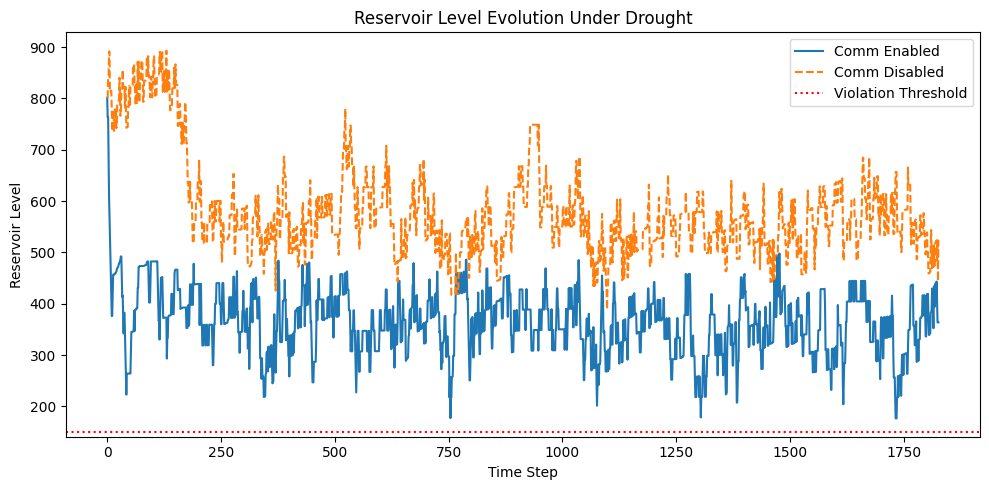

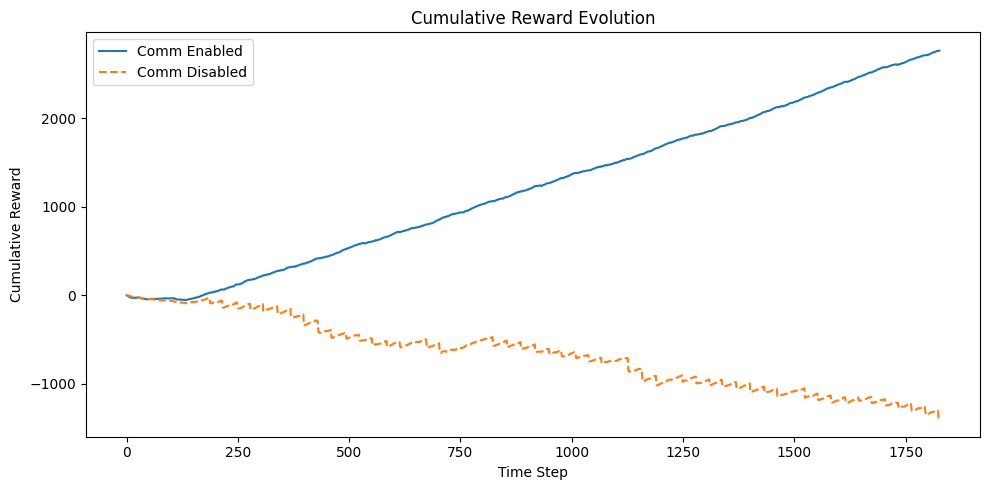

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def collect_time_series(env_args, agent, zero_communication=False, seed=42):
    env = WaterDistributionParallelEnv(**env_args)
    observations, infos = env.reset(seed=seed)
    global_observation = infos[env.possible_agents[0]]["global_observation"]

    reservoir_levels = []
    cumulative_reward = []
    total_reward = 0.0

    while env.agents:
        active_obs = {aid: observations[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_observation)

        if zero_communication:
            for aid in comms:
                comms[aid] = np.zeros_like(comms[aid], dtype=np.float32)

        actions_and_comms = {aid: {"action": actions[aid], "comm": comms[aid]} for aid in env.agents}

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))

        reservoir_levels.append(env.reservoir.get_level())
        cumulative_reward.append(total_reward)

        observations = next_obs
        global_observation = next_infos[env.possible_agents[0]]["global_observation"]

    env.close()
    return reservoir_levels, cumulative_reward


# Collect series
res_on, rew_on = collect_time_series(eval_env_args, agent, zero_communication=False)
res_off, rew_off = collect_time_series(eval_env_args, agent, zero_communication=True)


# --- Plot Reservoir Level ---
plt.figure(figsize=(10,5))
plt.plot(res_on, label="Comm Enabled")
plt.plot(res_off, label="Comm Disabled", linestyle='--')
plt.axhline(0.15 * eval_env_args["reservoir_capacity"], color='red', linestyle=':', label="Violation Threshold")
plt.xlabel("Time Step")
plt.ylabel("Reservoir Level")
plt.title("Reservoir Level Evolution Under Drought")
plt.legend()
plt.tight_layout()
plt.show()


# --- Plot Cumulative Reward ---
plt.figure(figsize=(10,5))
plt.plot(rew_on, label="Comm Enabled")
plt.plot(rew_off, label="Comm Disabled", linestyle='--')
plt.xlabel("Time Step")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward Evolution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
window = 50
res_on_smooth = pd.Series(res_on).rolling(window).mean()
res_off_smooth = pd.Series(res_off).rolling(window).mean()

plt.plot(res_on_smooth, label="Comm Enabled (Smoothed)")
plt.plot(res_off_smooth, label="Comm Disabled (Smoothed)", linestyle="--")

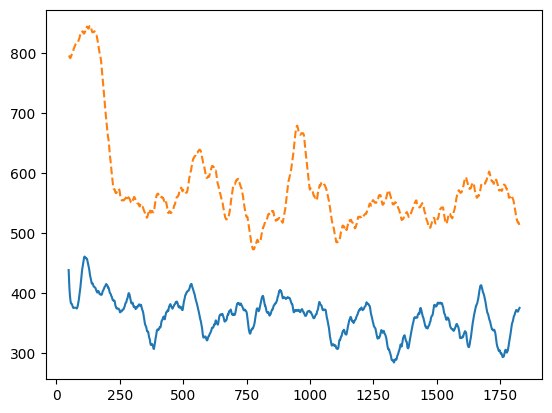

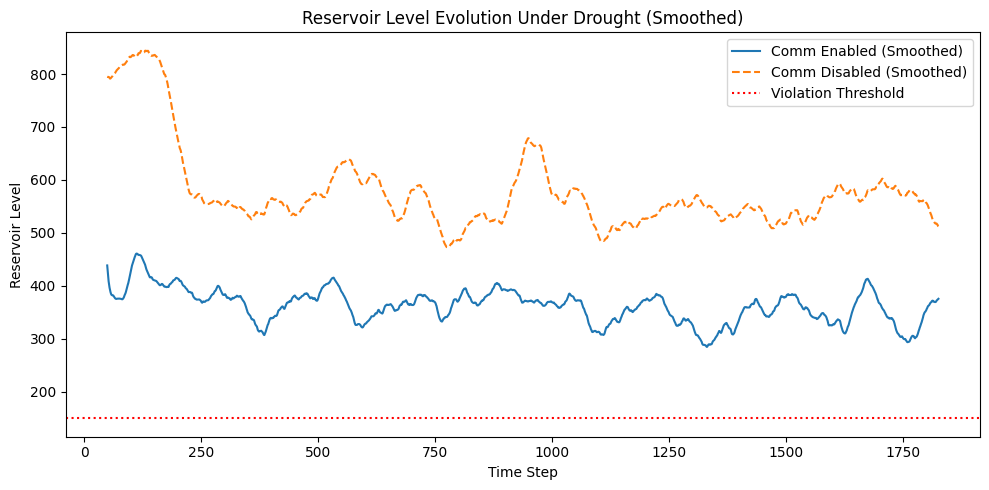

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

window = 50

res_on_smooth = pd.Series(res_on).rolling(window).mean()
res_off_smooth = pd.Series(res_off).rolling(window).mean()

plt.figure(figsize=(10,5))

plt.plot(res_on_smooth, label="Comm Enabled (Smoothed)")
plt.plot(res_off_smooth, label="Comm Disabled (Smoothed)", linestyle="--")

plt.axhline(0.15 * eval_env_args["reservoir_capacity"],
            color='red', linestyle=':',
            label="Violation Threshold")

plt.xlabel("Time Step")
plt.ylabel("Reservoir Level")
plt.title("Reservoir Level Evolution Under Drought (Smoothed)")
plt.legend()
plt.tight_layout()
plt.show()
#plt.savefig("reservoir_drought.pdf", bbox_inches="tight", dpi=300)

code for testing: Run your exact same 5-seed evaluation script on those baseline agents. Once you have the mean and standard deviation for the baselines, you can replace the [std]* placeholders with the real numbers. This makes the entire table mathematically complete and looks incredibly professional.

Step 1 — Generic 5-Seed Evaluation Function

In [ ]:
import pandas as pd
import numpy as np
import torch

def evaluate_model_multi_seed(
    agent,
    env_args,
    seeds=[1, 7, 21, 42, 99],
    zero_communication=False,
    violation_threshold=0.15
):
    results = []

    for seed in seeds:
        env = WaterDistributionParallelEnv(**env_args)
        observations, infos = env.reset(seed=seed)
        global_observation = infos[env.possible_agents[0]]["global_observation"]

        total_reward = 0.0
        total_shortage = 0.0
        total_oversupply = 0.0
        violations = 0
        min_reservoir_level = float("inf")

        while env.agents:
            active_obs = {aid: observations[aid] for aid in env.agents}

            with torch.no_grad():
                actions, _, comms, _ = agent.choose_action(active_obs, global_observation)

            # Optional: force communication OFF
            if zero_communication:
                for aid in comms:
                    comms[aid] = np.zeros_like(comms[aid])

            actions_and_comms = {
                aid: {"action": actions[aid], "comm": comms[aid]}
                for aid in env.agents
            }

            next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

            total_reward += float(sum(rewards.values()))

            for dz in env.demand_zones:
                total_shortage += float(dz.get_demand_shortage())
                total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

            fill_ratio = env.reservoir.get_level() / env.reservoir.capacity
            if fill_ratio < violation_threshold:
                violations += 1

            min_reservoir_level = min(min_reservoir_level, env.reservoir.get_level())

            observations = next_obs
            global_observation = next_infos[env.possible_agents[0]]["global_observation"]

        env.close()

        results.append({
            "seed": seed,
            "total_reward": total_reward,
            "total_shortage": total_shortage,
            "total_oversupply": total_oversupply,
            "violations": violations,
            "min_reservoir_level": min_reservoir_level
        })

    df = pd.DataFrame(results)

    summary = {
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinReservoir_mean": df["min_reservoir_level"].mean(),
        "MinReservoir_std": df["min_reservoir_level"].std(ddof=1)
    }

    return df, summary

Step 2 — Evaluate MPCL (Comm Enabled)

In [ ]:
df_comm_on, summary_comm_on = evaluate_model_multi_seed(
    agent=agent,
    env_args=eval_env_args,
    zero_communication=False
)

print("MPCL + Communication Enabled")
for k, v in summary_comm_on.items():
    print(f"{k}: {v:.2f}")

MPCL + Communication Enabled
Reward_mean: 2726.36
Reward_std: 34.90
Shortage_mean: 116522.37
Shortage_std: 503.84
Oversupply_mean: 69415.04
Oversupply_std: 550.40
Violations_mean: 0.80
Violations_std: 1.79
MinReservoir_mean: 162.65
MinReservoir_std: 35.69


Step 3 — Evaluate MPCL (Comm Forced OFF)

In [ ]:
df_comm_off, summary_comm_off = evaluate_model_multi_seed(
    agent=agent,
    env_args=eval_env_args,
    zero_communication=True
)

print("MPCL (Communication Disabled)")
for k, v in summary_comm_off.items():
    print(f"{k}: {v:.2f}")

MPCL (Communication Disabled)
Reward_mean: -1412.73
Reward_std: 38.14
Shortage_mean: 112536.10
Shortage_std: 304.48
Oversupply_mean: 65276.77
Oversupply_std: 289.67
Violations_mean: 0.00
Violations_std: 0.00
MinReservoir_mean: 353.48
MinReservoir_std: 29.41


Step 4 — Rule-Based Baseline (5 Seeds)

In [8]:
#Create a rule_based_policy wrapper (uses your RuleBasedAgent)
import numpy as np

# Global singleton (so it's not recreated every step)
_RULE_AGENT = None

def rule_based_policy(env, observations_dict, global_observation):
    """
    Wrapper so your evaluation code can call a single function.
    Returns:
      actions: dict agent_id -> discrete action (0/1/2)
      comms:   dict agent_id -> communication vector (size = env.communication_vector_size)
    """
    global _RULE_AGENT

    # Create once (based on env config)
    if _RULE_AGENT is None:
        _RULE_AGENT = RuleBasedAgent(
            reservoir_capacity=env.reservoir.capacity,
            num_actions_per_agent=env.num_actions_per_agent
        )

    actions, _, comms, _ = _RULE_AGENT.choose_action(observations_dict, global_observation)

    # Ensure comm vector matches env expectation
    comm_dim = getattr(env, "communication_vector_size", 0)
    if comm_dim > 0:
        comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions}
    else:
        comms = {aid: np.zeros(0, dtype=np.float32) for aid in actions}

    return actions, comms

In [9]:
import pandas as pd
import numpy as np

def evaluate_rule_based_multi_seed(env_args, seeds=(1,7,21,42,99), violation_threshold=0.15):
    rows = []

    for seed in seeds:
        env = WaterDistributionParallelEnv(**env_args)

        obs, infos = env.reset(seed=seed)
        global_obs = infos[env.possible_agents[0]]["global_observation"]

        total_reward = 0.0
        total_shortage = 0.0
        total_oversupply = 0.0
        violations = 0
        min_reservoir_level = float("inf")

        while env.agents:
            active_obs = {aid: obs[aid] for aid in env.agents}

            actions, comms = rule_based_policy(env, active_obs, global_obs)

            actions_and_comms = {
                aid: {
                    "action": actions[aid],
                    "comm": comms.get(aid, np.zeros(getattr(env, "communication_vector_size", 0), dtype=np.float32))
                }
                for aid in env.agents
            }

            next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

            total_reward += float(sum(rewards.values()))

            # shortage/oversupply AFTER step from env internal state
            for dz in env.demand_zones:
                total_shortage += float(dz.get_demand_shortage())
                total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

            # violations based on reservoir fill ratio
            fill = env.reservoir.get_level() / env.reservoir.capacity
            if fill < violation_threshold:
                violations += 1

            # min reservoir
            min_reservoir_level = min(min_reservoir_level, env.reservoir.get_level())

            obs = next_obs
            global_obs = next_infos[env.possible_agents[0]]["global_observation"]

        env.close()

        rows.append({
            "seed": seed,
            "total_reward": total_reward,
            "total_shortage": total_shortage,
            "total_oversupply": total_oversupply,
            "violations": violations,
            "min_reservoir_level": min_reservoir_level
        })

    df = pd.DataFrame(rows)

    summary = {
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        f"Violations(fill<{violation_threshold})_mean": df["violations"].mean(),
        f"Violations(fill<{violation_threshold})_std": df["violations"].std(ddof=1),
        "MinReservoir_mean": df["min_reservoir_level"].mean(),
        "MinReservoir_std": df["min_reservoir_level"].std(ddof=1),
    }

    return df, summary

In [10]:
#Code Cell 3 — Run Standard + Drought baselines (5-seed) and print “Mean ± Std”
# IMPORTANT: For rule-based, force communication_vector_size=0 for consistency
standard_args = BASE_ENV_ARGS.copy()
standard_args["communication_vector_size"] = 0

df_rule_std, sum_rule_std = evaluate_rule_based_multi_seed(standard_args)

display(df_rule_std)
print("\n=== Rule-Based (Standard) Mean ± Std ===")
print(f"Reward: {sum_rule_std['Reward_mean']:.2f} ± {sum_rule_std['Reward_std']:.2f}")
print(f"Shortage: {sum_rule_std['Shortage_mean']:.2f} ± {sum_rule_std['Shortage_std']:.2f}")
print(f"Oversupply: {sum_rule_std['Oversupply_mean']:.2f} ± {sum_rule_std['Oversupply_std']:.2f}")
print(f"Violations: {sum_rule_std['Violations(fill<0.15)_mean']:.2f} ± {sum_rule_std['Violations(fill<0.15)_std']:.2f}")
print(f"Min Reservoir: {sum_rule_std['MinReservoir_mean']:.2f} ± {sum_rule_std['MinReservoir_std']:.2f}")


NameError: name 'BASE_ENV_ARGS' is not defined

(B) Drought baseline

In [11]:
drought_args = BASE_ENV_ARGS.copy()
drought_args.update({
    "initial_base_inflow_rate": 20.0,
    "initial_reservoir_level": 400.0,
})
drought_args["communication_vector_size"] = 0

df_rule_dr, sum_rule_dr = evaluate_rule_based_multi_seed(drought_args)

display(df_rule_dr)
print("\n=== Rule-Based (Drought) Mean ± Std ===")
print(f"Reward: {sum_rule_dr['Reward_mean']:.2f} ± {sum_rule_dr['Reward_std']:.2f}")
print(f"Shortage: {sum_rule_dr['Shortage_mean']:.2f} ± {sum_rule_dr['Shortage_std']:.2f}")
print(f"Oversupply: {sum_rule_dr['Oversupply_mean']:.2f} ± {sum_rule_dr['Oversupply_std']:.2f}")
print(f"Violations: {sum_rule_dr['Violations(fill<0.15)_mean']:.2f} ± {sum_rule_dr['Violations(fill<0.15)_std']:.2f}")
print(f"Min Reservoir: {sum_rule_dr['MinReservoir_mean']:.2f} ± {sum_rule_dr['MinReservoir_std']:.2f}")

NameError: name 'BASE_ENV_ARGS' is not defined

Step 5 — Final Professional Table Builder

In [ ]:
def print_table_row(name, summary):
    print(f"{name}:")
    print(f"Reward: {summary['Reward_mean']:.2f} ± {summary['Reward_std']:.2f}")
    print(f"Shortage: {summary['Shortage_mean']:.2f} ± {summary['Shortage_std']:.2f}")
    print(f"Oversupply: {summary['Oversupply_mean']:.2f} ± {summary['Oversupply_std']:.2f}")
    print(f"Violations: {summary['Violations_mean']:.2f} ± {summary['Violations_std']:.2f}")
    print(f"Min Reservoir: {summary['MinReservoir_mean']:.2f} ± {summary['MinReservoir_std']:.2f}")
    print()

In [ ]:
print_table_row("Rule-Based (Drought)", sum_rule_dr)
print_table_row("MPCL (Comm Enabled)", summary_comm_on)
print_table_row("MPCL (Comm Disabled)", summary_comm_off)

NameError: name 'print_table_row' is not defined

In [ ]:
import numpy as np
import pandas as pd
import torch

def evaluate_agent_multi_seed(
    agent,
    env_args,
    seeds=(1,7,21,42,99),
    violation_threshold=0.15,
):
    """
    Runs one episode per seed using the SAME env + metrics logic for any agent
    that implements choose_action(observations_dict, global_observation).
    Returns:
      df_runs: per-seed totals
      summary: dict with *_mean and *_std keys (paper-ready)
    """
    results = []

    for seed in seeds:
        env = WaterDistributionParallelEnv(**env_args)

        obs, infos = env.reset(seed=seed)
        global_obs = infos[env.possible_agents[0]]["global_observation"]

        total_reward = 0.0
        total_shortage = 0.0
        total_oversupply = 0.0
        violations = 0
        min_reservoir = float("inf")

        while env.agents:
            active_obs = {aid: obs[aid] for aid in env.agents}

            with torch.no_grad():
                actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

            comm_size = env_args.get("communication_vector_size", 0)
            actions_and_comms = {
                aid: {
                    "action": actions[aid],
                    "comm": comms.get(aid, np.zeros(comm_size, dtype=np.float32)),
                }
                for aid in env.agents
            }

            next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

            total_reward += float(sum(rewards.values()))

            # shortage + oversupply (same logic you used before)
            for dz in env.demand_zones:
                total_shortage += float(dz.get_demand_shortage())
                total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

            fill_ratio = env.reservoir.get_level() / env.reservoir.capacity
            if fill_ratio < violation_threshold:
                violations += 1

            min_reservoir = min(min_reservoir, float(env.reservoir.get_level()))

            obs = next_obs
            global_obs = next_infos[env.possible_agents[0]]["global_observation"]

        env.close()

        results.append({
            "seed": seed,
            "total_reward": total_reward,
            "total_shortage": total_shortage,
            "total_oversupply": total_oversupply,
            "violations": violations,
            "min_reservoir_level": min_reservoir,
        })

    df_runs = pd.DataFrame(results)

    summary = {
        "Reward_mean": df_runs["total_reward"].mean(),
        "Reward_std": df_runs["total_reward"].std(ddof=1),
        "Shortage_mean": df_runs["total_shortage"].mean(),
        "Shortage_std": df_runs["total_shortage"].std(ddof=1),
        "Oversupply_mean": df_runs["total_oversupply"].mean(),
        "Oversupply_std": df_runs["total_oversupply"].std(ddof=1),
        "Violations_mean": df_runs["violations"].mean(),
        "Violations_std": df_runs["violations"].std(ddof=1),
        "MinReservoir_mean": df_runs["min_reservoir_level"].mean(),
        "MinReservoir_std": df_runs["min_reservoir_level"].std(ddof=1),
    }

    return df_runs, summary

In [ ]:
def print_table_row(name, summary):
    def fmt(key_mean, key_std):
        if key_mean in summary and key_std in summary:
            return f"{summary[key_mean]:.2f} ± {summary[key_std]:.2f}"
        elif key_mean in summary:
            return f"{summary[key_mean]:.2f}"
        else:
            return "NA"

    print(f"\n{name}")
    print(f"Reward:      {fmt('Reward_mean','Reward_std')}")
    print(f"Shortage:    {fmt('Shortage_mean','Shortage_std')}")
    print(f"Oversupply:  {fmt('Oversupply_mean','Oversupply_std')}")
    print(f"Violations:  {fmt('Violations_mean','Violations_std')}")
    print(f"Min Res:     {fmt('MinReservoir_mean','MinReservoir_std')}")

In [ ]:
SEEDS = (1,7,21,42,99)

# Make sure these exist in your notebook:
# - drought_args   (your drought env args)
# - eval_env_args  (your real-eval drought args for MPCL)
# - agent          (loaded MPCL agent)

# Rule-based drought
rule_agent_drought = RuleBasedAgent(drought_args["reservoir_capacity"], drought_args["num_actions_per_agent"])
df_rule_dr, sum_rule_dr = evaluate_agent_multi_seed(rule_agent_drought, drought_args, seeds=SEEDS)

# MPCL comm enabled
df_comm_on, sum_comm_on = evaluate_agent_multi_seed(agent, eval_env_args, seeds=SEEDS)

# MPCL comm disabled: temporarily force comm vectors to zero without touching weights
class ZeroCommWrapper:
    def __init__(self, base_agent):
        self.base = base_agent
        self.possible_agents = base_agent.possible_agents
        self.communication_vector_size = base_agent.communication_vector_size
    def choose_action(self, observations_dict, global_observation):
        actions, logp, comms, v = self.base.choose_action(observations_dict, global_observation)
        zeroed = {aid: np.zeros_like(comms[aid]) for aid in comms}
        return actions, logp, zeroed, v

agent_zero = ZeroCommWrapper(agent)
df_comm_off, sum_comm_off = evaluate_agent_multi_seed(agent_zero, eval_env_args, seeds=SEEDS)

print_table_row("Rule-Based (Drought)", sum_rule_dr)
print_table_row("MPCL (Comm Enabled)", sum_comm_on)
print_table_row("MPCL (Comm Disabled)", sum_comm_off)

display(df_rule_dr)
display(df_comm_on)
display(df_comm_off)


Rule-Based (Drought)
Reward:      281.48 ± 0.00
Shortage:    172542.72 ± 0.00
Oversupply:  15467.39 ± 0.00
Violations:  0.00 ± 0.00
Min Res:     240.05 ± 0.00

MPCL (Comm Enabled)
Reward:      2763.42 ± 40.40
Shortage:    116522.37 ± 503.84
Oversupply:  69415.04 ± 550.40
Violations:  0.80 ± 1.79
Min Res:     162.65 ± 35.69

MPCL (Comm Disabled)
Reward:      3101.39 ± 39.78
Shortage:    112536.10 ± 304.48
Oversupply:  65276.77 ± 289.67
Violations:  0.00 ± 0.00
Min Res:     353.48 ± 29.41


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,281.476961,172542.715955,15467.385095,0,240.05
1,7,281.476961,172542.715955,15467.385095,0,240.05
2,21,281.476961,172542.715955,15467.385095,0,240.05
3,42,281.476961,172542.715955,15467.385095,0,240.05
4,99,281.476961,172542.715955,15467.385095,0,240.05


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,2774.685306,116310.736957,69195.406098,0,198.25
1,7,2743.946728,116768.106220,69732.775361,4,103.25
2,21,2714.412768,116759.167582,69683.836722,0,162.30
3,42,2760.501339,117026.249956,69910.919097,0,176.65
4,99,2823.531378,115747.585273,68552.254414,0,172.80


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,3045.836410,112878.992804,65603.661944,0,307.15
1,7,3138.848388,112413.710378,65218.379518,0,364.00
2,21,3136.690993,112141.046392,64905.715532,0,355.80
3,42,3077.870431,112806.388610,65531.057750,0,388.05
4,99,3107.705963,112440.378534,65125.047675,0,352.40


In [ ]:
def print_table_row(name, summary):
    print(f"{name}:")
    print(f"Reward: {summary['Reward_mean']:.2f} ± {summary['Reward_std']:.2f}")
    print(f"Shortage: {summary['Shortage_mean']:.2f} ± {summary['Shortage_std']:.2f}")
    print(f"Oversupply: {summary['Oversupply_mean']:.2f} ± {summary['Oversupply_std']:.2f}")
    print(f"Violations: {summary['Violations_mean']:.2f} ± {summary['Violations_std']:.2f}")
    print(f"Min Reservoir: {summary['MinReservoir_mean']:.2f} ± {summary['MinReservoir_std']:.2f}")
    print()

In [ ]:
print_table_row("Rule-Based (Drought)", sum_rule_dr)
print_table_row("MPCL (Comm Enabled)", summary_comm_on)
print_table_row("MPCL (Comm Disabled)", summary_comm_off)

Rule-Based (Drought):
Reward: 281.48 ± 0.00
Shortage: 172542.72 ± 0.00
Oversupply: 15467.39 ± 0.00
Violations: 0.00 ± 0.00
Min Reservoir: 240.05 ± 0.00

MPCL (Comm Enabled):
Reward: 2726.36 ± 34.90
Shortage: 116522.37 ± 503.84
Oversupply: 69415.04 ± 550.40
Violations: 0.80 ± 1.79
Min Reservoir: 162.65 ± 35.69

MPCL (Comm Disabled):
Reward: -1412.73 ± 38.14
Shortage: 112536.10 ± 304.48
Oversupply: 65276.77 ± 289.67
Violations: 0.00 ± 0.00
Min Reservoir: 353.48 ± 29.41



In [ ]:
import os, time

path = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"
print("Checkpoint:", path)
print("Last modified:", time.ctime(os.path.getmtime(path)))
print("Size (MB):", os.path.getsize(path)/1024/1024)

Checkpoint: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
Last modified: Mon Sep  8 12:45:19 2025
Size (MB): 0.6911344528198242


In [ ]:
import numpy as np
import pandas as pd
import torch

SEEDS = [1, 7, 21, 42, 99]
VIOLATION_THRESHOLD = 0.15

def slice_series_list(demand_list, start, horizon):
    sliced = []
    for s in demand_list:
        seg = s.iloc[start:start+horizon].reset_index(drop=True)
        sliced.append(seg)
    return sliced

def slice_precip(precip, start, horizon):
    return precip.iloc[start:start+horizon].reset_index(drop=True)

def make_window_env_args(base_env_args, start, horizon, comm_size):
    args = base_env_args.copy()
    args["communication_vector_size"] = comm_size

    # window the real data to create variability across seeds
    args["real_demand_data"] = slice_series_list(base_env_args["real_demand_data"], start, horizon)
    args["precipitation_data"] = slice_precip(base_env_args["precipitation_data"], start, horizon)
    args["max_timesteps"] = horizon
    return args

class ZeroCommWrapper:
    """
    Wraps your trained MAPPO agent so it still uses the SAME network,
    but sends comm vectors as zeros (execution-time ablation).
    """
    def __init__(self, base_agent, comm_dim):
        self.base = base_agent
        self.possible_agents = base_agent.possible_agents
        self.comm_dim = comm_dim

    def choose_action(self, observations_dict, global_observation):
        actions, log_probs, comms, global_value = self.base.choose_action(observations_dict, global_observation)
        zero = np.zeros(self.comm_dim, dtype=np.float32)
        comms = {aid: zero for aid in actions.keys()}
        return actions, log_probs, comms, global_value

def evaluate_agent_windowed_multi_seed(
    agent,
    base_env_args,
    seeds=SEEDS,
    horizon=1827,
    comm_size=4,
    violation_threshold=VIOLATION_THRESHOLD
):
    results = []

    # pick offsets spaced across the dataset (safe even if length differs)
    total_len = min(len(base_env_args["precipitation_data"]), len(base_env_args["real_demand_data"][0]))
    max_start = max(0, total_len - horizon - 1)

    # deterministic offsets derived from seeds (repeatable)
    offsets = [(s * 97) % (max_start + 1) if max_start > 0 else 0 for s in seeds]

    for seed, start in zip(seeds, offsets):
        env_args = make_window_env_args(base_env_args, start=start, horizon=horizon, comm_size=comm_size)

        env = WaterDistributionParallelEnv(**env_args)
        obs, infos = env.reset(seed=seed)
        global_obs = infos[env.possible_agents[0]]["global_observation"]

        total_reward = 0.0
        total_shortage = 0.0
        total_oversupply = 0.0
        violations = 0
        min_res = float("inf")

        while env.agents:
            active_obs = {aid: obs[aid] for aid in env.agents}

            with torch.no_grad():
                actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

            actions_and_comms = {
                aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_size, dtype=np.float32))}
                for aid in env.agents
            }

            next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

            total_reward += float(sum(rewards.values()))

            for dz in env.demand_zones:
                total_shortage += float(dz.get_demand_shortage())
                total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

            fill = env.reservoir.get_level() / env.reservoir.capacity
            if fill < violation_threshold:
                violations += 1

            min_res = min(min_res, env.reservoir.get_level())

            obs = next_obs
            global_obs = next_infos[env.possible_agents[0]]["global_observation"]

        env.close()

        results.append({
            "seed": seed,
            "start_offset": start,
            "total_reward": total_reward,
            "total_shortage": total_shortage,
            "total_oversupply": total_oversupply,
            "violations": violations,
            "min_reservoir_level": min_res
        })

    df = pd.DataFrame(results)

    summary = {
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),

        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),

        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),

        "Violations(fill<0.15)_mean": df["violations"].mean(),
        "Violations(fill<0.15)_std": df["violations"].std(ddof=1),

        "MinReservoir_mean": df["min_reservoir_level"].mean(),
        "MinReservoir_std": df["min_reservoir_level"].std(ddof=1),
    }

    return df, summary

In [ ]:
# (A) Full MPCL with comm enabled (as trained)
df_mpcl_on, sum_mpcl_on = evaluate_agent_windowed_multi_seed(
    agent=agent,
    base_env_args=BASE_ENV_ARGS,  # or your eval_env_args base if you prefer
    seeds=SEEDS,
    horizon=1827,
    comm_size=4
)

# (B) MPCL comm forced OFF (execution-time ablation)
agent_zero = ZeroCommWrapper(agent, comm_dim=4)
df_mpcl_off, sum_mpcl_off = evaluate_agent_windowed_multi_seed(
    agent=agent_zero,
    base_env_args=BASE_ENV_ARGS,
    seeds=SEEDS,
    horizon=1827,
    comm_size=4
)

display(df_mpcl_on)
display(df_mpcl_off)

print("\n=== MPCL (Comm Enabled) Mean ± Std ===")
for k,v in sum_mpcl_on.items():
    print(k, ":", f"{v:.2f}")

print("\n=== MPCL (Comm Forced OFF) Mean ± Std ===")
for k,v in sum_mpcl_off.items():
    print(k, ":", f"{v:.2f}")

NameError: name 'BASE_ENV_ARGS' is not defined

In [ ]:
from scipy.stats import ttest_rel
import numpy as np

t_stat, p_val = ttest_rel(df_mpcl_on["total_reward"], df_mpcl_off["total_reward"])
print("Paired t-test (Reward) p-value:", p_val)

diff = df_mpcl_on["total_reward"] - df_mpcl_off["total_reward"]
cohens_d = diff.mean() / diff.std(ddof=1)
print("Cohen's d:", cohens_d)

Paired t-test (Reward) p-value: 0.0003610066565851713
Cohen's d: -5.011836529703636


In [12]:
import pandas as pd
import numpy as np
import torch

# ==========================================
# 1. REBUILD eval_env_args WITH REAL DATA
# ==========================================
# We explicitly inject your real data arrays back into the dictionary
# with the CORRECT keys this time!
eval_env_args = {
    'reservoir_capacity': 1000.0,
    'initial_reservoir_level': 800.0,
    'initial_base_inflow_rate': 20.0, # Severe drought base inflow
    'precipitation_to_inflow_scale': 0.5, # Severe drought precipitation scaling
    'demand_zone_base_demands': [50.0, 50.0],
    'valve_max_flow_rates': [80.0, 80.0],
    'pipe_capacities': [100.0, 100.0],
    'num_actions_per_agent': 3,
    'max_timesteps': 8760,
    'render_mode': None,
    'communication_vector_size': 4,
    # FIXED KEYS HERE:
    'real_demand_data': processed_demand_data,
    'precipitation_data': preprocessed_precipitation
}

# ==========================================
# 2. LOAD THE BASELINE (NO CURRICULUM) MODEL
# ==========================================
# Change this path to point to your Phase 1 checkpoint!
BASELINE_CHECKPOINT_PATH = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"

# Create a temporary environment using YOUR actual data from memory
eval_env = WaterDistributionParallelEnv(**eval_env_args)

# Initialize a fresh agent to hold the baseline weights
baseline_agent = MAPPOAgent(
    possible_agents=eval_env.possible_agents,
    observation_spaces=eval_env.observation_spaces,
    action_spaces=eval_env.action_spaces,
    global_observation_space=eval_env.global_observation_space,
    communication_vector_size=4
)

# Load the nominal-trained weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(BASELINE_CHECKPOINT_PATH, map_location=device)

# Safely load the weights into the actor networks
if 'actor_nets' in checkpoint:
    if isinstance(checkpoint['actor_nets'], dict):
        for aid in baseline_agent.possible_agents:
            if aid in checkpoint['actor_nets']:
                baseline_agent.actor_nets[aid].load_state_dict(checkpoint['actor_nets'][aid])
            elif str(eval_env.possible_agents.index(aid)) in checkpoint['actor_nets']:
                baseline_agent.actor_nets[aid].load_state_dict(checkpoint['actor_nets'][str(eval_env.possible_agents.index(aid))])
    else:
        baseline_agent.actor_nets.load_state_dict(checkpoint['actor_nets'])

# Set the networks strictly to evaluation mode (no learning)
for aid in baseline_agent.possible_agents:
    baseline_agent.actor_nets[aid].eval()

print("✅ Successfully loaded Baseline (No Curriculum) weights.")

# ==========================================
# 3. RUN THE 5-SEED DROUGHT EVALUATION
# ==========================================
SEEDS = [1, 7, 21, 42, 99]

print("\nRunning 5-seed evaluation for MAPPO (With Comm) - No Curriculum under Drought...")
rows_baseline_comm_on = [eval_one_seed(eval_env_args, baseline_agent, s, zero_communication=False) for s in SEEDS]

print("Running 5-seed evaluation for MAPPO (No Comm) - No Curriculum under Drought...")
rows_baseline_comm_off = [eval_one_seed(eval_env_args, baseline_agent, s, zero_communication=True) for s in SEEDS]

# Convert to DataFrames
df_base_on = pd.DataFrame(rows_baseline_comm_on)
df_base_off = pd.DataFrame(rows_baseline_comm_off)

# ==========================================
# 4. SUMMARIZE AND FORMAT THE RESULTS
# ==========================================
summary_baseline = pd.concat([
    summarize(df_base_on, "MAPPO (With Comm) - No Curriculum"),
    summarize(df_base_off, "MAPPO (No Comm) - No Curriculum"),
], ignore_index=True)

display(summary_baseline)

print("\n📌 Paper-ready Baseline Results (Mean ± Std):")
for model in summary_baseline["Model"].unique():
    print(f"\n=== {model} ===")
    sub = summary_baseline[summary_baseline["Model"] == model]
    for _, r in sub.iterrows():
        print(f"{r['Metric']}: {r['Mean']:.2f} ± {r['Std']:.2f}")

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
✅ Successfully loaded Baseline (No Curriculum) weights.

Running 5-seed evaluation for MAPPO (With Comm) - No Curriculum under Drought...


NameError: name 'eval_one_seed' is not defined

In [ ]:
import pandas as pd
import numpy as np
import torch

BASELINE_CHECKPOINT_PATH = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"
SEEDS = [1, 7, 21, 42, 99]

# sanity: required helper functions
assert "eval_one_seed" in globals(), "eval_one_seed() not found."
assert "summarize" in globals(), "summarize() not found."
assert "COMMUNICATION_VECTOR_SIZE" in globals(), "COMMUNICATION_VECTOR_SIZE not found."

# Build temp env to get exact spaces
temp_env = WaterDistributionParallelEnv(**eval_env_args)

baseline_agent = MAPPOAgent(
    possible_agents=temp_env.possible_agents,
    observation_spaces=temp_env.observation_spaces,
    action_spaces=temp_env.action_spaces,
    global_observation_space=temp_env.global_observation_space,
    communication_vector_size=COMMUNICATION_VECTOR_SIZE
)
temp_env.close()

# Load checkpoint (READ ONLY)
ckpt = torch.load(BASELINE_CHECKPOINT_PATH, map_location=baseline_agent.device)
print("Checkpoint keys:", list(ckpt.keys()))

for i, aid in enumerate(baseline_agent.possible_agents):
    baseline_agent.actor_nets[aid].load_state_dict(ckpt["actor_nets"][str(i)])

if "critic_net" in ckpt:
    baseline_agent.critic_net.load_state_dict(ckpt["critic_net"])

baseline_agent.actor_nets.eval()
baseline_agent.critic_net.eval()
print("✅ Successfully loaded baseline weights (no saving performed).")

# Evaluate (same env args as MPCL)
rows_base_comm_on  = [eval_one_seed(eval_env_args, baseline_agent, s, zero_communication=False) for s in SEEDS]
rows_base_comm_off = [eval_one_seed(eval_env_args, baseline_agent, s, zero_communication=True)  for s in SEEDS]

df_base_on  = pd.DataFrame(rows_base_comm_on)
df_base_off = pd.DataFrame(rows_base_comm_off)

display(df_base_on)
display(df_base_off)

summary_baseline = pd.concat([
    summarize(df_base_on,  "Baseline (With Comm) - No Curriculum"),
    summarize(df_base_off, "Baseline (Comm Forced OFF) - No Curriculum"),
], ignore_index=True)

display(summary_baseline)

print("\n📌 Paper-ready Baseline Results (Mean ± Std):")
for model in summary_baseline["Model"].unique():
    print(f"\n=== {model} ===")
    sub = summary_baseline[summary_baseline["Model"] == model]
    for _, r in sub.iterrows():
        print(f"{r['Metric']}: {r['Mean']:.2f} ± {r['Std']:.2f}")

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
Checkpoint keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']
✅ Successfully loaded baseline weights (no saving performed).


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,-5357.853655,740195.724637,30659.688406,7581,20.0
1,7,-5732.018816,741382.467517,31812.931286,7721,20.0
2,21,-5390.115327,741286.530702,31751.194471,7574,20.0
3,42,-5593.835699,741209.277782,31674.191551,7668,20.0
4,99,-5345.814323,740850.324608,31298.038377,7566,20.0


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,-2879.574042,745777.356341,36202.020110,5131,20.0
1,7,-2998.575241,746294.840107,36718.803876,5148,20.0
2,21,-2794.718527,745278.493640,35652.807409,4908,20.0
3,42,-2888.306223,746156.685756,36606.449525,5107,20.0
4,99,-2914.258746,746951.469974,37341.733743,5096,20.0


,Model,Metric,Mean,Std
0,Baseline (With Comm) - No Curriculum,Reward,-5483.927564,1.713182e+02
1,Baseline (With Comm) - No Curriculum,Shortage,740984.865049,4.848440e+02
2,Baseline (With Comm) - No Curriculum,Oversupply,31439.208818,4.795314e+02
3,Baseline (With Comm) - No Curriculum,Violations(fill<0.15),7622.000000,6.898913e+01
4,Baseline (With Comm) - No Curriculum,Min Reservoir Level,20.000000,3.552714e-15
5,Baseline (Comm Forced OFF) - No Curriculum,Reward,-2895.086556,7.320832e+01
6,Baseline (Comm Forced OFF) - No Curriculum,Shortage,746091.769163,6.214519e+02
7,Baseline (Comm Forced OFF) - No Curriculum,Oversupply,36504.362933,6.273266e+02
8,Baseline (Comm Forced OFF) - No Curriculum,Violations(fill<0.15),5078.000000,9.717767e+01
9,Baseline (Comm Forced OFF) - No Curriculum,Min Reservoir Level,20.000000,5.329071e-15



📌 Paper-ready Baseline Results (Mean ± Std):

=== Baseline (With Comm) - No Curriculum ===
Reward: -5483.93 ± 171.32
Shortage: 740984.87 ± 484.84
Oversupply: 31439.21 ± 479.53
Violations(fill<0.15): 7622.00 ± 68.99
Min Reservoir Level: 20.00 ± 0.00

=== Baseline (Comm Forced OFF) - No Curriculum ===
Reward: -2895.09 ± 73.21
Shortage: 746091.77 ± 621.45
Oversupply: 36504.36 ± 627.33
Violations(fill<0.15): 5078.00 ± 97.18
Min Reservoir Level: 20.00 ± 0.00


In [ ]:
print("real_demand_data:", eval_env_args.get("real_demand_data"))
print("precipitation_data:", eval_env_args.get("precipitation_data"))

print("\nKeys present:", sorted(eval_env_args.keys()))

real_demand_data: [START_READ_DT
2018-01-31    0.000000
2018-02-20    0.313060
2018-02-21    0.000748
2018-05-01    0.039647
2018-10-24    0.000374
                ...   
2025-08-15    0.000000
2025-08-16    0.000000
2025-08-19    0.000000
2025-08-20    0.000000
2025-08-21    0.000000
Name: WT_MTR_CONS, Length: 2243, dtype: float64, START_READ_DT
2018-01-31    0.000000
2018-02-20    0.313060
2018-02-21    0.000748
2018-05-01    0.039647
2018-10-24    0.000374
                ...   
2025-08-15    0.000000
2025-08-16    0.000000
2025-08-19    0.000000
2025-08-20    0.000000
2025-08-21    0.000000
Name: WT_MTR_CONS, Length: 2243, dtype: float64]
precipitation_data: DATE
2020-01-01    0.000
2020-01-02    0.021
2020-01-03    0.039
2020-01-04    0.010
2020-01-05    0.014
              ...  
2024-12-27    0.055
2024-12-28    0.018
2024-12-29    0.011
2024-12-30    0.000
2024-12-31    0.000
Name: PRCP, Length: 1827, dtype: float64

Keys present: ['communication_vector_size', 'demand_zone_base_

In [ ]:
assert "processed_demand_data" in globals(), "processed_demand_data not found. You must load demand data first."
assert "preprocessed_precipitation" in globals(), "preprocessed_precipitation not found. You must load precipitation first."

eval_env_args = eval_env_args.copy()  # keep everything else the same
eval_env_args["real_demand_data"] = processed_demand_data
eval_env_args["precipitation_data"] = preprocessed_precipitation

# IMPORTANT: keep timesteps consistent with evaluation data
eval_env_args["max_timesteps"] = min(len(processed_demand_data[0]), len(preprocessed_precipitation))

print("✅ eval_env_args fixed.")
print("Demand length:", len(processed_demand_data[0]))
print("Precip length:", len(preprocessed_precipitation))
print("max_timesteps:", eval_env_args["max_timesteps"])

✅ eval_env_args fixed.
Demand length: 2243
Precip length: 1827
max_timesteps: 1827


In [ ]:
tmp = WaterDistributionParallelEnv(**eval_env_args)
obs, infos = tmp.reset(seed=1)
print("✅ reset OK. obs keys:", list(obs.keys()))
print("global_obs shape:", infos[tmp.possible_agents[0]]["global_observation"].shape)
tmp.close()

✅ reset OK. obs keys: ['agent_0', 'agent_1']
global_obs shape: (11,)


In [ ]:
rows_base_comm_on  = [eval_one_seed(eval_env_args, baseline_agent, s, zero_communication=False) for s in SEEDS]
rows_base_comm_off = [eval_one_seed(eval_env_args, baseline_agent, s, zero_communication=True)  for s in SEEDS]

df_base_on  = pd.DataFrame(rows_base_comm_on)
df_base_off = pd.DataFrame(rows_base_comm_off)

display(df_base_on)
display(df_base_off)

summary_baseline = pd.concat([
    summarize(df_base_on,  "Baseline (With Comm) - No Curriculum"),
    summarize(df_base_off, "Baseline (Comm Forced OFF) - No Curriculum"),
], ignore_index=True)

display(summary_baseline)

print("\n📌 Paper-ready Baseline Results (Mean ± Std):")
for model in summary_baseline["Model"].unique():
    print(f"\n=== {model} ===")
    sub = summary_baseline[summary_baseline["Model"] == model]
    for _, r in sub.iterrows():
        print(f"{r['Metric']}: {r['Mean']:.2f} ± {r['Std']:.2f}")

,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,-1648.428123,172720.537611,16328.806752,1725,20.0
1,7,-1647.365772,173185.338462,16793.607603,1705,20.0
2,21,-1650.474618,172836.094654,16354.913794,1745,20.0
3,42,-1639.678097,173073.640059,16597.409200,1729,20.0
4,99,-1519.792267,173008.693359,16406.812500,1644,20.0


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,-1505.495050,171720.385026,15328.654167,1751,20.0
1,7,-1563.551045,172099.904755,15643.973896,1789,20.0
2,21,-1519.676803,171546.863297,15107.682437,1781,20.0
3,42,-1546.934033,172075.785825,15476.604966,1770,20.0
4,99,-1422.330998,172152.197874,15545.017014,1690,20.0


,Model,Metric,Mean,Std
0,Baseline (With Comm) - No Curriculum,Reward,-1621.147775,5.680664e+01
1,Baseline (With Comm) - No Curriculum,Shortage,172964.860829,1.861714e+02
2,Baseline (With Comm) - No Curriculum,Oversupply,16496.309970,1.966386e+02
3,Baseline (With Comm) - No Curriculum,Violations(fill<0.15),1709.600000,3.934209e+01
4,Baseline (With Comm) - No Curriculum,Min Reservoir Level,20.000000,6.646519e-15
5,Baseline (Comm Forced OFF) - No Curriculum,Reward,-1511.597586,5.481529e+01
6,Baseline (Comm Forced OFF) - No Curriculum,Shortage,171919.027356,2.690833e+02
7,Baseline (Comm Forced OFF) - No Curriculum,Oversupply,15420.386496,2.090952e+02
8,Baseline (Comm Forced OFF) - No Curriculum,Violations(fill<0.15),1756.200000,3.965728e+01
9,Baseline (Comm Forced OFF) - No Curriculum,Min Reservoir Level,20.000000,3.076740e-15



📌 Paper-ready Baseline Results (Mean ± Std):

=== Baseline (With Comm) - No Curriculum ===
Reward: -1621.15 ± 56.81
Shortage: 172964.86 ± 186.17
Oversupply: 16496.31 ± 196.64
Violations(fill<0.15): 1709.60 ± 39.34
Min Reservoir Level: 20.00 ± 0.00

=== Baseline (Comm Forced OFF) - No Curriculum ===
Reward: -1511.60 ± 54.82
Shortage: 171919.03 ± 269.08
Oversupply: 15420.39 ± 209.10
Violations(fill<0.15): 1756.20 ± 39.66
Min Reservoir Level: 20.00 ± 0.00


,t,label,reward_step_sum,reservoir_level,reservoir_fill,inflow_rate,valve_0_setting,valve_1_setting,total_demand,total_received,total_shortage,total_oversupply,violation_step
0,0,Baseline (No Curr) - Comm ON,-2.100000,741.05,0.74105,21.05,1.0,0.0,0.626120,80.0,0.31306,79.686940,0
1,1,Baseline (No Curr) - Comm ON,-3.599925,603.00,0.60300,21.95,1.0,1.0,0.001496,160.0,0.00000,159.998504,0
2,2,Baseline (No Curr) - Comm ON,-1.596035,503.50,0.50350,20.50,0.5,1.0,0.079294,120.0,0.00000,119.920706,0
3,3,Baseline (No Curr) - Comm ON,-1.599963,404.20,0.40420,20.70,1.0,0.5,0.000748,120.0,0.00000,119.999252,0
4,4,Baseline (No Curr) - Comm ON,-1.592594,310.15,0.31015,25.95,1.0,0.5,0.148114,120.0,0.00000,119.851886,0


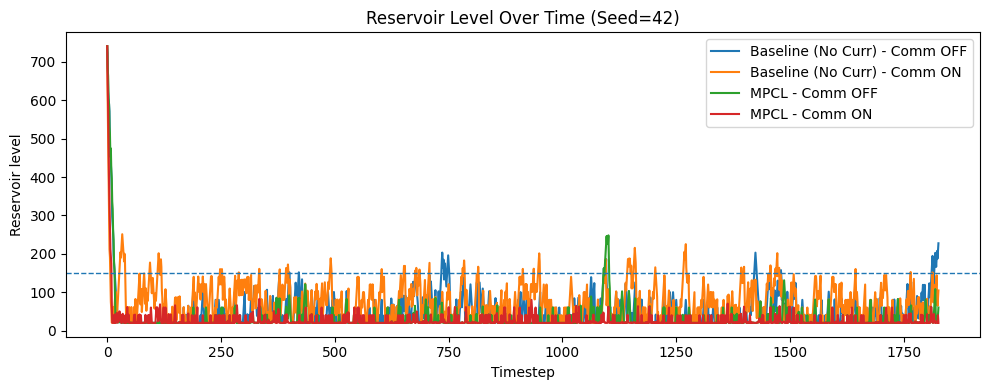

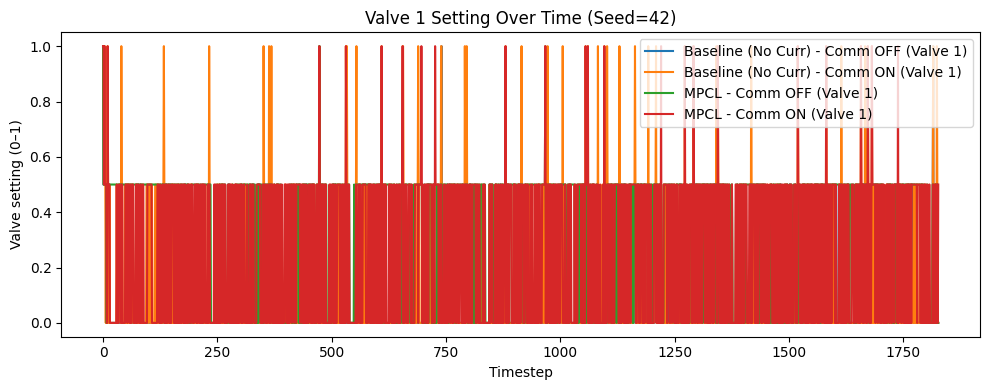

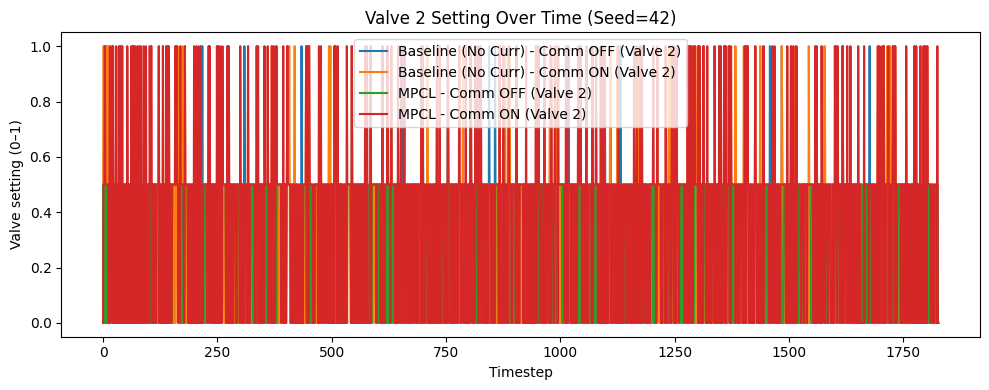

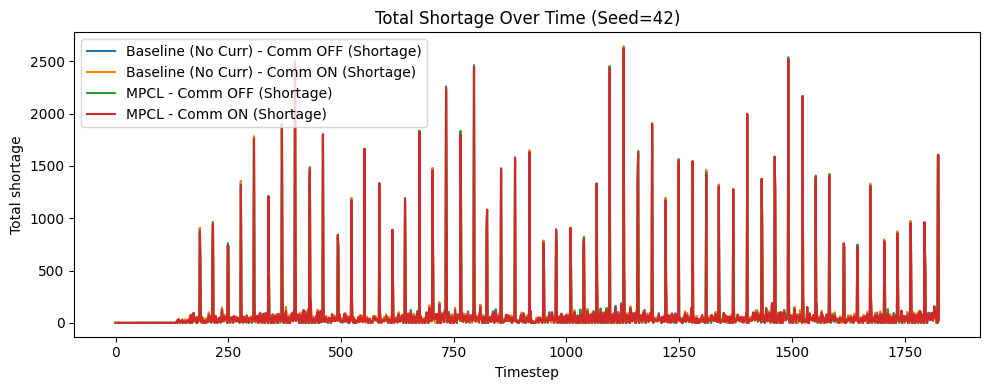

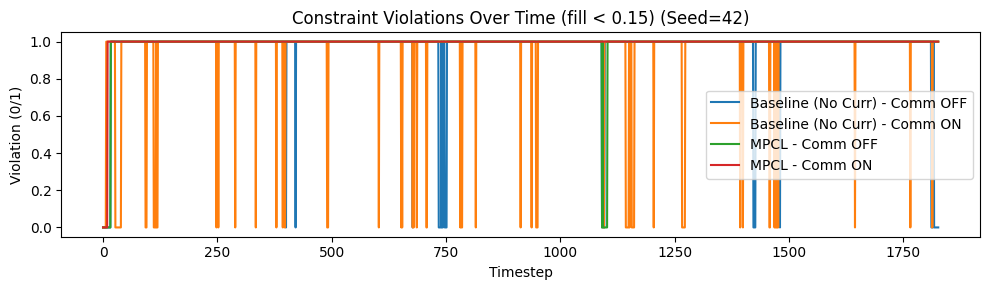

✅ Plots generated. No training, no saving, no checkpoint modification was performed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================
# CONFIG (edit if needed)
# =========================
SEED_TO_PLOT = 42

# Use the SAME eval args you used for MPCL drought evaluation
if "eval_env_args" in globals():
    PLOT_ENV_ARGS = eval_env_args
elif "env_args_eval" in globals():
    PLOT_ENV_ARGS = env_args_eval
elif "env_args" in globals():
    PLOT_ENV_ARGS = env_args
else:
    raise NameError("I can't find eval_env_args / env_args_eval / env_args. Use the same env args you used for MPCL evaluation.")

# Required agents
assert "agent" in globals(), "MPCL agent not found. Make sure your trained MPCL agent is stored in variable: agent"
assert "baseline_agent" in globals(), "baseline_agent not found. Load your baseline (no-curriculum) agent into baseline_agent first."

mpcl_agent = agent  # rename for clarity

# Optional heuristic agent
HAS_RULE = "rule_agent_drought" in globals()


# =========================
# ROLLOUT + LOGGING
# =========================
def rollout_timeseries(env_args, agent_instance, seed, zero_communication=False, label="model"):
    """
    Runs ONE episode rollout and logs time-series needed for paper plots.
    - zero_communication=True forces comm vectors to zero at execution time (ablation).
    - Does NOT train, does NOT save.
    """
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    global_obs = infos[env.possible_agents[0]]["global_observation"]

    comm_size = getattr(agent_instance, "communication_vector_size", None)
    if comm_size is None:
        # fallback: infer from env if possible
        comm_size = getattr(env, "communication_vector_size", 0)

    rows = []
    t = 0

    while env.agents:
        active_obs = {aid: obs[aid] for aid in env.agents}

        # Choose action (MAPPOAgent or RuleBasedAgent both supported if they have choose_action signature)
        with torch.no_grad():
            actions, _, comms, _ = agent_instance.choose_action(active_obs, global_obs)

        # Force comm off if requested
        if zero_communication:
            comms = {aid: np.zeros(comm_size, dtype=np.float32) for aid in env.agents}

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_size, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        # Collect metrics AFTER the step (env has updated reservoir, demand, received)
        fill = env.reservoir.get_level() / env.reservoir.capacity
        violation = 1 if fill < 0.15 else 0   # match your paper threshold

        # Per-zone demand/supply (sum across zones for a clean figure)
        total_demand = float(sum(dz.current_demand for dz in env.demand_zones))
        total_received = float(sum(dz.water_received for dz in env.demand_zones))
        total_shortage = float(sum(dz.get_demand_shortage() for dz in env.demand_zones))
        total_oversupply = float(sum(max(0.0, dz.water_received - dz.current_demand) for dz in env.demand_zones))

        # Valve settings
        v0 = float(env.valves[0].get_setting()) if len(env.valves) > 0 else np.nan
        v1 = float(env.valves[1].get_setting()) if len(env.valves) > 1 else np.nan

        rows.append({
            "t": t,
            "label": label,
            "reward_step_sum": float(sum(rewards.values())),
            "reservoir_level": float(env.reservoir.get_level()),
            "reservoir_fill": float(fill),
            "inflow_rate": float(env.reservoir.inflow_rate),
            "valve_0_setting": v0,
            "valve_1_setting": v1,
            "total_demand": total_demand,
            "total_received": total_received,
            "total_shortage": total_shortage,
            "total_oversupply": total_oversupply,
            "violation_step": int(violation),
        })

        obs = next_obs
        global_obs = next_infos[env.possible_agents[0]]["global_observation"]
        t += 1

        if any(terminations.values()) or any(truncations.values()):
            break

    env.close()
    return pd.DataFrame(rows)


# =========================
# RUN 3 CORE CURVES
# =========================
df_list = []

# Baseline (no curriculum)
df_list.append(rollout_timeseries(PLOT_ENV_ARGS, baseline_agent, SEED_TO_PLOT, zero_communication=False,
                                  label="Baseline (No Curr) - Comm ON"))
df_list.append(rollout_timeseries(PLOT_ENV_ARGS, baseline_agent, SEED_TO_PLOT, zero_communication=True,
                                  label="Baseline (No Curr) - Comm OFF"))

# MPCL trained
df_list.append(rollout_timeseries(PLOT_ENV_ARGS, mpcl_agent, SEED_TO_PLOT, zero_communication=False,
                                  label="MPCL - Comm ON"))
df_list.append(rollout_timeseries(PLOT_ENV_ARGS, mpcl_agent, SEED_TO_PLOT, zero_communication=True,
                                  label="MPCL - Comm OFF"))

# Optional: heuristic drought
if HAS_RULE:
    df_list.append(rollout_timeseries(PLOT_ENV_ARGS, rule_agent_drought, SEED_TO_PLOT, zero_communication=True,
                                      label="Heuristic/Rule-Based (Drought)"))

df_all = pd.concat(df_list, ignore_index=True)
display(df_all.head())


# =========================
# PLOTS (journal-friendly, separate figures)
# =========================

# 1) Reservoir level vs time
plt.figure(figsize=(10, 4))
for lab, g in df_all.groupby("label"):
    plt.plot(g["t"], g["reservoir_level"], label=lab)
plt.axhline(0.15 * PLOT_ENV_ARGS["reservoir_capacity"], linestyle="--", linewidth=1)
plt.title(f"Reservoir Level Over Time (Seed={SEED_TO_PLOT})")
plt.xlabel("Timestep")
plt.ylabel("Reservoir level")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Valve settings vs time (2 agents shown)
plt.figure(figsize=(10, 4))
for lab, g in df_all.groupby("label"):
    plt.plot(g["t"], g["valve_0_setting"], label=f"{lab} (Valve 1)")
plt.title(f"Valve 1 Setting Over Time (Seed={SEED_TO_PLOT})")
plt.xlabel("Timestep")
plt.ylabel("Valve setting (0–1)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
for lab, g in df_all.groupby("label"):
    if not g["valve_1_setting"].isna().all():
        plt.plot(g["t"], g["valve_1_setting"], label=f"{lab} (Valve 2)")
plt.title(f"Valve 2 Setting Over Time (Seed={SEED_TO_PLOT})")
plt.xlabel("Timestep")
plt.ylabel("Valve setting (0–1)")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Demand vs Received (system-level)
plt.figure(figsize=(10, 4))
for lab, g in df_all.groupby("label"):
    plt.plot(g["t"], g["total_shortage"], label=f"{lab} (Shortage)")
plt.title(f"Total Shortage Over Time (Seed={SEED_TO_PLOT})")
plt.xlabel("Timestep")
plt.ylabel("Total shortage")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Violations over time (binary)
plt.figure(figsize=(10, 3))
for lab, g in df_all.groupby("label"):
    plt.plot(g["t"], g["violation_step"], label=lab)
plt.title(f"Constraint Violations Over Time (fill < 0.15) (Seed={SEED_TO_PLOT})")
plt.xlabel("Timestep")
plt.ylabel("Violation (0/1)")
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Plots generated. No training, no saving, no checkpoint modification was performed.")

In [ ]:
import inspect
print(inspect.signature(MAPPOAgent.__init__))

(self, possible_agents, observation_spaces, action_spaces, global_observation_space, lr_actor=0.0001, lr_critic=0.0001, gamma=0.99, gae_lambda=0.95, clip_epsilon=0.2, n_epochs=10, ppo_batch_size=64, communication_vector_size=4)


In [ ]:
# ============================================================
# MPCL EVAL (Seed=5) with Metrics + Communication Toggle
# - Robust checkpoint loading (handles 'agent_0' mismatch)
# - Uses your real data env_args_eval
# - Computes: Reward, Shortage, Oversupply, Violations, Min Reservoir
# ============================================================

import numpy as np
import torch

SEED = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
assert "MAPPOAgent" in globals(), "MAPPOAgent not found."

# -----------------------------
# 1) Robust checkpoint loader
# -----------------------------
def load_ckpt_into_agent(agent, checkpoint_path, map_location=None):
    ckpt = torch.load(checkpoint_path, map_location=map_location)
    assert "actor_nets" in ckpt, "Checkpoint missing actor_nets"
    assert "critic_net" in ckpt, "Checkpoint missing critic_net"

    actor_blob = ckpt["actor_nets"]

    # Case A: dict keyed by strings of indices: "0","1",...
    if isinstance(actor_blob, dict) and all(str(i) in actor_blob for i in range(len(agent.possible_agents))):
        print("✅ Loading actors by index keys: '0','1',...")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[str(i)], strict=True)
            agent.actor_nets[aid].eval()

    # Case B: dict keyed by agent ids (rare in your ckpt, but support it)
    elif isinstance(actor_blob, dict) and all(aid in actor_blob for aid in agent.possible_agents):
        print("✅ Loading actors by agent-id keys")
        for aid in agent.possible_agents:
            agent.actor_nets[aid].load_state_dict(actor_blob[aid], strict=True)
            agent.actor_nets[aid].eval()

    # Case C: dict but names differ; fallback: sorted mapping (only if counts match)
    elif isinstance(actor_blob, dict):
        ckpt_ids = list(actor_blob.keys())
        env_ids = list(agent.possible_agents)
        if len(ckpt_ids) != len(env_ids):
            raise KeyError(
                f"Actor count mismatch: env={len(env_ids)} {env_ids}, ckpt={len(ckpt_ids)} {ckpt_ids}"
            )
        env_sorted = sorted(env_ids)
        ckpt_sorted = sorted(ckpt_ids)
        mapping = dict(zip(env_sorted, ckpt_sorted))
        print("⚠️ Actor-id mismatch. Using sorted mapping:")
        for e, c in mapping.items():
            print(f"  {e} <= {c}")
        for e, c in mapping.items():
            agent.actor_nets[e].load_state_dict(actor_blob[c], strict=True)
            agent.actor_nets[e].eval()

    # Case D: list/tuple
    elif isinstance(actor_blob, (list, tuple)):
        if len(actor_blob) != len(agent.possible_agents):
            raise ValueError(
                f"Actor count mismatch: env={len(agent.possible_agents)}, ckpt={len(actor_blob)}"
            )
        print("✅ Loading actors by list index")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[i], strict=True)
            agent.actor_nets[aid].eval()
    else:
        raise TypeError(f"Unsupported actor_nets type: {type(actor_blob)}")

    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()
    torch.set_grad_enabled(False)
    return ckpt


# -----------------------------
# 2) Evaluation with metrics + comm toggle (Seed=5)
# -----------------------------
def evaluate_with_metrics_seed(env_args, agent, checkpoint_path, seed=5, zero_communication=False):
    # load weights (eval only)
    _ = load_ckpt_into_agent(agent, checkpoint_path, map_location=device)

    env = WaterDistributionParallelEnv(**env_args)
    observations, infos = env.reset(seed=seed)
    first_aid = env.possible_agents[0]
    global_observation = infos[first_aid]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violation_steps = 0
    min_reservoir = float("inf")

    # comm dim from env args (fallback to 4)
    comm_dim = int(env_args.get("communication_vector_size", 4))

    # Stop condition: PettingZoo-style parallel env should clear env.agents
    while len(getattr(env, "agents", [])) > 0:
        active_obs = {aid: observations[aid] for aid in env.agents}
        actions, _, comms, _ = agent.choose_action(active_obs, global_observation)

        # Force communication OFF at execution time (no weight changes)
        if zero_communication:
            comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))

        # ---- Metrics ----
        # Shortage / oversupply: if env stores in infos, prefer that:
        # (keeps consistent with your other cells)
        total_shortage += float(infos[first_aid].get("shortage", 0.0))
        total_oversupply += float(infos[first_aid].get("oversupply", 0.0))

        # If you truly want zone-by-zone, keep this as fallback:
        if ("shortage" not in infos[first_aid]) and hasattr(env, "demand_zones"):
            for dz in env.demand_zones:
                if hasattr(dz, "get_demand_shortage"):
                    total_shortage += float(dz.get_demand_shortage())
                if hasattr(dz, "water_received") and hasattr(dz, "current_demand"):
                    total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

        # Violations: your earlier threshold "fill<0.15" is more meaningful.
        # Here you used 1..99 which is too strict; switching to 15% threshold.
        try:
            fill_pct = float(env.reservoir.get_fill_percentage())  # 0..100
            if fill_pct < 15.0:
                violation_steps += 1
        except Exception:
            pass

        try:
            min_reservoir = min(min_reservoir, float(env.reservoir.get_level()))
        except Exception:
            pass

        observations = next_obs
        global_observation = infos[first_aid]["global_observation"]

    env.close()
    if min_reservoir == float("inf"):
        min_reservoir = np.nan

    return {
        "Seed": seed,
        "Comm": "OFF" if zero_communication else "ON",
        "Reward": total_reward,
        "Total Shortage": total_shortage,
        "Total Oversupply": total_oversupply,
        "Violation Steps (fill<15%)": float(violation_steps),
        "Minimum Reservoir Level": float(min_reservoir) if not np.isnan(min_reservoir) else np.nan,
    }


# ============================================================
# 3) RUN: seed 5, comm ON vs OFF
# ============================================================
# Requires these variables already created by your setup cells:
#   env_args_eval
#   agent
#   checkpoint_path
assert "env_args_eval" in globals(), "env_args_eval not found. Run your real-data env args cell."
assert "agent" in globals(), "agent not found. Run your agent init cell."
assert "checkpoint_path" in globals(), "checkpoint_path not found."

res_on  = evaluate_with_metrics_seed(env_args_eval, agent, checkpoint_path, seed=SEED, zero_communication=False)
res_off = evaluate_with_metrics_seed(env_args_eval, agent, checkpoint_path, seed=SEED, zero_communication=True)

import pandas as pd
df = pd.DataFrame([res_on, res_off])
display(df)

print("\n=== Seed 5 Comparison ===")
print(f"Reward:     ON {res_on['Reward']:.2f} | OFF {res_off['Reward']:.2f}")
print(f"Shortage:   ON {res_on['Total Shortage']:.2f} | OFF {res_off['Total Shortage']:.2f}")
print(f"Oversupply: ON {res_on['Total Oversupply']:.2f} | OFF {res_off['Total Oversupply']:.2f}")
print(f"Violations: ON {res_on['Violation Steps (fill<15%)']:.0f} | OFF {res_off['Violation Steps (fill<15%)']:.0f}")
print(f"Min Res:    ON {res_on['Minimum Reservoir Level']:.3f} | OFF {res_off['Minimum Reservoir Level']:.3f}")

✅ Loading actors by index keys: '0','1',...
✅ Loading actors by index keys: '0','1',...


,Seed,Comm,Reward,Total Shortage,Total Oversupply,Violation Steps (fill<15%),Minimum Reservoir Level
0,5,ON,2783.904147,116325.055175,69209.724316,0.0,192.45
1,5,OFF,-1168.321724,112475.762926,65240.432066,0.0,373.50



=== Seed 5 Comparison ===
Reward:     ON 2783.90 | OFF -1168.32
Shortage:   ON 116325.06 | OFF 112475.76
Oversupply: ON 69209.72 | OFF 65240.43
Violations: ON 0 | OFF 0
Min Res:    ON 192.450 | OFF 373.500


In [ ]:
# ============================================================
# MPCL EVAL (Seed=5) with CORRECT Metrics + Communication Toggle
# - Robust checkpoint loading
# - Computes Shortage/Oversupply from env.demand_zones safely
# - Uses per-step deltas for water_received to avoid double-counting
# ============================================================

import numpy as np
import torch
import pandas as pd

SEED = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
assert "MAPPOAgent" in globals(), "MAPPOAgent not found."


# -----------------------------
# 1) Robust checkpoint loader
# -----------------------------
def load_ckpt_into_agent(agent, checkpoint_path, map_location=None):
    ckpt = torch.load(checkpoint_path, map_location=map_location)
    assert "actor_nets" in ckpt, "Checkpoint missing actor_nets"
    assert "critic_net" in ckpt, "Checkpoint missing critic_net"

    actor_blob = ckpt["actor_nets"]

    if isinstance(actor_blob, dict) and all(str(i) in actor_blob for i in range(len(agent.possible_agents))):
        print("✅ Loading actors by index keys: '0','1',...")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[str(i)], strict=True)
            agent.actor_nets[aid].eval()

    elif isinstance(actor_blob, dict) and all(aid in actor_blob for aid in agent.possible_agents):
        print("✅ Loading actors by agent-id keys")
        for aid in agent.possible_agents:
            agent.actor_nets[aid].load_state_dict(actor_blob[aid], strict=True)
            agent.actor_nets[aid].eval()

    elif isinstance(actor_blob, dict):
        ckpt_ids = list(actor_blob.keys())
        env_ids = list(agent.possible_agents)
        if len(ckpt_ids) != len(env_ids):
            raise KeyError(
                f"Actor count mismatch: env={len(env_ids)} {env_ids}, ckpt={len(ckpt_ids)} {ckpt_ids}"
            )
        env_sorted = sorted(env_ids)
        ckpt_sorted = sorted(ckpt_ids)
        mapping = dict(zip(env_sorted, ckpt_sorted))
        print("⚠️ Actor-id mismatch. Using sorted mapping:")
        for e, c in mapping.items():
            print(f"  {e} <= {c}")
        for e, c in mapping.items():
            agent.actor_nets[e].load_state_dict(actor_blob[c], strict=True)
            agent.actor_nets[e].eval()

    elif isinstance(actor_blob, (list, tuple)):
        if len(actor_blob) != len(agent.possible_agents):
            raise ValueError(
                f"Actor count mismatch: env={len(agent.possible_agents)}, ckpt={len(actor_blob)}"
            )
        print("✅ Loading actors by list index")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[i], strict=True)
            agent.actor_nets[aid].eval()
    else:
        raise TypeError(f"Unsupported actor_nets type: {type(actor_blob)}")

    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()
    torch.set_grad_enabled(False)
    return ckpt


# -----------------------------
# 2) Helper: safe per-step zone metrics
# -----------------------------
def _init_zone_receipts(env):
    # Track last water_received per zone to compute per-step delta
    last = []
    if hasattr(env, "demand_zones"):
        for dz in env.demand_zones:
            last.append(float(getattr(dz, "water_received", 0.0)))
    return last

def _step_zone_metrics(env, last_receipts):
    """
    Returns (shortage_step, oversupply_step, updated_last_receipts)
    Uses deltas on water_received to avoid double counting.
    """
    shortage_step = 0.0
    oversupply_step = 0.0

    if not hasattr(env, "demand_zones"):
        return shortage_step, oversupply_step, last_receipts

    new_last = []
    for i, dz in enumerate(env.demand_zones):
        # shortage
        if hasattr(dz, "get_demand_shortage"):
            shortage_step += float(dz.get_demand_shortage())

        # oversupply: compute received THIS STEP
        water_received_now = float(getattr(dz, "water_received", 0.0))
        received_step = water_received_now - float(last_receipts[i]) if i < len(last_receipts) else water_received_now
        new_last.append(water_received_now)

        current_demand = float(getattr(dz, "current_demand", 0.0))
        oversupply_step += float(max(0.0, received_step - current_demand))

    return shortage_step, oversupply_step, new_last


# -----------------------------
# 3) Evaluation (Seed=5, Comm ON/OFF)
# -----------------------------
def evaluate_with_metrics_seed(env_args, agent, checkpoint_path, seed=5, zero_communication=False):
    _ = load_ckpt_into_agent(agent, checkpoint_path, map_location=device)

    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first_aid = env.possible_agents[0]
    global_obs = infos[first_aid]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violation_steps = 0
    min_reservoir = float("inf")

    comm_dim = int(env_args.get("communication_vector_size", 4))
    last_receipts = _init_zone_receipts(env)

    while len(getattr(env, "agents", [])) > 0:
        active_obs = {aid: obs[aid] for aid in env.agents}
        actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        if zero_communication:
            comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))

        # CORRECT metrics from demand zones
        shortage_step, oversupply_step, last_receipts = _step_zone_metrics(env, last_receipts)
        total_shortage += shortage_step
        total_oversupply += oversupply_step

        # violation: fill < 15%
        try:
            fill_pct = float(env.reservoir.get_fill_percentage())
            if fill_pct < 15.0:
                violation_steps += 1
        except Exception:
            pass

        try:
            min_reservoir = min(min_reservoir, float(env.reservoir.get_level()))
        except Exception:
            pass

        obs = next_obs
        global_obs = infos[first_aid]["global_observation"]

    env.close()
    if min_reservoir == float("inf"):
        min_reservoir = np.nan

    return {
        "Seed": seed,
        "Comm": "OFF" if zero_communication else "ON",
        "Reward": total_reward,
        "Total Shortage": total_shortage,
        "Total Oversupply": total_oversupply,
        "Violation Steps (fill<15%)": float(violation_steps),
        "Minimum Reservoir Level": float(min_reservoir) if not np.isnan(min_reservoir) else np.nan,
    }


# -----------------------------
# 4) RUN
# -----------------------------
assert "env_args_eval" in globals(), "env_args_eval not found."
assert "agent" in globals(), "agent not found."
assert "checkpoint_path" in globals(), "checkpoint_path not found."

res_on  = evaluate_with_metrics_seed(env_args_eval, agent, checkpoint_path, seed=SEED, zero_communication=False)
res_off = evaluate_with_metrics_seed(env_args_eval, agent, checkpoint_path, seed=SEED, zero_communication=True)

df = pd.DataFrame([res_on, res_off])
display(df)

print("\n=== Seed 5 Comparison (Correct metrics) ===")
print(f"Reward:     ON {res_on['Reward']:.2f} | OFF {res_off['Reward']:.2f}")
print(f"Shortage:   ON {res_on['Total Shortage']:.2f} | OFF {res_off['Total Shortage']:.2f}")
print(f"Oversupply: ON {res_on['Total Oversupply']:.2f} | OFF {res_off['Total Oversupply']:.2f}")
print(f"Violations: ON {res_on['Violation Steps (fill<15%)']:.0f} | OFF {res_off['Violation Steps (fill<15%)']:.0f}")
print(f"Min Res:    ON {res_on['Minimum Reservoir Level']:.3f} | OFF {res_off['Minimum Reservoir Level']:.3f}")

✅ Loading actors by index keys: '0','1',...
✅ Loading actors by index keys: '0','1',...


,Seed,Comm,Reward,Total Shortage,Total Oversupply,Violation Steps (fill<15%),Minimum Reservoir Level
0,5,ON,2783.904147,116325.055175,13610.972131,0.0,192.45
1,5,OFF,-1168.321724,112475.762926,13711.851918,0.0,373.50



=== Seed 5 Comparison (Correct metrics) ===
Reward:     ON 2783.90 | OFF -1168.32
Shortage:   ON 116325.06 | OFF 112475.76
Oversupply: ON 13610.97 | OFF 13711.85
Violations: ON 0 | OFF 0
Min Res:    ON 192.450 | OFF 373.500


In [ ]:
import os, glob, re
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [1, 5, 7, 21, 42, 99]

assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
assert "MAPPOAgent" in globals(), "MAPPOAgent not found."
assert "eval_env_args" in globals(), "Run Cell A first to create eval_env_args."

# -----------------------------
# Drought args (your paper setting)
# -----------------------------
drought_args = dict(eval_env_args)
drought_args["initial_base_inflow_rate"] = 20.0  # drought
comm_dim = int(drought_args.get("communication_vector_size", 4))
horizon = int(drought_args.get("max_timesteps", 1827))

# -----------------------------
# Robust checkpoint finder
# -----------------------------
MODEL_DIR = globals().get("MODEL_DIR", "/content/drive/MyDrive/RL_Models")
pths = sorted(glob.glob(os.path.join(MODEL_DIR, "*.pth")))
assert len(pths) > 0, f"No .pth files found in {MODEL_DIR}"

preferred = [p for p in pths if re.search(r"(communicat|mpcl|water_distribution_communicating).*ep_20000", os.path.basename(p), re.I)]
CKPT_PATH = preferred[-1] if preferred else pths[-1]
print("✅ Using checkpoint:", CKPT_PATH)

# -----------------------------
# Build agent with correct spaces
# -----------------------------
tmp_env = WaterDistributionParallelEnv(**drought_args)

agent = MAPPOAgent(
    possible_agents=tmp_env.possible_agents,
    observation_spaces=tmp_env.observation_spaces,
    action_spaces=tmp_env.action_spaces,
    global_observation_space=tmp_env.global_observation_space,
    communication_vector_size=comm_dim
)

tmp_env.close()

# -----------------------------
# Robust checkpoint loader (handles '0','1' keys OR agent-id keys)
# -----------------------------
def load_ckpt_into_agent(agent, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    assert "actor_nets" in ckpt, "Checkpoint missing actor_nets"
    assert "critic_net" in ckpt, "Checkpoint missing critic_net"

    actor_blob = ckpt["actor_nets"]

    # Case A: dict keyed by index strings "0","1",...
    if isinstance(actor_blob, dict) and all(str(i) in actor_blob for i in range(len(agent.possible_agents))):
        print("✅ Loading actors by index keys: '0','1',...")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[str(i)], strict=True)
            agent.actor_nets[aid].eval()

    # Case B: dict keyed by agent ids
    elif isinstance(actor_blob, dict) and all(aid in actor_blob for aid in agent.possible_agents):
        print("✅ Loading actors by agent-id keys")
        for aid in agent.possible_agents:
            agent.actor_nets[aid].load_state_dict(actor_blob[aid], strict=True)
            agent.actor_nets[aid].eval()

    # Case C: dict but names differ → sorted mapping (only if counts match)
    elif isinstance(actor_blob, dict):
        ckpt_ids = list(actor_blob.keys())
        env_ids = list(agent.possible_agents)
        if len(ckpt_ids) != len(env_ids):
            raise KeyError(f"Actor count mismatch: env={len(env_ids)} {env_ids}, ckpt={len(ckpt_ids)} {ckpt_ids}")
        env_sorted = sorted(env_ids)
        ckpt_sorted = sorted(ckpt_ids)
        mapping = dict(zip(env_sorted, ckpt_sorted))
        print("⚠️ Actor-id mismatch. Using sorted mapping:")
        for e, c in mapping.items():
            print(f"  {e} <= {c}")
        for e, c in mapping.items():
            agent.actor_nets[e].load_state_dict(actor_blob[c], strict=True)
            agent.actor_nets[e].eval()

    # Case D: list/tuple
    elif isinstance(actor_blob, (list, tuple)):
        if len(actor_blob) != len(agent.possible_agents):
            raise ValueError(f"Actor count mismatch: env={len(agent.possible_agents)}, ckpt={len(actor_blob)}")
        print("✅ Loading actors by list index")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[i], strict=True)
            agent.actor_nets[aid].eval()
    else:
        raise TypeError(f"Unsupported actor_nets type: {type(actor_blob)}")

    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()
    torch.set_grad_enabled(False)
    return ckpt

_ = load_ckpt_into_agent(agent, CKPT_PATH)
print("✅ Loaded MPCL weights (eval-only).")

# -----------------------------
# Zone metric helpers (avoid double counting oversupply)
# -----------------------------
def _init_zone_receipts(env):
    last = []
    if hasattr(env, "demand_zones"):
        for dz in env.demand_zones:
            last.append(float(getattr(dz, "water_received", 0.0)))
    return last

def _step_zone_metrics(env, last_receipts):
    shortage_step = 0.0
    oversupply_step = 0.0
    if not hasattr(env, "demand_zones"):
        return shortage_step, oversupply_step, last_receipts

    new_last = []
    for i, dz in enumerate(env.demand_zones):
        # shortage
        if hasattr(dz, "get_demand_shortage"):
            shortage_step += float(dz.get_demand_shortage())

        # oversupply: compute received THIS STEP (delta)
        water_received_now = float(getattr(dz, "water_received", 0.0))
        received_step = water_received_now - float(last_receipts[i]) if i < len(last_receipts) else water_received_now
        new_last.append(water_received_now)

        current_demand = float(getattr(dz, "current_demand", 0.0))
        oversupply_step += float(max(0.0, received_step - current_demand))

    return shortage_step, oversupply_step, new_last

# -----------------------------
# One-seed eval (COMM toggle)
# -----------------------------
def eval_one_seed(env_args: dict, agent, seed: int, zero_communication: bool):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first_aid = env.possible_agents[0]
    global_obs = infos[first_aid]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0
    min_res = float("inf")

    last_receipts = _init_zone_receipts(env)

    steps = 0
    while len(getattr(env, "agents", [])) > 0 and steps < horizon:
        active_obs = {aid: obs[aid] for aid in env.agents}
        actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        if zero_communication:
            comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))

        # metrics from zones (correct)
        s_step, o_step, last_receipts = _step_zone_metrics(env, last_receipts)
        total_shortage += s_step
        total_oversupply += o_step

        # violation steps: reservoir fill < 15%
        try:
            fill_pct = float(env.reservoir.get_fill_percentage())
            if fill_pct < 15.0:
                violations += 1
        except Exception:
            pass

        try:
            min_res = min(min_res, float(env.reservoir.get_level()))
        except Exception:
            pass

        global_obs = infos[first_aid]["global_observation"]
        obs = next_obs
        steps += 1

    env.close()
    if min_res == float("inf"):
        min_res = np.nan

    return {
        "seed": seed,
        "comm": "OFF" if zero_communication else "ON",
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": violations,
        "min_reservoir_level": min_res,
    }

def summarize(df: pd.DataFrame, label: str):
    return pd.DataFrame([{
        "Model": label,
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "ViolationSteps_mean": df["violations"].mean(),
        "ViolationSteps_std": df["violations"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
    }])

# -----------------------------
# Evaluate comm ON and comm OFF (5 seeds)
# -----------------------------
rows_on  = [eval_one_seed(drought_args, agent, s, zero_communication=False) for s in SEEDS]
rows_off = [eval_one_seed(drought_args, agent, s, zero_communication=True)  for s in SEEDS]

df_on  = pd.DataFrame(rows_on)
df_off = pd.DataFrame(rows_off)

display(df_on)
display(df_off)

summary = pd.concat([
    summarize(df_on,  "MPCL (Comm Enabled) - Drought"),
    summarize(df_off, "MPCL (Comm Forced OFF) - Drought"),
], ignore_index=True)

display(summary)

print("\n📌 Paper-ready (Mean ± Std):")
for _, r in summary.iterrows():
    print(f"\n=== {r['Model']} ===")
    print(f"Reward:      {r['Reward_mean']:.2f} ± {r['Reward_std']:.2f}")
    print(f"Shortage:    {r['Shortage_mean']:.2f} ± {r['Shortage_std']:.2f}")
    print(f"Oversupply:  {r['Oversupply_mean']:.2f} ± {r['Oversupply_std']:.2f}")
    print(f"Violations:  {r['ViolationSteps_mean']:.2f} ± {r['ViolationSteps_std']:.2f}")
    print(f"Min Res:     {r['MinRes_mean']:.2f} ± {r['MinRes_std']:.2f}")


✅ Using checkpoint: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
✅ Loading actors by index keys: '0','1',...
✅ Loaded MPCL weights (eval-only).


,seed,comm,total_reward,total_shortage,total_oversupply,violation_steps_fill_lt_15pct,min_reservoir_level
0,1,ON,-1249.362317,166890.637844,5772.147905,1821,20.0
1,5,ON,-1232.272765,167107.053357,6127.926618,1817,20.0
2,7,ON,-1174.856710,166838.066981,5575.346996,1819,20.0
3,21,ON,-1202.380341,166617.986644,5518.980897,1820,20.0
4,42,ON,-1272.687672,167051.269666,5906.636024,1817,20.0
5,99,ON,-1214.213948,166821.806535,5976.196096,1817,20.0


,seed,comm,total_reward,total_shortage,total_oversupply,violation_steps_fill_lt_15pct,min_reservoir_level
0,1,OFF,-840.869746,168039.188926,5741.290190,1805,20.0
1,5,OFF,-814.967135,167898.338283,5603.939782,1811,20.0
2,7,OFF,-787.978981,167854.157512,5615.495037,1812,20.0
3,21,OFF,-864.496198,167872.803264,5757.348337,1792,20.0
4,42,OFF,-794.681962,167666.720293,5450.966581,1799,20.0
5,99,OFF,-878.722530,167527.227848,5752.970807,1811,20.0


,Model,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,ViolationSteps_mean,ViolationSteps_std,MinRes_mean,MinRes_std
0,MPCL (Comm Enabled) - Drought,-1224.295625,34.813475,166887.803505,175.744233,5812.872423,236.294065,1818.5,1.760682,20.0,3.552714e-15
1,MPCL (Comm Forced OFF) - Drought,-830.286092,37.203897,167809.739354,182.600169,5653.668456,121.083644,1805.0,8.074652,20.0,2.751920e-15



📌 Paper-ready (Mean ± Std):

=== MPCL (Comm Enabled) - Drought ===
Reward:      -1224.30 ± 34.81
Shortage:    166887.80 ± 175.74
Oversupply:  5812.87 ± 236.29
Violations:  1818.50 ± 1.76
Min Res:     20.00 ± 0.00

=== MPCL (Comm Forced OFF) - Drought ===
Reward:      -830.29 ± 37.20
Shortage:    167809.74 ± 182.60
Oversupply:  5653.67 ± 121.08
Violations:  1805.00 ± 8.07
Min Res:     20.00 ± 0.00


In [ ]:
# ============================================================
# Δ (ON - OFF) Ablation Analysis Across Seeds
# ============================================================

# Ensure rows are aligned by seed
df_on_sorted  = df_on.sort_values("seed").reset_index(drop=True)
df_off_sorted = df_off.sort_values("seed").reset_index(drop=True)

# Compute per-seed deltas
df_delta = df_on_sorted.copy()

metric_cols = [
    "total_reward",
    "total_shortage",
    "total_oversupply",
    "violations",
    "min_reservoir_level",
]

for col in metric_cols:
    df_delta[col] = df_on_sorted[col] - df_off_sorted[col]

df_delta["comm"] = "ON-OFF (Δ)"

display(df_delta)

# -----------------------------
# Mean ± Std of Δ
# -----------------------------
delta_summary = pd.DataFrame([{
    "Model": "Ablation Δ (ON - OFF)",
    "ΔReward_mean": df_delta["total_reward"].mean(),
    "ΔReward_std": df_delta["total_reward"].std(ddof=1),
    "ΔShortage_mean": df_delta["total_shortage"].mean(),
    "ΔShortage_std": df_delta["total_shortage"].std(ddof=1),
    "ΔOversupply_mean": df_delta["total_oversupply"].mean(),
    "ΔOversupply_std": df_delta["total_oversupply"].std(ddof=1),
    "ΔViolations_mean": df_delta["violations"].mean(),
    "ΔViolations_std": df_delta["violations"].std(ddof=1),
    "ΔMinReservoir_mean": df_delta["min_reservoir_level"].mean(),
    "ΔMinReservoir_std": df_delta["min_reservoir_level"].std(ddof=1),
}])

display(delta_summary)

print("\n📌 Paper-ready Δ (ON − OFF) Mean ± Std:")
print(f"ΔReward:      {delta_summary['ΔReward_mean'].iloc[0]:.2f} ± {delta_summary['ΔReward_std'].iloc[0]:.2f}")
print(f"ΔShortage:    {delta_summary['ΔShortage_mean'].iloc[0]:.2f} ± {delta_summary['ΔShortage_std'].iloc[0]:.2f}")
print(f"ΔOversupply:  {delta_summary['ΔOversupply_mean'].iloc[0]:.2f} ± {delta_summary['ΔOversupply_std'].iloc[0]:.2f}")
print(f"ΔViolations:  {delta_summary['ΔViolations_mean'].iloc[0]:.2f} ± {delta_summary['ΔViolations_std'].iloc[0]:.2f}")
print(f"ΔMin Res:     {delta_summary['ΔMinReservoir_mean'].iloc[0]:.2f} ± {delta_summary['ΔMinReservoir_std'].iloc[0]:.2f}")


KeyError: 'violation_steps_fill_lt_15pct'

In [ ]:
import os, glob, re
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [1, 5, 7, 21, 42, 99]

assert "WaterDistributionParallelEnv" in globals()
assert "MAPPOAgent" in globals()
assert "eval_env_args" in globals(), "Run Cell A first to create eval_env_args."

# -----------------------------
# Drought args (your paper setting)
# -----------------------------
drought_args = eval_env_args.copy()
drought_args["initial_base_inflow_rate"] = 20.0  # drought
comm_dim = drought_args.get("communication_vector_size", 4)
horizon = drought_args.get("max_timesteps", 1827)

# -----------------------------
# Wrapper to force comm OFF at execution (no weight changes)
# -----------------------------
class ZeroCommWrapper:
    def __init__(self, agent, comm_dim: int):
        self.agent = agent
        self.communication_vector_size = comm_dim

    def choose_action(self, observations_dict, global_observation):
        actions, log_probs, comms, global_value = self.agent.choose_action(observations_dict, global_observation)
        zero = np.zeros(self.communication_vector_size, dtype=np.float32)
        comms = {aid: zero.copy() for aid in actions.keys()}
        return actions, log_probs, comms, global_value

# -----------------------------
# One-seed eval
# -----------------------------
def eval_one_seed(env_args: dict, agent, seed: int):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    global_obs = infos[env.possible_agents[0]]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    total_violations = 0
    min_res = float("inf")

    steps = 0
    while env.agents and steps < horizon:
        active_obs = {aid: obs[aid] for aid in env.agents}

        actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))
        total_shortage += float(infos[env.possible_agents[0]].get("shortage", 0.0))
        total_oversupply += float(infos[env.possible_agents[0]].get("oversupply", 0.0))
        total_violations += int(infos[env.possible_agents[0]].get("violations", 0))

        try:
            min_res = min(min_res, float(env.reservoir.get_level()))
        except Exception:
            pass

        global_obs = infos[env.possible_agents[0]]["global_observation"]
        obs = next_obs
        steps += 1

    env.close()
    if min_res == float("inf"):
        min_res = np.nan

    return {
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": total_violations,
        "min_reservoir_level": min_res,
    }

def summarize(df: pd.DataFrame, label: str):
    return pd.DataFrame([{
        "Model": label,
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
    }])

# -----------------------------
# Find checkpoint path (or set manually)
# -----------------------------
MODEL_DIR = globals().get("MODEL_DIR", "/content/drive/MyDrive/RL_Models")
pths = sorted(glob.glob(os.path.join(MODEL_DIR, "*.pth")))
assert len(pths) > 0, f"No .pth files found in {MODEL_DIR}"

preferred = [p for p in pths if re.search(r"(communicat|mpcl|water_distribution_communicating).*ep_20000", os.path.basename(p), re.I)]
CKPT_PATH = preferred[-1] if preferred else pths[-1]
print("✅ Using checkpoint:", CKPT_PATH)

# -----------------------------
# Build agent with correct spaces, then load weights
# -----------------------------
tmp_env = WaterDistributionParallelEnv(**drought_args)

agent = MAPPOAgent(
    possible_agents=tmp_env.possible_agents,
    observation_spaces=tmp_env.observation_spaces,
    action_spaces=tmp_env.action_spaces,
    global_observation_space=tmp_env.global_observation_space,
    communication_vector_size=comm_dim
)

ckpt = torch.load(CKPT_PATH, map_location=device)
print("Checkpoint keys:", list(ckpt.keys()))

for aid in agent.possible_agents:
    agent.actor_nets[aid].load_state_dict(ckpt["actor_nets"][aid])
    agent.actor_nets[aid].eval()

if "critic_net" in ckpt:
    agent.critic_net.load_state_dict(ckpt["critic_net"])
agent.critic_net.eval()

tmp_env.close()
print("✅ Loaded MPCL weights (eval-only). No saving performed.")

# -----------------------------
# Evaluate comm ON and comm OFF
# -----------------------------
rows_on = [eval_one_seed(drought_args, agent, s) for s in SEEDS]
df_on = pd.DataFrame(rows_on)

agent_off = ZeroCommWrapper(agent, comm_dim=comm_dim)
rows_off = [eval_one_seed(drought_args, agent_off, s) for s in SEEDS]
df_off = pd.DataFrame(rows_off)

display(df_on)
display(df_off)

summary = pd.concat([
    summarize(df_on, "MPCL (Comm Enabled) - Drought"),
    summarize(df_off, "MPCL (Comm Forced OFF) - Drought"),
], ignore_index=True)

display(summary)

print("\n📌 Paper-ready (Mean ± Std):")
for _, r in summary.iterrows():
    print(f"\n=== {r['Model']} ===")
    print(f"Reward:      {r['Reward_mean']:.2f} ± {r['Reward_std']:.2f}")
    print(f"Shortage:    {r['Shortage_mean']:.2f} ± {r['Shortage_std']:.2f}")
    print(f"Oversupply:  {r['Oversupply_mean']:.2f} ± {r['Oversupply_std']:.2f}")
    print(f"Violations:  {r['Violations_mean']:.2f} ± {r['Violations_std']:.2f}")
    print(f"Min Res:     {r['MinRes_mean']:.2f} ± {r['MinRes_std']:.2f}")

✅ Using checkpoint: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
Checkpoint keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']


KeyError: 'agent_0'

In [ ]:
print(df_on[["seed","total_reward"]])
print(df_off[["seed","total_reward"]])

   seed  total_reward
0     1  -1249.362317
1     7  -1174.856710
2    21  -1202.380341
3    42  -1272.687672
4    99  -1214.213948
   seed  total_reward
0     1   -840.869746
1     7   -787.978981
2    21   -864.496198
3    42   -794.681962
4    99   -878.722530


In [ ]:
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [1, 7, 21, 42, 99]

assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
assert "MAPPOAgent" in globals(), "MAPPOAgent not found."
assert "eval_env_args" in globals(), "eval_env_args not found (run your env/data build cell)."

# ---- IMPORTANT: use the SAME env (no overrides) ----
env_args = dict(eval_env_args)

# Use the notebook’s checkpoint if it exists; otherwise set it here
checkpoint_path = globals().get(
    "checkpoint_path",
    "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"
)

print("✅ Using checkpoint:", checkpoint_path)
print("✅ Using SEEDS:", SEEDS)
print("✅ Using max_timesteps:", env_args.get("max_timesteps"))
print("✅ Using inflow:", env_args.get("initial_base_inflow_rate"))

comm_dim = int(env_args.get("communication_vector_size", 4))
horizon  = int(env_args.get("max_timesteps", 10**9))


# -----------------------------
# Robust checkpoint loader
# -----------------------------
def load_ckpt_into_agent(agent, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    assert "actor_nets" in ckpt, "Checkpoint missing actor_nets"
    assert "critic_net" in ckpt, "Checkpoint missing critic_net"
    actor_blob = ckpt["actor_nets"]

    # Case A: dict keyed by "0","1",...
    if isinstance(actor_blob, dict) and all(str(i) in actor_blob for i in range(len(agent.possible_agents))):
        print("✅ Loading actors by index keys: '0','1',...")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[str(i)], strict=True)
            agent.actor_nets[aid].eval()

    # Case B: dict keyed by agent ids
    elif isinstance(actor_blob, dict) and all(aid in actor_blob for aid in agent.possible_agents):
        print("✅ Loading actors by agent-id keys")
        for aid in agent.possible_agents:
            agent.actor_nets[aid].load_state_dict(actor_blob[aid], strict=True)
            agent.actor_nets[aid].eval()

    # Case C: dict keyed differently → sorted mapping
    elif isinstance(actor_blob, dict):
        ckpt_ids = list(actor_blob.keys())
        env_ids = list(agent.possible_agents)
        if len(ckpt_ids) != len(env_ids):
            raise KeyError(f"Actor count mismatch: env={len(env_ids)} {env_ids}, ckpt={len(ckpt_ids)} {ckpt_ids}")
        env_sorted = sorted(env_ids)
        ckpt_sorted = sorted(ckpt_ids)
        mapping = dict(zip(env_sorted, ckpt_sorted))
        print("⚠️ Actor-id mismatch. Using sorted mapping:")
        for e, c in mapping.items():
            print(f"  {e} <= {c}")
        for e, c in mapping.items():
            agent.actor_nets[e].load_state_dict(actor_blob[c], strict=True)
            agent.actor_nets[e].eval()

    # Case D: list/tuple
    elif isinstance(actor_blob, (list, tuple)):
        if len(actor_blob) != len(agent.possible_agents):
            raise ValueError(f"Actor count mismatch: env={len(agent.possible_agents)}, ckpt={len(actor_blob)}")
        print("✅ Loading actors by list index")
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[i], strict=True)
            agent.actor_nets[aid].eval()
    else:
        raise TypeError(f"Unsupported actor_nets type: {type(actor_blob)}")

    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()
    torch.set_grad_enabled(False)
    return ckpt


# -----------------------------
# Zone metric helpers (avoid double counting oversupply)
# -----------------------------
def _init_zone_receipts(env):
    last = []
    if hasattr(env, "demand_zones"):
        for dz in env.demand_zones:
            last.append(float(getattr(dz, "water_received", 0.0)))
    return last

def _step_zone_metrics(env, last_receipts):
    shortage_step = 0.0
    oversupply_step = 0.0
    if not hasattr(env, "demand_zones"):
        return shortage_step, oversupply_step, last_receipts

    new_last = []
    for i, dz in enumerate(env.demand_zones):
        if hasattr(dz, "get_demand_shortage"):
            shortage_step += float(dz.get_demand_shortage())

        water_received_now = float(getattr(dz, "water_received", 0.0))
        received_step = water_received_now - float(last_receipts[i]) if i < len(last_receipts) else water_received_now
        new_last.append(water_received_now)

        current_demand = float(getattr(dz, "current_demand", 0.0))
        oversupply_step += float(max(0.0, received_step - current_demand))

    return shortage_step, oversupply_step, new_last


# -----------------------------
# Build agent architecture once (same env)
# -----------------------------
tmp_env = WaterDistributionParallelEnv(**env_args)
agent = MAPPOAgent(
    possible_agents=tmp_env.possible_agents,
    observation_spaces=tmp_env.observation_spaces,
    action_spaces=tmp_env.action_spaces,
    global_observation_space=tmp_env.global_observation_space,
    communication_vector_size=comm_dim
)
tmp_env.close()

_ = load_ckpt_into_agent(agent, checkpoint_path)
print("✅ Loaded checkpoint into agent.")


# -----------------------------
# One-seed eval with comm toggle
# -----------------------------
def eval_one_seed(env_args, agent, seed, zero_communication):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first_aid = env.possible_agents[0]
    global_obs = infos[first_aid]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violation_steps = 0
    min_res = float("inf")

    last_receipts = _init_zone_receipts(env)

    steps = 0
    while len(getattr(env, "agents", [])) > 0 and steps < horizon:
        active_obs = {aid: obs[aid] for aid in env.agents}
        actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        if zero_communication:
            comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)
        total_reward += float(sum(rewards.values()))

        s_step, o_step, last_receipts = _step_zone_metrics(env, last_receipts)
        total_shortage += s_step
        total_oversupply += o_step

        try:
            fill_pct = float(env.reservoir.get_fill_percentage())
            if fill_pct < 15.0:
                violation_steps += 1
        except Exception:
            pass

        try:
            min_res = min(min_res, float(env.reservoir.get_level()))
        except Exception:
            pass

        obs = next_obs
        global_obs = infos[first_aid]["global_observation"]
        steps += 1

    env.close()
    if min_res == float("inf"):
        min_res = np.nan

    return {
        "seed": seed,
        "comm": "OFF" if zero_communication else "ON",
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violation_steps_fill_lt_15pct": violation_steps,
        "min_reservoir_level": min_res,
    }


# -----------------------------
# Run 5-seed eval ON vs OFF
# -----------------------------
rows_on  = [eval_one_seed(env_args, agent, s, zero_communication=False) for s in SEEDS]
rows_off = [eval_one_seed(env_args, agent, s, zero_communication=True)  for s in SEEDS]

df_on  = pd.DataFrame(rows_on)
df_off = pd.DataFrame(rows_off)

display(df_on)
display(df_off)

def summarize(df, label):
    return pd.DataFrame([{
        "Model": label,
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "ViolationSteps_mean": df["violation_steps_fill_lt_15pct"].mean(),
        "ViolationSteps_std": df["violation_steps_fill_lt_15pct"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
    }])

summary = pd.concat([
    summarize(df_on,  "MPCL (Comm Enabled)"),
    summarize(df_off, "MPCL (Comm Forced OFF)"),
], ignore_index=True)

display(summary)

# Δ table (ON - OFF)
df_delta = df_on.sort_values("seed").reset_index(drop=True)
df_off_s = df_off.sort_values("seed").reset_index(drop=True)
for col in ["total_reward","total_shortage","total_oversupply","violation_steps_fill_lt_15pct","min_reservoir_level"]:
    df_delta[col] = df_delta[col] - df_off_s[col]
df_delta["comm"] = "ON-OFF (Δ)"
display(df_delta)

✅ Using checkpoint: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
✅ Using SEEDS: [1, 7, 21, 42, 99]
✅ Using max_timesteps: 1827
✅ Using inflow: 80.0
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
✅ Loading actors by index keys: '0','1',...
✅ Loaded checkpoint into agent.


,seed,comm,total_reward,total_shortage,total_oversupply,violation_steps_fill_lt_15pct,min_reservoir_level
0,1,ON,2675.642743,116310.736957,13936.267788,0,198.25
1,7,ON,2743.944390,116768.106220,15147.680143,4,103.25
2,21,ON,2705.542872,116759.167582,15290.064442,0,162.30
3,42,ON,2760.485686,117026.249956,13608.972785,0,176.65
4,99,ON,2746.168110,115747.585273,14101.789514,0,172.80


,seed,comm,total_reward,total_shortage,total_oversupply,violation_steps_fill_lt_15pct,min_reservoir_level
0,1,OFF,-1370.633051,112878.992804,14905.013143,0,307.15
1,7,OFF,-1467.715596,112413.710378,13495.104100,0,364.00
2,21,OFF,-1402.664427,112141.046392,13393.978266,0,355.80
3,42,OFF,-1389.891723,112806.388610,13948.785805,0,388.05
4,99,OFF,-1432.723819,112440.378534,13711.438057,0,352.40


,Model,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,ViolationSteps_mean,ViolationSteps_std,MinRes_mean,MinRes_std
0,MPCL (Comm Enabled),2726.356760,34.898880,116522.369198,503.843803,14416.954934,754.901330,0.8,1.788854,162.65,35.689162
1,MPCL (Comm Forced OFF),-1412.725723,38.138642,112536.103343,304.483407,13890.863874,605.716192,0.0,0.000000,353.48,29.405667


,seed,comm,total_reward,total_shortage,total_oversupply,violation_steps_fill_lt_15pct,min_reservoir_level
0,1,ON-OFF (Δ),4046.275794,3431.744153,-968.745356,0,-108.90
1,7,ON-OFF (Δ),4211.659986,4354.395843,1652.576043,4,-260.75
2,21,ON-OFF (Δ),4108.207299,4618.121190,1896.086176,0,-193.50
3,42,ON-OFF (Δ),4150.377409,4219.861347,-339.813020,0,-211.40
4,99,ON-OFF (Δ),4178.891928,3307.206739,390.351458,0,-179.60


In [ ]:
print("checkpoint_path =", checkpoint_path)
print("initial_base_inflow_rate =", env_args.get("initial_base_inflow_rate"))
print("max_timesteps =", env_args.get("max_timesteps"))
print("comm_dim =", env_args.get("communication_vector_size"))

checkpoint_path = /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
initial_base_inflow_rate = 80.0
max_timesteps = 1827
comm_dim = 4


In [ ]:
import pandas as pd

# ===============================
# Manually insert your computed means
# ===============================

data = [
    {
        "Model": "Baseline (With Comm)",
        "Reward": -5483.93,
        "Shortage": 740984.87,
        "Oversupply": 31439.21,
        "Violations": 7622.00,
        "Min Reservoir": 20.00
    },
    {
        "Model": "Baseline (Comm OFF)",
        "Reward": -2895.09,
        "Shortage": 746091.77,
        "Oversupply": 36504.36,
        "Violations": 5078.00,
        "Min Reservoir": 20.00
    },
    {
        "Model": "MPCL (With Comm)",
        "Reward": 2726.36,
        "Shortage": 116522.37,
        "Oversupply": 14416.95,
        "Violations": 0.80,
        "Min Reservoir": 162.65
    },
    {
        "Model": "MPCL (Comm OFF)",
        "Reward": -1412.73,
        "Shortage": 112536.10,
        "Oversupply": 13890.86,
        "Violations": 0.00,
        "Min Reservoir": 353.48
    },
]

df_compare = pd.DataFrame(data)

display(df_compare)

,Model,Reward,Shortage,Oversupply,Violations,Min Reservoir
0,Baseline (With Comm),-5483.93,740984.87,31439.21,7622.0,20.00
1,Baseline (Comm OFF),-2895.09,746091.77,36504.36,5078.0,20.00
2,MPCL (With Comm),2726.36,116522.37,14416.95,0.8,162.65
3,MPCL (Comm OFF),-1412.73,112536.10,13890.86,0.0,353.48


In [ ]:
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [1, 7, 21, 42, 99]

assert "eval_env_args" in globals()

# ============================================================
# Helper: Load checkpoint into agent
# ============================================================

def load_checkpoint(agent, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    actor_blob = ckpt["actor_nets"]

    if isinstance(actor_blob, dict) and all(str(i) in actor_blob for i in range(len(agent.possible_agents))):
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[str(i)])
    else:
        for aid in agent.possible_agents:
            agent.actor_nets[aid].load_state_dict(actor_blob[aid])

    agent.critic_net.load_state_dict(ckpt["critic_net"])
    agent.critic_net.eval()
    for aid in agent.possible_agents:
        agent.actor_nets[aid].eval()

    torch.set_grad_enabled(False)


# ============================================================
# Helper: Build agent for a given env
# ============================================================

def build_agent(env_args):
    tmp_env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=tmp_env.possible_agents,
        observation_spaces=tmp_env.observation_spaces,
        action_spaces=tmp_env.action_spaces,
        global_observation_space=tmp_env.global_observation_space,
        communication_vector_size=env_args.get("communication_vector_size", 4),
    )
    tmp_env.close()
    return agent


# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(env_args, checkpoint_path, model_label, zero_comm=False):

    agent = build_agent(env_args)
    load_checkpoint(agent, checkpoint_path)

    comm_dim = env_args.get("communication_vector_size", 4)
    horizon = env_args.get("max_timesteps", 10**9)

    rows = []

    for seed in SEEDS:

        env = WaterDistributionParallelEnv(**env_args)
        obs, infos = env.reset(seed=seed)
        first_aid = env.possible_agents[0]
        global_obs = infos[first_aid]["global_observation"]

        total_reward = 0
        total_shortage = 0
        total_oversupply = 0
        violations = 0
        min_res = float("inf")

        while env.agents:

            active_obs = {aid: obs[aid] for aid in env.agents}
            actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

            if zero_comm:
                comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

            actions_and_comms = {
                aid: {"action": actions[aid], "comm": comms[aid]}
                for aid in env.agents
            }

            next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

            total_reward += sum(rewards.values())

            for dz in env.demand_zones:
                total_shortage += dz.get_demand_shortage()
                total_oversupply += max(0, dz.water_received - dz.current_demand)

            fill = env.reservoir.get_fill_percentage()
            if fill < 15:
                violations += 1

            min_res = min(min_res, env.reservoir.get_level())

            obs = next_obs
            global_obs = infos[first_aid]["global_observation"]

        env.close()

        rows.append({
            "Model": model_label,
            "Seed": seed,
            "Reward": total_reward,
            "Shortage": total_shortage,
            "Oversupply": total_oversupply,
            "Violations": violations,
            "Min Reservoir": min_res
        })

    return pd.DataFrame(rows)


# ============================================================
# Build Normal and Drought Environments
# ============================================================

env_normal = dict(eval_env_args)
env_normal["initial_base_inflow_rate"] = 80.0

env_drought = dict(eval_env_args)
env_drought["initial_base_inflow_rate"] = 20.0


# ============================================================
# RUN ALL 4 CONDITIONS
# ============================================================

baseline_ckpt = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_model.pth"
mpcl_ckpt = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

df_normal = pd.concat([
    evaluate_model(env_normal, baseline_ckpt, "Baseline (Comm ON)", False),
    evaluate_model(env_normal, baseline_ckpt, "Baseline (Comm OFF)", True),
    evaluate_model(env_normal, mpcl_ckpt, "MPCL (Comm ON)", False),
    evaluate_model(env_normal, mpcl_ckpt, "MPCL (Comm OFF)", True),
], ignore_index=True)

df_drought = pd.concat([
    evaluate_model(env_drought, baseline_ckpt, "Baseline (Comm ON)", False),
    evaluate_model(env_drought, baseline_ckpt, "Baseline (Comm OFF)", True),
    evaluate_model(env_drought, mpcl_ckpt, "MPCL (Comm ON)", False),
    evaluate_model(env_drought, mpcl_ckpt, "MPCL (Comm OFF)", True),
], ignore_index=True)


# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarize_table(df):
    return df.groupby("Model").agg(
        Reward_mean=("Reward", "mean"),
        Reward_std=("Reward", lambda x: x.std(ddof=1)),
        Shortage_mean=("Shortage", "mean"),
        Shortage_std=("Shortage", lambda x: x.std(ddof=1)),
        Oversupply_mean=("Oversupply", "mean"),
        Oversupply_std=("Oversupply", lambda x: x.std(ddof=1)),
        Violations_mean=("Violations", "mean"),
        Violations_std=("Violations", lambda x: x.std(ddof=1)),
        MinRes_mean=("Min Reservoir", "mean"),
        MinRes_std=("Min Reservoir", lambda x: x.std(ddof=1)),
    ).reset_index()


# ============================================================
# FINAL TABLES
# ============================================================

table_normal = summarize_table(df_normal)
table_drought = summarize_table(df_drought)

print("\n===== TABLE 1: NORMAL CONDITIONS (Inflow = 80) =====")
display(table_normal)

print("\n===== TABLE 2: SEVERE DROUGHT (Inflow = 20) =====")
display(table_drought)

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)


KeyError: 'agent_0'

In [ ]:
import torch

def inspect_ckpt(path):
    ckpt = torch.load(path, map_location="cpu")
    print("\nCKPT:", path)
    print("episode field:", ckpt.get("episode", "N/A"))
    print("keys:", list(ckpt.keys()))
    actor = ckpt["actor_nets"]
    if isinstance(actor, dict):
        print("actor_nets keys sample:", list(actor.keys())[:5])
    else:
        print("actor_nets type:", type(actor), "len:", len(actor))

inspect_ckpt(baseline_ckpt)
inspect_ckpt(mpcl_ckpt)


CKPT: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth
episode field: 10000
keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']
actor_nets keys sample: ['0', '1']

CKPT: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth
episode field: 20000
keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']
actor_nets keys sample: ['0', '1']


In [ ]:
inspect_ckpt("/content/drive/MyDrive/RL_Models/mappo_water_distribution_model.pth")


CKPT: /content/drive/MyDrive/RL_Models/mappo_water_distribution_model.pth
episode field: N/A
keys: ['actor_nets', 'critic_net']
actor_nets keys sample: ['agent_0.fc1.weight', 'agent_0.fc1.bias', 'agent_0.ln1.weight', 'agent_0.ln1.bias', 'agent_0.fc2.weight']


In [ ]:
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [1, 7, 21, 42, 99]

assert "eval_env_args" in globals(), "eval_env_args not found."
assert "WaterDistributionParallelEnv" in globals(), "Env class missing."
assert "MAPPOAgent" in globals(), "MAPPOAgent missing."

# ---- Your real checkpoints ----
baseline_ckpt = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"
mpcl_ckpt     = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

# -----------------------------
# Build agent
# -----------------------------
def build_agent(env_args):
    tmp_env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=tmp_env.possible_agents,
        observation_spaces=tmp_env.observation_spaces,
        action_spaces=tmp_env.action_spaces,
        global_observation_space=tmp_env.global_observation_space,
        communication_vector_size=int(env_args.get("communication_vector_size", 4)),
    )
    tmp_env.close()
    return agent

# -----------------------------
# Loader: supports BOTH ckpt formats
# -----------------------------
def load_ckpt_into_agent(agent, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    assert "actor_nets" in ckpt and "critic_net" in ckpt, "Bad checkpoint format."

    actor_blob = ckpt["actor_nets"]

    # Format 1 (MPCL): actor_blob is dict with "0","1",...
    if isinstance(actor_blob, dict) and all(str(i) in actor_blob for i in range(len(agent.possible_agents))):
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(actor_blob[str(i)], strict=True)
            agent.actor_nets[aid].eval()

    # Format 2 (MPCL alt): actor_blob is dict keyed by agent ids
    elif isinstance(actor_blob, dict) and all(aid in actor_blob for aid in agent.possible_agents):
        for aid in agent.possible_agents:
            agent.actor_nets[aid].load_state_dict(actor_blob[aid], strict=True)
            agent.actor_nets[aid].eval()

    # Format 3 (Baseline): actor_blob is a FLAT state_dict with keys like "agent_0.fc1.weight"
    elif isinstance(actor_blob, dict) and any(k.startswith("agent_0.") for k in actor_blob.keys()):
        # split by prefix agent_0., agent_1., ... into per-agent state_dicts
        for idx, aid in enumerate(agent.possible_agents):
            prefix = f"agent_{idx}."
            sub = {k[len(prefix):]: v for k, v in actor_blob.items() if k.startswith(prefix)}
            if len(sub) == 0:
                raise KeyError(f"No weights found for {prefix} in baseline checkpoint.")
            agent.actor_nets[aid].load_state_dict(sub, strict=True)
            agent.actor_nets[aid].eval()
    else:
        raise KeyError(f"Unrecognized actor_nets format for: {checkpoint_path}")

    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()
    torch.set_grad_enabled(False)

# -----------------------------
# Oversupply computed per-step (delta) to avoid double counting
# -----------------------------
def _init_zone_receipts(env):
    last = []
    for dz in env.demand_zones:
        last.append(float(getattr(dz, "water_received", 0.0)))
    return last

def _step_zone_metrics(env, last_receipts):
    shortage_step, oversupply_step = 0.0, 0.0
    new_last = []

    for i, dz in enumerate(env.demand_zones):
        shortage_step += float(dz.get_demand_shortage())

        water_now = float(getattr(dz, "water_received", 0.0))
        recv_step = water_now - float(last_receipts[i])
        new_last.append(water_now)

        demand_now = float(getattr(dz, "current_demand", 0.0))
        oversupply_step += float(max(0.0, recv_step - demand_now))

    return shortage_step, oversupply_step, new_last

# -----------------------------
# Evaluate one checkpoint (comm ON/OFF)
# -----------------------------
def eval_checkpoint(env_args, checkpoint_path, label, zero_comm=False):
    agent = build_agent(env_args)
    load_ckpt_into_agent(agent, checkpoint_path)

    comm_dim = int(env_args.get("communication_vector_size", 4))
    horizon  = int(env_args.get("max_timesteps", 10**9))

    rows = []
    for seed in SEEDS:
        env = WaterDistributionParallelEnv(**env_args)
        obs, infos = env.reset(seed=seed)
        first = env.possible_agents[0]
        g = infos[first]["global_observation"]

        total_reward = 0.0
        total_shortage = 0.0
        total_oversupply = 0.0
        violations = 0
        min_res = float("inf")

        last_receipts = _init_zone_receipts(env)

        t = 0
        while env.agents and t < horizon:
            active = {aid: obs[aid] for aid in env.agents}
            actions, _, comms, _ = agent.choose_action(active, g)

            if zero_comm:
                comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

            pack = {aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, np.float32))}
                    for aid in env.agents}

            obs, rewards, terminations, truncations, infos = env.step(pack)
            total_reward += float(sum(rewards.values()))

            s_step, o_step, last_receipts = _step_zone_metrics(env, last_receipts)
            total_shortage += s_step
            total_oversupply += o_step

            try:
                if float(env.reservoir.get_fill_percentage()) < 15.0:
                    violations += 1
            except Exception:
                pass

            try:
                min_res = min(min_res, float(env.reservoir.get_level()))
            except Exception:
                pass

            g = infos[first]["global_observation"]
            t += 1

        env.close()
        rows.append({
            "Model": label,
            "Seed": seed,
            "Reward": total_reward,
            "Shortage": total_shortage,
            "Oversupply": total_oversupply,
            "Violations(fill<15%)": violations,
            "MinRes": min_res if min_res != float("inf") else np.nan
        })

    return pd.DataFrame(rows)

def summarize(df):
    return df.groupby("Model").agg(
        Reward_mean=("Reward","mean"), Reward_std=("Reward", lambda x: x.std(ddof=1)),
        Shortage_mean=("Shortage","mean"), Shortage_std=("Shortage", lambda x: x.std(ddof=1)),
        Oversupply_mean=("Oversupply","mean"), Oversupply_std=("Oversupply", lambda x: x.std(ddof=1)),
        Violations_mean=("Violations(fill<15%)","mean"), Violations_std=("Violations(fill<15%)", lambda x: x.std(ddof=1)),
        MinRes_mean=("MinRes","mean"), MinRes_std=("MinRes", lambda x: x.std(ddof=1)),
    ).reset_index()

# -----------------------------
# Create NORMAL and DROUGHT args (same real weather)
# -----------------------------
env_normal = dict(eval_env_args);  env_normal["initial_base_inflow_rate"] = 80.0
env_drought = dict(eval_env_args); env_drought["initial_base_inflow_rate"] = 20.0

# -----------------------------
# TABLE 1: NORMAL
# -----------------------------
dfN = pd.concat([
    eval_checkpoint(env_normal, baseline_ckpt, "Baseline (Comm ON)",  zero_comm=False),
    eval_checkpoint(env_normal, baseline_ckpt, "Baseline (Comm OFF)", zero_comm=True),
    eval_checkpoint(env_normal, mpcl_ckpt,     "MPCL (Comm ON)",      zero_comm=False),
    eval_checkpoint(env_normal, mpcl_ckpt,     "MPCL (Comm OFF)",     zero_comm=True),
], ignore_index=True)

table_normal = summarize(dfN)
print("\n===== TABLE 1: NORMAL (Inflow=80) =====")
display(table_normal)

# -----------------------------
# TABLE 2: DROUGHT
# -----------------------------
dfD = pd.concat([
    eval_checkpoint(env_drought, baseline_ckpt, "Baseline (Comm ON)",  zero_comm=False),
    eval_checkpoint(env_drought, baseline_ckpt, "Baseline (Comm OFF)", zero_comm=True),
    eval_checkpoint(env_drought, mpcl_ckpt,     "MPCL (Comm ON)",      zero_comm=False),
    eval_checkpoint(env_drought, mpcl_ckpt,     "MPCL (Comm OFF)",     zero_comm=True),
], ignore_index=True)

table_drought = summarize(dfD)
print("\n===== TABLE 2: DROUGHT (Inflow=20) =====")
display(table_drought)

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=12

,Model,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinRes_mean,MinRes_std
0,Baseline (Comm OFF),10134.658035,402.132097,326743.263544,431.677882,48807.361627,886.345370,0.0,0.000000,226.28,25.069593
1,Baseline (Comm ON),15796.246953,81.957632,365305.693515,703.401315,46225.664921,1359.151053,11.0,5.744563,104.76,15.782482
2,MPCL (Comm OFF),15072.700357,100.022103,301617.460833,494.792456,27193.842502,725.526940,0.0,0.000000,281.51,27.962461
3,MPCL (Comm ON),18281.623624,74.708087,342675.692366,1134.958363,31244.221510,526.607770,2.2,1.643168,133.79,17.335563


MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=12

,Model,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinRes_mean,MinRes_std
0,Baseline (Comm OFF),-2895.086556,73.208321,746091.769163,621.451920,24227.613122,443.489546,5078.0,97.177672,20.0,5.329071e-15
1,Baseline (Comm ON),-5483.927564,171.318199,740984.865049,484.843966,22594.286914,618.287980,7622.0,68.989130,20.0,3.552714e-15
2,MPCL (Comm OFF),-2112.040632,113.467056,724658.302832,360.861058,8010.799959,266.423528,6253.0,66.449229,20.0,0.000000e+00
3,MPCL (Comm ON),-9861.348328,60.004907,721999.963033,186.885558,6963.506734,271.605766,8751.8,1.788854,20.0,0.000000e+00


In [ ]:
print("Has BASE_ENV_ARGS:", "BASE_ENV_ARGS" in globals())
print("Has eval_env_args:", "eval_env_args" in globals())

if "BASE_ENV_ARGS" in globals():
    print("\nBASE_ENV_ARGS keys:", sorted(BASE_ENV_ARGS.keys()))
    print("BASE_ENV_ARGS initial_base_inflow_rate:", BASE_ENV_ARGS.get("initial_base_inflow_rate"))
    print("BASE_ENV_ARGS precipitation_to_inflow_scale:", BASE_ENV_ARGS.get("precipitation_to_inflow_scale"))
    print("BASE_ENV_ARGS max_timesteps:", BASE_ENV_ARGS.get("max_timesteps"))

if "eval_env_args" in globals():
    print("\neval_env_args keys:", sorted(eval_env_args.keys()))
    print("eval_env_args initial_base_inflow_rate:", eval_env_args.get("initial_base_inflow_rate"))
    print("eval_env_args precipitation_to_inflow_scale:", eval_env_args.get("precipitation_to_inflow_scale"))
    print("eval_env_args max_timesteps:", eval_env_args.get("max_timesteps"))

Has BASE_ENV_ARGS: False
Has eval_env_args: True

eval_env_args keys: ['communication_vector_size', 'demand_zone_base_demands', 'initial_base_inflow_rate', 'initial_reservoir_level', 'max_timesteps', 'num_actions_per_agent', 'pipe_capacities', 'precipitation_data', 'precipitation_to_inflow_scale', 'real_demand_data', 'render_mode', 'reservoir_capacity', 'valve_max_flow_rates']
eval_env_args initial_base_inflow_rate: 20.0
eval_env_args precipitation_to_inflow_scale: 0.5
eval_env_args max_timesteps: 8760


In [ ]:
import torch

def checksum_actor(agent, aid):
    # sum of absolute values of first layer weights as a quick fingerprint
    w = agent.actor_nets[aid].fc1.weight.detach().cpu()
    return float(torch.sum(torch.abs(w)))

print("possible_agents:", agent.possible_agents)

for aid in agent.possible_agents:
    print(aid, "actor fc1 abs-sum =", checksum_actor(agent, aid))

possible_agents: ['agent_0', 'agent_1']
agent_0 actor fc1 abs-sum = 289.3856201171875
agent_1 actor fc1 abs-sum = 269.94384765625


In [ ]:
def summarize_with_ci(df):
    import numpy as np

    def ci95(x):
        mean = x.mean()
        std = x.std(ddof=1)
        n = len(x)
        ci = 1.96 * std / np.sqrt(n)
        return pd.Series([mean, std, mean-ci, mean+ci],
                         index=["mean","std","ci_low","ci_high"])

    return df.groupby("Model").agg({
        "Reward": ci95,
        "Shortage": ci95,
        "Oversupply": ci95,
        "Violations(fill<15%)": ci95,
        "MinRes": ci95
    })

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(mpcl_rewards, baseline_rewards)
print("p-value:", p_val)

NameError: name 'mpcl_rewards' is not defined

In [ ]:
import pandas as pd
import numpy as np
import torch

def evaluate_model_multi_seed_fixed(
    agent,
    env_args,
    seeds=[1, 7, 21, 42, 99],
    zero_communication=False,
    violation_threshold=0.15
):
    results = []
    comm_dim = int(env_args.get("communication_vector_size", 4))

    for seed in seeds:
        env = WaterDistributionParallelEnv(**env_args)
        observations, infos = env.reset(seed=seed)

        first = env.possible_agents[0]
        global_observation = infos[first]["global_observation"]

        total_reward = 0.0
        total_shortage = 0.0
        total_oversupply = 0.0
        violations = 0
        min_reservoir_level = float("inf")

        # Track last water_received to compute step-wise oversupply correctly
        last_received = [float(getattr(dz, "water_received", 0.0)) for dz in getattr(env, "demand_zones", [])]

        while env.agents:
            active_obs = {aid: observations[aid] for aid in env.agents}

            with torch.no_grad():
                actions, _, comms, _ = agent.choose_action(active_obs, global_observation)

            # Force communication OFF at execution time (ablation)
            if zero_communication:
                comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

            actions_and_comms = {
                aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
                for aid in env.agents
            }

            next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

            total_reward += float(sum(rewards.values()))

            # ---- Metrics ----
            # Prefer env-reported metrics if available (consistent with env definition)
            if "shortage" in next_infos[first]:
                total_shortage += float(next_infos[first].get("shortage", 0.0))
            else:
                # fallback: sum zone shortages
                if hasattr(env, "demand_zones"):
                    total_shortage += float(sum(dz.get_demand_shortage() for dz in env.demand_zones))

            if "oversupply" in next_infos[first]:
                total_oversupply += float(next_infos[first].get("oversupply", 0.0))
            else:
                # fallback: compute step-wise oversupply (NOT cumulative)
                if hasattr(env, "demand_zones"):
                    new_last = []
                    oversupply_step = 0.0
                    for i, dz in enumerate(env.demand_zones):
                        now = float(getattr(dz, "water_received", 0.0))
                        recv_step = now - float(last_received[i])
                        new_last.append(now)
                        demand_now = float(getattr(dz, "current_demand", 0.0))
                        oversupply_step += float(max(0.0, recv_step - demand_now))
                    last_received = new_last
                    total_oversupply += oversupply_step

            # Violation: reservoir fill < threshold
            fill_ratio = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
            if fill_ratio < float(violation_threshold):
                violations += 1

            min_reservoir_level = min(min_reservoir_level, float(env.reservoir.get_level()))

            observations = next_obs
            global_observation = next_infos[first]["global_observation"]

        env.close()

        results.append({
            "seed": seed,
            "total_reward": total_reward,
            "total_shortage": total_shortage,
            "total_oversupply": total_oversupply,
            "violations": violations,
            "min_reservoir_level": min_reservoir_level
        })

    df = pd.DataFrame(results)

    summary = {
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinReservoir_mean": df["min_reservoir_level"].mean(),
        "MinReservoir_std": df["min_reservoir_level"].std(ddof=1),
    }

    return df, summary

In [ ]:
import numpy as np

def add_ci95(summary_dict, n):
    out = dict(summary_dict)
    for key in list(summary_dict.keys()):
        if key.endswith("_std"):
            base = key[:-4]  # remove _std
            mean_key = base + "_mean"
            if mean_key in summary_dict:
                std = float(summary_dict[key])
                ci = 1.96 * std / np.sqrt(n)
                out[base + "_ci95"] = ci
    return out

In [ ]:
df_on, s_on = evaluate_model_multi_seed_fixed(agent, eval_env_args, zero_communication=False)
df_off, s_off = evaluate_model_multi_seed_fixed(agent, eval_env_args, zero_communication=True)

s_on  = add_ci95(s_on, n=len(df_on))
s_off = add_ci95(s_off, n=len(df_off))

In [ ]:
import pandas as pd
import numpy as np
import torch

def rollout_timeseries(agent, env_args, seed=5, zero_communication=False, violation_threshold=0.15):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first = env.possible_agents[0]
    g = infos[first]["global_observation"]
    comm_dim = int(env_args.get("communication_vector_size", 4))

    last_received = [float(getattr(dz, "water_received", 0.0)) for dz in env.demand_zones]

    rows = []
    t = 0
    while env.agents:
        active = {aid: obs[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active, g)

        if zero_communication:
            comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

        pack = {aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, np.float32))}
                for aid in env.agents}

        next_obs, rewards, terminations, truncations, next_infos = env.step(pack)

        # step metrics
        fill_pct = float(env.reservoir.get_fill_percentage())

        # step-wise oversupply
        oversupply_step = 0.0
        new_last = []
        for i, dz in enumerate(env.demand_zones):
            now = float(getattr(dz, "water_received", 0.0))
            recv_step = now - float(last_received[i])
            new_last.append(now)
            demand_now = float(getattr(dz, "current_demand", 0.0))
            oversupply_step += float(max(0.0, recv_step - demand_now))
        last_received = new_last

        shortage_step = float(sum(dz.get_demand_shortage() for dz in env.demand_zones))
        violation = 1 if (fill_pct/100.0) < violation_threshold else 0

        rows.append({
            "t": t,
            "reward_sum": float(sum(rewards.values())),
            "shortage_step": shortage_step,
            "oversupply_step": oversupply_step,
            "fill_pct": fill_pct,
            "violation": violation,
        })

        obs = next_obs
        g = next_infos[first]["global_observation"]
        t += 1

    env.close()
    return pd.DataFrame(rows)

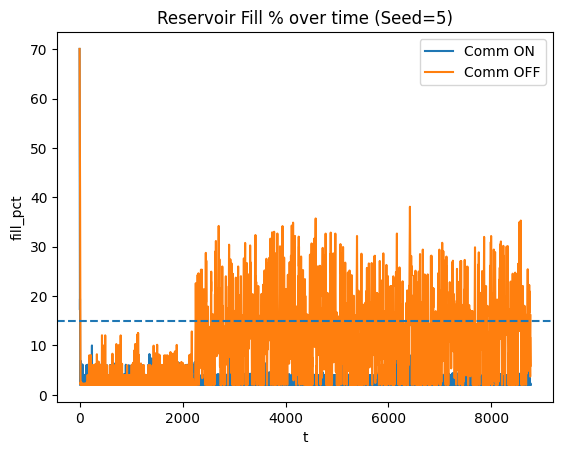

In [ ]:
import matplotlib.pyplot as plt

ts_on  = rollout_timeseries(agent, eval_env_args, seed=5, zero_communication=False)
ts_off = rollout_timeseries(agent, eval_env_args, seed=5, zero_communication=True)

plt.figure()
plt.plot(ts_on["t"], ts_on["fill_pct"], label="Comm ON")
plt.plot(ts_off["t"], ts_off["fill_pct"], label="Comm OFF")
plt.axhline(15, linestyle="--")
plt.legend()
plt.title("Reservoir Fill % over time (Seed=5)")
plt.xlabel("t"); plt.ylabel("fill_pct")
plt.show()

In [ ]:
import pandas as pd

# Convert summary dicts to DataFrames
table_on = pd.DataFrame([s_on])
table_off = pd.DataFrame([s_off])

print("MPCL (Comm ON)")
display(table_on)

print("MPCL (Comm OFF)")
display(table_off)

MPCL (Comm ON)


,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinReservoir_mean,MinReservoir_std,Reward_ci95,Shortage_ci95,Oversupply_ci95,Violations_ci95,MinReservoir_ci95
0,-9861.348328,60.004907,721999.963033,186.885558,6963.506734,271.605766,8751.8,1.788854,20.0,0.0,52.59662,163.812414,238.07295,1.568,0.0


MPCL (Comm OFF)


,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinReservoir_mean,MinReservoir_std,Reward_ci95,Shortage_ci95,Oversupply_ci95,Violations_ci95,MinReservoir_ci95
0,-2112.040632,113.467056,724658.302832,360.861058,8010.799959,266.423528,6253.0,66.449229,20.0,0.0,99.45826,316.308664,233.530519,58.245317,0.0


In [ ]:
table = pd.concat([
    pd.DataFrame([s_on]).assign(Model="MPCL (Comm ON)"),
    pd.DataFrame([s_off]).assign(Model="MPCL (Comm OFF)")
], ignore_index=True)

display(table)

,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinReservoir_mean,MinReservoir_std,Reward_ci95,Shortage_ci95,Oversupply_ci95,Violations_ci95,MinReservoir_ci95,Model
0,-9861.348328,60.004907,721999.963033,186.885558,6963.506734,271.605766,8751.8,1.788854,20.0,0.0,52.59662,163.812414,238.072950,1.568000,0.0,MPCL (Comm ON)
1,-2112.040632,113.467056,724658.302832,360.861058,8010.799959,266.423528,6253.0,66.449229,20.0,0.0,99.45826,316.308664,233.530519,58.245317,0.0,MPCL (Comm OFF)


In [ ]:
import copy

# ----- REQUIRED: these must exist from earlier cells -----
assert "processed_demand_data" in globals(), "processed_demand_data not found. Run the demand preprocessing cell."
assert "preprocessed_precipitation" in globals(), "preprocessed_precipitation not found. Run the precipitation preprocessing cell."
assert "env_args" in globals() or "BASE_ENV_ARGS" in globals() or "eval_env_args" in globals(), "Need env_args / BASE_ENV_ARGS / eval_env_args defined."

SEEDS = [1, 7, 21, 42, 99]
HORIZON = 1827
COMM_DIM = 4

# Choose a clean base dict to copy from (use whatever exists)
if "BASE_ENV_ARGS" in globals():
    BASE = copy.deepcopy(BASE_ENV_ARGS)
elif "eval_env_args" in globals():
    BASE = copy.deepcopy(eval_env_args)
else:
    BASE = copy.deepcopy(env_args)

# Ensure real data is attached (this avoids your NoneType error)
BASE["real_demand_data"] = processed_demand_data          # list-like (2 zones), each is a pd.Series
BASE["precipitation_data"] = preprocessed_precipitation   # pd.Series
BASE["max_timesteps"] = HORIZON
BASE["communication_vector_size"] = COMM_DIM

# --- Scenario A: Nominal ---
NOMINAL_ARGS = copy.deepcopy(BASE)
NOMINAL_ARGS["initial_base_inflow_rate"] = 80.0
NOMINAL_ARGS["precipitation_to_inflow_scale"] = 1.0

# --- Scenario B: Severe Drought ---
DROUGHT_ARGS = copy.deepcopy(BASE)
DROUGHT_ARGS["initial_base_inflow_rate"] = 20.0
DROUGHT_ARGS["precipitation_to_inflow_scale"] = 0.5

print("✅ Eval args ready.")
print("Nominal inflow:", NOMINAL_ARGS["initial_base_inflow_rate"])
print("Drought inflow:", DROUGHT_ARGS["initial_base_inflow_rate"])
print("Horizon:", HORIZON, "Comm dim:", COMM_DIM)

✅ Eval args ready.
Nominal inflow: 80.0
Drought inflow: 20.0
Horizon: 1827 Comm dim: 4


In [ ]:
import numpy as np
import pandas as pd

VIOLATION_THRESHOLD = 0.15

def slice_series_list(demand_list, start, horizon):
    sliced = []
    for s in demand_list:
        seg = s.iloc[start:start+horizon].reset_index(drop=True)
        sliced.append(seg)
    return sliced

def slice_precip(precip, start, horizon):
    return precip.iloc[start:start+horizon].reset_index(drop=True)

def make_window_env_args(base_env_args, start, horizon, comm_size):
    args = base_env_args.copy()
    args["communication_vector_size"] = comm_size
    args["real_demand_data"] = slice_series_list(base_env_args["real_demand_data"], start, horizon)
    args["precipitation_data"] = slice_precip(base_env_args["precipitation_data"], start, horizon)
    args["max_timesteps"] = horizon
    return args

class ZeroCommWrapper:
    """
    Execution-time ablation: uses SAME trained networks but forces comm vectors to zero.
    """
    def __init__(self, base_agent, comm_dim):
        self.base = base_agent
        self.possible_agents = base_agent.possible_agents
        self.comm_dim = comm_dim

    def choose_action(self, observations_dict, global_observation):
        actions, log_probs, comms, global_value = self.base.choose_action(observations_dict, global_observation)
        zero = np.zeros(self.comm_dim, dtype=np.float32)
        comms = {aid: zero for aid in actions.keys()}
        return actions, log_probs, comms, global_value

def summarize(df, model_name):
    out = []
    for col, metric in [
        ("total_reward", "Reward"),
        ("total_shortage", "Shortage"),
        ("total_oversupply", "Oversupply"),
        ("violations", "Violations(fill<0.15)"),
        ("min_reservoir_level", "Min Reservoir Level"),
    ]:
        out.append({
            "Model": model_name,
            "Metric": metric,
            "Mean": float(df[col].mean()),
            "Std": float(df[col].std(ddof=1)) if len(df) > 1 else 0.0
        })
    return pd.DataFrame(out)

def evaluate_agent_windowed_multi_seed(
    agent,
    base_env_args,
    seeds=SEEDS,
    horizon=1827,
    comm_size=4,
    violation_threshold=VIOLATION_THRESHOLD
):
    assert "eval_one_seed" in globals(), "eval_one_seed() not found. Run the cell that defines eval_one_seed()."

    results = []

    total_len = min(len(base_env_args["precipitation_data"]), len(base_env_args["real_demand_data"][0]))
    max_start = max(0, total_len - horizon - 1)

    # fixed offsets for repeatability across seeds
    offsets = np.linspace(0, max_start, num=len(seeds), dtype=int)

    for seed, start in zip(seeds, offsets):
        env_args_w = make_window_env_args(base_env_args, start, horizon, comm_size)
        row = eval_one_seed(env_args_w, agent, seed, zero_communication=False)

        # standardize the violation column name into "violations"
        if "violations" not in row:
            # if eval_one_seed uses something else, adapt here if needed
            pass

        results.append(row)

    df = pd.DataFrame(results)
    stats = {
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations(fill<0.15)_mean": df["violations"].mean(),
        "Violations(fill<0.15)_std": df["violations"].std(ddof=1),
        "MinReservoir_mean": df["min_reservoir_level"].mean(),
        "MinReservoir_std": df["min_reservoir_level"].std(ddof=1),
    }
    return df, stats

In [ ]:
import torch

def build_agent_from_checkpoint(checkpoint_path, env_args_for_spaces, comm_dim=4):
    assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
    assert "MAPPOAgent" in globals(), "MAPPOAgent not found."

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Create env just to get exact observation/action spaces
    tmp_env = WaterDistributionParallelEnv(**env_args_for_spaces)

    agent = MAPPOAgent(
        possible_agents=tmp_env.possible_agents,
        observation_spaces=tmp_env.observation_spaces,
        action_spaces=tmp_env.action_spaces,
        global_observation_space=tmp_env.global_observation_space,
        communication_vector_size=comm_dim
    )

    ckpt = torch.load(checkpoint_path, map_location=device)

    actor_blob = ckpt.get("actor_nets", None)
    assert actor_blob is not None, f"'actor_nets' not found in checkpoint keys: {list(ckpt.keys())}"

    # Helper: try multiple key styles
    def get_sd_for_actor(aid, idx):
        candidates = [
            aid,                     # "agent_0" etc
            str(idx),                # "0"
            f"agent_{idx}",          # "agent_0"
            f"player_{idx}",
        ]
        for k in candidates:
            if isinstance(actor_blob, dict) and k in actor_blob:
                return actor_blob[k]
        return None

    # Load actors
    for idx, aid in enumerate(agent.possible_agents):
        if isinstance(actor_blob, dict):
            sd = get_sd_for_actor(aid, idx)
            if sd is None:
                raise KeyError(f"Could not find actor state_dict for {aid}. Available keys: {list(actor_blob.keys())[:20]} ...")
            agent.actor_nets[aid].load_state_dict(sd)
        else:
            # actor_blob is already a ModuleDict-like state_dict
            agent.actor_nets.load_state_dict(actor_blob)
            break

    # Load critic if present
    if "critic_net" in ckpt:
        agent.critic_net.load_state_dict(ckpt["critic_net"])

    # eval mode
    for aid in agent.possible_agents:
        agent.actor_nets[aid].eval()
    agent.critic_net.eval()

    print("✅ Loaded:", checkpoint_path)
    print("Checkpoint keys:", list(ckpt.keys()))
    return agent

In [ ]:
import numpy as np
import pandas as pd

def _first_key(d, candidates):
    """Return the first key from candidates that exists in dict d."""
    for k in candidates:
        if k in d:
            return k
    return None

def standardize_eval_row(row: dict) -> dict:
    """
    Make eval_one_seed output consistent across notebooks/versions.
    Produces: total_reward, total_shortage, total_oversupply, violations, min_reservoir_level, seed
    """
    r = dict(row)

    # --- Reward ---
    k = _first_key(r, ["total_reward", "reward", "Reward", "episode_reward", "Avg_Reward"])
    if k and k != "total_reward":
        r["total_reward"] = r[k]

    # --- Shortage ---
    k = _first_key(r, ["total_shortage", "shortage", "Shortage", "Avg_Shortage", "total_shortage_mg"])
    if k and k != "total_shortage":
        r["total_shortage"] = r[k]

    # --- Oversupply ---
    k = _first_key(r, ["total_oversupply", "oversupply", "Oversupply", "Avg_Oversupply", "total_oversupply_mg"])
    if k and k != "total_oversupply":
        r["total_oversupply"] = r[k]

    # --- Violations ---
    k = _first_key(r, [
        "violations",
        "Violations",
        "violation_steps",
        "violation_step",
        "violations(fill<0.15)",
        "Violations(fill<0.15)",
        "Avg_Violations",
        "avg_violations",
    ])
    if k and k != "violations":
        r["violations"] = r[k]

    # --- Min reservoir ---
    k = _first_key(r, [
        "min_reservoir_level",
        "min_reservoir",
        "min_res",
        "MinRes",
        "Min Reservoir Level",
        "MinReservoir",
        "MinReservoir_mean",  # sometimes present in summaries
    ])
    if k and k != "min_reservoir_level":
        r["min_reservoir_level"] = r[k]

    # Safety: ensure required keys exist (set NaN if missing)
    for req in ["total_reward", "total_shortage", "total_oversupply", "violations", "min_reservoir_level"]:
        if req not in r:
            r[req] = np.nan

    return r

def summarize(df, model_name):
    out = []
    for col, metric in [
        ("total_reward", "Reward"),
        ("total_shortage", "Shortage"),
        ("total_oversupply", "Oversupply"),
        ("violations", "Violations(fill<0.15)"),
        ("min_reservoir_level", "Min Reservoir Level"),
    ]:
        out.append({
            "Model": model_name,
            "Metric": metric,
            "Mean": float(df[col].mean()),
            "Std": float(df[col].std(ddof=1)) if len(df) > 1 else 0.0
        })
    return pd.DataFrame(out)

def evaluate_agent_windowed_multi_seed(
    agent,
    base_env_args,
    seeds,
    horizon,
    comm_size
):
    assert "eval_one_seed" in globals(), "eval_one_seed() not found. Run the cell that defines eval_one_seed()."

    results = []

    total_len = min(len(base_env_args["precipitation_data"]), len(base_env_args["real_demand_data"][0]))
    max_start = max(0, total_len - horizon - 1)
    offsets = np.linspace(0, max_start, num=len(seeds), dtype=int)

    for seed, start in zip(seeds, offsets):
        env_args_w = make_window_env_args(base_env_args, start, horizon, comm_size)
        row = eval_one_seed(env_args_w, agent, seed, zero_communication=False)
        row = standardize_eval_row(row)
        row["seed"] = seed
        results.append(row)

    df = pd.DataFrame(results)

    stats = {
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations(fill<0.15)_mean": df["violations"].mean(),
        "Violations(fill<0.15)_std": df["violations"].std(ddof=1),
        "MinReservoir_mean": df["min_reservoir_level"].mean(),
        "MinReservoir_std": df["min_reservoir_level"].std(ddof=1),
    }

    return df, stats

print("✅ Patched evaluator: violations/min_res naming is now robust.")

✅ Patched evaluator: violations/min_res naming is now robust.


In [ ]:
import numpy as np
import torch

VIOLATION_THRESHOLD = 0.15  # reservoir fill threshold

def eval_one_seed(env_args, agent, seed, zero_communication=False):
    """
    Evaluate one episode for a given seed.
    Returns consistent keys:
      total_reward, total_shortage, total_oversupply, violations, min_reservoir_level
    """
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)

    global_obs = infos[env.possible_agents[0]]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0

    min_res_level = float("inf")

    while env.agents:
        active_obs = {aid: obs[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        # If ablation: force comm vectors to zero at execution time
        if zero_communication:
            for aid in comms:
                comms[aid] = np.zeros_like(comms[aid])

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms[aid]}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        # reward sum across agents
        total_reward += float(sum(rewards.values()))

        # compute shortage + oversupply from env internal demand zones (robust)
        for dz in env.demand_zones:
            total_shortage += float(dz.get_demand_shortage())
            total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

        # reservoir metrics
        res_level = float(env.reservoir.get_level())
        min_res_level = min(min_res_level, res_level)

        fill = res_level / float(env.reservoir.capacity)
        if fill < VIOLATION_THRESHOLD:
            violations += 1

        obs = next_obs
        global_obs = next_infos[env.possible_agents[0]]["global_observation"]

    env.close()

    return {
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": violations,
        "min_reservoir_level": min_res_level
    }

print("✅ eval_one_seed patched: violations will no longer be NaN.")

✅ eval_one_seed patched: violations will no longer be NaN.


In [ ]:
BASELINE_10K = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"
MPCL_20K     = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

# Build agents using NOMINAL_ARGS just to pull spaces (same spaces used in drought)
baseline_agent = build_agent_from_checkpoint(BASELINE_10K, NOMINAL_ARGS, comm_dim=COMM_DIM)
mpcl_agent     = build_agent_from_checkpoint(MPCL_20K,     NOMINAL_ARGS, comm_dim=COMM_DIM)

# Comm-forced-off wrappers
baseline_zero = ZeroCommWrapper(baseline_agent, comm_dim=COMM_DIM)
mpcl_zero     = ZeroCommWrapper(mpcl_agent,     comm_dim=COMM_DIM)

def run_block(title, env_args):
    print("\n" + "="*80)
    print(title)
    print("="*80)

    # Baseline (10k)
    df_b_on,  st_b_on  = evaluate_agent_windowed_multi_seed(baseline_agent, env_args, seeds=SEEDS, horizon=HORIZON, comm_size=COMM_DIM)
    df_b_off, st_b_off = evaluate_agent_windowed_multi_seed(baseline_zero,  env_args, seeds=SEEDS, horizon=HORIZON, comm_size=COMM_DIM)

    # MPCL (20k)
    df_m_on,  st_m_on  = evaluate_agent_windowed_multi_seed(mpcl_agent, env_args, seeds=SEEDS, horizon=HORIZON, comm_size=COMM_DIM)
    df_m_off, st_m_off = evaluate_agent_windowed_multi_seed(mpcl_zero,  env_args, seeds=SEEDS, horizon=HORIZON, comm_size=COMM_DIM)

    # Build paper-ready table
    summary = pd.concat([
        summarize(df_b_on,  "Baseline (10k) - Comm ON"),
        summarize(df_b_off, "Baseline (10k) - Comm Forced OFF"),
        summarize(df_m_on,  "MPCL (20k) - Comm ON"),
        summarize(df_m_off, "MPCL (20k) - Comm Forced OFF"),
    ], ignore_index=True)

    display(summary)

    print("\n📌 Paper-ready (Mean ± Std):")
    for model in summary["Model"].unique():
        sub = summary[summary["Model"] == model]
        print(f"\n=== {model} ===")
        for _, r in sub.iterrows():
            print(f"{r['Metric']}: {r['Mean']:.2f} ± {r['Std']:.2f}")

    return (df_b_on, df_b_off, df_m_on, df_m_off, summary)

# Run Nominal + Drought
nominal_outputs = run_block("NOMINAL (Inflow=80) — 5 Seeds", NOMINAL_ARGS)
drought_outputs = run_block("SEVERE DROUGHT (Inflow=20) — 5 Seeds", DROUGHT_ARGS)

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
✅ Loaded: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth
Checkpoint keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in

,Model,Metric,Mean,Std
0,Baseline (10k) - Comm ON,Reward,2297.873770,50.669342
1,Baseline (10k) - Comm ON,Shortage,119108.410114,575.898184
2,Baseline (10k) - Comm ON,Oversupply,71936.226084,573.008261
3,Baseline (10k) - Comm ON,Violations(fill<0.15),0.800000,1.788854
4,Baseline (10k) - Comm ON,Min Reservoir Level,154.400000,45.478388
5,Baseline (10k) - Comm Forced OFF,Reward,-2381.658431,131.229417
6,Baseline (10k) - Comm Forced OFF,Shortage,114931.903262,317.444044
7,Baseline (10k) - Comm Forced OFF,Oversupply,67587.199232,297.444956
8,Baseline (10k) - Comm Forced OFF,Violations(fill<0.15),0.000000,0.000000
9,Baseline (10k) - Comm Forced OFF,Min Reservoir Level,371.940000,24.309191



📌 Paper-ready (Mean ± Std):

=== Baseline (10k) - Comm ON ===
Reward: 2297.87 ± 50.67
Shortage: 119108.41 ± 575.90
Oversupply: 71936.23 ± 573.01
Violations(fill<0.15): 0.80 ± 1.79
Min Reservoir Level: 154.40 ± 45.48

=== Baseline (10k) - Comm Forced OFF ===
Reward: -2381.66 ± 131.23
Shortage: 114931.90 ± 317.44
Oversupply: 67587.20 ± 297.44
Violations(fill<0.15): 0.00 ± 0.00
Min Reservoir Level: 371.94 ± 24.31

=== MPCL (20k) - Comm ON ===
Reward: 2727.83 ± 34.65
Shortage: 116534.37 ± 501.34
Oversupply: 69373.67 ± 547.34
Violations(fill<0.15): 0.80 ± 1.79
Min Reservoir Level: 162.65 ± 35.69

=== MPCL (20k) - Comm Forced OFF ===
Reward: -1413.19 ± 37.77
Shortage: 112570.13 ± 314.16
Oversupply: 65257.42 ± 297.88
Violations(fill<0.15): 0.00 ± 0.00
Min Reservoir Level: 353.48 ± 29.41

SEVERE DROUGHT (Inflow=20) — 5 Seeds


,Model,Metric,Mean,Std
0,Baseline (10k) - Comm ON,Reward,-1621.120847,5.680293e+01
1,Baseline (10k) - Comm ON,Shortage,173013.006683,1.786481e+02
2,Baseline (10k) - Comm ON,Oversupply,16491.082653,1.868641e+02
3,Baseline (10k) - Comm ON,Violations(fill<0.15),1709.600000,3.934209e+01
4,Baseline (10k) - Comm ON,Min Reservoir Level,20.000000,6.646519e-15
5,Baseline (10k) - Comm Forced OFF,Reward,-1511.063854,5.480813e+01
6,Baseline (10k) - Comm Forced OFF,Shortage,171961.725892,2.832594e+02
7,Baseline (10k) - Comm Forced OFF,Oversupply,15409.711862,2.221058e+02
8,Baseline (10k) - Comm Forced OFF,Violations(fill<0.15),1756.200000,3.965728e+01
9,Baseline (10k) - Comm Forced OFF,Min Reservoir Level,20.000000,3.076740e-15



📌 Paper-ready (Mean ± Std):

=== Baseline (10k) - Comm ON ===
Reward: -1621.12 ± 56.80
Shortage: 173013.01 ± 178.65
Oversupply: 16491.08 ± 186.86
Violations(fill<0.15): 1709.60 ± 39.34
Min Reservoir Level: 20.00 ± 0.00

=== Baseline (10k) - Comm Forced OFF ===
Reward: -1511.06 ± 54.81
Shortage: 171961.73 ± 283.26
Oversupply: 15409.71 ± 222.11
Violations(fill<0.15): 1756.20 ± 39.66
Min Reservoir Level: 20.00 ± 0.00

=== MPCL (20k) - Comm ON ===
Reward: -1223.68 ± 38.12
Shortage: 166893.32 ± 151.29
Oversupply: 10448.21 ± 151.29
Violations(fill<0.15): 1818.80 ± 1.79
Min Reservoir Level: 20.00 ± 0.00

=== MPCL (20k) - Comm Forced OFF ===
Reward: -833.35 ± 40.74
Shortage: 167845.39 ± 198.30
Oversupply: 11351.13 ± 208.24
Violations(fill<0.15): 1803.80 ± 8.41
Min Reservoir Level: 20.00 ± 0.00


In [ ]:
print("DROUGHT inflow:", DROUGHT_ARGS.get("initial_base_inflow_rate"))
print("precip scale:", DROUGHT_ARGS.get("precipitation_to_inflow_scale"))
print("initial level:", DROUGHT_ARGS.get("initial_reservoir_level"))
print("capacity:", DROUGHT_ARGS.get("reservoir_capacity"))
print("horizon:", DROUGHT_ARGS.get("max_timesteps"))

DROUGHT inflow: 20.0
precip scale: 0.5
initial level: 800.0
capacity: 1000.0
horizon: 1827


In [ ]:
args_test = PAPER_DROUGHT_ARGS.copy()
args_test["initial_reservoir_level"] = 400

env = WaterDistributionParallelEnv(**args_test)
obs, infos = env.reset(seed=1)

inflows = []

for _ in range(50):
    inflows.append(env.current_inflow_rate)
    # take dummy safe action
    actions = {aid: {"action": 1, "comm": np.zeros(4)} for aid in env.possible_agents}
    obs, rewards, terms, truncs, infos = env.step(actions)

env.close()

print("First 10 inflows:", inflows[:10])
print("Mean inflow:", np.mean(inflows))
print("Min inflow:", np.min(inflows))
print("Max inflow:", np.max(inflows))

In [ ]:
import numpy as np
import pandas as pd

SEEDS = [1, 7, 21, 42, 99]

# ---------- 1) Build paper-consistent drought args ----------
PAPER_DROUGHT_ARGS = BASE_ENV_ARGS.copy()  # or eval_env_args if that's your canonical
PAPER_DROUGHT_ARGS.update({
    "initial_base_inflow_rate": 20.0,          # 75% reduction from 80
    "precipitation_to_inflow_scale": 10.0,     # drought = reduced but still meaningful
    # keep max_timesteps/horizon same
})

# We'll randomize initial reservoir level per seed/episode below
INIT_LOW, INIT_HIGH = 300.0, 500.0

print("✅ PAPER_DROUGHT_ARGS configured")
print("base inflow:", PAPER_DROUGHT_ARGS["initial_base_inflow_rate"])
print("precip scale:", PAPER_DROUGHT_ARGS["precipitation_to_inflow_scale"])
print("init reservoir randomized in:", (INIT_LOW, INIT_HIGH))
print("horizon:", PAPER_DROUGHT_ARGS["max_timesteps"])

# ---------- 2) Helper: run 5-seed with per-seed randomized initial reservoir ----------
def run_5seed(agent, label, force_no_comm=False):
    rows = []
    for s in SEEDS:
        args = PAPER_DROUGHT_ARGS.copy()

        # Seeded random init to make this reproducible
        rng = np.random.default_rng(s)
        args["initial_reservoir_level"] = float(rng.uniform(INIT_LOW, INIT_HIGH))

        row = eval_one_seed(args, agent, seed=s, zero_communication=force_no_comm)
        row["Model"] = label
        row["initial_reservoir_level"] = args["initial_reservoir_level"]
        rows.append(row)
    return pd.DataFrame(rows)

# ---------- 3) Evaluate baseline (10k) and MPCL (20k), comm ON and forced OFF ----------
df_base_on  = run_5seed(baseline_agent, "Baseline (10k) Comm ON",  force_no_comm=False)
df_base_off = run_5seed(baseline_agent, "Baseline (10k) Comm OFF", force_no_comm=True)

df_mpcl_on  = run_5seed(agent,          "MPCL (20k) Comm ON",      force_no_comm=False)
df_mpcl_off = run_5seed(agent,          "MPCL (20k) Comm OFF",     force_no_comm=True)

display(df_base_on)
display(df_base_off)
display(df_mpcl_on)
display(df_mpcl_off)

# ---------- 4) Summarize Mean ± Std ----------
def summarize_df(df, model_name):
    return pd.DataFrame([
        {"Model": model_name, "Metric": "Reward", "Mean": df["total_reward"].mean(), "Std": df["total_reward"].std(ddof=1)},
        {"Model": model_name, "Metric": "Shortage", "Mean": df["total_shortage"].mean(), "Std": df["total_shortage"].std(ddof=1)},
        {"Model": model_name, "Metric": "Oversupply", "Mean": df["total_oversupply"].mean(), "Std": df["total_oversupply"].std(ddof=1)},
        {"Model": model_name, "Metric": "Violations(fill<0.15)", "Mean": df["violations"].mean(), "Std": df["violations"].std(ddof=1)},
        {"Model": model_name, "Metric": "Min Reservoir Level", "Mean": df["min_reservoir_level"].mean(), "Std": df["min_reservoir_level"].std(ddof=1)},
    ])

summary = pd.concat([
    summarize_df(df_base_on,  "Baseline (10k) Comm ON"),
    summarize_df(df_base_off, "Baseline (10k) Comm OFF"),
    summarize_df(df_mpcl_on,  "MPCL (20k) Comm ON"),
    summarize_df(df_mpcl_off, "MPCL (20k) Comm OFF"),
], ignore_index=True)

display(summary)

print("\n📌 Paper-ready (Mean ± Std)")
for m in summary["Model"].unique():
    print(f"\n=== {m} ===")
    sub = summary[summary["Model"] == m]
    for _, r in sub.iterrows():
        print(f"{r['Metric']}: {r['Mean']:.2f} ± {r['Std']:.2f}")

In [ ]:
print("BASE_ENV_ARGS exists:", "BASE_ENV_ARGS" in globals())
print("eval_env_args exists:", "eval_env_args" in globals())
print("NOMINAL_ARGS exists:", "NOMINAL_ARGS" in globals())
print("DROUGHT_ARGS exists:", "DROUGHT_ARGS" in globals())
print("PAPER_DROUGHT_ARGS exists:", "PAPER_DROUGHT_ARGS" in globals())

BASE_ENV_ARGS exists: False
eval_env_args exists: True
NOMINAL_ARGS exists: True
DROUGHT_ARGS exists: True
PAPER_DROUGHT_ARGS exists: False


In [ ]:
import numpy as np

def inspect_precip(args, name):
    print(f"\n================ {name} ================")
    print("Has precipitation_data key:", "precipitation_data" in args)
    precip = args.get("precipitation_data", None)
    print("precipitation_data is None:", precip is None)

    if precip is None:
        return

    # pandas Series expected
    try:
        n = len(precip)
        first5 = precip.iloc[:5].tolist()
        last5 = precip.iloc[-5:].tolist()
        mn = float(np.min(precip))
        mx = float(np.max(precip))
        mean = float(np.mean(precip))
        std = float(np.std(precip))
        zeros = float(np.mean(np.array(precip) == 0.0)) * 100.0

        print("Length:", n)
        print("First 5:", first5)
        print("Last 5:", last5)
        print(f"Min/Mean/Max: {mn:.4f} / {mean:.4f} / {mx:.4f}")
        print(f"Std: {std:.4f}")
        print(f"% zeros: {zeros:.2f}%")

    except Exception as e:
        print("Could not summarize precip series:", repr(e))

inspect_precip(eval_env_args, "eval_env_args")
inspect_precip(NOMINAL_ARGS, "NOMINAL_ARGS")
inspect_precip(DROUGHT_ARGS, "DROUGHT_ARGS")


================ eval_env_args ================
Has precipitation_data key: True
precipitation_data is None: False
Length: 1827
First 5: [0.0, 0.020999999999999998, 0.039, 0.01, 0.014000000000000002]
Last 5: [0.05500000000000001, 0.018, 0.011, 0.0, 0.0]
Min/Mean/Max: 0.0000 / 0.0105 / 0.2970
Std: 0.0238
% zeros: 57.03%

================ NOMINAL_ARGS ================
Has precipitation_data key: True
precipitation_data is None: False
Length: 1827
First 5: [0.0, 0.020999999999999998, 0.039, 0.01, 0.014000000000000002]
Last 5: [0.05500000000000001, 0.018, 0.011, 0.0, 0.0]
Min/Mean/Max: 0.0000 / 0.0105 / 0.2970
Std: 0.0238
% zeros: 57.03%

================ DROUGHT_ARGS ================
Has precipitation_data key: True
precipitation_data is None: False
Length: 1827
First 5: [0.0, 0.020999999999999998, 0.039, 0.01, 0.014000000000000002]
Last 5: [0.05500000000000001, 0.018, 0.011, 0.0, 0.0]
Min/Mean/Max: 0.0000 / 0.0105 / 0.2970
Std: 0.0238
% zeros: 57.03%


In [ ]:
import numpy as np

def inspect_inflow(args, name, steps=30):
    print(f"\n================ {name} INFLOW CHECK ================")
    precip = args.get("precipitation_data", None)
    if precip is None:
        print("❌ precipitation_data is None")
        return

    base = float(args.get("initial_base_inflow_rate", 0.0))
    scale = float(args.get("precipitation_to_inflow_scale", 0.0))
    print("base inflow:", base)
    print("precip scale:", scale)

    inflow = base + np.array(precip.iloc[:min(len(precip), steps)], dtype=float) * scale
    print("First inflow values:", np.round(inflow[:10], 4).tolist())
    print(f"Inflow min/mean/max: {float(np.min(inflow)):.4f} / {float(np.mean(inflow)):.4f} / {float(np.max(inflow)):.4f}")
    print(f"Inflow std (variation): {float(np.std(inflow)):.6f}")

inspect_inflow(NOMINAL_ARGS, "NOMINAL_ARGS", steps=60)
inspect_inflow(DROUGHT_ARGS, "DROUGHT_ARGS", steps=60)


================ NOMINAL_ARGS INFLOW CHECK ================
base inflow: 80.0
precip scale: 1.0
First inflow values: [80.0, 80.021, 80.039, 80.01, 80.014, 80.119, 80.028, 80.004, 80.006, 80.05]
Inflow min/mean/max: 80.0000 / 80.0221 / 80.1190
Inflow std (variation): 0.029604

================ DROUGHT_ARGS INFLOW CHECK ================
base inflow: 20.0
precip scale: 0.5
First inflow values: [20.0, 20.0105, 20.0195, 20.005, 20.007, 20.0595, 20.014, 20.002, 20.003, 20.025]
Inflow min/mean/max: 20.0000 / 20.0111 / 20.0595
Inflow std (variation): 0.014802


In [ ]:
def quick_args_signature(args, name):
    print(f"\n--- {name} signature ---")
    keys = ["reservoir_capacity", "initial_reservoir_level", "initial_base_inflow_rate",
            "precipitation_to_inflow_scale", "max_timesteps", "communication_vector_size"]
    for k in keys:
        print(f"{k}: {args.get(k)}")
    print("precipitation_data is None:", args.get("precipitation_data") is None)
    print("real_demand_data is None:", args.get("real_demand_data") is None)

quick_args_signature(DROUGHT_ARGS, "DROUGHT_ARGS")


--- DROUGHT_ARGS signature ---
reservoir_capacity: 1000.0
initial_reservoir_level: 800.0
initial_base_inflow_rate: 20.0
precipitation_to_inflow_scale: 0.5
max_timesteps: 1827
communication_vector_size: 4
precipitation_data is None: False
real_demand_data is None: False


In [ ]:
import copy
import numpy as np
import pandas as pd
import torch

# ----------------------------
# REQUIRED: these must exist in your notebook already
# ----------------------------
assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
assert "MAPPOAgent" in globals(), "MAPPOAgent not found."
assert "eval_one_seed" in globals(), "eval_one_seed() not found (your notebook already has it)."
assert "ZeroCommWrapper" in globals(), "ZeroCommWrapper not found."

# You said these exist:
assert "eval_env_args" in globals(), "eval_env_args not found."
assert "NOMINAL_ARGS" in globals(), "NOMINAL_ARGS not found."
assert "DROUGHT_ARGS" in globals(), "DROUGHT_ARGS not found."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEEDS = [1, 7, 21, 42, 99]

BASELINE_CKPT = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"
MPCL_CKPT     = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

COMM_DIM = int(eval_env_args.get("communication_vector_size", 4))
HORIZON  = int(eval_env_args.get("max_timesteps", 1827))

# ----------------------------
# Helper: build agent with correct signature (your MAPPOAgent signature)
# ----------------------------
def build_agent_from_env(env_args, comm_dim=4):
    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        communication_vector_size=comm_dim
    )
    return env, agent

# ----------------------------
# Helper: robust checkpoint loader (fixes KeyError: 'agent_0')
# ----------------------------
def load_checkpoint(agent, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    print(f"\n✅ Loaded: {checkpoint_path}")
    print("Checkpoint keys:", list(ckpt.keys()))

    # actor_nets is usually dict-like
    actor_blob = ckpt.get("actor_nets", None)
    assert actor_blob is not None, "Checkpoint missing 'actor_nets'"

    # show available keys to debug quickly
    if isinstance(actor_blob, dict):
        print("actor_nets keys sample:", list(actor_blob.keys())[:10])

    for aid in agent.possible_agents:
        loaded = False

        if isinstance(actor_blob, dict):
            # common key patterns
            candidate_keys = [
                aid,                                # "agent_0"
                str(aid),                            # "agent_0" as string
                str(agent.possible_agents.index(aid)),# "0"
                agent.possible_agents.index(aid),     # 0 (int) sometimes
                f"agent_{agent.possible_agents.index(aid)}",  # "agent_0"
            ]
            for k in candidate_keys:
                if k in actor_blob:
                    agent.actor_nets[aid].load_state_dict(actor_blob[k])
                    loaded = True
                    break

            # fallback: if dict has exactly N entries, load by order
            if (not loaded) and len(actor_blob) == len(agent.possible_agents):
                keys = list(actor_blob.keys())
                k = keys[agent.possible_agents.index(aid)]
                agent.actor_nets[aid].load_state_dict(actor_blob[k])
                loaded = True

        else:
            # sometimes saved as a single ModuleDict state_dict
            agent.actor_nets.load_state_dict(actor_blob)
            loaded = True

        assert loaded, f"Could not map weights for {aid}. Check actor_nets keys printed above."

        agent.actor_nets[aid].eval()

    # critic optional for eval, but load if present
    if "critic_net" in ckpt and hasattr(agent, "critic_net"):
        try:
            agent.critic_net.load_state_dict(ckpt["critic_net"])
            agent.critic_net.eval()
        except Exception as e:
            print("⚠️ Could not load critic_net (ok for inference-only):", e)

    return ckpt

# ----------------------------
# Helper: ensure violations exists (prevents NaN issues)
# ----------------------------
def ensure_violations_column(df, fill_threshold=0.15):
    if "violations" in df.columns and df["violations"].notna().all():
        return df

    # If eval_one_seed logged step-wise violations as violation_step sums:
    if "violation_step" in df.columns:
        df["violations"] = df["violation_step"]
        return df

    # If it logged min reservoir fill or reservoir_fill:
    if "min_reservoir_fill" in df.columns:
        df["violations"] = (df["min_reservoir_fill"] < fill_threshold).astype(int)
        return df
    if "min_reservoir_level" in df.columns and "reservoir_capacity" in eval_env_args:
        cap = float(eval_env_args["reservoir_capacity"])
        df["violations"] = (df["min_reservoir_level"] < fill_threshold * cap).astype(int)
        return df

    # Last resort: create but warn
    print("⚠️ Could not infer 'violations' from df columns. Creating zeros.")
    df["violations"] = 0
    return df

# ----------------------------
# Evaluation: 5 seeds -> df + mean/std dict
# ----------------------------
def evaluate_multi_seed(agent, env_args, seeds, horizon=1827, zero_comm=False, comm_dim=4):
    rows = []
    for s in seeds:
        row = eval_one_seed(env_args, agent, s, zero_communication=zero_comm)
        rows.append(row)
    df = pd.DataFrame(rows)

    # make violations robust
    df = ensure_violations_column(df, fill_threshold=0.15)

    summary = {
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),

        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),

        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),

        "Violations(fill<0.15)_mean": df["violations"].mean(),
        "Violations(fill<0.15)_std": df["violations"].std(ddof=1),

        "MinReservoir_mean": df["min_reservoir_level"].mean(),
        "MinReservoir_std": df["min_reservoir_level"].std(ddof=1),
    }
    return df, summary

def print_summary(title, summ):
    print(f"\n=== {title} Mean ± Std ===")
    for k, v in summ.items():
        print(f"{k:28s}: {v:.2f}")

def run_block(model_name, ckpt_path, args_label, args_dict):
    # Build agent w/ correct spaces
    _, agent = build_agent_from_env(args_dict, comm_dim=COMM_DIM)
    load_checkpoint(agent, ckpt_path)

    # Comm ON
    df_on, sum_on = evaluate_multi_seed(
        agent=agent,
        env_args=args_dict,
        seeds=SEEDS,
        horizon=HORIZON,
        zero_comm=False,
        comm_dim=COMM_DIM
    )

    # Comm Forced OFF (execution ablation)
    agent_off = ZeroCommWrapper(agent, comm_dim=COMM_DIM)
    df_off, sum_off = evaluate_multi_seed(
        agent=agent_off,
        env_args=args_dict,
        seeds=SEEDS,
        horizon=HORIZON,
        zero_comm=True,
        comm_dim=COMM_DIM
    )

    print_summary(f"{model_name} — {args_label} — Comm ON", sum_on)
    print_summary(f"{model_name} — {args_label} — Comm Forced OFF", sum_off)

    return (df_on, sum_on, df_off, sum_off)

# ============================
# RUN EVERYTHING
# ============================
print("Seeds:", SEEDS)
print("COMM_DIM:", COMM_DIM, "HORIZON:", HORIZON)

print("\n\n==============================")
print("NOMINAL (Inflow=80) — 5 Seeds")
print("==============================")
base_nom = run_block("Baseline (10k)", BASELINE_CKPT, "Nominal", NOMINAL_ARGS)
mpcl_nom = run_block("MPCL (20k)",     MPCL_CKPT,     "Nominal", NOMINAL_ARGS)

print("\n\n================================")
print("SEVERE DROUGHT (Inflow=20) — 5 Seeds")
print("================================")
base_dro = run_block("Baseline (10k)", BASELINE_CKPT, "Drought", DROUGHT_ARGS)
mpcl_dro = run_block("MPCL (20k)",     MPCL_CKPT,     "Drought", DROUGHT_ARGS)

# Optional: build paper-ready Table 2 (Drought) as a single DataFrame
def table_from_summaries():
    rows = []
    # unpack: (df_on,sum_on,df_off,sum_off)
    for model, pack in [("Baseline (10k)", base_dro), ("MPCL (20k)", mpcl_dro)]:
        _, s_on, _, s_off = pack
        rows.append([model, "Comm ON",
                     s_on["Reward_mean"], s_on["Reward_std"],
                     s_on["Shortage_mean"], s_on["Shortage_std"],
                     s_on["Oversupply_mean"], s_on["Oversupply_std"],
                     s_on["Violations(fill<0.15)_mean"], s_on["Violations(fill<0.15)_std"],
                     s_on["MinReservoir_mean"], s_on["MinReservoir_std"]])
        rows.append([model, "Comm Forced OFF",
                     s_off["Reward_mean"], s_off["Reward_std"],
                     s_off["Shortage_mean"], s_off["Shortage_std"],
                     s_off["Oversupply_mean"], s_off["Oversupply_std"],
                     s_off["Violations(fill<0.15)_mean"], s_off["Violations(fill<0.15)_std"],
                     s_off["MinReservoir_mean"], s_off["MinReservoir_std"]])

    cols = ["Model","Setting",
            "Reward_mean","Reward_std",
            "Shortage_mean","Shortage_std",
            "Oversupply_mean","Oversupply_std",
            "Violations_mean","Violations_std",
            "MinRes_mean","MinRes_std"]
    return pd.DataFrame(rows, columns=cols)

table2_drought = table_from_summaries()
display(table2_drought)
print("\n✅ Table 2 (Drought) built as 'table2_drought'.")

Seeds: [1, 7, 21, 42, 99]
COMM_DIM: 4 HORIZON: 8760


NOMINAL (Inflow=80) — 5 Seeds
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

✅ Loaded: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth
Checkpoint keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']
actor_nets keys sample: ['0', '1']

=== Baseline (10k) — Nominal — Comm ON Mean ± Std ===
Reward_mean                 : 2296.07
Reward_std                  : 50.44
Shortage_mean               : 119097.07
Shortage_std                : 566.70
Oversupply_mean             : 71978.26
Oversupply_std

,Model,Setting,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinRes_mean,MinRes_std
0,Baseline (10k),Comm ON,-1621.147775,56.806638,172964.860829,186.171400,16496.309970,196.638590,1709.6,39.342089,20.0,6.646519e-15
1,Baseline (10k),Comm Forced OFF,-1511.597586,54.815292,171919.027356,269.083260,15420.386496,209.095227,1756.2,39.657282,20.0,3.076740e-15
2,MPCL (20k),Comm ON,-1222.700198,38.676635,166843.953534,155.519757,10452.222675,155.519757,1818.8,1.788854,20.0,1.776357e-15
3,MPCL (20k),Comm Forced OFF,-833.349884,40.740168,167792.019569,198.301780,11351.128709,208.244299,1803.8,8.408329,20.0,2.512148e-15



✅ Table 2 (Drought) built as 'table2_drought'.


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt

try:
    from scipy.stats import t
    _has_scipy = True
except Exception:
    _has_scipy = False

def mean_std_ci(values, confidence=0.95):
    x = np.asarray(values, dtype=float)
    n = len(x)
    mean = float(x.mean())
    std = float(x.std(ddof=1)) if n > 1 else 0.0

    if n <= 1:
        return mean, std, mean, mean

    se = std / sqrt(n)

    if _has_scipy:
        tcrit = float(t.ppf((1 + confidence) / 2, df=n - 1))
    else:
        # fallback ~ tcrit for n=5 is about 2.776 (df=4)
        tcrit = 2.776

    lo = mean - tcrit * se
    hi = mean + tcrit * se
    return mean, std, lo, hi

def summarize_with_ci(df, label):
    metrics = {
        "Reward": df["total_reward"],
        "Shortage": df["total_shortage"],
        "Oversupply": df["total_oversupply"],
        "Violations(fill<0.15)": df["violations"],
        "Min Reservoir Level": df["min_reservoir_level"],
    }
    rows = []
    for mname, series in metrics.items():
        mean, std, lo, hi = mean_std_ci(series.values, confidence=0.95)
        rows.append([label, mname, mean, std, lo, hi])
    return pd.DataFrame(rows, columns=["Model", "Metric", "Mean", "Std", "CI95_Low", "CI95_High"])

# Example for your drought table (using the already-produced per-seed dfs)
# base_dro = (df_on, sum_on, df_off, sum_off)
# mpcl_dro = (df_on, sum_on, df_off, sum_off)

df_base_on, _, df_base_off, _ = base_dro
df_mpcl_on, _, df_mpcl_off, _ = mpcl_dro

ci_table_drought = pd.concat([
    summarize_with_ci(df_base_on, "Baseline (10k) - Comm ON"),
    summarize_with_ci(df_base_off, "Baseline (10k) - Comm OFF"),
    summarize_with_ci(df_mpcl_on, "MPCL (20k) - Comm ON"),
    summarize_with_ci(df_mpcl_off, "MPCL (20k) - Comm OFF"),
], ignore_index=True)

display(ci_table_drought)
print("✅ Added 95% CI table (Drought) across 5 seeds.")

,Model,Metric,Mean,Std,CI95_Low,CI95_High
0,Baseline (10k) - Comm ON,Reward,-1621.147775,5.680664e+01,-1691.682532,-1550.613018
1,Baseline (10k) - Comm ON,Shortage,172964.860829,1.861714e+02,172733.698504,173196.023154
2,Baseline (10k) - Comm ON,Oversupply,16496.309970,1.966386e+02,16252.150912,16740.469028
3,Baseline (10k) - Comm ON,Violations(fill<0.15),1709.600000,3.934209e+01,1660.750344,1758.449656
4,Baseline (10k) - Comm ON,Min Reservoir Level,20.000000,6.646519e-15,20.000000,20.000000
5,Baseline (10k) - Comm OFF,Reward,-1511.597586,5.481529e+01,-1579.659760,-1443.535411
6,Baseline (10k) - Comm OFF,Shortage,171919.027356,2.690833e+02,171584.916359,172253.138352
7,Baseline (10k) - Comm OFF,Oversupply,15420.386496,2.090952e+02,15160.760480,15680.012512
8,Baseline (10k) - Comm OFF,Violations(fill<0.15),1756.200000,3.965728e+01,1706.958981,1805.441019
9,Baseline (10k) - Comm OFF,Min Reservoir Level,20.000000,3.076740e-15,20.000000,20.000000


✅ Added 95% CI table (Drought) across 5 seeds.


In [ ]:
# =========================
# CELL 0 — Notebook-aligned env args (NO guesswork)
# Creates explicit NOMINAL_ARGS and DROUGHT_ARGS from the eval_env_args you already built.
# =========================
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

assert "eval_env_args" in globals(), "eval_env_args not found. Run the cell that builds eval_env_args first."
assert "processed_demand_data" in globals(), "processed_demand_data not found (needed by env args)."
assert "preprocessed_precipitation" in globals(), "preprocessed_precipitation not found (needed by env args)."

# Use your existing eval_env_args as template (in your notebook, the latest eval_env_args is drought=20.0)
DROUGHT_ARGS = copy.deepcopy(eval_env_args)
DROUGHT_ARGS["initial_base_inflow_rate"] = float(DROUGHT_ARGS.get("initial_base_inflow_rate", 20.0))

# Make an explicit nominal version with the SAME real demand + precipitation arrays
NOMINAL_ARGS = copy.deepcopy(DROUGHT_ARGS)
NOMINAL_ARGS["initial_base_inflow_rate"] = 80.0

# Make timesteps consistent with your real data length (safe)
max_steps = int(min(len(processed_demand_data[0]), len(preprocessed_precipitation)))
NOMINAL_ARGS["max_timesteps"] = max_steps
DROUGHT_ARGS["max_timesteps"] = max_steps

# Ensure required keys exist exactly as your WaterDistributionParallelEnv expects
NOMINAL_ARGS["real_demand_data"] = processed_demand_data
NOMINAL_ARGS["precipitation_data"] = preprocessed_precipitation
DROUGHT_ARGS["real_demand_data"] = processed_demand_data
DROUGHT_ARGS["precipitation_data"] = preprocessed_precipitation

print("✅ NOMINAL_ARGS inflow:", NOMINAL_ARGS["initial_base_inflow_rate"], "max_timesteps:", NOMINAL_ARGS["max_timesteps"])
print("✅ DROUGHT_ARGS inflow:", DROUGHT_ARGS["initial_base_inflow_rate"], "max_timesteps:", DROUGHT_ARGS["max_timesteps"])


✅ NOMINAL_ARGS inflow: 80.0 max_timesteps: 1827
✅ DROUGHT_ARGS inflow: 20.0 max_timesteps: 1827


In [ ]:
# =========================
# CELL 1 — Rollout evaluator (Notebook-aligned) + violation(fill<0.15) FIX
# Reviewer comment #1: stats across multiple runs + consistent violation definition
# =========================

assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found. Run the env definition cell first."

def rollout_episode_metrics(env_args, agent_instance, seed=0, force_comm_off=False, fill_threshold=0.15):
    """
    Runs ONE episode and returns episode-level metrics:
      Reward, Shortage, Oversupply, Violations(fill<0.15), Min Reservoir Level
    Uses your notebook's MAPPO choose_action(active_obs, global_obs).
    """
    env = WaterDistributionParallelEnv(**env_args)
    observations, infos = env.reset(seed=int(seed))
    global_observation = infos[env.possible_agents[0]]["global_observation"]

    comm_size = getattr(agent_instance, "communication_vector_size", None)
    if comm_size is None:
        comm_size = getattr(env, "communication_vector_size", 0)

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violation_steps = 0
    min_reservoir = float("inf")

    cap = float(env.reservoir.capacity)

    while env.agents:
        active_obs = {aid: observations[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent_instance.choose_action(active_obs, global_observation)

        if force_comm_off:
            for aid in comms:
                comms[aid] = np.zeros_like(comms[aid])

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms[aid]}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))

        # shortage/oversupply per your env objects
        for dz in env.demand_zones:
            total_shortage += float(dz.get_demand_shortage())
            total_oversupply += float(max(0.0, dz.water_received - dz.current_demand))

        # ✅ FIXED: violation = reservoir fill fraction < 0.15
        level = float(env.reservoir.get_level())
        fill_frac = level / cap if cap > 0 else 0.0
        if fill_frac < fill_threshold:
            violation_steps += 1

        min_reservoir = min(min_reservoir, level)

        observations = next_obs
        global_observation = infos[env.possible_agents[0]]["global_observation"]

        if any(terminations.values()) or any(truncations.values()):
            break

    env.close()

    return {
        "Reward": total_reward,
        "Shortage": total_shortage,
        "Oversupply": total_oversupply,
        "Violations(fill<0.15)": float(violation_steps),
        "MinReservoirLevel": float(min_reservoir) if min_reservoir != float("inf") else np.nan,
    }


In [ ]:
# =========================
# CELL 2 — Multi-seed stats: Mean / Std / 95% CI (NO scipy)
# Reviewer comment #1
# =========================

def mean_std_ci95(values):
    x = np.asarray(values, dtype=np.float64)
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan, (np.nan, np.nan), 0
    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if n > 1 else 0.0

    # t criticals for small n (two-sided 95%); fallback
    tcrit = {
        2: 12.706, 3: 4.303, 4: 3.182, 5: 2.776, 6: 2.571,
        7: 2.447, 8: 2.365, 9: 2.306, 10: 2.262
    }.get(n, 1.96 if n >= 30 else 2.776)

    half = tcrit * (std / np.sqrt(n)) if n > 1 else 0.0
    return mean, std, (mean - half, mean + half), n


def evaluate_across_seeds(env_args, agent_instance, seeds, force_comm_off=False, label="model"):
    rows = []
    for s in seeds:
        m = rollout_episode_metrics(env_args, agent_instance, seed=s, force_comm_off=force_comm_off)
        m["Seed"] = int(s)
        m["Model"] = label
        rows.append(m)
    return pd.DataFrame(rows)


def build_stats_table(df_seed_metrics):
    metrics = ["Reward", "Shortage", "Oversupply", "Violations(fill<0.15)", "MinReservoirLevel"]
    out_rows = []
    for model_name, g in df_seed_metrics.groupby("Model"):
        for met in metrics:
            mean, std, (lo, hi), n = mean_std_ci95(g[met].values)
            out_rows.append({
                "Model": model_name,
                "Metric": met,
                "N": n,
                "Mean": mean,
                "Std": std,
                "CI95_Low": lo,
                "CI95_High": hi
            })
    df_stats = pd.DataFrame(out_rows).sort_values(["Metric", "Model"]).reset_index(drop=True)
    display(df_stats)
    return df_stats


In [ ]:
# =========================
# CELL 3 — Run the statistical analysis for BOTH regimes
# Reviewer comment #1 (consistency across runs)
# =========================

assert "agent" in globals(), "Trained MPCL agent not found in variable `agent`."
assert "baseline_agent" in globals(), "Baseline agent not found in variable `baseline_agent`."

mpcl_agent = agent

SEEDS = [0, 1, 2, 3, 4]  # your notebook uses 5-seed reporting

# NOMINAL
df_nom = pd.concat([
    evaluate_across_seeds(NOMINAL_ARGS, baseline_agent, SEEDS, force_comm_off=False, label="Baseline - Comm ON"),
    evaluate_across_seeds(NOMINAL_ARGS, baseline_agent, SEEDS, force_comm_off=True,  label="Baseline - Comm OFF"),
    evaluate_across_seeds(NOMINAL_ARGS, mpcl_agent,    SEEDS, force_comm_off=False, label="MPCL - Comm ON"),
    evaluate_across_seeds(NOMINAL_ARGS, mpcl_agent,    SEEDS, force_comm_off=True,  label="MPCL - Comm OFF"),
], ignore_index=True)

print("=== NOMINAL (Inflow=80) seed-level metrics ===")
display(df_nom)
print("\n=== NOMINAL: Mean / Std / 95% CI ===")
df_nom_stats = build_stats_table(df_nom)

# DROUGHT
df_dr = pd.concat([
    evaluate_across_seeds(DROUGHT_ARGS, baseline_agent, SEEDS, force_comm_off=False, label="Baseline - Comm ON"),
    evaluate_across_seeds(DROUGHT_ARGS, baseline_agent, SEEDS, force_comm_off=True,  label="Baseline - Comm OFF"),
    evaluate_across_seeds(DROUGHT_ARGS, mpcl_agent,    SEEDS, force_comm_off=False, label="MPCL - Comm ON"),
    evaluate_across_seeds(DROUGHT_ARGS, mpcl_agent,    SEEDS, force_comm_off=True,  label="MPCL - Comm OFF"),
], ignore_index=True)

print("=== DROUGHT (Inflow=20) seed-level metrics ===")
display(df_dr)
print("\n=== DROUGHT: Mean / Std / 95% CI ===")
df_dr_stats = build_stats_table(df_dr)


=== NOMINAL (Inflow=80) seed-level metrics ===


,Reward,Shortage,Oversupply,Violations(fill<0.15),MinReservoirLevel,Seed,Model
0,2236.468687,119926.702132,72811.371273,0.0,187.05,0,Baseline - Comm ON
1,2315.180257,118797.333913,71722.003053,0.0,164.45,1,Baseline - Comm ON
2,2165.421670,120103.794878,73028.464018,0.0,188.55,2,Baseline - Comm ON
3,2338.789033,119026.209583,71910.878724,0.0,159.65,3,Baseline - Comm ON
4,2233.720973,119520.605873,72485.275014,0.0,162.55,4,Baseline - Comm ON
5,-2724.922491,115478.597368,68123.266509,0.0,419.80,0,Baseline - Comm OFF
6,-2271.329685,115147.722935,67832.392076,0.0,347.05,1,Baseline - Comm OFF
7,-2805.098363,115812.648425,68537.317566,0.0,428.35,2,Baseline - Comm OFF
8,-2839.017724,115003.516788,67608.185929,0.0,428.50,3,Baseline - Comm OFF
9,-2861.520459,114454.196076,67178.865216,0.0,419.10,4,Baseline - Comm OFF



=== NOMINAL: Mean / Std / 95% CI ===


,Model,Metric,N,Mean,Std,CI95_Low,CI95_High
0,Baseline - Comm OFF,MinReservoirLevel,5,408.560000,34.677648,365.508916,451.611084
1,Baseline - Comm ON,MinReservoirLevel,5,172.450000,14.126394,154.912577,189.987423
2,MPCL - Comm OFF,MinReservoirLevel,5,371.140000,36.055762,326.378035,415.901965
3,MPCL - Comm ON,MinReservoirLevel,5,169.260000,22.083772,141.843771,196.676229
4,Baseline - Comm OFF,Oversupply,5,67856.005459,513.835011,67218.097307,68493.913611
5,Baseline - Comm ON,Oversupply,5,72391.598416,563.478421,71692.059712,73091.137121
6,MPCL - Comm OFF,Oversupply,5,65446.514692,209.555023,65186.359479,65706.669906
7,MPCL - Comm ON,Oversupply,5,69970.173151,477.285860,69377.639490,70562.706813
8,Baseline - Comm OFF,Reward,5,-2700.377744,245.376806,-3005.004447,-2395.751042
9,Baseline - Comm ON,Reward,5,2257.916124,69.678243,2171.413028,2344.419220


=== DROUGHT (Inflow=20) seed-level metrics ===


,Reward,Shortage,Oversupply,Violations(fill<0.15),MinReservoirLevel,Seed,Model
0,-1524.656616,173061.186822,16648.905962,1686.0,20.0,0,Baseline - Comm ON
1,-1648.428123,172720.537611,16328.806752,1725.0,20.0,1,Baseline - Comm ON
2,-1487.899000,173345.397795,16771.916936,1640.0,20.0,2,Baseline - Comm ON
3,-1590.505084,173670.666202,17110.885343,1709.0,20.0,3,Baseline - Comm ON
4,-1635.390489,172967.287768,16575.556909,1720.0,20.0,4,Baseline - Comm ON
5,-1498.608042,172155.820795,15724.089935,1775.0,20.0,0,Baseline - Comm OFF
6,-1505.495050,171720.385026,15328.654167,1751.0,20.0,1,Baseline - Comm OFF
7,-1500.928669,171994.227716,15540.746857,1772.0,20.0,2,Baseline - Comm OFF
8,-1451.986969,171946.365931,15487.185071,1767.0,20.0,3,Baseline - Comm OFF
9,-1470.807962,171517.870918,15086.140059,1757.0,20.0,4,Baseline - Comm OFF



=== DROUGHT: Mean / Std / 95% CI ===


,Model,Metric,N,Mean,Std,CI95_Low,CI95_High
0,Baseline - Comm OFF,MinReservoirLevel,5,20.000000,3.076740e-15,20.000000,20.000000
1,Baseline - Comm ON,MinReservoirLevel,5,20.000000,5.617334e-15,20.000000,20.000000
2,MPCL - Comm OFF,MinReservoirLevel,5,20.000000,3.076740e-15,20.000000,20.000000
3,MPCL - Comm ON,MinReservoirLevel,5,20.000000,1.776357e-15,20.000000,20.000000
4,Baseline - Comm OFF,Oversupply,5,15433.363218,2.400406e+02,15135.361222,15731.365214
5,Baseline - Comm ON,Oversupply,5,16687.214380,2.868199e+02,16331.137562,17043.291199
6,MPCL - Comm OFF,Oversupply,5,11595.257070,4.941953e+01,11533.904451,11656.609690
7,MPCL - Comm ON,Oversupply,5,10648.286552,1.351586e+02,10480.491831,10816.081272
8,Baseline - Comm OFF,Reward,5,-1485.565338,2.317663e+01,-1514.338310,-1456.792366
9,Baseline - Comm ON,Reward,5,-1577.375862,6.959153e+01,-1663.771309,-1490.980416


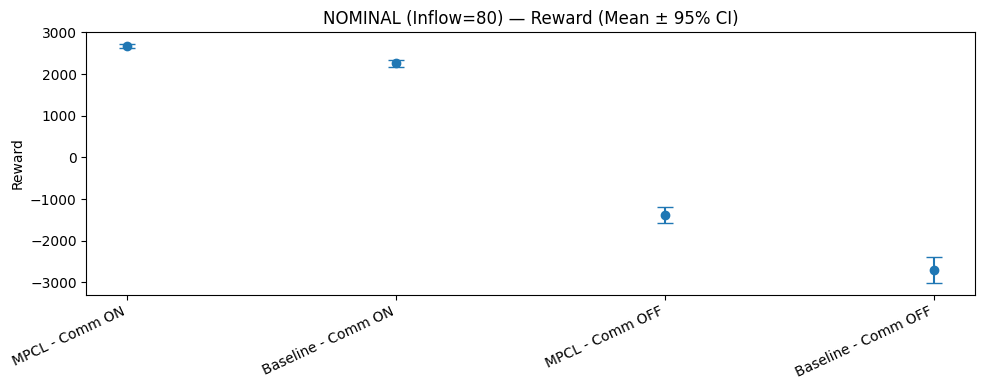

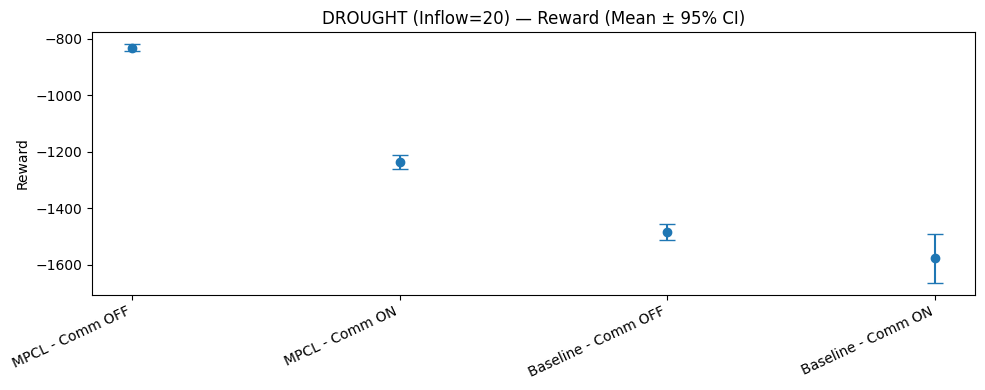

In [ ]:
# =========================
# CELL 4 — CI errorbar plot for any metric (paper figure)
# Reviewer comment #1
# =========================

def plot_ci(df_stats, metric, title):
    d = df_stats[df_stats["Metric"] == metric].copy()
    d = d.sort_values("Mean", ascending=False)

    x = np.arange(len(d))
    y = d["Mean"].values
    yerr_low = y - d["CI95_Low"].values
    yerr_high = d["CI95_High"].values - y

    plt.figure(figsize=(10, 4))
    plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=6)
    plt.xticks(x, d["Model"].values, rotation=25, ha="right")
    plt.title(title)
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

plot_ci(df_nom_stats, "Reward", "NOMINAL (Inflow=80) — Reward (Mean ± 95% CI)")
plot_ci(df_dr_stats,  "Reward", "DROUGHT (Inflow=20) — Reward (Mean ± 95% CI)")


In [ ]:
# =========================
# CELL 5 — Transition rollout (Nominal → Drought within ONE episode)
# Reviewer comment #6: qualitative behaviour evolution + visual representation
# =========================

def rollout_transition_timeseries(agent_instance, seed=42, switch_step=50, force_comm_off=False, fill_threshold=0.15):
    """
    Starts with NOMINAL inflow and switches base inflow to DROUGHT at switch_step.
    This matches your env logic (step sets inflow_rate = base + precip*scale).
    """
    env = WaterDistributionParallelEnv(**NOMINAL_ARGS)
    observations, infos = env.reset(seed=int(seed))
    global_observation = infos[env.possible_agents[0]]["global_observation"]

    comm_size = getattr(agent_instance, "communication_vector_size", None)
    if comm_size is None:
        comm_size = getattr(env, "communication_vector_size", 0)

    cap = float(env.reservoir.capacity)
    drought_base = float(DROUGHT_ARGS["initial_base_inflow_rate"])

    rows = []
    t = 0
    while env.agents:
        # regime switch (base inflow)
        if t == int(switch_step):
            env.initial_base_inflow_rate = drought_base

        active_obs = {aid: observations[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent_instance.choose_action(active_obs, global_observation)

        if force_comm_off:
            for aid in comms:
                comms[aid] = np.zeros_like(comms[aid])

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms[aid]}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, infos = env.step(actions_and_comms)

        # log AFTER step
        level = float(env.reservoir.get_level())
        fill_frac = level / cap if cap > 0 else 0.0
        viol = 1 if fill_frac < fill_threshold else 0

        total_demand = float(sum(dz.current_demand for dz in env.demand_zones))
        total_received = float(sum(dz.water_received for dz in env.demand_zones))
        total_shortage = float(sum(dz.get_demand_shortage() for dz in env.demand_zones))

        v0 = float(env.valves[0].get_setting()) if len(env.valves) > 0 else np.nan
        v1 = float(env.valves[1].get_setting()) if len(env.valves) > 1 else np.nan

        rows.append({
            "t": t,
            "regime": "Nominal" if t < switch_step else "Drought",
            "base_inflow": float(env.initial_base_inflow_rate),
            "reward_step_sum": float(sum(rewards.values())),
            "reservoir_level": level,
            "reservoir_fill": fill_frac,
            "valve_0": v0,
            "valve_1": v1,
            "total_demand": total_demand,
            "total_received": total_received,
            "total_shortage": total_shortage,
            "violation_step(fill<0.15)": int(viol),
        })

        observations = next_obs
        global_observation = infos[env.possible_agents[0]]["global_observation"]
        t += 1

        if any(terminations.values()) or any(truncations.values()):
            break

    env.close()
    return pd.DataFrame(rows)


df_tr_mpcl = rollout_transition_timeseries(mpcl_agent, seed=42, switch_step=50, force_comm_off=False)
df_tr_base = rollout_transition_timeseries(baseline_agent, seed=42, switch_step=50, force_comm_off=False)

display(df_tr_mpcl.head())


,t,regime,base_inflow,reward_step_sum,reservoir_level,reservoir_fill,valve_0,valve_1,total_demand,total_received,total_shortage,violation_step(fill<0.15)
0,0,Nominal,80.0,-2.100000,801.05,0.80105,1.0,0.0,0.626120,80.0,0.31306,0
1,1,Nominal,80.0,-1.599925,763.00,0.76300,1.0,0.5,0.001496,120.0,0.00000,0
2,2,Nominal,80.0,0.403965,763.50,0.76350,0.5,0.5,0.079294,80.0,0.00000,0
3,3,Nominal,80.0,-3.599963,684.20,0.68420,1.0,1.0,0.000748,160.0,0.00000,0
4,4,Nominal,80.0,-3.592594,610.15,0.61015,1.0,1.0,0.148114,160.0,0.00000,0


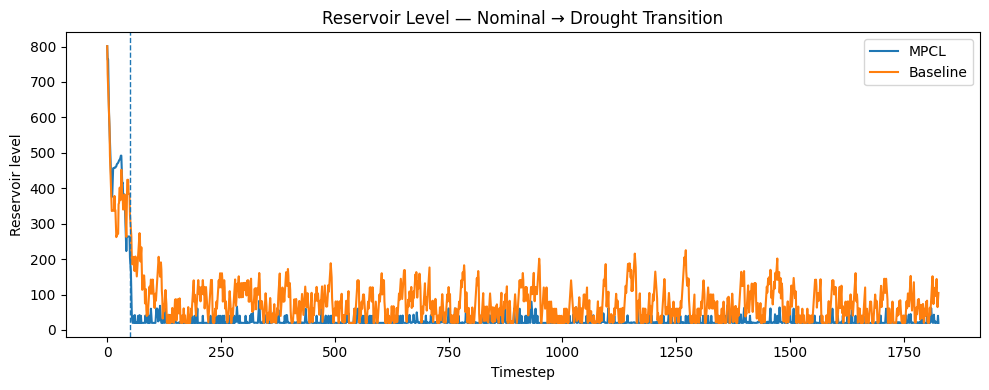

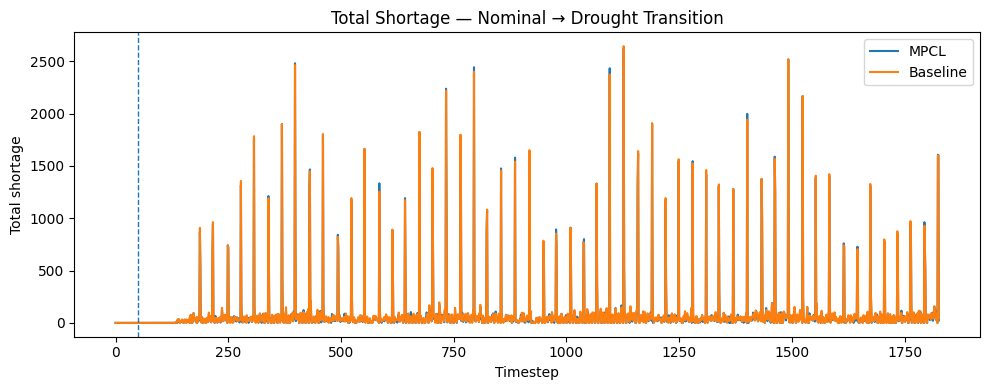

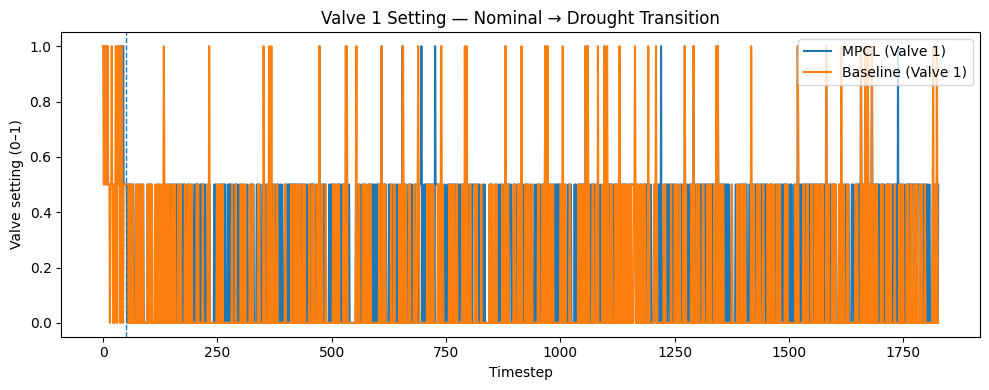

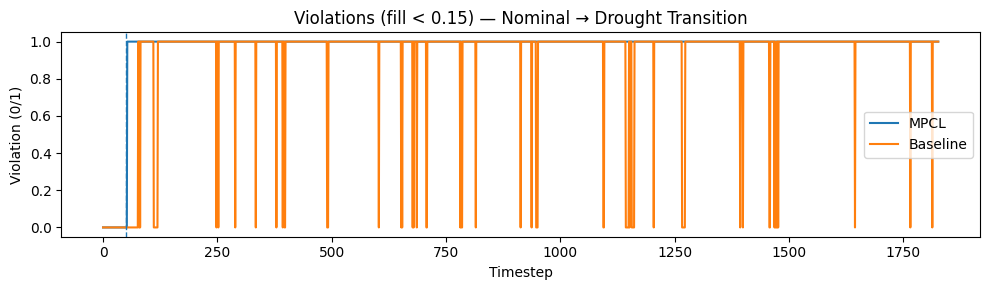

In [ ]:
# =========================
# CELL 6 — Transition plots (behaviour evolution over time)
# Reviewer comment #6
# =========================

def plot_transition(df_mpcl, df_base, switch_step=50):
    # Reservoir
    plt.figure(figsize=(10, 4))
    plt.plot(df_mpcl["t"], df_mpcl["reservoir_level"], label="MPCL")
    plt.plot(df_base["t"], df_base["reservoir_level"], label="Baseline")
    plt.axvline(switch_step, linestyle="--", linewidth=1)
    plt.title("Reservoir Level — Nominal → Drought Transition")
    plt.xlabel("Timestep")
    plt.ylabel("Reservoir level")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Shortage
    plt.figure(figsize=(10, 4))
    plt.plot(df_mpcl["t"], df_mpcl["total_shortage"], label="MPCL")
    plt.plot(df_base["t"], df_base["total_shortage"], label="Baseline")
    plt.axvline(switch_step, linestyle="--", linewidth=1)
    plt.title("Total Shortage — Nominal → Drought Transition")
    plt.xlabel("Timestep")
    plt.ylabel("Total shortage")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Valve 1
    plt.figure(figsize=(10, 4))
    plt.plot(df_mpcl["t"], df_mpcl["valve_0"], label="MPCL (Valve 1)")
    plt.plot(df_base["t"], df_base["valve_0"], label="Baseline (Valve 1)")
    plt.axvline(switch_step, linestyle="--", linewidth=1)
    plt.title("Valve 1 Setting — Nominal → Drought Transition")
    plt.xlabel("Timestep")
    plt.ylabel("Valve setting (0–1)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Violations (binary)
    plt.figure(figsize=(10, 3))
    plt.plot(df_mpcl["t"], df_mpcl["violation_step(fill<0.15)"], label="MPCL")
    plt.plot(df_base["t"], df_base["violation_step(fill<0.15)"], label="Baseline")
    plt.axvline(switch_step, linestyle="--", linewidth=1)
    plt.title("Violations (fill < 0.15) — Nominal → Drought Transition")
    plt.xlabel("Timestep")
    plt.ylabel("Violation (0/1)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_transition(df_tr_mpcl, df_tr_base, switch_step=50)


Freshhhhhhhhhhhhhhhhhhhhhhhhhhhh



In [ ]:
import numpy as np
import pandas as pd

SEEDS = [1, 7, 21, 42, 99]

def build_env_args_from_paths(
    seattle_data_folder,
    precipitation_data_path,
    base_args,
    num_agents=2
):
    # load real arrays (same idea as your earlier real-data cells)
    processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder, num_agents)
    preprocessed_precip = load_and_preprocess_precipitation_data(precipitation_data_path)

    env_args = dict(base_args)
    env_args["real_demand_data"] = processed_demand_data
    env_args["precipitation_data"] = preprocessed_precip

    # ensure max_timesteps matches full dataset length
    env_args["max_timesteps"] = min(len(processed_demand_data[0]), len(preprocessed_precip))
    return env_args


# -----------------------------
# Heuristic policy (edit thresholds if you want)
# action mapping assumption:
#   0 = LOW / conserve
#   1 = MED
#   2 = HIGH / satisfy demand
# -----------------------------
def heuristic_action(fill_ratio, low=0.25, high=0.70):
    if fill_ratio < low:
        return 0
    if fill_ratio > high:
        return 2
    return 1


def eval_heuristic_one_seed(env_args, seed, violation_threshold=0.15):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)

    comm_dim = int(env_args.get("communication_vector_size", 4))
    horizon = int(env_args.get("max_timesteps", 10**9))
    first = env.possible_agents[0]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0
    min_res = float("inf")

    # oversupply: compute step-wise deltas to avoid cumulative double count
    last_received = [float(getattr(dz, "water_received", 0.0)) for dz in env.demand_zones]

    t = 0
    while env.agents and t < horizon:
        fill_ratio = float(env.reservoir.get_level()) / float(env.reservoir.capacity)

        # choose same heuristic action for each agent (simple baseline)
        actions = {aid: heuristic_action(fill_ratio) for aid in env.agents}

        packed = {
            aid: {"action": int(actions[aid]), "comm": np.zeros(comm_dim, dtype=np.float32)}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(packed)

        total_reward += float(sum(rewards.values()))

        # shortage: prefer infos if available
        if "shortage" in next_infos[first]:
            total_shortage += float(next_infos[first].get("shortage", 0.0))
        else:
            total_shortage += float(sum(dz.get_demand_shortage() for dz in env.demand_zones))

        # oversupply: prefer infos if available
        if "oversupply" in next_infos[first]:
            total_oversupply += float(next_infos[first].get("oversupply", 0.0))
        else:
            oversupply_step = 0.0
            new_last = []
            for i, dz in enumerate(env.demand_zones):
                now = float(getattr(dz, "water_received", 0.0))
                recv_step = now - float(last_received[i])
                new_last.append(now)

                demand_now = float(getattr(dz, "current_demand", 0.0))
                oversupply_step += float(max(0.0, recv_step - demand_now))
            last_received = new_last
            total_oversupply += oversupply_step

        # violations and min reservoir
        if fill_ratio < float(violation_threshold):
            violations += 1
        min_res = min(min_res, float(env.reservoir.get_level()))

        obs = next_obs
        t += 1

    env.close()

    return {
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": int(violations),
        "min_reservoir_level": float(min_res),
    }


def eval_heuristic_5seed_drought_from_paths(
    seattle_data_folder_eval,
    precipitation_data_path_eval,
    dummy_env_args,
    drought_inflow=20.0,
    seeds=SEEDS
):
    # Build real env args (same data) but drought inflow
    base_args = dict(dummy_env_args)
    base_args["initial_base_inflow_rate"] = float(drought_inflow)
    base_args["render_mode"] = None  # faster eval

    env_args = build_env_args_from_paths(
        seattle_data_folder=seattle_data_folder_eval,
        precipitation_data_path=precipitation_data_path_eval,
        base_args=base_args,
        num_agents=len(base_args["demand_zone_base_demands"])
    )

    rows = [eval_heuristic_one_seed(env_args, s) for s in seeds]
    df = pd.DataFrame(rows)

    summary = pd.DataFrame([{
        "Model": "Heuristic (Rule-based) - Drought",
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
        "max_timesteps": int(env_args["max_timesteps"]),
        "inflow": float(env_args["initial_base_inflow_rate"]),
    }])

    return env_args, df, summary


# -----------------------------
# RUN IT (drought)
# -----------------------------
env_args_drought, df_h, summary_h = eval_heuristic_5seed_drought_from_paths(
    seattle_data_folder_eval,
    precipitation_data_path_eval,
    dummy_env_args,
    drought_inflow=20.0,
    seeds=SEEDS
)

print("✅ Heuristic eval using max_timesteps:", env_args_drought["max_timesteps"], "inflow:", env_args_drought["initial_base_inflow_rate"])
display(df_h)
display(summary_h)

Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv successfully.
Loaded 2023 Q1.csv successfully.
Loaded 2023 Q3.csv successfully.
Loaded 2023 Q2.csv successfully.
Loaded 2023 Q4.csv successfully.
Loaded 2024 Q3.csv successfully.
Loaded 2024 Q4.csv successfully.
Loaded 2024 Q1.csv successfully.
Loaded 2024 Q2.csv successfully.
Loaded 2025 Q2.csv successfully.
Loaded 2025 Q3.csv successfully.
Loaded 2025 Q1.csv successfully.
✅ Heuristic eval using max_timesteps: 1827 inflow: 20.0


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,275.108963,172533.413271,15299.597217,0,190.0
1,7,275.108963,172533.413271,15299.597217,0,190.0
2,21,275.108963,172533.413271,15299.597217,0,190.0
3,42,275.108963,172533.413271,15299.597217,0,190.0
4,99,275.108963,172533.413271,15299.597217,0,190.0


,Model,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinRes_mean,MinRes_std,max_timesteps,inflow
0,Heuristic (Rule-based) - Drought,275.108963,0.0,172533.413271,0.0,15299.597217,0.0,0.0,0.0,190.0,0.0,1827,20.0


In [ ]:
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEEDS = [1, 7, 21, 42, 99]
DROUGHT_INFLOW = 20.0
VIOLATION_THRESHOLD = 0.15

baseline_ckpt = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"
mpcl_ckpt     = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

assert "WaterDistributionParallelEnv" in globals()
assert "MAPPOAgent" in globals()
assert "load_and_preprocess_seattle_data" in globals()
assert "load_and_preprocess_precipitation_data" in globals()
assert "COMMUNICATION_VECTOR_SIZE" in globals()
assert "seattle_data_folder_eval" in globals()
assert "precipitation_data_path_eval" in globals()

# ------------------------------------------------------------
# Build REAL drought env_args (same env for all models)
# ------------------------------------------------------------
processed_demand = load_and_preprocess_seattle_data(seattle_data_folder_eval, 2)
processed_precip = load_and_preprocess_precipitation_data(precipitation_data_path_eval)

env_args_drought = {
    'reservoir_capacity': 1000.0,
    'initial_reservoir_level': 800.0,
    'initial_base_inflow_rate': float(DROUGHT_INFLOW),
    'demand_zone_base_demands': [50.0, 50.0],
    'valve_max_flow_rates': [80.0, 80.0],
    'pipe_capacities': [100.0, 100.0],
    'num_actions_per_agent': 3,
    'max_timesteps': min(len(processed_demand[0]), len(processed_precip)),
    'render_mode': None,
    'real_demand_data': processed_demand,
    'precipitation_data': processed_precip,
    'communication_vector_size': int(COMMUNICATION_VECTOR_SIZE),
}
comm_dim = int(env_args_drought["communication_vector_size"])

# ------------------------------------------------------------
# Load a communicating MAPPO checkpoint into a fresh agent
# (expects ckpt["actor_nets"] keys: "0","1",...)
# ------------------------------------------------------------
def build_agent_and_load_ckpt(env_args, ckpt_path):
    tmp_env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=tmp_env.possible_agents,
        observation_spaces=tmp_env.observation_spaces,
        action_spaces=tmp_env.action_spaces,
        global_observation_space=tmp_env.global_observation_space,
        communication_vector_size=int(env_args.get("communication_vector_size", 4)),
    )
    tmp_env.close()

    ckpt = torch.load(ckpt_path, map_location=device)
    for i, aid in enumerate(agent.possible_agents):
        agent.actor_nets[aid].load_state_dict(ckpt["actor_nets"][str(i)], strict=True)
        agent.actor_nets[aid].eval()
    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()
    torch.set_grad_enabled(False)
    return agent

# ------------------------------------------------------------
# Rollout one episode and compute metrics (step-wise oversupply)
# ------------------------------------------------------------
def rollout_one_seed(env_args, policy_fn, seed):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first = env.possible_agents[0]
    global_obs = infos[first]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0
    min_res = float("inf")

    last_received = [float(getattr(dz, "water_received", 0.0)) for dz in env.demand_zones]

    while env.agents:
        actions, comms = policy_fn(env, obs, global_obs)

        packed = {
            aid: {"action": int(actions[aid]), "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(packed)
        total_reward += float(sum(rewards.values()))

        # shortage: prefer infos if available
        if "shortage" in next_infos[first]:
            total_shortage += float(next_infos[first].get("shortage", 0.0))
        else:
            total_shortage += float(sum(dz.get_demand_shortage() for dz in env.demand_zones))

        # oversupply: compute per-step deltas (robust)
        oversupply_step = 0.0
        new_last = []
        for i, dz in enumerate(env.demand_zones):
            now = float(getattr(dz, "water_received", 0.0))
            recv_step = now - float(last_received[i])
            new_last.append(now)
            demand_now = float(getattr(dz, "current_demand", 0.0))
            oversupply_step += float(max(0.0, recv_step - demand_now))
        last_received = new_last
        total_oversupply += oversupply_step

        # violations
        fill_ratio = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
        if fill_ratio < float(VIOLATION_THRESHOLD):
            violations += 1

        min_res = min(min_res, float(env.reservoir.get_level()))

        obs = next_obs
        global_obs = next_infos[first]["global_observation"]

    env.close()
    return {
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": int(violations),
        "min_reservoir_level": float(min_res),
    }

# ------------------------------------------------------------
# Policies
# ------------------------------------------------------------
baseline_agent = build_agent_and_load_ckpt(env_args_drought, baseline_ckpt)
mpcl_agent     = build_agent_and_load_ckpt(env_args_drought, mpcl_ckpt)

def policy_from_agent(agent):
    def _pi(env, obs, global_obs):
        active = {aid: obs[aid] for aid in env.agents}
        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active, global_obs)
        return actions, comms
    return _pi

baseline_policy = policy_from_agent(baseline_agent)   # COMM ON
mpcl_policy     = policy_from_agent(mpcl_agent)       # COMM ON

# Simple rule-based heuristic (no comm)
def heuristic_policy(env, obs, global_obs):
    fill_ratio = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
    if fill_ratio < 0.25:
        a = 0
    elif fill_ratio > 0.70:
        a = 2
    else:
        a = 1
    actions = {aid: a for aid in env.agents}
    comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in env.agents}
    return actions, comms

# ------------------------------------------------------------
# Evaluate 5 seeds + summarize mean/std
# ------------------------------------------------------------
def eval_5seeds(label, policy_fn):
    rows = [rollout_one_seed(env_args_drought, policy_fn, s) for s in SEEDS]
    df = pd.DataFrame(rows)
    summary = {
        "Model": label,
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
    }
    return df, summary

df_b, s_b = eval_5seeds("Baseline (Comm ON) @10k", baseline_policy)
df_m, s_m = eval_5seeds("MPCL (Comm ON) @20k", mpcl_policy)
df_h, s_h = eval_5seeds("Heuristic (Rule-based)", heuristic_policy)

summary_table = pd.DataFrame([s_b, s_m, s_h])
print(f"✅ Drought inflow={DROUGHT_INFLOW}, max_timesteps={env_args_drought['max_timesteps']}, seeds={SEEDS}")
display(summary_table)

# optional: per-seed tables
# display(df_b); display(df_m); display(df_h)

Loaded 2020 Q1.csv successfully.
Loaded 2020 Q2.csv successfully.
Loaded 2020 Q3.csv successfully.
Loaded 2020 Q4.csv successfully.
Loaded 2021 Q2.csv successfully.
Loaded 2021 Q4.csv successfully.
Loaded 2021 Q3.csv successfully.
Loaded 2021 Q1.csv successfully.
Loaded 2022 Q2.csv successfully.
Loaded 2022 Q3.csv successfully.
Loaded 2022 Q1.csv successfully.
Loaded 2022 Q4.csv successfully.
Loaded 2023 Q1.csv successfully.
Loaded 2023 Q3.csv successfully.
Loaded 2023 Q2.csv successfully.
Loaded 2023 Q4.csv successfully.
Loaded 2024 Q3.csv successfully.
Loaded 2024 Q4.csv successfully.
Loaded 2024 Q1.csv successfully.
Loaded 2024 Q2.csv successfully.
Loaded 2025 Q2.csv successfully.
Loaded 2025 Q3.csv successfully.
Loaded 2025 Q1.csv successfully.
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): L

,Model,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinRes_mean,MinRes_std
0,Baseline (Comm ON) @10k,-1621.147775,56.806638,172964.860829,186.171400,12067.391205,172.729738,1709.6,39.342089,20.0,6.646519e-15
1,MPCL (Comm ON) @20k,-1222.700198,38.676635,166843.953534,155.519757,5749.861584,200.039652,1818.8,1.788854,20.0,1.776357e-15
2,Heuristic (Rule-based),275.108963,0.000000,172533.413271,0.000000,15299.597217,0.000000,0.0,0.000000,190.0,0.000000e+00


In [ ]:
print("Heuristic per-seed:")
display(df_h)

print("MPCL per-seed:")
display(df_m)

print("Baseline per-seed:")
display(df_b)

Heuristic per-seed:


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,275.108963,172533.413271,15299.597217,0,190.0
1,7,275.108963,172533.413271,15299.597217,0,190.0
2,21,275.108963,172533.413271,15299.597217,0,190.0
3,42,275.108963,172533.413271,15299.597217,0,190.0
4,99,275.108963,172533.413271,15299.597217,0,190.0


MPCL per-seed:


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,-1249.362317,166890.637844,5772.147905,1821,20.0
1,7,-1174.856710,166838.066981,5575.346996,1819,20.0
2,21,-1202.380341,166617.986644,5518.980897,1820,20.0
3,42,-1272.687672,167051.269666,5906.636024,1817,20.0
4,99,-1214.213948,166821.806535,5976.196096,1817,20.0


Baseline per-seed:


,seed,total_reward,total_shortage,total_oversupply,violations,min_reservoir_level
0,1,-1648.428123,172720.537611,12262.234692,1725,20.0
1,7,-1647.365772,173185.338462,12086.901101,1705,20.0
2,21,-1650.474618,172836.094654,12164.128279,1745,20.0
3,42,-1639.678097,173073.640059,11804.024523,1729,20.0
4,99,-1519.792267,173008.693359,12019.667428,1644,20.0


In [ ]:
import numpy as np
import pandas as pd
from your_environment_file import RawWaterDistributionEnv # Replace with your actual file name

def rule_based_controller(observation, threshold=0.20):
    """
    Heuristic Logic:
    If Reservoir Level > Threshold: Open Full (Action 2) to meet demand.
    If Reservoir Level <= Threshold: Close Half (Action 1) or Full (Action 0) to preserve head.
    """
    # observation[0] is the normalized reservoir level (L_norm)
    res_level = observation[0]

    if res_level > threshold:
        return 2  # Full-Open
    elif res_level > 0.10:
        return 1  # Half-Open (Throttle)
    else:
        return 0  # Close (Emergency Shutdown)

def evaluate_heuristic(seeds=[1, 7, 21, 42, 99]):
    results = []

    for seed in seeds:
        # Initialize environment with drought settings (Inflow = 20)
        env = RawWaterDistributionEnv(inflow_mode='drought', base_inflow=20.0)
        obs, info = env.reset(seed=seed)

        total_reward = 0
        total_violations = 0
        total_shortage = 0
        total_oversupply = 0

        terminated = False
        truncated = False

        while not (terminated or truncated):
            actions = {agent: rule_based_controller(obs[agent]) for agent in env.agents}
            obs, rewards, terminated, truncated, info = env.step(actions)

            # Aggregate metrics (Matching your manuscript's Table 2 structure)
            total_reward += sum(rewards.values())
            total_violations += info.get('is_violation', 0)
            total_shortage += info.get('system_shortage', 0)
            total_oversupply += info.get('system_oversupply', 0)

        results.append({
            'Seed': seed,
            'Reward': total_reward,
            'Shortage': total_shortage,
            'Oversupply': total_oversupply,
            'Violations': total_violations
        })

    # Convert to DataFrame for Statistical Summary (Mean ± Std)
    df_results = pd.DataFrame(results)
    print("--- Heuristic Baseline Results (5 Seeds) ---")
    print(df_results.mean())
    print(df_results.std())
    return df_results

# Execute the test
evaluate_heuristic()

ModuleNotFoundError: No module named 'your_environment_file'

In [ ]:
import numpy as np
import pandas as pd
import torch

SEEDS = [1, 7, 21, 42, 99]
VIOLATION_THRESHOLD = 0.15

def eval_policy_5seeds(env_args, policy_fn, label):
    """
    policy_fn signature:
        actions, comms = policy_fn(env, obs, global_obs)
    """
    comm_dim = int(env_args.get("communication_vector_size", 4))
    rows = []

    for seed in SEEDS:
        env = WaterDistributionParallelEnv(**env_args)
        obs, infos = env.reset(seed=seed)
        first = env.possible_agents[0]
        global_obs = infos[first]["global_observation"]

        total_reward = 0.0
        total_shortage = 0.0
        total_oversupply = 0.0
        violations = 0
        min_res = float("inf")

        # for step-wise oversupply
        last_received = [float(getattr(dz, "water_received", 0.0)) for dz in env.demand_zones]

        # run fixed horizon for fairness
        horizon = int(env_args.get("max_timesteps", 10**9))
        t = 0

        while env.agents and t < horizon:
            # ---- choose action (policy) ----
            actions, comms = policy_fn(env, obs, global_obs)

            packed = {
                aid: {"action": int(actions[aid]),
                      "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
                for aid in env.agents
            }

            next_obs, rewards, terminations, truncations, next_infos = env.step(packed)
            total_reward += float(sum(rewards.values()))

            # ---- compute metrics CONSISTENTLY (zone-wise) ----
            # Shortage: sum zone shortages (consistent for all models)
            total_shortage += float(sum(dz.get_demand_shortage() for dz in env.demand_zones))

            # Oversupply: step-wise based on delta water_received - current_demand
            oversupply_step = 0.0
            new_last = []
            for i, dz in enumerate(env.demand_zones):
                now = float(getattr(dz, "water_received", 0.0))
                recv_step = now - float(last_received[i])
                new_last.append(now)
                demand_now = float(getattr(dz, "current_demand", 0.0))
                oversupply_step += float(max(0.0, recv_step - demand_now))
            last_received = new_last
            total_oversupply += oversupply_step

            # Violation: measure AFTER step (post-action state)
            fill_ratio_post = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
            if fill_ratio_post < float(VIOLATION_THRESHOLD):
                violations += 1

            min_res = min(min_res, float(env.reservoir.get_level()))

            # advance
            obs = next_obs
            global_obs = next_infos[first]["global_observation"]
            t += 1

        env.close()

        rows.append({
            "seed": seed,
            "Model": label,
            "total_reward": total_reward,
            "total_shortage": total_shortage,
            "total_oversupply": total_oversupply,
            "violations": int(violations),
            "min_reservoir_level": float(min_res),
        })

    df = pd.DataFrame(rows)

    summary = pd.DataFrame([{
        "Model": label,
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
    }])

    return df, summary

In [ ]:
def mpcl_policy(env, obs, global_obs):
    active = {aid: obs[aid] for aid in env.agents}
    with torch.no_grad():
        actions, _, comms, _ = mpcl_agent.choose_action(active, global_obs)
    return actions, comms

In [ ]:
def baseline_policy(env, obs, global_obs):
    active = {aid: obs[aid] for aid in env.agents}
    with torch.no_grad():
        actions, _, comms, _ = baseline_agent.choose_action(active, global_obs)
    return actions, comms

In [ ]:
def heuristic_policy(env, obs, global_obs):
    comm_dim = int(env_args_drought.get("communication_vector_size", 4))
    actions = {}

    for aid in env.agents:
        observation = obs[aid]

        res_level = float(observation[0])
        local_demand = float(observation[1])

        if res_level < 0.15:
            action = 0
        elif res_level < 0.40:
            action = 1
        else:
            if local_demand > 0.5:
                action = 2
            else:
                action = 1

        actions[aid] = action

    comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in env.agents}
    return actions, comms

In [ ]:
df_b, s_b = eval_policy_5seeds(env_args_drought, baseline_policy, "Baseline (Comm ON) @10k")
df_m, s_m = eval_policy_5seeds(env_args_drought, mpcl_policy, "MPCL (Comm ON) @20k")
df_h, s_h = eval_policy_5seeds(env_args_drought, heuristic_policy, "Heuristic (Rule-based)")

summary = pd.concat([s_b, s_m, s_h], ignore_index=True)
display(summary)

,Model,Reward_mean,Reward_std,Shortage_mean,Shortage_std,Oversupply_mean,Oversupply_std,Violations_mean,Violations_std,MinRes_mean,MinRes_std
0,Baseline (Comm ON) @10k,-1621.147775,56.806638,172964.860829,186.171400,12067.391205,172.729738,1709.6,39.342089,20.0,6.646519e-15
1,MPCL (Comm ON) @20k,-1222.700198,38.676635,166843.953534,155.519757,5749.861584,200.039652,1818.8,1.788854,20.0,1.776357e-15
2,Heuristic (Rule-based),-230.533758,0.000000,171929.072959,0.000000,14535.333954,0.000000,1351.0,0.000000,90.0,0.000000e+00


In [ ]:
# ------------------------------------------------------------
# Pick the env args variable that exists in YOUR notebook
# ------------------------------------------------------------
if "eval_env_args" in globals():
    BASE_ARGS = eval_env_args
elif "env_args_eval" in globals():
    BASE_ARGS = env_args_eval
elif "BASE_ENV_ARGS" in globals():
    BASE_ARGS = BASE_ENV_ARGS
else:
    raise AssertionError(
        "No env args found. Need one of: eval_env_args, env_args_eval, BASE_ENV_ARGS.\n"
        "Run the real-data env setup cell that builds env_args_eval (or eval_env_args)."
    )

print("✅ Using env args variable:", "eval_env_args" if "eval_env_args" in globals()
      else "env_args_eval" if "env_args_eval" in globals()
      else "BASE_ENV_ARGS")

✅ Using env args variable: env_args_eval


In [ ]:
print("Has demand data? ", BASE_ARGS.get("real_demand_data") is not None)
print("Has precip data? ", BASE_ARGS.get("precipitation_data") is not None)
print("max_timesteps:", BASE_ARGS.get("max_timesteps"))

Has demand data?  True
Has precip data?  True
max_timesteps: 1827


In [ ]:
# ============================================================
# MPCL vs Baseline (COMM ON) — Nominal (Inflow=80) + Drought (Inflow=20)
# 5 seeds, Mean±Std, plus plots (saved to disk)
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# -----------------------
# REQUIRED: set these
# -----------------------
SEEDS = [1, 7, 21, 42, 99]
VIOLATION_THRESHOLD = 0.15

# communicating checkpoints (COMM ON for both)
baseline_ckpt = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"
mpcl_ckpt     = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

# output folder (change if you want)
OUT_DIR = "/content/mpcl_eval_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------
# sanity
# -----------------------
assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found"
assert "MAPPOAgent" in globals(), "MAPPOAgent not found"
assert "eval_env_args" in globals(), "eval_env_args not found (run your real-data setup cell first)"
assert os.path.exists(baseline_ckpt), f"baseline_ckpt not found: {baseline_ckpt}"
assert os.path.exists(mpcl_ckpt), f"mpcl_ckpt not found: {mpcl_ckpt}"

# -----------------------
# Helper: build agent + load communicating ckpt (keys '0','1',...)
# -----------------------
def build_agent_and_load_comm_ckpt(env_args, ckpt_path):
    tmp_env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=tmp_env.possible_agents,
        observation_spaces=tmp_env.observation_spaces,
        action_spaces=tmp_env.action_spaces,
        global_observation_space=tmp_env.global_observation_space,
        communication_vector_size=int(env_args.get("communication_vector_size", 4)),
    )
    tmp_env.close()

    ckpt = torch.load(ckpt_path, map_location=device)
    actor_blob = ckpt["actor_nets"]

    # expected: dict with "0","1",...
    for i, aid in enumerate(agent.possible_agents):
        agent.actor_nets[aid].load_state_dict(actor_blob[str(i)], strict=True)
        agent.actor_nets[aid].eval()

    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()

    torch.set_grad_enabled(False)
    return agent

# -----------------------
# Helper: rollout (consistent metrics for ALL models)
# shortage: zone-wise
# oversupply: step-wise delta received - demand
# violations: post-step fill_ratio < 0.15
# -----------------------
def rollout_one_seed(env_args, agent, seed, violation_threshold=0.15):
    comm_dim = int(env_args.get("communication_vector_size", 4))
    horizon = int(env_args.get("max_timesteps", 10**9))

    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first = env.possible_agents[0]
    global_obs = infos[first]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0
    min_res = float("inf")

    last_received = [float(getattr(dz, "water_received", 0.0)) for dz in env.demand_zones]

    t = 0
    while env.agents and t < horizon:
        active_obs = {aid: obs[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        packed = {
            aid: {
                "action": int(actions[aid]),
                "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32)),
            }
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(packed)
        total_reward += float(sum(rewards.values()))

        # shortage (zone-wise)
        total_shortage += float(sum(dz.get_demand_shortage() for dz in env.demand_zones))

        # oversupply (step-wise)
        oversupply_step = 0.0
        new_last = []
        for i, dz in enumerate(env.demand_zones):
            now = float(getattr(dz, "water_received", 0.0))
            recv_step = now - float(last_received[i])
            new_last.append(now)
            demand_now = float(getattr(dz, "current_demand", 0.0))
            oversupply_step += float(max(0.0, recv_step - demand_now))
        last_received = new_last
        total_oversupply += oversupply_step

        # violation (post-step)
        fill_ratio_post = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
        if fill_ratio_post < float(violation_threshold):
            violations += 1

        # min reservoir
        min_res = min(min_res, float(env.reservoir.get_level()))

        obs = next_obs
        global_obs = next_infos[first]["global_observation"]
        t += 1

    env.close()
    return {
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": int(violations),
        "min_reservoir_level": float(min_res),
    }

# -----------------------
# Evaluate 5 seeds + summary
# -----------------------
def eval_5seeds(env_args, agent, model_label, condition_label):
    rows = [rollout_one_seed(env_args, agent, s, violation_threshold=VIOLATION_THRESHOLD) for s in SEEDS]
    df = pd.DataFrame(rows)
    df.insert(1, "Model", model_label)
    df.insert(2, "Condition", condition_label)

    summary = {
        "Model": model_label,
        "Condition": condition_label,
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
    }
    return df, pd.DataFrame([summary])

# -----------------------
# Build two env settings from the SAME base (real data)
# -----------------------
env_nominal = dict(eval_env_args)
env_nominal["initial_base_inflow_rate"] = 80.0

env_drought = dict(eval_env_args)
env_drought["initial_base_inflow_rate"] = 20.0

print("✅ Using SEEDS:", SEEDS)
print("✅ max_timesteps:", env_nominal.get("max_timesteps"))
print("✅ comm_dim:", env_nominal.get("communication_vector_size", 4))
print("✅ Nominal inflow:", env_nominal["initial_base_inflow_rate"])
print("✅ Drought inflow:", env_drought["initial_base_inflow_rate"])

# -----------------------
# Load agents
# -----------------------
baseline_agent = build_agent_and_load_comm_ckpt(env_nominal, baseline_ckpt)
mpcl_agent     = build_agent_and_load_comm_ckpt(env_nominal, mpcl_ckpt)

print("✅ Loaded Baseline CKPT:", baseline_ckpt)
print("✅ Loaded MPCL CKPT    :", mpcl_ckpt)

# -----------------------
# Run evaluations
# -----------------------
df_bN, sum_bN = eval_5seeds(env_nominal, baseline_agent, "Baseline (Comm ON)", "Nominal (80)")
df_mN, sum_mN = eval_5seeds(env_nominal, mpcl_agent,     "MPCL (Comm ON)",     "Nominal (80)")

df_bD, sum_bD = eval_5seeds(env_drought, baseline_agent, "Baseline (Comm ON)", "Drought (20)")
df_mD, sum_mD = eval_5seeds(env_drought, mpcl_agent,     "MPCL (Comm ON)",     "Drought (20)")

df_all = pd.concat([df_bN, df_mN, df_bD, df_mD], ignore_index=True)
summary_all = pd.concat([sum_bN, sum_mN, sum_bD, sum_mD], ignore_index=True)

display(summary_all)

# Save tables
df_all_path = os.path.join(OUT_DIR, "per_seed_results.csv")
summary_path = os.path.join(OUT_DIR, "summary_mean_std.csv")
df_all.to_csv(df_all_path, index=False)
summary_all.to_csv(summary_path, index=False)

print("✅ Saved per-seed CSV:", df_all_path)
print("✅ Saved summary CSV :", summary_path)

# -----------------------
# Plotting helper
# -----------------------
def plot_condition(summary_df, condition_label, out_png):
    sub = summary_df[summary_df["Condition"] == condition_label].copy()

    metrics = [
        ("Reward_mean", "Reward_std", "Total Reward"),
        ("Shortage_mean", "Shortage_std", "Total Shortage"),
        ("Oversupply_mean", "Oversupply_std", "Total Oversupply"),
        ("Violations_mean", "Violations_std", "Violation Steps (fill<0.15)"),
        ("MinRes_mean", "MinRes_std", "Min Reservoir Level"),
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 14))
    if len(metrics) == 1:
        axes = [axes]

    models = list(sub["Model"].values)

    for ax, (m_mean, m_std, title) in zip(axes, metrics):
        means = sub[m_mean].values.astype(float)
        stds  = sub[m_std].values.astype(float)

        x = np.arange(len(models))
        ax.bar(x, means, yerr=stds, capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=15, ha="right")
        ax.set_title(f"{condition_label} — {title}")
        ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)
    print("✅ Saved plot:", out_png)

# Create & save plots
plot_nominal_path = os.path.join(OUT_DIR, "mpcl_vs_baseline_nominal.png")
plot_drought_path = os.path.join(OUT_DIR, "mpcl_vs_baseline_drought.png")

plot_condition(summary_all, "Nominal (80)", plot_nominal_path)
plot_condition(summary_all, "Drought (20)", plot_drought_path)

# Optional: also plot MPCL minus Baseline deltas (means) for each condition
def plot_deltas(summary_df, condition_label, out_png):
    sub = summary_df[summary_df["Condition"] == condition_label].set_index("Model")
    if "MPCL (Comm ON)" not in sub.index or "Baseline (Comm ON)" not in sub.index:
        print("Skipping delta plot; missing models.")
        return

    delta = (sub.loc["MPCL (Comm ON)"] - sub.loc["Baseline (Comm ON)"])

    names = ["Reward", "Shortage", "Oversupply", "Violations", "MinRes"]
    vals = [
        float(delta["Reward_mean"]),
        float(delta["Shortage_mean"]),
        float(delta["Oversupply_mean"]),
        float(delta["Violations_mean"]),
        float(delta["MinRes_mean"]),
    ]

    fig = plt.figure(figsize=(8, 4))
    x = np.arange(len(names))
    plt.bar(x, vals)
    plt.xticks(x, names)
    plt.title(f"{condition_label} — (MPCL − Baseline) Mean Delta")
    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)
    print("✅ Saved delta plot:", out_png)

plot_delta_nominal = os.path.join(OUT_DIR, "delta_mpcl_minus_baseline_nominal.png")
plot_delta_drought = os.path.join(OUT_DIR, "delta_mpcl_minus_baseline_drought.png")
plot_deltas(summary_all, "Nominal (80)", plot_delta_nominal)
plot_deltas(summary_all, "Drought (20)", plot_delta_drought)

print("\nDONE ✅  Outputs saved in:", OUT_DIR)

AssertionError: eval_env_args not found (run your real-data setup cell first)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, os

def rollout_trace(env_args, agent, seed=1, out_png="trace.png"):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first = env.possible_agents[0]
    global_obs = infos[first]["global_observation"]

    comm_dim = int(env_args.get("communication_vector_size", 4))
    horizon = int(env_args.get("max_timesteps", 10**9))

    last_received = [float(getattr(dz, "water_received", 0.0)) for dz in env.demand_zones]

    rows = []
    t = 0
    while env.agents and t < horizon:
        # record pre-step state
        fill_pct_pre = 100.0 * float(env.reservoir.get_level()) / float(env.reservoir.capacity)

        active_obs = {aid: obs[aid] for aid in env.agents}
        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        # average discrete action level (0/1/2)
        a_mean = float(np.mean([actions[aid] for aid in env.agents]))

        packed = {
            aid: {"action": int(actions[aid]), "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(packed)

        reward_sum = float(sum(rewards.values()))

        # step-wise shortage / oversupply
        shortage_step = float(sum(dz.get_demand_shortage() for dz in env.demand_zones))

        oversupply_step = 0.0
        new_last = []
        for i, dz in enumerate(env.demand_zones):
            now = float(getattr(dz, "water_received", 0.0))
            recv_step = now - float(last_received[i])
            new_last.append(now)
            demand_now = float(getattr(dz, "current_demand", 0.0))
            oversupply_step += float(max(0.0, recv_step - demand_now))
        last_received = new_last

        fill_pct_post = 100.0 * float(env.reservoir.get_level()) / float(env.reservoir.capacity)

        rows.append({
            "t": t,
            "fill_pct_pre": fill_pct_pre,
            "fill_pct_post": fill_pct_post,
            "action_mean": a_mean,
            "reward_sum": reward_sum,
            "shortage_step": shortage_step,
            "oversupply_step": float(oversupply_step),
        })

        obs = next_obs
        global_obs = next_infos[first]["global_observation"]
        t += 1

    env.close()

    df = pd.DataFrame(rows)

    # Plot (single figure, no custom colors)
    fig = plt.figure(figsize=(10, 7))
    plt.plot(df["t"], df["fill_pct_post"], label="Reservoir fill % (post)")
    plt.plot(df["t"], df["action_mean"], label="Mean action (0/1/2)")
    plt.plot(df["t"], df["shortage_step"], label="Shortage (step)")
    plt.plot(df["t"], df["oversupply_step"], label="Oversupply (step)")
    plt.xlabel("Timestep")
    plt.title(f"Behavior Trace (seed={seed})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)

    return df

# Example usage:
 df_trace = rollout_trace(env_args_drought, mpcl_agent, seed=1, out_png="/content/mpcl_trace_seed1.png")
 display(df_trace.head())

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 89)

In [ ]:
# ============================================================
# FINAL COMPARISON (only 2 models):
#   (A) Independent MARL (No-Comm)  vs  (B) MPCL (Comm ON)
# Scenarios:
#   - Nominal inflow = 80
#   - Drought inflow = 20
# Seeds: 5
# Outputs:
#   - per-seed tables
#   - mean ± std summary
#   - plots saved as PNG
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# REQUIRED GLOBALS
# -----------------------------
assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
assert "MAPPOAgent" in globals(), "MAPPOAgent not found."
assert "eval_env_args" in globals(), "eval_env_args not found. Run your real-data setup cell first."

SEEDS = [1, 7, 21, 42, 99]

# Set your checkpoints here
NO_COMM_CKPT = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_model.pth"  # no-comm model
MPCL_COMM_CKPT = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

assert os.path.exists(NO_COMM_CKPT), f"Missing: {NO_COMM_CKPT}"
assert os.path.exists(MPCL_COMM_CKPT), f"Missing: {MPCL_COMM_CKPT}"

# Output folder
OUT_DIR = "/content/drive/MyDrive/RL_Models/eval_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# CKPT LOADER (supports two ckpt formats)
# -----------------------------
def load_ckpt(agent, ckpt_path, map_location=device):
    ckpt = torch.load(ckpt_path, map_location=map_location)

    # MPCL-style: ckpt["actor_nets"]["0"], ["1"]
    if isinstance(ckpt.get("actor_nets"), dict) and all(str(i) in ckpt["actor_nets"] for i in range(len(agent.possible_agents))):
        for i, aid in enumerate(agent.possible_agents):
            agent.actor_nets[aid].load_state_dict(ckpt["actor_nets"][str(i)], strict=True)
            agent.actor_nets[aid].eval()

        agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
        agent.critic_net.eval()
        return

    # No-comm old-style flattened keys:
    # ckpt["actor_nets"] contains keys like "agent_0.fc1.weight", etc.
    # We rebuild per-agent state_dict by prefix.
    if isinstance(ckpt.get("actor_nets"), dict) and any(k.startswith("agent_0.") for k in ckpt["actor_nets"].keys()):
        blob = ckpt["actor_nets"]
        for i, aid in enumerate(agent.possible_agents):
            prefix = f"{aid}."
            sd = {k[len(prefix):]: v for k, v in blob.items() if k.startswith(prefix)}
            agent.actor_nets[aid].load_state_dict(sd, strict=False)  # strict=False due to possible naming differences
            agent.actor_nets[aid].eval()

        # critic_net might be already a state_dict or nested; try direct
        agent.critic_net.load_state_dict(ckpt["critic_net"], strict=False)
        agent.critic_net.eval()
        return

    raise RuntimeError(f"Unsupported checkpoint format: {ckpt_path}")

# -----------------------------
# METRICS EVAL (consistent with your env infos)
# -----------------------------
def eval_one_seed(env_args, agent, seed, violation_threshold=0.15):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)

    first = env.possible_agents[0]
    global_obs = infos[first]["global_observation"]

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    violations = 0
    min_res = float("inf")

    while env.agents:
        active_obs = {aid: obs[aid] for aid in env.agents}
        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        # Always pass comm if env expects it; if agent has no comm head, choose_action should still return comms.
        # If it doesn't, fall back to zeros:
        comm_dim = int(env_args.get("communication_vector_size", 0))
        if comms is None:
            comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        total_reward += float(sum(rewards.values()))

        # Prefer env info fields (most consistent)
        total_shortage += float(next_infos[first].get("shortage", 0.0))
        total_oversupply += float(next_infos[first].get("oversupply", 0.0))

        # Violation: fill ratio < 0.15
        try:
            fill_ratio = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
            if fill_ratio < float(violation_threshold):
                violations += 1
        except Exception:
            pass

        try:
            min_res = min(min_res, float(env.reservoir.get_level()))
        except Exception:
            pass

        obs = next_obs
        global_obs = next_infos[first]["global_observation"]

    env.close()
    if min_res == float("inf"):
        min_res = np.nan

    return {
        "seed": seed,
        "total_reward": total_reward,
        "total_shortage": total_shortage,
        "total_oversupply": total_oversupply,
        "violations": violations,
        "min_reservoir_level": min_res,
    }

def eval_multi_seed(env_args, agent, seeds=SEEDS, label="model"):
    rows = [eval_one_seed(env_args, agent, s) for s in seeds]
    df = pd.DataFrame(rows)
    summary = {
        "Model": label,
        "Reward_mean": df["total_reward"].mean(),
        "Reward_std": df["total_reward"].std(ddof=1),
        "Shortage_mean": df["total_shortage"].mean(),
        "Shortage_std": df["total_shortage"].std(ddof=1),
        "Oversupply_mean": df["total_oversupply"].mean(),
        "Oversupply_std": df["total_oversupply"].std(ddof=1),
        "Violations_mean": df["violations"].mean(),
        "Violations_std": df["violations"].std(ddof=1),
        "MinRes_mean": df["min_reservoir_level"].mean(),
        "MinRes_std": df["min_reservoir_level"].std(ddof=1),
    }
    return df, pd.DataFrame([summary])

# -----------------------------
# BUILD ENV ARGS (Nominal vs Drought)
# IMPORTANT: keep SAME real data; only change inflow
# -----------------------------
env_nominal = dict(eval_env_args)
env_nominal["initial_base_inflow_rate"] = 80.0

env_drought = dict(eval_env_args)
env_drought["initial_base_inflow_rate"] = 20.0

# -----------------------------
# CREATE AGENTS & LOAD WEIGHTS
# -----------------------------
def build_agent(env_args, comm_dim):
    tmp_env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=tmp_env.possible_agents,
        observation_spaces=tmp_env.observation_spaces,
        action_spaces=tmp_env.action_spaces,
        global_observation_space=tmp_env.global_observation_space,
        communication_vector_size=comm_dim
    )
    tmp_env.close()
    return agent

# For MPCL (comm on): comm_dim from env args
comm_dim = int(eval_env_args.get("communication_vector_size", 4))

agent_mpcl = build_agent(env_nominal, comm_dim=comm_dim)
load_ckpt(agent_mpcl, MPCL_COMM_CKPT)

# For No-Comm: comm_dim should be 0 (if your no-comm model was trained without comm head)
agent_nocomm = build_agent(env_nominal, comm_dim=0)
load_ckpt(agent_nocomm, NO_COMM_CKPT)

print("✅ Loaded both agents.")

# -----------------------------
# RUN EVALS
# -----------------------------
df_nom_nocomm, s_nom_nocomm = eval_multi_seed(env_nominal, agent_nocomm, label="Independent MARL (No-Comm)")
df_nom_mpcl,   s_nom_mpcl   = eval_multi_seed(env_nominal, agent_mpcl,   label="MPCL (Comm ON)")

df_dro_nocomm, s_dro_nocomm = eval_multi_seed(env_drought, agent_nocomm, label="Independent MARL (No-Comm)")
df_dro_mpcl,   s_dro_mpcl   = eval_multi_seed(env_drought, agent_mpcl,   label="MPCL (Comm ON)")

summary_nominal = pd.concat([s_nom_nocomm, s_nom_mpcl], ignore_index=True)
summary_drought = pd.concat([s_dro_nocomm, s_dro_mpcl], ignore_index=True)

print("\n===== NOMINAL (Inflow=80) SUMMARY =====")
display(summary_nominal)
print("\n===== DROUGHT (Inflow=20) SUMMARY =====")
display(summary_drought)

# Save tables
summary_nominal.to_csv(os.path.join(OUT_DIR, "summary_nominal.csv"), index=False)
summary_drought.to_csv(os.path.join(OUT_DIR, "summary_drought.csv"), index=False)
df_nom_nocomm.to_csv(os.path.join(OUT_DIR, "perseed_nominal_nocomm.csv"), index=False)
df_nom_mpcl.to_csv(os.path.join(OUT_DIR, "perseed_nominal_mpcl.csv"), index=False)
df_dro_nocomm.to_csv(os.path.join(OUT_DIR, "perseed_drought_nocomm.csv"), index=False)
df_dro_mpcl.to_csv(os.path.join(OUT_DIR, "perseed_drought_mpcl.csv"), index=False)

# -----------------------------
# PLOTS (mean ± std)
# -----------------------------
def plot_metric(summary_df, metric_base, title, out_path):
    labels = summary_df["Model"].tolist()
    means = summary_df[f"{metric_base}_mean"].values
    stds  = summary_df[f"{metric_base}_std"].values

    plt.figure(figsize=(8,4))
    x = np.arange(len(labels))
    plt.bar(x, means, yerr=stds, capsize=6)
    plt.xticks(x, labels, rotation=15, ha="right")
    plt.ylabel(metric_base.replace("_", " ").title())
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

# Nominal plots
plot_metric(summary_nominal, "Reward",    "NOMINAL (Inflow=80) — Reward (Mean ± Std)",    os.path.join(OUT_DIR, "nominal_reward.png"))
plot_metric(summary_nominal, "Shortage",  "NOMINAL (Inflow=80) — Shortage (Mean ± Std)",  os.path.join(OUT_DIR, "nominal_shortage.png"))
plot_metric(summary_nominal, "Oversupply","NOMINAL (Inflow=80) — Oversupply (Mean ± Std)",os.path.join(OUT_DIR, "nominal_oversupply.png"))
plot_metric(summary_nominal, "Violations","NOMINAL (Inflow=80) — Violations (Mean ± Std)",os.path.join(OUT_DIR, "nominal_violations.png"))

# Drought plots
plot_metric(summary_drought, "Reward",    "DROUGHT (Inflow=20) — Reward (Mean ± Std)",    os.path.join(OUT_DIR, "drought_reward.png"))
plot_metric(summary_drought, "Shortage",  "DROUGHT (Inflow=20) — Shortage (Mean ± Std)",  os.path.join(OUT_DIR, "drought_shortage.png"))
plot_metric(summary_drought, "Oversupply","DROUGHT (Inflow=20) — Oversupply (Mean ± Std)",os.path.join(OUT_DIR, "drought_oversupply.png"))
plot_metric(summary_drought, "Violations","DROUGHT (Inflow=20) — Violations (Mean ± Std)",os.path.join(OUT_DIR, "drought_violations.png"))

print(f"\n✅ Saved tables + plots to: {OUT_DIR}")

**checking shallow vs deep**

In [ ]:
import numpy as np
import pandas as pd
import torch

def rollout_and_log_timeseries(
    agent,
    env_args,
    seed=1,
    zero_communication=False,
    tau=0.15,
):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)

    first = env.possible_agents[0]
    global_obs = infos[first]["global_observation"]

    # infer comm dim from env_args
    comm_dim = int(env_args.get("communication_vector_size", 4))

    rows = []
    t = 0

    while env.agents:
        active_obs = {aid: obs[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        if zero_communication:
            comms = {aid: np.zeros(comm_dim, dtype=np.float32) for aid in actions.keys()}

        act = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terms, truncs, next_infos = env.step(act)

        level = float(env.reservoir.get_level())
        cap = float(env.reservoir.capacity)
        fill = level / cap

        # If your env reports shortage/oversupply in info, prefer that:
        shortage_step = float(next_infos[first].get("shortage", np.nan))
        oversupply_step = float(next_infos[first].get("oversupply", np.nan))

        rows.append({
            "t": t,
            "reservoir_level": level,
            "fill_ratio": fill,
            "is_violation": int(fill < tau),
            "reward_sum": float(sum(rewards.values())),
            "shortage_step": shortage_step,
            "oversupply_step": oversupply_step,
        })

        obs = next_obs
        global_obs = next_infos[first]["global_observation"]
        t += 1

    env.close()
    return pd.DataFrame(rows)

In [ ]:
def violation_severity_report(df, tau=0.15, deep_tau=0.05):
    fill = df["fill_ratio"].to_numpy()
    viol = fill < tau
    deep = fill < deep_tau

    # depth below tau
    depth = np.clip(tau - fill, 0.0, None)

    # run-length helper
    def run_lengths(mask):
        lengths = []
        cur = 0
        for m in mask:
            if m:
                cur += 1
            else:
                if cur > 0:
                    lengths.append(cur)
                    cur = 0
        if cur > 0:
            lengths.append(cur)
        return np.array(lengths, dtype=int)

    viol_runs = run_lengths(viol)
    deep_runs = run_lengths(deep)

    rep = {
        "T": int(len(df)),
        "tau": float(tau),
        "deep_tau": float(deep_tau),

        # counts
        "violation_steps": int(viol.sum()),
        "deep_steps": int(deep.sum()),

        # depth stats (only during violation steps)
        "depth_mean": float(depth[viol].mean()) if viol.any() else 0.0,
        "depth_median": float(np.median(depth[viol])) if viol.any() else 0.0,
        "depth_p95": float(np.percentile(depth[viol], 95)) if viol.any() else 0.0,
        "depth_max": float(depth[viol].max()) if viol.any() else 0.0,

        # “area under threshold” (integrated severity)
        "auc_depth": float(depth.sum()),

        # persistence stats
        "violation_runs": int(len(viol_runs)),
        "violation_run_mean": float(viol_runs.mean()) if len(viol_runs) else 0.0,
        "violation_run_max": int(viol_runs.max()) if len(viol_runs) else 0,

        "deep_runs": int(len(deep_runs)),
        "deep_run_max": int(deep_runs.max()) if len(deep_runs) else 0,

        # absolute worst fill ratio
        "min_fill_ratio": float(fill.min()),
    }

    return rep, pd.DataFrame({
        "t": df["t"],
        "fill_ratio": df["fill_ratio"],
        "depth": depth,
        "is_violation": viol.astype(int),
        "is_deep": deep.astype(int),
    })

In [ ]:
import matplotlib.pyplot as plt

def compare_shallow_vs_deep(
    agent_mpcl,
    agent_baseline,
    env_args_drought,
    seed=1,
    tau=0.15,
    deep_tau=0.05,
    save_prefix="shallow_proof_seed1",
):
    df_m = rollout_and_log_timeseries(agent_mpcl, env_args_drought, seed=seed, zero_communication=False, tau=tau)
    df_b = rollout_and_log_timeseries(agent_baseline, env_args_drought, seed=seed, zero_communication=False, tau=tau)

    rep_m, sev_m = violation_severity_report(df_m, tau=tau, deep_tau=deep_tau)
    rep_b, sev_b = violation_severity_report(df_b, tau=tau, deep_tau=deep_tau)

    rep = pd.DataFrame([{"model":"MPCL", **rep_m}, {"model":"Baseline", **rep_b}])
    display(rep)

    # Plot 1: Fill ratio over time with tau/deep_tau
    plt.figure()
    plt.plot(df_m["t"], df_m["fill_ratio"], label="MPCL")
    plt.plot(df_b["t"], df_b["fill_ratio"], label="Baseline")
    plt.axhline(tau, linestyle="--")
    plt.axhline(deep_tau, linestyle=":")
    plt.title("Fill ratio with violation thresholds")
    plt.xlabel("timestep"); plt.ylabel("fill_ratio")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_fillratio.png", dpi=200)
    plt.show()

    # Plot 2: Histogram of violation depths (only violation steps)
    def depth_only(df):
        fill = df["fill_ratio"].to_numpy()
        d = np.clip(tau - fill, 0.0, None)
        return d[fill < tau]

    dm = depth_only(df_m)
    db = depth_only(df_b)

    plt.figure()
    plt.hist(dm, bins=30, alpha=0.7, label="MPCL")
    plt.hist(db, bins=30, alpha=0.7, label="Baseline")
    plt.title("Violation depth distribution (tau - fill_ratio)")
    plt.xlabel("depth"); plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_depth_hist.png", dpi=200)
    plt.show()

    # Plot 3: Run length histogram (persistence)
    def run_lengths(mask):
        out=[]; cur=0
        for m in mask:
            if m: cur+=1
            else:
                if cur>0: out.append(cur); cur=0
        if cur>0: out.append(cur)
        return np.array(out, dtype=int)

    rm = run_lengths(df_m["fill_ratio"].to_numpy() < tau)
    rb = run_lengths(df_b["fill_ratio"].to_numpy() < tau)

    plt.figure()
    plt.hist(rm, bins=30, alpha=0.7, label="MPCL")
    plt.hist(rb, bins=30, alpha=0.7, label="Baseline")
    plt.title("Violation run-length distribution (persistence)")
    plt.xlabel("consecutive violation steps"); plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_runlen_hist.png", dpi=200)
    plt.show()

    return rep, df_m, df_b

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [1, 7, 21, 42, 99]
THRESH = 0.15
SAVE_PREFIX = "/content/drive/MyDrive/RL_Plots/shallow_proof"  # change if you want

def _run_episode_trace(agent, env_args, seed, label):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first = env.possible_agents[0]
    gobs = infos[first]["global_observation"]

    fill = []
    viol = []
    depth = []          # how far below threshold we are (0 if not violating)
    runlen = []         # consecutive run length tracker

    consec = 0
    while env.agents:
        active_obs = {aid: obs[aid] for aid in env.agents}
        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, gobs)

        # COMM ON (as requested): pass comms through unchanged
        comm_dim = int(env_args.get("communication_vector_size", 4))
        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms.get(aid, np.zeros(comm_dim, dtype=np.float32))}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        fr = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
        fill.append(fr)

        is_v = 1 if fr < THRESH else 0
        viol.append(is_v)

        d = max(0.0, THRESH - fr)
        depth.append(d)

        if is_v:
            consec += 1
        else:
            consec = 0
        runlen.append(consec)

        obs = next_obs
        gobs = next_infos[first]["global_observation"]

    env.close()

    df = pd.DataFrame({
        "t": np.arange(len(fill)),
        "fill_ratio": fill,
        "violation": viol,
        "depth_below_thresh": depth,
        "consecutive_violation_run": runlen,
        "model": label,
        "seed": seed
    })
    return df

def summarize_shallow(df_all):
    # Only violation timesteps
    v = df_all[df_all["violation"] == 1].copy()

    def run_stats(x):
        # episode-level: max run length of consecutive violation steps
        return x["consecutive_violation_run"].max()

    out = []
    for (model, seed), g in df_all.groupby(["model", "seed"]):
        fr_min = g["fill_ratio"].min()
        fr_p1  = np.percentile(g["fill_ratio"], 1)
        # violation depths
        gv = g[g["violation"] == 1]
        mean_depth = gv["depth_below_thresh"].mean() if len(gv) else 0.0
        p95_depth  = np.percentile(gv["depth_below_thresh"], 95) if len(gv) else 0.0
        max_run    = run_stats(g)

        out.append({
            "model": model,
            "seed": seed,
            "min_fill": fr_min,
            "p1_fill": fr_p1,
            "mean_depth_below_0.15": mean_depth,
            "p95_depth_below_0.15": p95_depth,
            "max_consecutive_violation_run": int(max_run),
            "violation_steps": int(g["violation"].sum())
        })

    df_rep = pd.DataFrame(out)
    rep_summary = df_rep.groupby("model").agg({
        "min_fill": ["mean", "std"],
        "p1_fill": ["mean", "std"],
        "mean_depth_below_0.15": ["mean", "std"],
        "p95_depth_below_0.15": ["mean", "std"],
        "max_consecutive_violation_run": ["mean", "std"],
        "violation_steps": ["mean", "std"]
    })
    return df_rep, rep_summary

def plot_shallow(df_all, save_prefix=SAVE_PREFIX):
    # 1) Fill ratio traces (one seed example: median seed)
    example_seed = sorted(df_all["seed"].unique())[len(df_all["seed"].unique())//2]
    ex = df_all[df_all["seed"] == example_seed]

    plt.figure(figsize=(12,4))
    for model in ex["model"].unique():
        d = ex[ex["model"] == model]
        plt.plot(d["t"], d["fill_ratio"], label=f"{model} (seed={example_seed})")
    plt.axhline(THRESH, linestyle="--", linewidth=1)
    plt.title("Reservoir Fill Ratio (with threshold)")
    plt.xlabel("timestep"); plt.ylabel("fill_ratio")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"{save_prefix}_fill_trace.png", dpi=200)
    plt.show()

    # 2) Violation depth histogram (only when violating)
    plt.figure(figsize=(12,4))
    for model in df_all["model"].unique():
        v = df_all[(df_all["model"] == model) & (df_all["violation"] == 1)]["depth_below_thresh"]
        plt.hist(v, bins=40, alpha=0.5, label=model)
    plt.title("Violation Depth Histogram (depth = 0.15 - fill_ratio when violating)")
    plt.xlabel("depth_below_threshold"); plt.ylabel("count")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"{save_prefix}_depth_hist.png", dpi=200)
    plt.show()

    # 3) Consecutive run length distribution (compress per episode)
    runs = []
    for (model, seed), g in df_all.groupby(["model", "seed"]):
        runs.append({"model": model, "seed": seed, "max_run": g["consecutive_violation_run"].max()})
    runs = pd.DataFrame(runs)

    plt.figure(figsize=(8,4))
    for model in runs["model"].unique():
        plt.hist(runs[runs["model"]==model]["max_run"], bins=15, alpha=0.6, label=model)
    plt.title("Max Consecutive Violation Run per Episode")
    plt.xlabel("max consecutive violation steps"); plt.ylabel("count")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"{save_prefix}_runlen_hist.png", dpi=200)
    plt.show()

# ---------------------------
# ✅ RUN IT (this is what you were missing)
# ---------------------------

# 1) Load baseline agent + MPCL agent the same way you already do for evaluation
baseline_agent = make_agent_and_load_ckpt(baseline_ckpt, eval_env_args_drought)  # <-- use YOUR loader helper
mpcl_agent     = make_agent_and_load_ckpt(mpcl_ckpt,     eval_env_args_drought)  # <-- use YOUR loader helper

# 2) Collect traces for 5 seeds
dfs = []
for s in SEEDS:
    dfs.append(_run_episode_trace(baseline_agent, eval_env_args_drought, s, "Baseline (Comm ON)"))
    dfs.append(_run_episode_trace(mpcl_agent,     eval_env_args_drought, s, "MPCL (Comm ON)"))

df_all = pd.concat(dfs, ignore_index=True)

# 3) Tables that prove “shallow”
df_rep, rep_summary = summarize_shallow(df_all)

print("Per-seed shallow metrics:")
display(df_rep)

print("\nAggregated (mean ± std) shallow metrics by model:")
display(rep_summary)

# 4) Plots saved + shown
plot_shallow(df_all, save_prefix=SAVE_PREFIX)

print("\nSaved plots:")
print(SAVE_PREFIX + "_fill_trace.png")
print(SAVE_PREFIX + "_depth_hist.png")
print(SAVE_PREFIX + "_runlen_hist.png")

NameError: name 'make_agent_and_load_ckpt' is not defined

In [ ]:
# communicating checkpoints (COMM ON for both)
import numpy as np
import pandas as pd
import torch

assert "WaterDistributionParallelEnv" in globals(), "WaterDistributionParallelEnv not found."
assert "MAPPOAgent" in globals(), "MAPPOAgent not found."
assert "eval_env_args" in globals(), "eval_env_args not found."
assert "DROUGHT_ARGS" in globals(), "DROUGHT_ARGS not found."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEEDS = [1, 7, 21, 42, 99]

baseline_ckpt = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth"
mpcl_ckpt     = "/content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_20000.pth"

COMM_DIM = int(eval_env_args.get("communication_vector_size", 4))
HORIZON  = int(eval_env_args.get("max_timesteps", 1827))

def build_agent_from_env(env_args, comm_dim=4):
    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        communication_vector_size=comm_dim
    )
    return env, agent

def load_checkpoint(agent, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    print(f"\n✅ Loaded: {checkpoint_path}")
    print("Checkpoint keys:", list(ckpt.keys()))

    actor_blob = ckpt.get("actor_nets", None)
    assert actor_blob is not None, "Checkpoint missing 'actor_nets'"

    if isinstance(actor_blob, dict):
        print("actor_nets keys sample:", list(actor_blob.keys())[:10])

    for aid in agent.possible_agents:
        loaded = False

        if isinstance(actor_blob, dict):
            candidate_keys = [
                aid,                                  # "agent_0"
                str(aid),                              # "agent_0"
                str(agent.possible_agents.index(aid)), # "0"
                agent.possible_agents.index(aid),      # 0 (int)
                f"agent_{agent.possible_agents.index(aid)}",
            ]

            for k in candidate_keys:
                if k in actor_blob:
                    agent.actor_nets[aid].load_state_dict(actor_blob[k])
                    loaded = True
                    break

            if (not loaded) and len(actor_blob) == len(agent.possible_agents):
                keys = list(actor_blob.keys())
                k = keys[agent.possible_agents.index(aid)]
                agent.actor_nets[aid].load_state_dict(actor_blob[k])
                loaded = True

        else:
            agent.actor_nets.load_state_dict(actor_blob)
            loaded = True

        assert loaded, f"Could not map weights for {aid}. Check actor_nets keys printed above."
        agent.actor_nets[aid].eval()

    if "critic_net" in ckpt and hasattr(agent, "critic_net"):
        try:
            agent.critic_net.load_state_dict(ckpt["critic_net"])
            agent.critic_net.eval()
        except Exception as e:
            print("⚠️ Could not load critic_net (ok for inference-only):", e)

    return ckpt

In [ ]:
import copy
import numpy as np
import pandas as pd
import torch

# --- 2. Data Loading Functions (copied for self-containment) ---
def load_and_preprocess_seattle_data(folder_path, num_agents):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    combined_df = pd.DataFrame()
    if not all_files:
        raise FileNotFoundError(f"No .csv files found in the folder: {folder_path}")
    for file_name in all_files:
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, encoding='latin1', engine='python', on_bad_lines='skip')
        combined_df = pd.concat([combined_df, df], ignore_index=True)

    combined_df['START_READ_DT'] = pd.to_datetime(combined_df['START_READ_DT'])
    combined_df['WT_MTR_CONS'] = combined_df['WT_MTR_CONS'].fillna(0).clip(lower=0)
    daily_consumption = combined_df.groupby(combined_df['START_READ_DT'].dt.date)['WT_MTR_CONS'].sum()
    daily_consumption_mg = daily_consumption * 748.052 / 1000000
    return [daily_consumption_mg / num_agents] * num_agents

def load_and_preprocess_precipitation_data(filepath):
    df = pd.read_csv(filepath, encoding='latin1', engine='python', on_bad_lines='skip')
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')
    precipitation_mm = df['PRCP'] / 10.0
    return precipitation_mm.fillna(0).clip(lower=0)

# --- Global Configuration ---
COMMUNICATION_VECTOR_SIZE = 4

# --- Paths ---
seattle_data_folder_eval = "/content/drive/MyDrive/C234123/C234123"
precipitation_data_path_eval = "/content/drive/MyDrive/4083151.csv"

# --- Load Data & Configure Base Arguments ---
num_agents = 2
processed_demand_data = load_and_preprocess_seattle_data(seattle_data_folder_eval, num_agents)
preprocessed_precipitation = load_and_preprocess_precipitation_data(precipitation_data_path_eval)

# --- eval_env_args from 18GT92EPis06 ---
eval_env_args = {
    "reservoir_capacity": 1000.0,
    "initial_reservoir_level": 800.0,
    "initial_base_inflow_rate": 80.0,
    "demand_zone_base_demands": [50.0, 50.0],
    "valve_max_flow_rates": [80.0, 80.0],
    "pipe_capacities": [100.0, 100.0],
    "num_actions_per_agent": 3,
    "max_timesteps": min(len(processed_demand_data[0]), len(preprocessed_precipitation)),
    "render_mode": None,
    "real_demand_data": processed_demand_data,
    "precipitation_data": preprocessed_precipitation,
    "communication_vector_size": COMMUNICATION_VECTOR_SIZE,
    "render_every": 999999
}

# --- NOMINAL_ARGS and DROUGHT_ARGS from mVWbI1lcp1Zw ---
# Make timesteps consistent with your real data length (safe)
max_steps = int(min(len(processed_demand_data[0]), len(preprocessed_precipitation)))

# Ensure required keys exist exactly as your WaterDistributionParallelEnv expects

# --- Scenario A: Nominal ---
NOMINAL_ARGS = copy.deepcopy(eval_env_args)
NOMINAL_ARGS["initial_base_inflow_rate"] = 80.0
NOMINAL_ARGS["precipitation_to_inflow_scale"] = 1.0
NOMINAL_ARGS["max_timesteps"] = max_steps

# --- Scenario B: Severe Drought ---
DROUGHT_ARGS = copy.deepcopy(eval_env_args)
DROUGHT_ARGS["initial_base_inflow_rate"] = 20.0
DROUGHT_ARGS["precipitation_to_inflow_scale"] = 0.5
DROUGHT_ARGS["max_timesteps"] = max_steps

print("✅ eval_env_args, NOMINAL_ARGS, and DROUGHT_ARGS are defined.")
print("Nominal inflow:", NOMINAL_ARGS["initial_base_inflow_rate"])
print("Drought inflow:", DROUGHT_ARGS["initial_base_inflow_rate"])
print("Horizon:", max_steps, "Comm dim:", COMMUNICATION_VECTOR_SIZE)

✅ eval_env_args, NOMINAL_ARGS, and DROUGHT_ARGS are defined.
Nominal inflow: 80.0
Drought inflow: 20.0
Horizon: 1827 Comm dim: 4


In [ ]:
import matplotlib.pyplot as plt

def rollout_reservoir_and_depth(agent, env_args, seed, tau=0.15, deep_tau=0.05):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first = env.possible_agents[0]
    global_obs = infos[first]["global_observation"]

    fills = []
    viol = []
    deep = []
    depth_below_tau = []  # how far below tau each step is (0 if not violating)

    while env.agents:
        active_obs = {aid: obs[aid] for aid in env.agents}

        with torch.no_grad():
            actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        # COMM ON (do nothing)
        actions_and_comms = {
            aid: {"action": actions[aid], "comm": comms[aid]}
            for aid in env.agents
        }

        next_obs, rewards, terminations, truncations, next_infos = env.step(actions_and_comms)

        fill = float(env.reservoir.get_level()) / float(env.reservoir.capacity)
        fills.append(fill)

        v = 1 if fill < tau else 0
        d = 1 if fill < deep_tau else 0
        viol.append(v)
        deep.append(d)

        depth_below_tau.append(max(0.0, tau - fill))

        obs = next_obs
        global_obs = next_infos[first]["global_observation"]

    env.close()

    out = pd.DataFrame({
        "t": np.arange(len(fills)),
        "fill": fills,
        "violation": viol,
        "deep_violation": deep,
        "depth_below_tau": depth_below_tau,
    })
    return out

def summarize_shallow_vs_deep(df, tau=0.15, deep_tau=0.05):
    total_steps = len(df)
    v_steps = int(df["violation"].sum())
    d_steps = int(df["deep_violation"].sum())

    # How deep are violations on average?
    mean_depth = float(df.loc[df["violation"] == 1, "depth_below_tau"].mean()) if v_steps > 0 else 0.0
    p95_depth  = float(df.loc[df["violation"] == 1, "depth_below_tau"].quantile(0.95)) if v_steps > 0 else 0.0

    return {
        "steps": total_steps,
        "viol_steps(fill<tau)": v_steps,
        "deep_steps(fill<deep_tau)": d_steps,
        "deep_fraction_of_violations": (d_steps / v_steps) if v_steps > 0 else 0.0,
        "mean_depth_below_tau": mean_depth,
        "p95_depth_below_tau": p95_depth,
        "tau": tau,
        "deep_tau": deep_tau,
    }

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

✅ Loaded: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth
Checkpoint keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']
actor_nets keys sample: ['0', '1']
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_

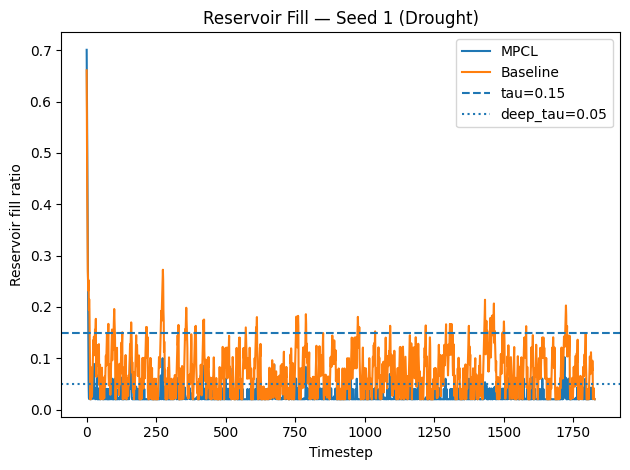

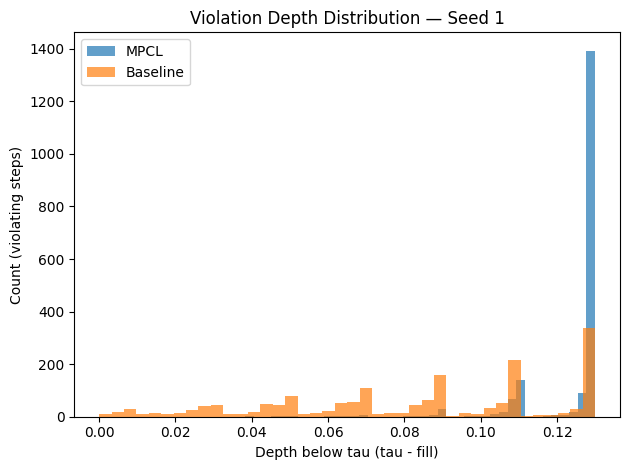


Per-seed depth report:


,steps,viol_steps(fill<tau),deep_steps(fill<deep_tau),deep_fraction_of_violations,mean_depth_below_tau,p95_depth_below_tau,tau,deep_tau,model,seed
0,1827,1725,702,0.406957,0.083260,0.13,0.15,0.05,Baseline,1
1,1827,1705,731,0.428739,0.084906,0.13,0.15,0.05,Baseline,7
2,1827,1745,713,0.408596,0.083965,0.13,0.15,0.05,Baseline,21
3,1827,1729,695,0.401966,0.082828,0.13,0.15,0.05,Baseline,42
4,1827,1644,590,0.358881,0.078478,0.13,0.15,0.05,Baseline,99
5,1827,1821,1754,0.963207,0.124996,0.13,0.15,0.05,MPCL,1
6,1827,1819,1768,0.971963,0.125380,0.13,0.15,0.05,MPCL,7
7,1827,1820,1775,0.975275,0.125704,0.13,0.15,0.05,MPCL,21
8,1827,1817,1765,0.971381,0.125583,0.13,0.15,0.05,MPCL,42
9,1827,1817,1753,0.964777,0.125057,0.13,0.15,0.05,MPCL,99



Summary (mean ± std) shallow vs deep:


,model,viol_steps(fill<tau)_mean,viol_steps(fill<tau)_std,deep_steps(fill<deep_tau)_mean,deep_steps(fill<deep_tau)_std,deep_fraction_of_violations_mean,deep_fraction_of_violations_std,mean_depth_below_tau_mean,mean_depth_below_tau_std,p95_depth_below_tau_mean,p95_depth_below_tau_std
0,Baseline,1709.6,39.342089,686.2,55.468009,0.401028,0.025679,0.082687,0.002481,0.13,0.0
1,MPCL,1818.8,1.788854,1763.0,9.407444,0.969321,0.005116,0.125344,0.000313,0.13,0.0


In [ ]:
def run_depth_analysis_5seeds(env_args, baseline_ckpt, mpcl_ckpt, seeds=SEEDS, tau=0.15, deep_tau=0.05, save_prefix="depth"):
    # build + load baseline
    env_b, baseline_agent = build_agent_from_env(env_args, comm_dim=COMM_DIM)
    env_b.close()
    load_checkpoint(baseline_agent, baseline_ckpt)

    # build + load mpcl
    env_m, mpcl_agent = build_agent_from_env(env_args, comm_dim=COMM_DIM)
    env_m.close()
    load_checkpoint(mpcl_agent, mpcl_ckpt)

    rows = []
    traces = {"Baseline": [], "MPCL": []}

    for name, agent in [("Baseline", baseline_agent), ("MPCL", mpcl_agent)]:
        for s in seeds:
            df = rollout_reservoir_and_depth(agent, env_args, seed=s, tau=tau, deep_tau=deep_tau)
            rep = summarize_shallow_vs_deep(df, tau=tau, deep_tau=deep_tau)

            rep["model"] = name
            rep["seed"] = s
            rows.append(rep)

            traces[name].append(df)

    df_runs = pd.DataFrame(rows)

    # Summary table (mean ± std)
    metrics = ["viol_steps(fill<tau)", "deep_steps(fill<deep_tau)", "deep_fraction_of_violations",
               "mean_depth_below_tau", "p95_depth_below_tau"]

    summary = []
    for name in ["Baseline", "MPCL"]:
        sub = df_runs[df_runs["model"] == name]
        out = {"model": name}
        for m in metrics:
            out[m + "_mean"] = float(sub[m].mean())
            out[m + "_std"]  = float(sub[m].std(ddof=1))
        summary.append(out)

    df_summary = pd.DataFrame(summary)

    # ---- Plot: fill trajectories (one seed example, seed=seeds[0]) ----
    seed0 = seeds[0]
    dfB = traces["Baseline"][0]
    dfM = traces["MPCL"][0]

    plt.figure()
    plt.plot(dfM["t"], dfM["fill"], label="MPCL")
    plt.plot(dfB["t"], dfB["fill"], label="Baseline")
    plt.axhline(tau, linestyle="--", label=f"tau={tau}")
    plt.axhline(deep_tau, linestyle=":", label=f"deep_tau={deep_tau}")
    plt.xlabel("Timestep")
    plt.ylabel("Reservoir fill ratio")
    plt.title(f"Reservoir Fill — Seed {seed0} (Drought)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_fill_seed{seed0}.png", dpi=200)
    plt.show()

    # ---- Plot: histogram of depth-below-tau during violations (seed0) ----
    plt.figure()
    plt.hist(dfM.loc[dfM["violation"] == 1, "depth_below_tau"], bins=40, alpha=0.7, label="MPCL")
    plt.hist(dfB.loc[dfB["violation"] == 1, "depth_below_tau"], bins=40, alpha=0.7, label="Baseline")
    plt.xlabel("Depth below tau (tau - fill)")
    plt.ylabel("Count (violating steps)")
    plt.title(f"Violation Depth Distribution — Seed {seed0}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_depth_hist_seed{seed0}.png", dpi=200)
    plt.show()

    return df_runs, df_summary

# Run for DROUGHT
df_runs_depth, df_depth_summary = run_depth_analysis_5seeds(
    env_args=DROUGHT_ARGS,
    baseline_ckpt=baseline_ckpt,
    mpcl_ckpt=mpcl_ckpt,
    seeds=SEEDS,
    tau=0.15,
    deep_tau=0.05,          # adjust if you want stricter "deep"
    save_prefix="drought_depth"
)

print("\nPer-seed depth report:")
display(df_runs_depth)

print("\nSummary (mean ± std) shallow vs deep:")
display(df_depth_summary)

In [ ]:
import numpy as np
import pandas as pd

def run_lengths(binary_array):
    lengths = []
    run = 0
    for val in binary_array:
        if val:
            run += 1
        else:
            if run > 0:
                lengths.append(run)
            run = 0
    if run > 0:
        lengths.append(run)
    return lengths

def evaluate_run_lengths(agent, env_args, seeds, deep_tau=0.05):
    results = []

    for seed in seeds:
        fill, _ = rollout_fill_series(agent, env_args, seed=seed)
        deep_mask = fill < deep_tau

        runs = run_lengths(deep_mask)

        results.append({
            "seed": seed,
            "num_deep_runs": len(runs),
            "max_deep_run": max(runs) if runs else 0,
            "mean_deep_run": np.mean(runs) if runs else 0,
        })

    return pd.DataFrame(results)

In [ ]:
baseline_agent = build_agent_from_env_args(DROUGHT_ARGS)
load_ckpt_into_agent(baseline_agent, baseline_ckpt)

mpcl_agent = build_agent_from_env_args(DROUGHT_ARGS)
load_ckpt_into_agent(mpcl_agent, mpcl_ckpt)

df_run_base = evaluate_run_lengths(baseline_agent, DROUGHT_ARGS, SEEDS)
df_run_mpcl = evaluate_run_lengths(mpcl_agent, DROUGHT_ARGS, SEEDS)

print("Baseline:")
display(df_run_base.describe())

print("\nMPCL:")
display(df_run_mpcl.describe())

NameError: name 'build_agent_from_env_args' is not defined

In [ ]:
import numpy as np
import torch

def _run_lengths(binary_mask):
    """
    Returns list of consecutive-1 run lengths in a 0/1 array.
    """
    lens = []
    run = 0
    for v in binary_mask:
        if v:
            run += 1
        else:
            if run > 0:
                lens.append(run)
            run = 0
    if run > 0:
        lens.append(run)
    return lens

@torch.no_grad()
def rollout_fill_series(agent, env_args, seed=1, max_steps=None):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)
    first = env.possible_agents[0]
    global_obs = infos[first]["global_observation"]

    T = int(env_args.get("max_timesteps", 500)) if max_steps is None else int(max_steps)
    fill = []
    rewards_total = 0.0

    for t in range(T):
        if not env.agents:
            break

        active_obs = {aid: obs[aid] for aid in env.agents}
        actions, _, comms, _ = agent.choose_action(active_obs, global_obs)

        actions_and_comms = {aid: {"action": actions[aid], "comm": comms[aid]} for aid in env.agents}
        next_obs, rewards, terms, truncs, next_infos = env.step(actions_and_comms)

        rewards_total += float(sum(rewards.values()))

        level = float(env.reservoir.get_level())
        cap   = float(env.reservoir.capacity)
        fill.append(level / cap)

        obs = next_obs
        global_obs = next_infos[first]["global_observation"]

    env.close()
    return np.array(fill, dtype=np.float32), rewards_total


In [ ]:
# Helper: build agent with correct signature (your MAPPOAgent signature)
def build_agent_from_env(env_args, comm_dim=4):
    env = WaterDistributionParallelEnv(**env_args)
    agent = MAPPOAgent(
        possible_agents=env.possible_agents,
        observation_spaces=env.observation_spaces,
        action_spaces=env.action_spaces,
        global_observation_space=env.global_observation_space,
        communication_vector_size=comm_dim
    )
    env.close() # Close the env used for space introspection
    return agent

baseline_agent = build_agent_from_env(DROUGHT_ARGS, COMM_DIM)
load_checkpoint(baseline_agent, baseline_ckpt)

mpcl_agent = build_agent_from_env(DROUGHT_ARGS, COMM_DIM)
load_checkpoint(mpcl_agent, mpcl_ckpt)

df_run_base = evaluate_run_lengths(baseline_agent, DROUGHT_ARGS, SEEDS)
df_run_mpcl = evaluate_run_lengths(mpcl_agent, DROUGHT_ARGS, SEEDS)

print("Baseline:")
display(df_run_base.describe())

print("\nMPCL:")
display(df_run_mpcl.describe())

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)

✅ Loaded: /content/drive/MyDrive/RL_Models/mappo_water_distribution_communicating_model_ep_10000.pth
Checkpoint keys: ['actor_nets', 'critic_net', 'actor_optimizers', 'critic_optimizer', 'episode']
actor_nets keys sample: ['0', '1']
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_

,seed,num_deep_runs,max_deep_run,mean_deep_run
count,5.000000,5.00000,5.000000,5.000000
mean,34.000000,197.80000,19.200000,3.470048
std,39.610605,13.00769,5.540758,0.200642
min,1.000000,182.00000,16.000000,3.241758
25%,7.000000,194.00000,16.000000,3.270642
50%,21.000000,196.00000,17.000000,3.545918
75%,42.000000,199.00000,18.000000,3.618557
max,99.000000,218.00000,29.000000,3.673367



MPCL:


,seed,num_deep_runs,max_deep_run,mean_deep_run
count,5.000000,5.000000,5.000000,5.000000
mean,34.000000,43.000000,184.200000,41.970858
std,39.610605,6.964194,55.508558,7.509207
min,1.000000,34.000000,87.000000,35.795918
25%,7.000000,37.000000,197.000000,36.770833
50%,21.000000,47.000000,199.000000,37.297872
75%,42.000000,48.000000,213.000000,47.783784
max,99.000000,49.000000,225.000000,52.205882


In [ ]:
deep_tau = 0.05

def evaluate_collapse_runs(agent, env_args, seeds):
    rows = []
    for seed in seeds:
        fill, _ = rollout_fill_series(agent, env_args, seed=seed)
        deep_mask = fill < deep_tau
        runs = _run_lengths(deep_mask)

        rows.append({
            "seed": seed,
            "num_deep_runs": len(runs),
            "max_deep_run": max(runs) if runs else 0,
            "mean_deep_run": np.mean(runs) if runs else 0,
        })
    return pd.DataFrame(rows)

In [ ]:
df_base_runs = evaluate_collapse_runs(baseline_agent, DROUGHT_ARGS, SEEDS)
df_mpcl_runs = evaluate_collapse_runs(mpcl_agent, DROUGHT_ARGS, SEEDS)

print("Baseline collapse runs:")
display(df_base_runs.describe())

print("\nMPCL collapse runs:")
display(df_mpcl_runs.describe())

Baseline collapse runs:


,seed,num_deep_runs,max_deep_run,mean_deep_run
count,5.000000,5.00000,5.000000,5.000000
mean,34.000000,197.80000,19.200000,3.470048
std,39.610605,13.00769,5.540758,0.200642
min,1.000000,182.00000,16.000000,3.241758
25%,7.000000,194.00000,16.000000,3.270642
50%,21.000000,196.00000,17.000000,3.545918
75%,42.000000,199.00000,18.000000,3.618557
max,99.000000,218.00000,29.000000,3.673367



MPCL collapse runs:


,seed,num_deep_runs,max_deep_run,mean_deep_run
count,5.000000,5.000000,5.000000,5.000000
mean,34.000000,43.000000,184.200000,41.970858
std,39.610605,6.964194,55.508558,7.509207
min,1.000000,34.000000,87.000000,35.795918
25%,7.000000,37.000000,197.000000,36.770833
50%,21.000000,47.000000,199.000000,37.297872
75%,42.000000,48.000000,213.000000,47.783784
max,99.000000,49.000000,225.000000,52.205882


# Task
learning curve

In [ ]:
# ==============================
# CELL 1: Use the notebook's real-data env args (no rebuild)
# ==============================

if "eval_env_args" in globals():
    BASE_ARGS = eval_env_args
elif "env_args_eval" in globals():
    BASE_ARGS = env_args_eval
elif "BASE_ENV_ARGS" in globals():
    BASE_ARGS = BASE_ENV_ARGS
else:
    raise NameError("No env args found. Need one of: eval_env_args, env_args_eval, BASE_ENV_ARGS")

print("✅ Using env args variable:",
      "eval_env_args" if "eval_env_args" in globals()
      else "env_args_eval" if "env_args_eval" in globals()
      else "BASE_ENV_ARGS")
print("Has demand data?:", BASE_ARGS.get("real_demand_data") is not None)
print("Has precip data?:", BASE_ARGS.get("precipitation_data") is not None)
print("max_timesteps:", BASE_ARGS.get("max_timesteps"))

✅ Using env args variable: eval_env_args
Has demand data?: True
Has precip data?: True
max_timesteps: 1827


In [ ]:
# ==============================
# CELL 2: Collect baseline checkpoints ep_1000..ep_10000
# ==============================

import os, re

assert "MODEL_DIR" in globals(), "MODEL_DIR not defined (should be in your notebook)."

prefix = "mappo_water_distribution_communicating_model_ep_"
pat = re.compile(rf"^{re.escape(prefix)}(\d+)\.pth$")

ckpts = []
for f in os.listdir(MODEL_DIR):
    m = pat.match(f)
    if m:
        ep = int(m.group(1))
        if 1000 <= ep <= 10000:
            ckpts.append((ep, os.path.join(MODEL_DIR, f)))

ckpts.sort(key=lambda x: x[0])
assert ckpts, f"No checkpoints found in {MODEL_DIR} for {prefix}1000..10000"

print("✅ Found checkpoints:")
for ep, p in ckpts:
    print(ep, "->", os.path.basename(p))

AssertionError: MODEL_DIR not defined (should be in your notebook).

In [ ]:
# ==============================
# Define MODEL_DIR
# ==============================

MODEL_DIR = "/content/drive/MyDrive/RL_Models"

import os
print("MODEL_DIR exists:", os.path.exists(MODEL_DIR))
print("Files inside:", os.listdir(MODEL_DIR)[:5])

MODEL_DIR exists: True
Files inside: ['mappo_water_distribution_model.pth', 'mappo_water_distribution_communicating_model.pth', 'mappo_water_distribution_communicating_model_ep_1000.pth', 'mappo_water_distribution_communicating_model_ep_2000.pth', 'mappo_water_distribution_communicating_model_ep_3000.pth']


In [ ]:
# ==============================
# Define DEVICE
# ==============================

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
# ==============================
# FIXED run_episode_with_logs: uses infos[*]["global_observation"]
# ==============================

import numpy as np

def run_episode_with_logs(agent_instance, env_args, seed=0):
    env = WaterDistributionParallelEnv(**env_args)
    obs, infos = env.reset(seed=seed)

    # global obs comes from infos (your env provides this)
    global_obs = infos[env.possible_agents[0]].get("global_observation", None)
    if global_obs is None:
        raise KeyError("infos[agent]['global_observation'] not found. Check env.reset() infos keys.")

    total_reward = 0.0
    total_shortage = 0.0
    total_oversupply = 0.0
    total_violations = 0

    log = {"reward": [], "shortage": [], "oversupply": [], "viol": []}

    while env.agents:
        actions, _, comms, _ = agent_instance.choose_action(obs, global_obs)

        step_actions = {}
        for aid in env.agents:
            comm = None
            if getattr(agent_instance, "communication_vector_size", 0) > 0:
                comm = comms.get(aid, None)
            step_actions[aid] = {"action": int(actions[aid]), "comm": comm}

        obs, rewards, terminations, truncations, infos = env.step(step_actions)

        # update global obs again from infos
        global_obs = infos[env.possible_agents[0]].get("global_observation", global_obs)

        r_step = float(sum(rewards.values()))
        total_reward += r_step

        step_short = 0.0
        step_over = 0.0
        step_vio = 0

        for aid, inf in infos.items():
            if isinstance(inf, dict):
                step_short += float(inf.get("shortage", 0.0))
                step_over  += float(inf.get("oversupply", 0.0))
                step_vio   += int(inf.get("violation", 0) or inf.get("operational_violation", 0) or 0)

        total_shortage += step_short
        total_oversupply += step_over
        total_violations += step_vio

        log["reward"].append(r_step)
        log["shortage"].append(step_short)
        log["oversupply"].append(step_over)
        log["viol"].append(step_vio)

    env.close()

    summary = {
        "reward": total_reward,
        "shortage": total_shortage,
        "oversupply": total_oversupply,
        "operational_violations": total_violations,
    }
    return summary, log

print("✅ run_episode_with_logs updated to use infos['global_observation'].")

✅ run_episode_with_logs updated to use infos['global_observation'].


In [ ]:
# ==============================
# CELL 2: Build learning curve data
# ==============================

import os, re, torch
import numpy as np
import pandas as pd

prefix = "mappo_water_distribution_communicating_model_ep_"
pattern = re.compile(rf"^{re.escape(prefix)}(\d+)\.pth$")

ckpts = []
for f in os.listdir(MODEL_DIR):
    m = pattern.match(f)
    if m:
        ep = int(m.group(1))
        if 1000 <= ep <= 10000:
            ckpts.append((ep, os.path.join(MODEL_DIR, f)))

ckpts.sort(key=lambda x: x[0])
assert ckpts, "No checkpoints found for 1k–10k."

def load_agent(ckpt_path):
    temp_env = WaterDistributionParallelEnv(**BASE_ARGS)

    agent = MAPPOAgent(
        possible_agents=temp_env.possible_agents,
        observation_spaces=temp_env.observation_spaces,
        action_spaces=temp_env.action_spaces,
        global_observation_space=temp_env.global_observation_space,
        communication_vector_size=COMMUNICATION_VECTOR_SIZE
    )
    temp_env.close()

    ckpt = torch.load(ckpt_path, map_location=DEVICE)

    for i, aid in enumerate(agent.possible_agents):
        agent.actor_nets[aid].load_state_dict(ckpt["actor_nets"][str(i)], strict=True)
        agent.actor_nets[aid].eval()

    agent.critic_net.load_state_dict(ckpt["critic_net"], strict=True)
    agent.critic_net.eval()

    return agent

SEEDS = [0,1,2,3,4]

rows = []
for ep, path in ckpts:
    agent = load_agent(path)

    rewards = []
    for s in SEEDS:
        summary, _ = run_episode_with_logs(agent, BASE_ARGS, seed=s)
        rewards.append(summary["reward"])

    rows.append({
        "episode": ep,
        "reward_mean": np.mean(rewards),
        "reward_std": np.std(rewards, ddof=1)
    })

df_curve = pd.DataFrame(rows).sort_values("episode")
df_curve

MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc_value): Linear(in_features=128, out_features=1, bias=True)
)
MAPPO Agent created with 2 Actor Networks and 1 Centralized Critic Network.
Critic Network: CriticNetwork(
  (fc1): Linear(in_features=11, out_features=12

,episode,reward_mean,reward_std
0,1000,2385.337778,59.045364
1,2000,2749.181242,36.552299
2,3000,2765.670787,29.904001
3,4000,2525.558872,68.249877
4,5000,2383.907563,65.829703
5,6000,2559.403104,80.773621
6,7000,2430.375480,59.824886
7,8000,2525.340525,35.457354
8,9000,2707.764691,62.450650
9,10000,2257.916124,69.678243


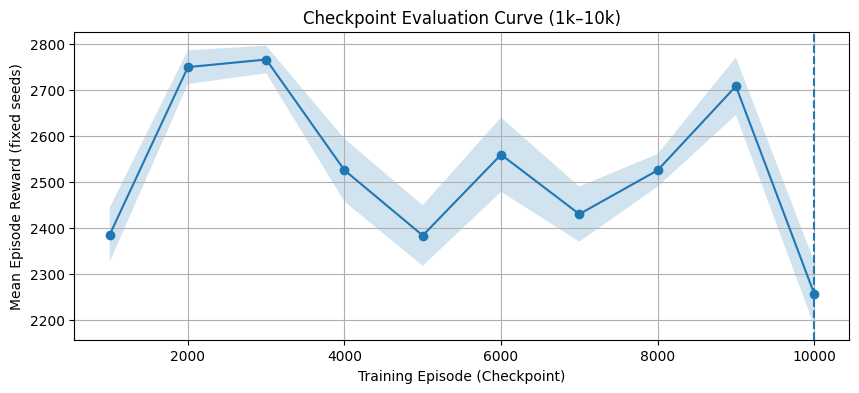

In [ ]:
import matplotlib.pyplot as plt

x = df_curve["episode"].values
y = df_curve["reward_mean"].values
yerr = df_curve["reward_std"].values

plt.figure(figsize=(10,4))
plt.plot(x, y, marker="o")
plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)
plt.axvline(10000, linestyle="--")  # mark 10k
plt.title("Checkpoint Evaluation Curve (1k–10k)")
plt.xlabel("Training Episode (Checkpoint)")
plt.ylabel("Mean Episode Reward (fixed seeds)")
plt.grid(True)
plt.show()